# Arabic Cheque Legal Amount OCR

End-to-end pipeline that reads the Arabic handwritten amount on a cheque, converts it to a number, and verifies it against the courtesy (digit) amount.


**What's in this notebook**

1. Dataset audit, label cleaning, crop regeneration
2. Train/validation split (1620/180) + Qwen JSONL
3. LoRA training v1 (3 epochs)
4. Continuation training v2 (lower LR)
5. Canonical Arabic normalization + parser v2 with edit-distance recovery
6. Image enhancement fallback + courtesy-guided selection
7. **v3 augmented training (best model)**
8. Final test set evaluation on 600 cheques

**Headline result on test set**

| Metric | Reference paper | This work |
|---|---|---|
| Character error rate | 5.9% | **5.84%** |
| Word error rate | 12% | **12.53%** |
| Exact text match | 55.6% | **59.3%** |
| Verification accuracy | 78.5% | **79.7%** |
| False positives | 1.4% | **0.0%** |


<img src="/teamspace/studios/this_studio/cheque_pipeline_one_image_full.svg" width="800">

## 1. Setup
Imports, fixed project paths, and small helpers used everywhere below.

In [1]:
import sys, os, json, csv, re, gc, random, math, html
from pathlib import Path
from collections import Counter, defaultdict

import torch
import transformers
from PIL import Image, ImageOps, ImageEnhance, ImageFilter

print(f"Python: {sys.version.split()[0]}")
print(f"Torch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

try:
    from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
    from peft import LoraConfig, get_peft_model, TaskType, PeftModel
    from qwen_vl_utils import process_vision_info
    from torch.utils.data import Dataset, DataLoader
    print("Qwen3.5, LoRA, and training imports OK.")
except ImportError as e:
    print(f"Import issue: {e}")
    print("Run: pip install transformers>=5.5.4 accelerate qwen-vl-utils peft")

try:
    import matplotlib.pyplot as plt
    print("matplotlib OK.")
except ImportError:
    print("matplotlib not available.")

print("All imports loaded.")


/teamspace/studios/this_studio/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.11.15
Torch: 2.11.0+cu128
Transformers: 5.7.0
CUDA: False
Qwen3.5, LoRA, and training imports OK.
matplotlib OK.
All imports loaded.


In [2]:
from pathlib import Path
import json
import csv
import re
import random
import html
from collections import defaultdict, Counter

from PIL import Image
from IPython.display import display, HTML, Image as IPyImage

BASE_DIR = Path("/teamspace/studios/this_studio")

JSON_PATH = BASE_DIR / "data" / "json_project.json"
IMG_DIR = BASE_DIR / "data" / "CheckImages"

OLD_CROP_ROOT = BASE_DIR / "data" / "legal_amount_crops_from_json_v1"
OLD_CROPS_DIR = OLD_CROP_ROOT / "crops"
OLD_MANIFEST_PATH = OLD_CROP_ROOT / "legal_crops_manifest.csv"

CLEAN_ROOT = BASE_DIR / "data" / "legal_amount_qwen_clean_v1"
AUDIT_DIR = CLEAN_ROOT / "audit"
CLEAN_MANIFEST_PATH = CLEAN_ROOT / "legal_manifest_clean.csv"

V3_CROP_DIR = CLEAN_ROOT / "legal_crops_from_original_json_v3"
V3_MANIFEST_PATH = CLEAN_ROOT / "legal_manifest_clean_v3.csv"
V3_SUMMARY_PATH = CLEAN_ROOT / "legal_crops_v3_summary.json"

VIS_ROOT = CLEAN_ROOT / "visual_audit_v3"
VIS_THUMB_DIR = VIS_ROOT / "thumbs"

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
V3_CROP_DIR.mkdir(parents=True, exist_ok=True)
VIS_ROOT.mkdir(parents=True, exist_ok=True)
VIS_THUMB_DIR.mkdir(parents=True, exist_ok=True)

STEM_RE = re.compile(r"(ac\d{5})", re.I)
AR_RE = re.compile(r"[اأإآء-يىةؤئ]")
DIGIT_RE = re.compile(r"[0-9\u0660-\u0669\u06F0-\u06F9]")
ENGLISH_RE = re.compile(r"[A-Za-z]")
HALALA_RE = re.compile(r"(هلله|هللة|هلاله|هلالة|هللات|هلالات)")
DIACRITICS_RE = re.compile(r"[\u064B-\u065F\u0670]")
TATWEEL_RE = re.compile(r"ـ+")
MULTISPACE_RE = re.compile(r"\s+")

print("Paths ready.")
print("JSON exists:", JSON_PATH.exists(), JSON_PATH)
print("Original images exist:", IMG_DIR.exists(), IMG_DIR)
print("Old manifest exists:", OLD_MANIFEST_PATH.exists(), OLD_MANIFEST_PATH)
print("Clean manifest exists:", CLEAN_MANIFEST_PATH.exists(), CLEAN_MANIFEST_PATH)

Paths ready.
JSON exists: True /teamspace/studios/this_studio/data/json_project.json
Original images exist: True /teamspace/studios/this_studio/data/CheckImages
Old manifest exists: True /teamspace/studios/this_studio/data/legal_amount_crops_from_json_v1/legal_crops_manifest.csv
Clean manifest exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_manifest_clean.csv


In [3]:
def extract_stem(value):
    m = STEM_RE.search(str(value or ""))
    return m.group(1).lower() if m else ""

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def normalize_spaces(text):
    text = str(text or "")
    text = text.replace("\u200f", " ").replace("\u200e", " ")
    return MULTISPACE_RE.sub(" ", text).strip()

def count_arabic(text):
    return len(AR_RE.findall(str(text or "")))

def count_digits(text):
    return len(DIGIT_RE.findall(str(text or "")))

def has_halala(text):
    return bool(HALALA_RE.search(str(text or "")))

def check_image(path):
    path = Path(path)
    if not path.exists():
        return False, "", "", "missing"

    try:
        with Image.open(path) as img:
            w, h = img.size
        return True, w, h, ""
    except Exception:
        return False, "", "", "unreadable"

def esc(x):
    return html.escape(str(x or ""))

print("Helper functions ready.")

Helper functions ready.


## 2. Dataset audit
Check the cleaned label file is structurally safe: row count, unique stems, included rows, status counts.

In [3]:
if not CLEAN_MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Missing clean manifest: {CLEAN_MANIFEST_PATH}")

clean_rows = read_csv_rows(CLEAN_MANIFEST_PATH)

print("=" * 80)
print("STAGE 1 DATASET AUDIT")
print("=" * 80)
print("Rows in clean manifest:", len(clean_rows))
print("Unique stems:", len({r['stem'] for r in clean_rows}))
print("Included for training:", sum(r.get("include_for_training") == "True" for r in clean_rows))
print("Manifest status counts:", dict(Counter(r.get("manifest_status", "") for r in clean_rows)))
print("JSON status counts:", dict(Counter(r.get("json_status", "") for r in clean_rows)))

missing_text = [r for r in clean_rows if not normalize_spaces(r.get("legal_text_train", ""))]
bad_included = [r for r in clean_rows if r.get("include_for_training") == "True" and not normalize_spaces(r.get("legal_text_train", ""))]

print("Rows missing legal_text_train:", len(missing_text))
print("Bad included rows:", len(bad_included))

structure_rows = [r for r in clean_rows if r.get("json_status") == "structure_issue"]
print("Structure issue rows:", [r["stem"] for r in structure_rows])

print("\nNote:")
print("ac00048 and ac01209 are kept because their legal text is valid.")

STAGE 1 DATASET AUDIT
Rows in clean manifest: 1800
Unique stems: 1800
Included for training: 1800
Manifest status counts: {'ok': 1655, 'structure_issue': 2, 'swap_fixed': 143}
JSON status counts: {'ok': 1655, 'structure_issue': 2, 'swap_likely': 143}
Rows missing legal_text_train: 0
Bad included rows: 0
Structure issue rows: ['ac00048', 'ac01209']

Note:
ac00048 and ac01209 are kept because their legal text is valid.


## 3. Clean label verification
Each row carries four legal-text columns:

| Column | Use |
|---|---|
| `legal_text_raw` | original transcription |
| `legal_text_eval` | cleaned text used for CER/WER |
| `legal_text_train` | target text used for fine-tuning |
| `legal_text_parse` | normalized text for the parser |

Cheque anchor words (`فقط`, `ريال`, `لا غير`) are kept. Halala, digit noise, and English fragments are removed. 143 swap-fixed rows are included because they're valid after correction.

In [4]:
clean_rows = read_csv_rows(CLEAN_MANIFEST_PATH)

bad_rows = []
for r in clean_rows:
    train_text = normalize_spaces(r.get("legal_text_train", ""))

    issues = []
    if not train_text:
        issues.append("empty_train_text")
    if count_arabic(train_text) < 3:
        issues.append("too_little_arabic")
    if count_digits(train_text) > 0:
        issues.append("digits_in_train_text")
    if has_halala(train_text):
        issues.append("halala_in_train_text")

    if r.get("include_for_training") == "True" and issues:
        bad_rows.append({
            "stem": r["stem"],
            "issues": "|".join(issues),
            "legal_text_train": train_text,
        })

print("=" * 80)
print("STAGE 2 CLEAN LABEL CHECK")
print("=" * 80)
print("Total rows:", len(clean_rows))
print("Included for training:", sum(r.get("include_for_training") == "True" for r in clean_rows))
print("Bad included rows:", len(bad_rows))
print("Swap-fixed rows included:", sum(r.get("include_for_training") == "True" and r.get("manifest_status") == "swap_fixed" for r in clean_rows))
print("Structure issue rows included:", sum(r.get("include_for_training") == "True" and r.get("json_status") == "structure_issue" for r in clean_rows))

if bad_rows:
    print("\nBad rows preview:")
    for r in bad_rows[:20]:
        print(r)
else:
    print("\nClean labels are ready.")

STAGE 2 CLEAN LABEL CHECK
Total rows: 1800
Included for training: 1800
Bad included rows: 0
Swap-fixed rows included: 143
Structure issue rows included: 2

Clean labels are ready.


In [5]:
def show_text_examples(title, rows, limit=5):
    print("\n" + "=" * 80)
    print(title, "count:", len(rows))
    print("=" * 80)
    for r in rows[:limit]:
        print("Stem:", r["stem"], "| status:", r.get("manifest_status"), "| notes:", r.get("cleaning_notes"))
        print("RAW  :", r.get("legal_text_raw"))
        print("EVAL :", r.get("legal_text_eval"))
        print("TRAIN:", r.get("legal_text_train"))
        print("PARSE:", r.get("legal_text_parse"))
        print("-" * 80)

halala_rows = [r for r in clean_rows if "halala_removed" in str(r.get("cleaning_notes", "")).split("|")]
digit_rows = [r for r in clean_rows if "digits_removed" in str(r.get("cleaning_notes", "")).split("|")]
swap_rows = [r for r in clean_rows if r.get("manifest_status") == "swap_fixed"]
structure_rows = [r for r in clean_rows if r.get("json_status") == "structure_issue"]

show_text_examples("Halala cleaning examples", halala_rows, limit=5)
show_text_examples("Digit cleaning examples", digit_rows, limit=5)
show_text_examples("Swap-fixed rows", swap_rows, limit=5)
show_text_examples("Structure issue rows kept", structure_rows, limit=5)


Halala cleaning examples count: 85
Stem: ac00021 | status: ok | notes: halala_removed|digits_removed|text_normalized
RAW  : خمسة الاف وخمسمائة وثلاثه وسبعون ريال ٧٥ هلله
EVAL : خمسة الاف وخمسماية وثلاثه وسبعون ريال
TRAIN: خمسة الاف وخمسماية وثلاثه وسبعون ريال
PARSE: خمسة الاف وخمسماية وثلاثه وسبعون
--------------------------------------------------------------------------------
Stem: ac00022 | status: ok | notes: halala_removed|text_normalized
RAW  : سته الاف وثنين ريال و خمسون هلله
EVAL : سته الاف وثنين ريال
TRAIN: سته الاف وثنين ريال
PARSE: سته الاف وثنين
--------------------------------------------------------------------------------
Stem: ac00089 | status: ok | notes: halala_removed|text_normalized
RAW  : اربعه الآف وسبع مائه وسته عشر ريال وخمسه وعشرون هلله
EVAL : اربعة الاف وسبع مائة وسته عشر ريال
TRAIN: اربعة الاف وسبع مائة وسته عشر ريال
PARSE: اربعة الاف وسبع مائة وسته عشر
--------------------------------------------------------------------------------
Stem: ac00111 | status: o

## 4. Regenerate legal crops from `.tif` images
The original crop folder had some courtesy regions saved as legal crops. Rule used for the regenerated set:
the **widest** annotated region per cheque is the legal crop. Output goes to `legal_crops_from_original_json_v3/`.

In [6]:
PAD_X = 18
PAD_Y = 12

def parse_regions_from_task(task):
    grouped = defaultdict(dict)
    anns = task.get("annotations") or []
    result = anns[0].get("result", []) if anns else []

    for item in result:
        rid = item.get("id")
        if not rid:
            continue

        typ = item.get("type")
        val = item.get("value", {})

        if typ == "labels":
            grouped[rid]["label_raw"] = (val.get("labels") or [""])[0]

        if typ == "textarea":
            grouped[rid]["text_raw"] = (val.get("text") or [""])[0]

        for key in ["x", "y", "width", "height"]:
            if key in val:
                grouped[rid][key] = float(val[key])

    regions = []
    for rid, g in grouped.items():
        if all(k in g for k in ["x", "y", "width", "height"]):
            regions.append({
                "region_id": rid,
                "label_raw": g.get("label_raw", ""),
                "text_raw": g.get("text_raw", ""),
                "x_pct": g["x"],
                "y_pct": g["y"],
                "w_pct": g["width"],
                "h_pct": g["height"],
                "area_pct": g["width"] * g["height"],
            })

    return regions

def choose_legal_box_by_geometry(regions):
    if not regions:
        return None, "no_regions"

    sorted_regions = sorted(
        regions,
        key=lambda r: (r["w_pct"], r["area_pct"]),
        reverse=True,
    )

    chosen = sorted_regions[0]

    if len(sorted_regions) >= 2:
        second = sorted_regions[1]
        decision = f"widest_region_w{chosen['w_pct']:.2f}_vs_second_w{second['w_pct']:.2f}"
    else:
        decision = f"only_region_w{chosen['w_pct']:.2f}"

    return chosen, decision

def pct_to_xyxy(region, img_w, img_h, pad_x=0, pad_y=0):
    x1 = int(round(region["x_pct"] / 100 * img_w)) - pad_x
    y1 = int(round(region["y_pct"] / 100 * img_h)) - pad_y
    x2 = int(round((region["x_pct"] + region["w_pct"]) / 100 * img_w)) + pad_x
    y2 = int(round((region["y_pct"] + region["h_pct"]) / 100 * img_h)) + pad_y

    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(1, min(x2, img_w))
    y2 = max(1, min(y2, img_h))

    if x2 <= x1 or y2 <= y1:
        return None

    return x1, y1, x2, y2

clean_rows = read_csv_rows(CLEAN_MANIFEST_PATH)
clean_by_stem = {r["stem"]: r for r in clean_rows}

with open(JSON_PATH, "r", encoding="utf-8") as f:
    tasks = json.load(f)

tasks_by_stem = {}
for task in tasks:
    stem = extract_stem(task.get("file_upload", "")) or extract_stem(task.get("data", {}).get("ocr", ""))
    if stem:
        tasks_by_stem[stem] = task

new_rows = []
errors = []
suspicious = []

for stem, clean_row in clean_by_stem.items():
    task = tasks_by_stem.get(stem)

    if task is None:
        errors.append({"stem": stem, "reason": "missing_json_task"})
        continue

    img_path = IMG_DIR / f"{stem}.tif"

    if not img_path.exists():
        errors.append({"stem": stem, "reason": "missing_original_tif", "path": str(img_path)})
        continue

    try:
        img = Image.open(img_path).convert("RGB")
    except Exception as e:
        errors.append({"stem": stem, "reason": "unreadable_original_tif", "error": str(e)})
        continue

    regions = parse_regions_from_task(task)
    chosen, decision = choose_legal_box_by_geometry(regions)

    if chosen is None:
        errors.append({"stem": stem, "reason": "no_region_found"})
        continue

    img_w, img_h = img.size
    box = pct_to_xyxy(chosen, img_w, img_h, pad_x=PAD_X, pad_y=PAD_Y)

    if box is None:
        errors.append({"stem": stem, "reason": "invalid_box"})
        continue

    x1, y1, x2, y2 = box
    crop = img.crop((x1, y1, x2, y2))

    crop_path = V3_CROP_DIR / f"{stem}_legal.png"
    crop.save(crop_path)

    crop_w, crop_h = crop.size
    aspect = crop_w / crop_h if crop_h else 0

    row = dict(clean_row)
    row["legal_crop_path_old"] = clean_row.get("legal_crop_path", "")
    row["legal_crop_path"] = str(crop_path)
    row["source_original_image"] = str(img_path)
    row["v3_crop_rule"] = "widest_json_region_from_original_tif"
    row["v3_crop_decision"] = decision
    row["v3_source_label_raw"] = chosen.get("label_raw", "")
    row["v3_source_text_preview"] = chosen.get("text_raw", "")[:120]
    row["v3_x1"] = x1
    row["v3_y1"] = y1
    row["v3_x2"] = x2
    row["v3_y2"] = y2
    row["crop_width"] = crop_w
    row["crop_height"] = crop_h
    row["crop_aspect"] = f"{aspect:.3f}"
    row["json_regions_count"] = len(regions)

    if crop_w < 250 or aspect < 3.0:
        suspicious.append({
            "stem": stem,
            "crop_width": crop_w,
            "crop_height": crop_h,
            "aspect": round(aspect, 2),
            "status": row.get("manifest_status", ""),
            "text": row.get("legal_text_train", ""),
        })

    new_rows.append(row)

if new_rows:
    fieldnames = list(new_rows[0].keys())
    write_csv_rows(V3_MANIFEST_PATH, new_rows, fieldnames)

summary = {
    "input_clean_rows": len(clean_rows),
    "regenerated_rows": len(new_rows),
    "errors_count": len(errors),
    "errors": errors[:50],
    "suspicious_count_width_lt_250_or_aspect_lt_3": len(suspicious),
    "suspicious_examples": suspicious[:50],
    "v3_source_label_counts": dict(Counter(r["v3_source_label_raw"] for r in new_rows)),
    "manifest_status_counts": dict(Counter(r["manifest_status"] for r in new_rows)),
    "json_status_counts": dict(Counter(r["json_status"] for r in new_rows)),
    "output_crop_dir": str(V3_CROP_DIR),
    "output_manifest": str(V3_MANIFEST_PATH),
}

with open(V3_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "input_clean_rows": 1800,
  "regenerated_rows": 1800,
  "errors_count": 0,
  "errors": [],
  "suspicious_count_width_lt_250_or_aspect_lt_3": 6,
  "suspicious_examples": [
    {
      "stem": "ac00567",
      "crop_width": 194,
      "crop_height": 52,
      "aspect": 3.73,
      "status": "ok",
      "text": "فقط الفين"
    },
    {
      "stem": "ac00635",
      "crop_width": 307,
      "crop_height": 113,
      "aspect": 2.72,
      "status": "swap_fixed",
      "text": "وقدره الف ريال لا غير"
    },
    {
      "stem": "ac00637",
      "crop_width": 234,
      "crop_height": 90,
      "aspect": 2.6,
      "status": "swap_fixed",
      "text": "الفان ريال لا غير"
    },
    {
      "stem": "ac00649",
      "crop_width": 397,
      "crop_height": 197,
      "aspect": 2.02,
      "status": "swap_fixed",
      "text": "فقط خمسة الف وخمسه وخمسون رسال"
    },
    {
      "stem": "ac00691",
      "crop_width": 295,
      "crop_height": 100,
      "aspect": 2.95,
      "status": "swap_f

## 5. Dataset health check
Verify every row has a readable crop file and clean training text. Expect 1800 rows, 1800 unique stems, 0 missing/unreadable crops.

In [7]:
ACTIVE_MANIFEST = V3_MANIFEST_PATH
ACTIVE_CROP_DIR = V3_CROP_DIR

rows_v3 = read_csv_rows(ACTIVE_MANIFEST)

missing = []
unreadable = []
small_or_suspicious = []

for r in rows_v3:
    crop_path = Path(r["legal_crop_path"])
    ok, w, h, reason = check_image(crop_path)

    if not ok:
        if reason == "missing":
            missing.append(r["stem"])
        else:
            unreadable.append(r["stem"])
        continue

    aspect = w / h if h else 0

    if w < 250 or aspect < 3.0:
        small_or_suspicious.append({
            "stem": r["stem"],
            "w": w,
            "h": h,
            "aspect": round(aspect, 2),
            "status": r["manifest_status"],
            "text": r["legal_text_train"],
        })

print("=" * 80)
print("V3 ACTIVE DATASET CHECK")
print("=" * 80)
print("Active manifest:", ACTIVE_MANIFEST)
print("Active crop dir:", ACTIVE_CROP_DIR)
print("Rows:", len(rows_v3))
print("Unique stems:", len({r["stem"] for r in rows_v3}))
print("Included for training:", sum(r["include_for_training"] == "True" for r in rows_v3))
print("Missing crops:", len(missing))
print("Unreadable crops:", len(unreadable))
print("Suspicious small/aspect crops:", len(small_or_suspicious))

print("\nStatus counts:")
print(dict(Counter(r["manifest_status"] for r in rows_v3)))

print("\nJSON status counts:")
print(dict(Counter(r["json_status"] for r in rows_v3)))

print("\nCrop source label counts:")
print(dict(Counter(r.get("v3_source_label_raw", "") for r in rows_v3)))

print("\nSuspicious examples:")
for x in small_or_suspicious[:20]:
    print(x)

V3 ACTIVE DATASET CHECK
Active manifest: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_manifest_clean_v3.csv
Active crop dir: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3
Rows: 1800
Unique stems: 1800
Included for training: 1800
Missing crops: 0
Unreadable crops: 0
Suspicious small/aspect crops: 6

Status counts:
{'ok': 1655, 'structure_issue': 2, 'swap_fixed': 143}

JSON status counts:
{'ok': 1655, 'structure_issue': 2, 'swap_likely': 143}

Crop source label counts:
{'Legal': 1742, 'Courtesy': 58}

Suspicious examples:
{'stem': 'ac00567', 'w': 194, 'h': 52, 'aspect': 3.73, 'status': 'ok', 'text': 'فقط الفين'}
{'stem': 'ac00635', 'w': 307, 'h': 113, 'aspect': 2.72, 'status': 'swap_fixed', 'text': 'وقدره الف ريال لا غير'}
{'stem': 'ac00637', 'w': 234, 'h': 90, 'aspect': 2.6, 'status': 'swap_fixed', 'text': 'الفان ريال لا غير'}
{'stem': 'ac00649', 'w': 397, 'h': 197, 'aspect': 2.02, 'status': 'swap_fixed', 'text':

## 6. Visual audit
Sample crops inline to confirm they show Arabic legal handwriting (not courtesy digits). Random crops, swap-fixed rows, and small/aspect outliers are all checked.

In [8]:
random.seed(42)

rows_v3 = read_csv_rows(V3_MANIFEST_PATH)
included_v3 = [r for r in rows_v3 if r.get("include_for_training") == "True"]

def to_int(value, default=0):
    try:
        return int(float(value))
    except Exception:
        return default

def aspect(row):
    w = to_int(row.get("crop_width", 0))
    h = to_int(row.get("crop_height", 0))
    return w / h if h > 0 else 0

def sample_rows(pool, n):
    pool = list(pool)
    if len(pool) <= n:
        return pool
    return random.sample(pool, n)

random_rows = sample_rows(included_v3, 20)
swap_fixed_rows = sample_rows([r for r in included_v3 if r.get("manifest_status") == "swap_fixed"], 20)
structure_rows = [r for r in included_v3 if r.get("json_status") == "structure_issue"]
suspicious_rows = [r for r in included_v3 if to_int(r.get("crop_width")) < 250 or aspect(r) < 3.0]

print("Random rows selected:", len(random_rows))
print("Swap-fixed rows selected:", len(swap_fixed_rows))
print("Structure issue rows:", len(structure_rows))
print("Suspicious rows:", len(suspicious_rows))

Random rows selected: 20
Swap-fixed rows selected: 20
Structure issue rows: 2
Suspicious rows: 6


In [ ]:
def show_crop_rows(title, rows, n=10):
    rows = list(rows)
    selected = rows[:n]

    display(HTML(f"<h2>{esc(title)}</h2><p>Showing {len(selected)} of {len(rows)} rows</p>"))

    for r in selected:
        crop_path = Path(r["legal_crop_path"])

        block = f"""
        <div style="border:1px solid #ccc;padding:10px;margin:10px 0;background:white;">
            <b>Stem:</b> {esc(r.get("stem"))} |
            <b>Status:</b> {esc(r.get("manifest_status"))} |
            <b>JSON:</b> {esc(r.get("json_status"))} |
            <b>Source label:</b> {esc(r.get("v3_source_label_raw"))} |
            <b>Size:</b> {esc(r.get("crop_width"))} x {esc(r.get("crop_height"))} |
            <b>Aspect:</b> {esc(r.get("crop_aspect"))}<br>
            <b>TRAIN:</b> <span dir="rtl" style="font-size:18px;">{esc(r.get("legal_text_train"))}</span><br>
            <b>REGION TEXT:</b> <span dir="rtl" style="font-size:18px;">{esc(r.get("v3_source_text_preview"))}</span><br>
            <b>Path:</b> {esc(crop_path)}
        </div>
        """
        display(HTML(block))

        if crop_path.exists():
            display(IPyImage(filename=str(crop_path)))
        else:
            display(HTML("<p style='color:red;'>Crop image missing.</p>"))

show_crop_rows("Random V3 legal crops", random_rows, n=8)
show_crop_rows("Swap-fixed V3 legal crops", swap_fixed_rows, n=8)
show_crop_rows("Structure issue V3 legal crops", structure_rows, n=5)
show_crop_rows("Suspicious size/aspect V3 crops", suspicious_rows, n=10)

In [11]:
from pathlib import Path
import csv

BASE_DIR = Path("/teamspace/studios/this_studio")

ACTIVE_MANIFEST = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "legal_manifest_clean_v3.csv"
ACTIVE_CROP_DIR = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "legal_crops_from_original_json_v3"

print("Active manifest exists:", ACTIVE_MANIFEST.exists(), ACTIVE_MANIFEST)
print("Active crop folder exists:", ACTIVE_CROP_DIR.exists(), ACTIVE_CROP_DIR)

if ACTIVE_MANIFEST.exists():
    with open(ACTIVE_MANIFEST, "r", encoding="utf-8-sig", newline="") as f:
        rows = list(csv.DictReader(f))

    print("Rows:", len(rows))
    print("Included:", sum(r["include_for_training"] == "True" for r in rows))
    print("Example crop path:", rows[0]["legal_crop_path"])
    print("Example crop exists:", Path(rows[0]["legal_crop_path"]).exists())

Active manifest exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_manifest_clean_v3.csv
Active crop folder exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3
Rows: 1800
Included: 1800
Example crop path: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3/ac00000_legal.png
Example crop exists: True


## 7. Train/validation split + Qwen JSONL
Stem-based 90/10 split with seed 42 → 1620 train, 180 val. No test split here (the professor's test set is processed separately at the end).

Each JSONL row: image + Arabic prompt + answer.

In [1]:
from pathlib import Path
import csv
import json
import random
from collections import Counter
from PIL import Image

BASE_DIR = Path("/teamspace/studios/this_studio")

ACTIVE_MANIFEST = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "legal_manifest_clean_v3.csv"

OUT_ROOT = BASE_DIR / "data" / "legal_amount_qwen_clean_v1"
SPLIT_DIR = OUT_ROOT / "splits"
JSONL_DIR = OUT_ROOT / "jsonl"

SPLIT_DIR.mkdir(parents=True, exist_ok=True)
JSONL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV = SPLIT_DIR / "val.csv"

TRAIN_JSONL = JSONL_DIR / "train.jsonl"
VAL_JSONL = JSONL_DIR / "val.jsonl"

SPLIT_SUMMARY = OUT_ROOT / "train_val_split_summary.json"

SEED = 42
VAL_RATIO = 0.10

PROMPT = "استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط."

print("Active manifest:", ACTIVE_MANIFEST)
print("Manifest exists:", ACTIVE_MANIFEST.exists())
print("Output JSONL folder:", JSONL_DIR)

Active manifest: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_manifest_clean_v3.csv
Manifest exists: True
Output JSONL folder: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl


In [2]:
def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def image_is_readable(path):
    path = Path(path)
    if not path.exists():
        return False
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

rows = read_csv_rows(ACTIVE_MANIFEST)

usable = []
bad = []

for r in rows:
    crop_path = Path(r["legal_crop_path"])
    train_text = str(r.get("legal_text_train", "")).strip()

    if r.get("include_for_training") != "True":
        bad.append((r["stem"], "not_included"))
        continue

    if not train_text:
        bad.append((r["stem"], "empty_legal_text_train"))
        continue

    if not image_is_readable(crop_path):
        bad.append((r["stem"], "bad_crop_path"))
        continue

    usable.append(r)

print("Total rows:", len(rows))
print("Usable rows:", len(usable))
print("Bad rows:", len(bad))

if bad:
    print("Bad rows preview:")
    for x in bad[:20]:
        print(x)

print("Status counts:", dict(Counter(r["manifest_status"] for r in usable)))
print("JSON status counts:", dict(Counter(r["json_status"] for r in usable)))

Total rows: 1800
Usable rows: 1800
Bad rows: 0
Status counts: {'ok': 1655, 'structure_issue': 2, 'swap_fixed': 143}
JSON status counts: {'ok': 1655, 'structure_issue': 2, 'swap_likely': 143}


In [3]:
random.seed(SEED)

usable_sorted = sorted(usable, key=lambda r: r["stem"])
random.shuffle(usable_sorted)

val_count = round(len(usable_sorted) * VAL_RATIO)

val_rows = usable_sorted[:val_count]
train_rows = usable_sorted[val_count:]

train_stems = {r["stem"] for r in train_rows}
val_stems = {r["stem"] for r in val_rows}

overlap = train_stems & val_stems

print("Train rows:", len(train_rows))
print("Val rows:", len(val_rows))
print("Overlap stems:", len(overlap))

print("Train status counts:", dict(Counter(r["manifest_status"] for r in train_rows)))
print("Val status counts:", dict(Counter(r["manifest_status"] for r in val_rows)))

if overlap:
    raise ValueError("Train and validation overlap found.")

Train rows: 1620
Val rows: 180
Overlap stems: 0
Train status counts: {'ok': 1489, 'swap_fixed': 129, 'structure_issue': 2}
Val status counts: {'ok': 166, 'swap_fixed': 14}


In [4]:
fieldnames = list(train_rows[0].keys())

write_csv_rows(TRAIN_CSV, train_rows, fieldnames)
write_csv_rows(VAL_CSV, val_rows, fieldnames)

print("Saved train CSV:", TRAIN_CSV)
print("Saved val CSV:", VAL_CSV)

Saved train CSV: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/splits/train.csv
Saved val CSV: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/splits/val.csv


In [5]:
def make_qwen_record(row):
    image_path = str(Path(row["legal_crop_path"]))
    answer = str(row["legal_text_train"]).strip()

    return {
        "stem": row["stem"],
        "status": row["manifest_status"],
        "json_status": row["json_status"],
        "image": image_path,
        "prompt": PROMPT,
        "answer": answer,
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image_path
                    },
                    {
                        "type": "text",
                        "text": PROMPT
                    }
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {
                        "type": "text",
                        "text": answer
                    }
                ]
            }
        ]
    }

def write_jsonl(path, rows):
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            rec = make_qwen_record(row)
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

write_jsonl(TRAIN_JSONL, train_rows)
write_jsonl(VAL_JSONL, val_rows)

print("Saved train JSONL:", TRAIN_JSONL)
print("Saved val JSONL:", VAL_JSONL)

Saved train JSONL: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/train.jsonl
Saved val JSONL: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/val.jsonl


In [6]:
summary = {
    "active_manifest": str(ACTIVE_MANIFEST),
    "train_csv": str(TRAIN_CSV),
    "val_csv": str(VAL_CSV),
    "train_jsonl": str(TRAIN_JSONL),
    "val_jsonl": str(VAL_JSONL),
    "seed": SEED,
    "val_ratio": VAL_RATIO,
    "total_usable_rows": len(usable),
    "train_rows": len(train_rows),
    "val_rows": len(val_rows),
    "prompt": PROMPT,
    "train_status_counts": dict(Counter(r["manifest_status"] for r in train_rows)),
    "val_status_counts": dict(Counter(r["manifest_status"] for r in val_rows)),
    "train_json_status_counts": dict(Counter(r["json_status"] for r in train_rows)),
    "val_json_status_counts": dict(Counter(r["json_status"] for r in val_rows)),
}

with open(SPLIT_SUMMARY, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))
print("Saved split summary:", SPLIT_SUMMARY)

{
  "active_manifest": "/teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_manifest_clean_v3.csv",
  "train_csv": "/teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/splits/train.csv",
  "val_csv": "/teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/splits/val.csv",
  "train_jsonl": "/teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/train.jsonl",
  "val_jsonl": "/teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/val.jsonl",
  "seed": 42,
  "val_ratio": 0.1,
  "total_usable_rows": 1800,
  "train_rows": 1620,
  "val_rows": 180,
  "prompt": "استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط.",
  "train_status_counts": {
    "ok": 1489,
    "swap_fixed": 129,
    "structure_issue": 2
  },
  "val_status_counts": {
    "ok": 166,
    "swap_fixed": 14
  },
  "train_json_status_counts": {
    "ok": 1489,
    "swap_likely": 129,
    "structure_issue": 2
  },
  "val_json_status_counts": {
    "ok": 166,
    "

In [7]:
def read_jsonl(path, limit=3):
    out = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            out.append(json.loads(line))
            if len(out) >= limit:
                break
    return out

samples = read_jsonl(TRAIN_JSONL, limit=3)

for i, rec in enumerate(samples, 1):
    print("=" * 100)
    print("Sample:", i)
    print("stem:", rec["stem"])
    print("status:", rec["status"])
    print("image:", rec["image"])
    print("image exists:", Path(rec["image"]).exists())
    print("prompt:", rec["prompt"])
    print("answer:", rec["answer"])
    print("messages:")
    print(json.dumps(rec["messages"], ensure_ascii=False, indent=2))

Sample: 1
stem: ac01765
status: ok
image: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3/ac01765_legal.png
image exists: True
prompt: استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط.
answer: اربعة الاف ومايه وواحد وثلاثون ريال لا غير
messages:
[
  {
    "role": "user",
    "content": [
      {
        "type": "image",
        "image": "/teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3/ac01765_legal.png"
      },
      {
        "type": "text",
        "text": "استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط."
      }
    ]
  },
  {
    "role": "assistant",
    "content": [
      {
        "type": "text",
        "text": "اربعة الاف ومايه وواحد وثلاثون ريال لا غير"
      }
    ]
  }
]
Sample: 2
stem: ac01025
status: ok
image: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3/ac01025_legal.png
image exists: True
prompt: استخ

## 8. Model sanity check (before fine-tuning)
Confirms environment, loads the local Qwen3.5 OCR model and processor, runs a few validation crops to verify inference and metric code work. Predictions here are expected to be poor — the model isn't fine-tuned yet.

In [8]:
import sys
from pathlib import Path

import torch
import transformers

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA device count:", torch.cuda.device_count())

print("Transformers:", transformers.__version__)

from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
from qwen_vl_utils import process_vision_info

print("Qwen3.5 imports work.")

/teamspace/studios/this_studio/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable: /teamspace/studios/this_studio/.conda/bin/python
Python version: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0]
Torch: 2.5.1+cu121
CUDA available: True
GPU name: Tesla T4
CUDA device count: 1
Transformers: 5.7.0
Qwen3.5 imports work.


Model dir exists: True /teamspace/studios/this_studio/models/Qwen3.5_model
Val JSONL exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/val.jsonl
Loaded validation samples: 5

Sample stem: ac01485
Image: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3/ac01485_legal.png
Image exists: True
Prompt: استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط.
Target answer: الف وثلاثمايه وسته وعشرون ريال لا غير
Image size: (531, 90)


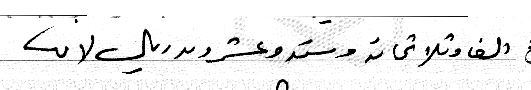

In [9]:
from pathlib import Path
import json
from PIL import Image
from IPython.display import display

BASE_DIR = Path("/teamspace/studios/this_studio")

MODEL_DIR = BASE_DIR / "models" / "Qwen3.5_model"
VAL_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "val.jsonl"

print("Model dir exists:", MODEL_DIR.exists(), MODEL_DIR)
print("Val JSONL exists:", VAL_JSONL.exists(), VAL_JSONL)

def read_jsonl(path, limit=None):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
            if limit is not None and len(rows) >= limit:
                break
    return rows

val_samples = read_jsonl(VAL_JSONL, limit=5)

print("Loaded validation samples:", len(val_samples))

sample = val_samples[0]

print("\nSample stem:", sample["stem"])
print("Image:", sample["image"])
print("Image exists:", Path(sample["image"]).exists())
print("Prompt:", sample["prompt"])
print("Target answer:", sample["answer"])

img = Image.open(sample["image"]).convert("RGB")
print("Image size:", img.size)
display(img)

In [10]:
import torch
from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration

MODEL_DIR = Path("/teamspace/studios/this_studio/models/Qwen3.5_model")

processor = AutoProcessor.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
)

model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
    torch_dtype=torch.float16,
    device_map="auto",
)

model.eval()

print("Processor loaded.")
print("Model loaded.")
print("Model device:", next(model.parameters()).device)
print("Model dtype:", next(model.parameters()).dtype)

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 473/473 [00:02<00:00, 183.86it/s]


Processor loaded.
Model loaded.
Model device: cuda:0
Model dtype: torch.float16


In [11]:
import torch
from qwen_vl_utils import process_vision_info

MAX_NEW_TOKENS = 64

def predict_one(image_path, prompt):
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": str(image_path),
                },
                {
                    "type": "text",
                    "text": prompt,
                },
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    device = next(model.parameters()).device
    inputs = inputs.to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            num_beams=1,
        )

    generated_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return output_text.strip()

In [12]:
sample = val_samples[0]

pred = predict_one(
    image_path=sample["image"],
    prompt=sample["prompt"],
)

print("=" * 100)
print("Stem:", sample["stem"])
print("Target:")
print(sample["answer"])
print("\nPrediction:")
print(pred)

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Stem: ac01485
Target:
الف وثلاثمايه وسته وعشرون ريال لا غير

Prediction:
في الفاتورة في مدرسة ومحدث ودرس ليليات لالابك
    .
    .
    .
    .
    .
    .
    .
    .
    .
    .
    .


In [ ]:
for i, sample in enumerate(val_samples[:3], 1):
    print("=" * 100)
    print("Sample:", i)
    print("Stem:", sample["stem"])

    img = Image.open(sample["image"]).convert("RGB")
    display(img)

    pred = predict_one(
        image_path=sample["image"],
        prompt=sample["prompt"],
    )

    print("Target:")
    print(sample["answer"])
    print("\nPrediction:")
    print(pred)

In [14]:
def levenshtein(a, b):
    a = list(a)
    b = list(b)

    dp = list(range(len(b) + 1))

    for i, ca in enumerate(a, 1):
        prev = dp[0]
        dp[0] = i

        for j, cb in enumerate(b, 1):
            old = dp[j]

            if ca == cb:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])

            prev = old

    return dp[-1]

def normalize_for_metric(text):
    text = str(text or "")
    text = text.replace("\u200f", " ").replace("\u200e", " ")
    text = " ".join(text.split())
    return text.strip()

def cer(pred, gt):
    pred = normalize_for_metric(pred)
    gt = normalize_for_metric(gt)

    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0

    return levenshtein(pred, gt) / len(gt)

def wer(pred, gt):
    pred_words = normalize_for_metric(pred).split()
    gt_words = normalize_for_metric(gt).split()

    if len(gt_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0

    return levenshtein(pred_words, gt_words) / len(gt_words)

small_results = []

for sample in val_samples[:5]:
    pred = predict_one(sample["image"], sample["prompt"])
    gt = sample["answer"]

    small_results.append({
        "stem": sample["stem"],
        "gt": gt,
        "pred": pred,
        "cer": cer(pred, gt),
        "wer": wer(pred, gt),
    })

print("=" * 100)
print("Small sanity metrics on 5 samples only")
print("=" * 100)

avg_cer = sum(r["cer"] for r in small_results) / len(small_results)
avg_wer = sum(r["wer"] for r in small_results) / len(small_results)

print("Average CER:", round(avg_cer, 4))
print("Average WER:", round(avg_wer, 4))

for r in small_results:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("CER:", round(r["cer"], 4), "WER:", round(r["wer"], 4))
    print("GT  :", r["gt"])
    print("PRED:", r["pred"])

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Small sanity metrics on 5 samples only
Average CER: 2.6143
Average WER: 3.3362
----------------------------------------------------------------------------------------------------
Stem: ac01485
CER: 1.4054 WER: 2.7143
GT  : الف وثلاثمايه وسته وعشرون ريال لا غير
PRED: في الفاتورة في مدرسة ومحدث ودرس ليليات لالابك
    .
    .
    .
    .
    .
    .
    .
    .
    .
    .
    .
----------------------------------------------------------------------------------------------------
Stem: ac00291
CER: 2.56 WER: 2.8333
GT  : عشرة الاف ريال فقط لا غير
PRED: في ٢٦ كانون الثالث منقمها ١٠٠
هذه
هذه
هذه
هذه
هذه
هذه
هذه
هذه
هذه
هذه
هذه
----------------------------------------------------------------------------------------------------
Stem: ac01235
CER: 1.7812 WER: 3.3333
GT  : الفان وميتان وثلاثون ريال لا غير
PRED: أَفانَك دِسْعَانٌ مِنْهُمْ لَوْانٌ لَمْ
م
م
م
م
م
م
م
م
م
م
م
م
م
م
م
----------------------------------------------------------------------------------------------------
Stem: ac01203
CE

## 9. GPU and libraries readiness
Quick checks before LoRA training. 

In [1]:
import sys
from pathlib import Path

import torch
import transformers

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA device count:", torch.cuda.device_count())
    print("GPU memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

print("Transformers:", transformers.__version__)

from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
from qwen_vl_utils import process_vision_info

print("Qwen3.5 imports work.")

/teamspace/studios/this_studio/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable: /teamspace/studios/this_studio/.conda/bin/python
Python version: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0]
Torch: 2.5.1+cu121
CUDA available: True
GPU name: NVIDIA RTX PRO 6000 Blackwell Server Edition
CUDA device count: 1
GPU memory GB: 94.97
Transformers: 5.7.0


/teamspace/studios/this_studio/.conda/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA RTX PRO 6000 Blackwell Server Edition with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA RTX PRO 6000 Blackwell Server Edition GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Qwen3.5 imports work.


In [2]:
from pathlib import Path
import json

BASE_DIR = Path("/teamspace/studios/this_studio")

MODEL_DIR = BASE_DIR / "models" / "Qwen3.5_model"

TRAIN_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "train.jsonl"
VAL_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "val.jsonl"

RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Model dir exists:", MODEL_DIR.exists(), MODEL_DIR)
print("Train JSONL exists:", TRAIN_JSONL.exists(), TRAIN_JSONL)
print("Val JSONL exists:", VAL_JSONL.exists(), VAL_JSONL)
print("Run dir:", RUN_DIR)

def count_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return sum(1 for _ in f)

print("Train rows:", count_jsonl(TRAIN_JSONL))
print("Val rows:", count_jsonl(VAL_JSONL))

Model dir exists: True /teamspace/studios/this_studio/models/Qwen3.5_model
Train JSONL exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/train.jsonl
Val JSONL exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/val.jsonl
Run dir: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1
Train rows: 1620
Val rows: 180


In [3]:
import importlib.util

packages = [
    "peft",
    "accelerate",
    "datasets",
    "trl",
]

for pkg in packages:
    found = importlib.util.find_spec(pkg) is not None
    print(pkg, "available:", found)

peft available: True
accelerate available: True
datasets available: True
trl available: True


In [4]:
import sys

!{sys.executable} -m pip install -q --upgrade \
    torch torchvision torchaudio \
    --index-url https://download.pytorch.org/whl/cu128

In [1]:
import sys
import torch
import transformers

print("Python executable:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))
    print("GPU memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

print("Transformers:", transformers.__version__)

# Real GPU operation test
x = torch.randn(1024, 1024, device="cuda")
y = x @ x
print("CUDA matmul OK:", y.shape, y.dtype)

/teamspace/studios/this_studio/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable: /teamspace/studios/this_studio/.conda/bin/python
Torch: 2.11.0+cu128
CUDA available: True
GPU name: NVIDIA RTX PRO 6000 Blackwell Server Edition
Capability: (12, 0)
GPU memory GB: 94.97
Transformers: 5.7.0
CUDA matmul OK: torch.Size([1024, 1024]) torch.float32


In [2]:
from pathlib import Path
import importlib.util
import torch
import transformers

from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
from qwen_vl_utils import process_vision_info

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("Capability:", torch.cuda.get_device_capability(0))
print("Transformers:", transformers.__version__)
print("Qwen imports work.")

for pkg in ["peft", "accelerate", "datasets", "trl"]:
    print(pkg, "available:", importlib.util.find_spec(pkg) is not None)

Torch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Capability: (12, 0)
Transformers: 5.7.0
Qwen imports work.
peft available: True
accelerate available: True
datasets available: True
trl available: True


## 10. LoRA smoke test
Tiny safety run: 64 train / 16 val / 30 steps. Confirms LoRA attaches, prompt-mask works, label tokens are trainable, loss/backprop runs, and adapter saving works. Predictions here aren't expected to be good.

In [3]:
from pathlib import Path
import json
import random
import gc
from dataclasses import dataclass

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
from qwen_vl_utils import process_vision_info

from peft import LoraConfig, get_peft_model, TaskType

BASE_DIR = Path("/teamspace/studios/this_studio")

MODEL_DIR = BASE_DIR / "models" / "Qwen3.5_model"

TRAIN_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "train.jsonl"
VAL_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "val.jsonl"

RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1"
SMOKE_DIR = RUN_DIR / "smoke_test"

SMOKE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
SMOKE_TRAIN_N = 64
SMOKE_VAL_N = 16

PROMPT = "استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط."

MAX_NEW_TOKENS = 64
MAX_STEPS = 30
GRAD_ACCUM_STEPS = 4
LEARNING_RATE = 1e-5

random.seed(SEED)
torch.manual_seed(SEED)

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

print("Model dir:", MODEL_DIR)
print("Train JSONL:", TRAIN_JSONL)
print("Val JSONL:", VAL_JSONL)
print("Smoke output:", SMOKE_DIR)
print("Torch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("BF16 supported:", torch.cuda.is_bf16_supported())
print("Using dtype:", DTYPE)

Model dir: /teamspace/studios/this_studio/models/Qwen3.5_model
Train JSONL: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/train.jsonl
Val JSONL: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/val.jsonl
Smoke output: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/smoke_test
Torch: 2.11.0+cu128
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
BF16 supported: True
Using dtype: torch.bfloat16


In [4]:
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

train_all = read_jsonl(TRAIN_JSONL)
val_all = read_jsonl(VAL_JSONL)

random.shuffle(train_all)
random.shuffle(val_all)

smoke_train = train_all[:SMOKE_TRAIN_N]
smoke_val = val_all[:SMOKE_VAL_N]

print("Full train rows:", len(train_all))
print("Full val rows:", len(val_all))
print("Smoke train rows:", len(smoke_train))
print("Smoke val rows:", len(smoke_val))

print("\nExample smoke row:")
print(json.dumps({
    "stem": smoke_train[0]["stem"],
    "image": smoke_train[0]["image"],
    "prompt": smoke_train[0]["prompt"],
    "answer": smoke_train[0]["answer"],
}, ensure_ascii=False, indent=2))

Full train rows: 1620
Full val rows: 180
Smoke train rows: 64
Smoke val rows: 16

Example smoke row:
{
  "stem": "ac00845",
  "image": "/teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3/ac00845_legal.png",
  "prompt": "استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط.",
  "answer": "فقط الف وخمسمايه وثمانيه وخمسون ريال لا غير"
}


In [5]:
processor = AutoProcessor.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
)

model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    device_map="auto",
)

model.config.use_cache = False

if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules="all-linear",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.train()

print("Processor loaded.")
print("LoRA model ready.")
print("Model device:", next(model.parameters()).device)
print("Model dtype:", next(model.parameters()).dtype)

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 473/473 [00:00<00:00, 1752.52it/s]


trainable params: 13,345,792 || all params: 866,331,712 || trainable%: 1.5405
Processor loaded.
LoRA model ready.
Model device: cuda:0
Model dtype: torch.bfloat16


In [6]:
class QwenLegalOCRDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return self.records[idx]

def build_inputs_for_training(record):
    image_path = record["image"]
    prompt = record["prompt"]
    answer = record["answer"]

    user_messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    full_messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": answer},
            ],
        },
    ]

    prompt_text = processor.apply_chat_template(
        user_messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    full_text = processor.apply_chat_template(
        full_messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    image_inputs, video_inputs = process_vision_info(user_messages)

    prompt_inputs = processor(
        text=[prompt_text],
        images=image_inputs,
        videos=video_inputs,
        padding=False,
        return_tensors="pt",
    )

    full_inputs = processor(
        text=[full_text],
        images=image_inputs,
        videos=video_inputs,
        padding=False,
        return_tensors="pt",
    )

    labels = full_inputs["input_ids"].clone()

    prompt_len = prompt_inputs["input_ids"].shape[1]
    labels[:, :prompt_len] = -100

    pad_token_id = processor.tokenizer.pad_token_id
    if pad_token_id is not None:
        labels[labels == pad_token_id] = -100

    full_inputs["labels"] = labels

    return full_inputs

def move_batch_to_device(batch):
    device = next(model.parameters()).device
    return {k: v.to(device) if hasattr(v, "to") else v for k, v in batch.items()}

# Test one processed example before training.
test_batch = build_inputs_for_training(smoke_train[0])

print("Processed keys:", list(test_batch.keys()))
print("input_ids shape:", test_batch["input_ids"].shape)
print("labels shape:", test_batch["labels"].shape)
print("masked label tokens:", int((test_batch["labels"] == -100).sum()))
print("trainable label tokens:", int((test_batch["labels"] != -100).sum()))

Processed keys: ['input_ids', 'attention_mask', 'mm_token_type_ids', 'pixel_values', 'image_grid_thw', 'labels']
input_ids shape: torch.Size([1, 115])
labels shape: torch.Size([1, 115])
masked label tokens: 96
trainable label tokens: 19


In [7]:
train_dataset = QwenLegalOCRDataset(smoke_train)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
)

losses = []
optimizer.zero_grad(set_to_none=True)

step = 0
micro_step = 0

model.train()

while step < MAX_STEPS:
    for record in train_dataset:
        batch = build_inputs_for_training(record)
        batch = move_batch_to_device(batch)

        outputs = model(**batch)
        loss = outputs.loss / GRAD_ACCUM_STEPS

        loss.backward()

        micro_step += 1

        if micro_step % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=1.0,
            )

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            step += 1
            loss_value = float(loss.detach().cpu()) * GRAD_ACCUM_STEPS
            losses.append(loss_value)

            print(f"step {step:03d} | loss {loss_value:.4f}")

            if step >= MAX_STEPS:
                break

print("Smoke training finished.")
print("First loss:", round(losses[0], 4))
print("Last loss:", round(losses[-1], 4))

step 001 | loss 1.9641
step 002 | loss 3.3341
step 003 | loss 3.7882
step 004 | loss 2.9071
step 005 | loss 2.1221
step 006 | loss 1.3892
step 007 | loss 3.3334
step 008 | loss 4.5834
step 009 | loss 4.2669
step 010 | loss 2.9969
step 011 | loss 3.4947
step 012 | loss 3.3289
step 013 | loss 2.1759
step 014 | loss 2.0175
step 015 | loss 2.2924
step 016 | loss 2.1667
step 017 | loss 1.1249
step 018 | loss 2.4926
step 019 | loss 2.3176
step 020 | loss 1.6839
step 021 | loss 1.3698
step 022 | loss 0.6944
step 023 | loss 2.1059
step 024 | loss 3.1768
step 025 | loss 2.8028
step 026 | loss 1.9663
step 027 | loss 2.5817
step 028 | loss 1.8987
step 029 | loss 1.1071
step 030 | loss 0.7522
Smoke training finished.
First loss: 1.9641
Last loss: 0.7522


In [8]:
adapter_dir = SMOKE_DIR / "adapter"

model.save_pretrained(adapter_dir)
processor.save_pretrained(SMOKE_DIR / "processor")

smoke_info = {
    "model_dir": str(MODEL_DIR),
    "train_jsonl": str(TRAIN_JSONL),
    "val_jsonl": str(VAL_JSONL),
    "smoke_train_n": SMOKE_TRAIN_N,
    "smoke_val_n": SMOKE_VAL_N,
    "max_steps": MAX_STEPS,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "learning_rate": LEARNING_RATE,
    "dtype": str(DTYPE),
    "losses": losses,
}

with open(SMOKE_DIR / "smoke_info.json", "w", encoding="utf-8") as f:
    json.dump(smoke_info, f, ensure_ascii=False, indent=2)

print("Saved smoke adapter:", adapter_dir)
print("Saved smoke info:", SMOKE_DIR / "smoke_info.json")

Saved smoke adapter: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/smoke_test/adapter
Saved smoke info: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/smoke_test/smoke_info.json


In [ ]:
model.eval()

def predict_one(record, max_new_tokens=64):
    image_path = record["image"]
    prompt = record["prompt"]

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    inputs = move_batch_to_device(inputs)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
        )

    generated_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs["input_ids"], generated_ids)
    ]

    pred = processor.batch_decode(
        generated_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return pred.strip()

for i, record in enumerate(smoke_val[:5], 1):
    pred = predict_one(record, max_new_tokens=64)

    print("=" * 100)
    print("Sample:", i)
    print("Stem:", record["stem"])
    print("GT:")
    print(record["answer"])
    print("\nPrediction:")
    print(pred)

In [10]:
import gc
import torch

del model
del processor
del optimizer

gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared after smoke test.")

GPU memory cleared after smoke test.


## 11. Full LoRA training (v1)
First full fine-tune on the cleaned legal-amount dataset.

| Setting | Value |
|---|---|
| Train / val | 1620 / 180 |
| Epochs | 3 |
| Learning rate | 1e-5 |
| LoRA rank / alpha / dropout | 16 / 32 / 0.05 |
| Best checkpoint criterion | validation cleaned CER |


In [12]:
from pathlib import Path
import json
import random
import gc
import csv
import re
from collections import Counter

import torch
from torch.utils.data import Dataset

from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
from qwen_vl_utils import process_vision_info

from peft import LoraConfig, get_peft_model, TaskType

BASE_DIR = Path("/teamspace/studios/this_studio")

MODEL_DIR = BASE_DIR / "models" / "Qwen3.5_model"

TRAIN_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "train.jsonl"
VAL_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "val.jsonl"

RUN_ROOT = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1"
FULL_RUN_DIR = RUN_ROOT / "full_train_v1"

CHECKPOINT_DIR = FULL_RUN_DIR / "checkpoints"
PRED_DIR = FULL_RUN_DIR / "predictions"
METRIC_DIR = FULL_RUN_DIR / "metrics"
LOG_DIR = FULL_RUN_DIR / "logs"

for p in [FULL_RUN_DIR, CHECKPOINT_DIR, PRED_DIR, METRIC_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42

EPOCHS = 3
LEARNING_RATE = 1e-5
GRAD_ACCUM_STEPS = 8
MAX_GRAD_NORM = 1.0

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

MAX_NEW_TOKENS_VAL = 40

SAVE_EVERY_EPOCH = True

random.seed(SEED)
torch.manual_seed(SEED)

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

print("Full training run folder:", FULL_RUN_DIR)
print("Model dir:", MODEL_DIR)
print("Train JSONL:", TRAIN_JSONL)
print("Val JSONL:", VAL_JSONL)
print("Torch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("GPU memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
print("BF16 supported:", torch.cuda.is_bf16_supported())
print("Using dtype:", DTYPE)

Full training run folder: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1
Model dir: /teamspace/studios/this_studio/models/Qwen3.5_model
Train JSONL: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/train.jsonl
Val JSONL: /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/val.jsonl
Torch: 2.11.0+cu128
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU memory GB: 94.97
BF16 supported: True
Using dtype: torch.bfloat16


In [13]:
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

train_records = read_jsonl(TRAIN_JSONL)
val_records = read_jsonl(VAL_JSONL)

random.shuffle(train_records)

print("Train records:", len(train_records))
print("Val records:", len(val_records))

print("Train status counts:", dict(Counter(r["status"] for r in train_records)))
print("Val status counts:", dict(Counter(r["status"] for r in val_records)))

print("\nExample train record:")
print(json.dumps({
    "stem": train_records[0]["stem"],
    "image": train_records[0]["image"],
    "prompt": train_records[0]["prompt"],
    "answer": train_records[0]["answer"],
}, ensure_ascii=False, indent=2))

Train records: 1620
Val records: 180
Train status counts: {'ok': 1489, 'swap_fixed': 129, 'structure_issue': 2}
Val status counts: {'ok': 166, 'swap_fixed': 14}

Example train record:
{
  "stem": "ac00845",
  "image": "/teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3/ac00845_legal.png",
  "prompt": "استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط.",
  "answer": "فقط الف وخمسمايه وثمانيه وخمسون ريال لا غير"
}


In [14]:
gc.collect()
torch.cuda.empty_cache()

processor = AutoProcessor.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
)

tokenizer = processor.tokenizer

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    device_map="auto",
)

model.config.use_cache = False
model.generation_config.pad_token_id = tokenizer.pad_token_id
model.generation_config.eos_token_id = tokenizer.eos_token_id

if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    target_modules="all-linear",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.train()

print("Processor loaded.")
print("LoRA model ready.")
print("Model device:", next(model.parameters()).device)
print("Model dtype:", next(model.parameters()).dtype)

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 1608.56it/s]


trainable params: 13,345,792 || all params: 866,331,712 || trainable%: 1.5405
Processor loaded.
LoRA model ready.
Model device: cuda:0
Model dtype: torch.bfloat16


In [15]:
train_config = {
    "model_dir": str(MODEL_DIR),
    "train_jsonl": str(TRAIN_JSONL),
    "val_jsonl": str(VAL_JSONL),
    "full_run_dir": str(FULL_RUN_DIR),
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "max_grad_norm": MAX_GRAD_NORM,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "target_modules": "all-linear",
    "dtype": str(DTYPE),
    "max_new_tokens_val": MAX_NEW_TOKENS_VAL,
    "seed": SEED,
    "train_records": len(train_records),
    "val_records": len(val_records),
}

with open(FULL_RUN_DIR / "config_used.json", "w", encoding="utf-8") as f:
    json.dump(train_config, f, ensure_ascii=False, indent=2)

processor.save_pretrained(FULL_RUN_DIR / "processor")

print("Saved config:", FULL_RUN_DIR / "config_used.json")

Saved config: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/config_used.json


In [16]:
class QwenLegalOCRDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return self.records[idx]

def build_inputs_for_training(record):
    image_path = record["image"]
    prompt = record["prompt"]
    answer = record["answer"]

    user_messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    full_messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": answer},
            ],
        },
    ]

    prompt_text = processor.apply_chat_template(
        user_messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    full_text = processor.apply_chat_template(
        full_messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    image_inputs, video_inputs = process_vision_info(user_messages)

    prompt_inputs = processor(
        text=[prompt_text],
        images=image_inputs,
        videos=video_inputs,
        padding=False,
        return_tensors="pt",
    )

    full_inputs = processor(
        text=[full_text],
        images=image_inputs,
        videos=video_inputs,
        padding=False,
        return_tensors="pt",
    )

    labels = full_inputs["input_ids"].clone()

    prompt_len = prompt_inputs["input_ids"].shape[1]
    labels[:, :prompt_len] = -100

    pad_token_id = processor.tokenizer.pad_token_id
    if pad_token_id is not None:
        labels[labels == pad_token_id] = -100

    full_inputs["labels"] = labels

    return full_inputs

def move_batch_to_device(batch):
    device = next(model.parameters()).device
    return {k: v.to(device) if hasattr(v, "to") else v for k, v in batch.items()}

# Quick safety test
test_batch = build_inputs_for_training(train_records[0])

print("Processed keys:", list(test_batch.keys()))
print("input_ids shape:", test_batch["input_ids"].shape)
print("labels shape:", test_batch["labels"].shape)
print("trainable label tokens:", int((test_batch["labels"] != -100).sum()))

if int((test_batch["labels"] != -100).sum()) == 0:
    raise ValueError("No trainable label tokens found. Stop before training.")

Processed keys: ['input_ids', 'attention_mask', 'mm_token_type_ids', 'pixel_values', 'image_grid_thw', 'labels']
input_ids shape: torch.Size([1, 115])
labels shape: torch.Size([1, 115])
trainable label tokens: 19


In [17]:
AR_DIACRITICS_RE = re.compile(r"[\u064B-\u065F\u0670]")
TATWEEL_RE = re.compile(r"ـ+")
MULTISPACE_RE = re.compile(r"\s+")

def normalize_metric_text(text):
    text = str(text or "")
    text = text.replace("\u200f", " ").replace("\u200e", " ")
    text = AR_DIACRITICS_RE.sub("", text)
    text = TATWEEL_RE.sub("", text)
    text = re.sub(r"[أإآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ؤ", "و")
    text = text.replace("ئ", "ي")
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

def clean_prediction_first_line(text):
    text = str(text or "").strip()
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    if not lines:
        return ""
    return lines[0]

def levenshtein(a, b):
    a = list(a)
    b = list(b)

    dp = list(range(len(b) + 1))

    for i, ca in enumerate(a, 1):
        prev = dp[0]
        dp[0] = i

        for j, cb in enumerate(b, 1):
            old = dp[j]

            if ca == cb:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])

            prev = old

    return dp[-1]

def cer(pred, gt):
    pred = normalize_metric_text(pred)
    gt = normalize_metric_text(gt)

    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0

    return levenshtein(pred, gt) / len(gt)

def wer(pred, gt):
    pred_words = normalize_metric_text(pred).split()
    gt_words = normalize_metric_text(gt).split()

    if len(gt_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0

    return levenshtein(pred_words, gt_words) / len(gt_words)

def is_digit_heavy(text):
    return len(re.findall(r"[0-9\u0660-\u0669\u06F0-\u06F9]", str(text or ""))) >= 2

def is_too_long(pred, gt):
    pred_words = normalize_metric_text(pred).split()
    gt_words = normalize_metric_text(gt).split()
    return len(pred_words) > max(20, len(gt_words) * 3)

def predict_one(record, max_new_tokens=MAX_NEW_TOKENS_VAL):
    image_path = record["image"]
    prompt = record["prompt"]

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    inputs = move_batch_to_device(inputs)

    model.eval()

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    generated_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs["input_ids"], generated_ids)
    ]

    raw_pred = processor.batch_decode(
        generated_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    clean_pred = clean_prediction_first_line(raw_pred)

    model.train()

    return raw_pred, clean_pred

In [18]:
def write_prediction_csv(path, rows):
    fieldnames = [
        "stem",
        "status",
        "gt",
        "raw_pred",
        "clean_pred",
        "cer_raw",
        "wer_raw",
        "cer_clean",
        "wer_clean",
        "exact_raw",
        "exact_clean",
        "too_long_raw",
        "digit_heavy_raw",
    ]

    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def evaluate_validation(epoch_label):
    prediction_rows = []

    for idx, record in enumerate(val_records, 1):
        raw_pred, clean_pred = predict_one(record, max_new_tokens=MAX_NEW_TOKENS_VAL)
        gt = record["answer"]

        row = {
            "stem": record["stem"],
            "status": record["status"],
            "gt": gt,
            "raw_pred": raw_pred,
            "clean_pred": clean_pred,
            "cer_raw": cer(raw_pred, gt),
            "wer_raw": wer(raw_pred, gt),
            "cer_clean": cer(clean_pred, gt),
            "wer_clean": wer(clean_pred, gt),
            "exact_raw": normalize_metric_text(raw_pred) == normalize_metric_text(gt),
            "exact_clean": normalize_metric_text(clean_pred) == normalize_metric_text(gt),
            "too_long_raw": is_too_long(raw_pred, gt),
            "digit_heavy_raw": is_digit_heavy(raw_pred),
        }

        prediction_rows.append(row)

        if idx % 30 == 0:
            print(f"Validation {epoch_label}: {idx}/{len(val_records)} done")

    avg_cer_raw = sum(r["cer_raw"] for r in prediction_rows) / len(prediction_rows)
    avg_wer_raw = sum(r["wer_raw"] for r in prediction_rows) / len(prediction_rows)
    avg_cer_clean = sum(r["cer_clean"] for r in prediction_rows) / len(prediction_rows)
    avg_wer_clean = sum(r["wer_clean"] for r in prediction_rows) / len(prediction_rows)

    metrics = {
        "epoch": epoch_label,
        "val_rows": len(prediction_rows),
        "avg_cer_raw": avg_cer_raw,
        "avg_wer_raw": avg_wer_raw,
        "avg_cer_clean": avg_cer_clean,
        "avg_wer_clean": avg_wer_clean,
        "exact_raw": sum(r["exact_raw"] for r in prediction_rows),
        "exact_clean": sum(r["exact_clean"] for r in prediction_rows),
        "exact_raw_rate": sum(r["exact_raw"] for r in prediction_rows) / len(prediction_rows),
        "exact_clean_rate": sum(r["exact_clean"] for r in prediction_rows) / len(prediction_rows),
        "cer_clean_le_010": sum(r["cer_clean"] <= 0.10 for r in prediction_rows),
        "cer_clean_le_020": sum(r["cer_clean"] <= 0.20 for r in prediction_rows),
        "cer_clean_gt_030": sum(r["cer_clean"] > 0.30 for r in prediction_rows),
        "too_long_raw": sum(r["too_long_raw"] for r in prediction_rows),
        "digit_heavy_raw": sum(r["digit_heavy_raw"] for r in prediction_rows),
    }

    pred_path = PRED_DIR / f"val_predictions_{epoch_label}.csv"
    metric_path = METRIC_DIR / f"val_metrics_{epoch_label}.json"

    write_prediction_csv(pred_path, prediction_rows)

    with open(metric_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

    print("\nValidation metrics:", epoch_label)
    print(json.dumps(metrics, ensure_ascii=False, indent=2))
    print("Saved predictions:", pred_path)
    print("Saved metrics:", metric_path)

    return metrics

In [19]:
train_dataset = QwenLegalOCRDataset(train_records)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
)

training_log = []
best_metric = None
best_epoch = None
best_dir = CHECKPOINT_DIR / "best_by_val_cer_clean"

global_step = 0

for epoch in range(1, EPOCHS + 1):
    print("\n" + "=" * 100)
    print(f"EPOCH {epoch}/{EPOCHS}")
    print("=" * 100)

    model.train()
    random.shuffle(train_records)

    optimizer.zero_grad(set_to_none=True)

    epoch_losses = []
    micro_step = 0

    for idx, record in enumerate(train_records, 1):
        batch = build_inputs_for_training(record)
        batch = move_batch_to_device(batch)

        outputs = model(**batch)
        loss = outputs.loss / GRAD_ACCUM_STEPS

        loss.backward()

        micro_step += 1

        if micro_step % GRAD_ACCUM_STEPS == 0 or idx == len(train_records):
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=MAX_GRAD_NORM,
            )

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            global_step += 1

            loss_value = float(loss.detach().cpu()) * GRAD_ACCUM_STEPS
            epoch_losses.append(loss_value)

            if global_step % 10 == 0:
                print(
                    f"epoch {epoch} | step {global_step:04d} | "
                    f"sample {idx:04d}/{len(train_records)} | loss {loss_value:.4f}"
                )

    avg_epoch_loss = sum(epoch_losses) / len(epoch_losses)

    epoch_dir = CHECKPOINT_DIR / f"epoch_{epoch}"
    model.save_pretrained(epoch_dir)

    print(f"\nEpoch {epoch} training finished.")
    print("Average epoch loss:", round(avg_epoch_loss, 4))
    print("Saved epoch adapter:", epoch_dir)

    metrics = evaluate_validation(epoch_label=f"epoch_{epoch}")
    metrics["avg_train_loss"] = avg_epoch_loss
    metrics["global_step"] = global_step

    training_log.append(metrics)

    with open(LOG_DIR / "training_log.json", "w", encoding="utf-8") as f:
        json.dump(training_log, f, ensure_ascii=False, indent=2)

    current_metric = metrics["avg_cer_clean"]

    if best_metric is None or current_metric < best_metric:
        best_metric = current_metric
        best_epoch = epoch

        model.save_pretrained(best_dir)
        processor.save_pretrained(FULL_RUN_DIR / "processor")

        with open(METRIC_DIR / "best_checkpoint.json", "w", encoding="utf-8") as f:
            json.dump(
                {
                    "best_epoch": best_epoch,
                    "best_avg_cer_clean": best_metric,
                    "best_dir": str(best_dir),
                    "metrics": metrics,
                },
                f,
                ensure_ascii=False,
                indent=2,
            )

        print("New best checkpoint saved:", best_dir)

print("\n" + "=" * 100)
print("FULL TRAINING COMPLETE")
print("=" * 100)
print("Best epoch:", best_epoch)
print("Best validation cleaned CER:", best_metric)
print("Best adapter:", best_dir)


EPOCH 1/3
epoch 1 | step 0010 | sample 0080/1620 | loss 2.8856
epoch 1 | step 0020 | sample 0160/1620 | loss 2.0176
epoch 1 | step 0030 | sample 0240/1620 | loss 0.8472
epoch 1 | step 0040 | sample 0320/1620 | loss 2.2522
epoch 1 | step 0050 | sample 0400/1620 | loss 3.3523
epoch 1 | step 0060 | sample 0480/1620 | loss 0.7785
epoch 1 | step 0070 | sample 0560/1620 | loss 0.7537
epoch 1 | step 0080 | sample 0640/1620 | loss 1.2123
epoch 1 | step 0090 | sample 0720/1620 | loss 1.4762
epoch 1 | step 0100 | sample 0800/1620 | loss 1.4611
epoch 1 | step 0110 | sample 0880/1620 | loss 0.8929
epoch 1 | step 0120 | sample 0960/1620 | loss 0.1098
epoch 1 | step 0130 | sample 1040/1620 | loss 0.2953
epoch 1 | step 0140 | sample 1120/1620 | loss 0.3165
epoch 1 | step 0150 | sample 1200/1620 | loss 0.5372
epoch 1 | step 0160 | sample 1280/1620 | loss 0.5521
epoch 1 | step 0170 | sample 1360/1620 | loss 0.8054
epoch 1 | step 0180 | sample 1440/1620 | loss 0.3625
epoch 1 | step 0190 | sample 1520/1

In [20]:
best_info_path = METRIC_DIR / "best_checkpoint.json"

with open(best_info_path, "r", encoding="utf-8") as f:
    best_info = json.load(f)

print("=" * 100)
print("BEST CHECKPOINT SUMMARY")
print("=" * 100)
print(json.dumps(best_info, ensure_ascii=False, indent=2))

BEST CHECKPOINT SUMMARY
{
  "best_epoch": 3,
  "best_avg_cer_clean": 0.16816530825615497,
  "best_dir": "/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/checkpoints/best_by_val_cer_clean",
  "metrics": {
    "epoch": "epoch_3",
    "val_rows": 180,
    "avg_cer_raw": 0.16816530825615497,
    "avg_wer_raw": 0.31738896905563596,
    "avg_cer_clean": 0.16816530825615497,
    "avg_wer_clean": 0.31738896905563596,
    "exact_raw": 49,
    "exact_clean": 49,
    "exact_raw_rate": 0.2722222222222222,
    "exact_clean_rate": 0.2722222222222222,
    "cer_clean_le_010": 94,
    "cer_clean_le_020": 118,
    "cer_clean_gt_030": 36,
    "too_long_raw": 0,
    "digit_heavy_raw": 0,
    "avg_train_loss": 0.3181026994085554,
    "global_step": 609
  }
}


In [21]:
best_epoch = best_info["best_epoch"]
best_pred_path = PRED_DIR / f"val_predictions_epoch_{best_epoch}.csv"

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

pred_rows = read_csv_rows(best_pred_path)

pred_rows_sorted = sorted(pred_rows, key=lambda r: float(r["cer_clean"]))

print("=" * 100)
print("BEST 10 VALIDATION PREDICTIONS")
print("=" * 100)

for r in pred_rows_sorted[:10]:
    print("-" * 100)
    print("Stem:", r["stem"], "| CER clean:", round(float(r["cer_clean"]), 4))
    print("GT   :", r["gt"])
    print("PRED :", r["clean_pred"])

print("\n" + "=" * 100)
print("WORST 10 VALIDATION PREDICTIONS")
print("=" * 100)

for r in pred_rows_sorted[-10:]:
    print("-" * 100)
    print("Stem:", r["stem"], "| CER clean:", round(float(r["cer_clean"]), 4))
    print("GT   :", r["gt"])
    print("PRED :", r["clean_pred"])
    print("RAW  :", r["raw_pred"][:300])

BEST 10 VALIDATION PREDICTIONS
----------------------------------------------------------------------------------------------------
Stem: ac00291 | CER clean: 0.0
GT   : عشرة الاف ريال فقط لا غير
PRED : عشرة الاف ريال فقط لا غير
----------------------------------------------------------------------------------------------------
Stem: ac00113 | CER clean: 0.0
GT   : ستمايه ريال لا غير
PRED : ستمايه ريال لا غير
----------------------------------------------------------------------------------------------------
Stem: ac01050 | CER clean: 0.0
GT   : الف وخمسة وعشرون ريال لا غير
PRED : الف وخمسة وعشرون ريال لا غير
----------------------------------------------------------------------------------------------------
Stem: ac00800 | CER clean: 0.0
GT   : فقط تسعة عشر الف وستماية ريال لا غير
PRED : فقط تسعة عشر الف وستماية ريال لا غير
----------------------------------------------------------------------------------------------------
Stem: ac00068 | CER clean: 0.0
GT   : وقدره الف وثمانمايه ريال

In [22]:
bad_cases = [r for r in pred_rows if float(r["cer_clean"]) > 0.30]
bad_cases = sorted(bad_cases, key=lambda r: float(r["cer_clean"]), reverse=True)

bad_path = PRED_DIR / "val_bad_cases_best.csv"

if bad_cases:
    fieldnames = list(bad_cases[0].keys())
    with open(bad_path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(bad_cases)

print("Bad cases count:", len(bad_cases))
print("Saved bad cases:", bad_path)

Bad cases count: 36
Saved bad cases: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/predictions/val_bad_cases_best.csv


## 12. Training results (v1)
Loss + CER/WER curves and a results table for the report.

Training log exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/logs/training_log.json


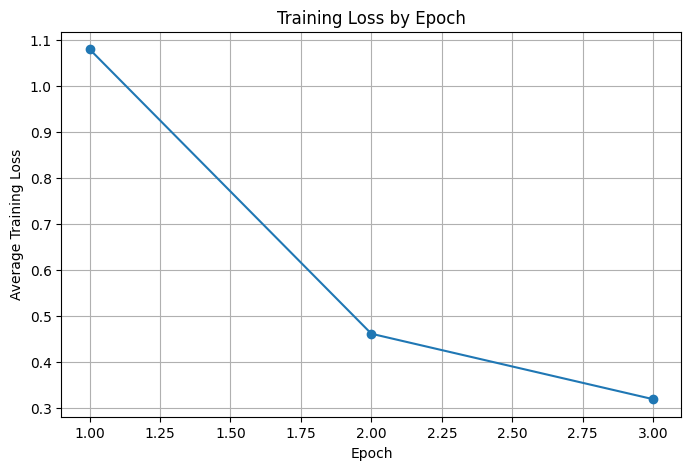

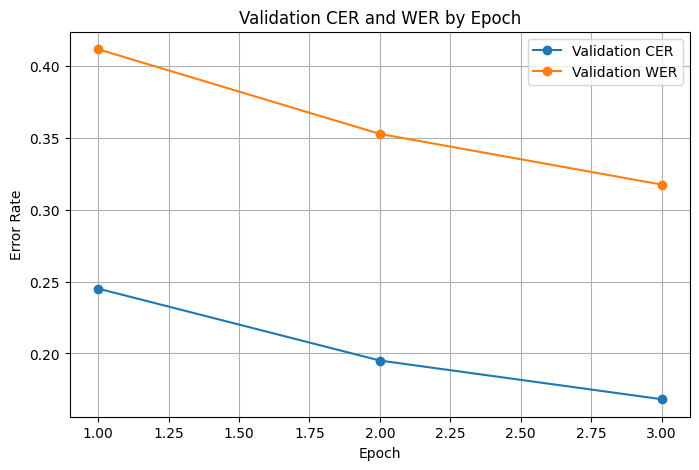

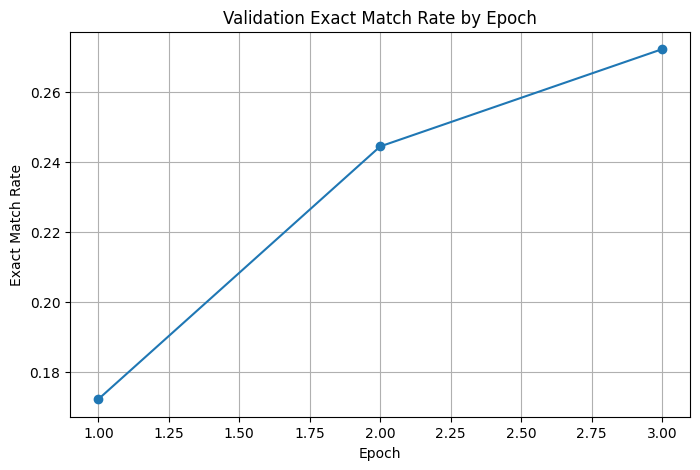

Saved graphs to: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/graphs


In [23]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

BASE_DIR = Path("/teamspace/studios/this_studio")

FULL_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v1"
LOG_PATH = FULL_RUN_DIR / "logs" / "training_log.json"
GRAPH_DIR = FULL_RUN_DIR / "graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("Training log exists:", LOG_PATH.exists(), LOG_PATH)

with open(LOG_PATH, "r", encoding="utf-8") as f:
    log = json.load(f)

epochs = [int(str(x["epoch"]).replace("epoch_", "")) for x in log]
train_loss = [x["avg_train_loss"] for x in log]
val_cer = [x["avg_cer_clean"] for x in log]
val_wer = [x["avg_wer_clean"] for x in log]
exact_rate = [x["exact_clean_rate"] for x in log]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss by Epoch")
plt.grid(True)
plt.savefig(GRAPH_DIR / "training_loss_by_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, val_cer, marker="o", label="Validation CER")
plt.plot(epochs, val_wer, marker="o", label="Validation WER")
plt.xlabel("Epoch")
plt.ylabel("Error Rate")
plt.title("Validation CER and WER by Epoch")
plt.legend()
plt.grid(True)
plt.savefig(GRAPH_DIR / "validation_cer_wer_by_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, exact_rate, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Exact Match Rate")
plt.title("Validation Exact Match Rate by Epoch")
plt.grid(True)
plt.savefig(GRAPH_DIR / "validation_exact_match_by_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved graphs to:", GRAPH_DIR)

In [24]:
print("=" * 100)
print("TRAINING PROGRESS SUMMARY")
print("=" * 100)

for x in log:
    print(
        f"{x['epoch']} | "
        f"train_loss={x['avg_train_loss']:.4f} | "
        f"val_CER={x['avg_cer_clean']:.4f} | "
        f"val_WER={x['avg_wer_clean']:.4f} | "
        f"exact_rate={x['exact_clean_rate']:.4f} | "
        f"CER<=0.10={x['cer_clean_le_010']} | "
        f"CER<=0.20={x['cer_clean_le_020']} | "
        f"bad_CER>0.30={x['cer_clean_gt_030']}"
    )

TRAINING PROGRESS SUMMARY
epoch_1 | train_loss=1.0789 | val_CER=0.2451 | val_WER=0.4115 | exact_rate=0.1722 | CER<=0.10=69 | CER<=0.20=91 | bad_CER>0.30=54
epoch_2 | train_loss=0.4604 | val_CER=0.1951 | val_WER=0.3526 | exact_rate=0.2444 | CER<=0.10=83 | CER<=0.20=109 | bad_CER>0.30=47
epoch_3 | train_loss=0.3181 | val_CER=0.1682 | val_WER=0.3174 | exact_rate=0.2722 | CER<=0.10=94 | CER<=0.20=118 | bad_CER>0.30=36


## 13. Legal-to-number parser v1 + amount-level evaluation
OCR text accuracy isn't enough — two different Arabic strings can mean the same number. This section converts predicted text → integer using a rule-based parser with a dictionary covering ones, tens, hundreds, thousands, and filler words (`فقط`, `ريال`, `لا غير`, `وقدره`).

Two evaluation levels:

| Level | Question |
|---|---|
| OCR | Does the predicted text match exactly? |
| Amount | Does the parsed legal amount equal the GT amount? |

Initial v1 result: text exact match 27.2%, parsed amount match 56.1%.

In [1]:
from pathlib import Path
import csv
import json
import re
from collections import Counter, defaultdict

BASE_DIR = Path("/teamspace/studios/this_studio")

RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v1"
PRED_PATH = RUN_DIR / "predictions" / "val_predictions_epoch_3.csv"

POST_DIR = RUN_DIR / "postprocessing"
POST_DIR.mkdir(parents=True, exist_ok=True)

PARSED_OUT = POST_DIR / "val_legal_amount_parsed_v1.csv"
METRICS_OUT = POST_DIR / "legal_parser_metrics_v1.json"
UNKNOWN_WORDS_OUT = POST_DIR / "unknown_words_v1.csv"

print("Prediction file exists:", PRED_PATH.exists(), PRED_PATH)
print("Postprocessing folder:", POST_DIR)

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

rows = read_csv_rows(PRED_PATH)

print("Loaded rows:", len(rows))
print("Columns:", list(rows[0].keys()))

print("\nFirst row preview:")
for k in ["stem", "gt", "clean_pred", "cer_clean"]:
    print(k + ":", rows[0].get(k, ""))

Prediction file exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/predictions/val_predictions_epoch_3.csv
Postprocessing folder: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/postprocessing
Loaded rows: 180
Columns: ['stem', 'status', 'gt', 'raw_pred', 'clean_pred', 'cer_raw', 'wer_raw', 'cer_clean', 'wer_clean', 'exact_raw', 'exact_clean', 'too_long_raw', 'digit_heavy_raw']

First row preview:
stem: ac01485
gt: الف وثلاثمايه وسته وعشرون ريال لا غير
clean_pred: الف وثلاثمايه وستة وعشرون ريال لا غير
cer_clean: 0.02702702702702703


In [2]:
cer_values = [float(r["cer_clean"]) for r in rows]
wer_values = [float(r["wer_clean"]) for r in rows]

summary = {
    "rows": len(rows),
    "avg_cer_clean": sum(cer_values) / len(cer_values),
    "avg_wer_clean": sum(wer_values) / len(wer_values),
    "exact_clean": sum(str(r["exact_clean"]).lower() == "true" for r in rows),
    "cer_clean_le_010": sum(float(r["cer_clean"]) <= 0.10 for r in rows),
    "cer_clean_le_020": sum(float(r["cer_clean"]) <= 0.20 for r in rows),
    "cer_clean_gt_030": sum(float(r["cer_clean"]) > 0.30 for r in rows),
}

print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "rows": 180,
  "avg_cer_clean": 0.16816530825615497,
  "avg_wer_clean": 0.31738896905563596,
  "exact_clean": 49,
  "cer_clean_le_010": 94,
  "cer_clean_le_020": 118,
  "cer_clean_gt_030": 36
}


In [3]:
AR_DIACRITICS_RE = re.compile(r"[\u064B-\u065F\u0670]")
TATWEEL_RE = re.compile(r"ـ+")
MULTISPACE_RE = re.compile(r"\s+")
PUNCT_RE = re.compile(r"[^\w\s\u0600-\u06FF]")
DIGIT_RE = re.compile(r"[0-9\u0660-\u0669\u06F0-\u06F9]+")

def normalize_arabic_basic(text):
    text = str(text or "")
    text = text.replace("\u200f", " ").replace("\u200e", " ")
    text = AR_DIACRITICS_RE.sub("", text)
    text = TATWEEL_RE.sub("", text)

    text = re.sub(r"[أإآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ؤ", "و")
    text = text.replace("ئ", "ي")

    text = text.replace("لاغير", "لا غير")
    text = text.replace("لا غير", " لا غير ")

    text = PUNCT_RE.sub(" ", text)
    text = DIGIT_RE.sub(" ", text)

    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

def normalize_word_variants(text):
    text = normalize_arabic_basic(text)

    replacements = {
        "مايه": "ماية",
        "مائه": "ماية",
        "مائة": "ماية",
        "مئة": "ماية",
        "ميه": "ماية",
        "مية": "ماية",

        "مائتان": "مايتان",
        "ماتين": "مايتين",
        "ميتين": "مايتين",

        "ثلاثمايه": "ثلاثماية",
        "ثلاثمائة": "ثلاثماية",
        "ثلاثمائه": "ثلاثماية",

        "اربعمايه": "اربعماية",
        "اربعمائة": "اربعماية",
        "اربعمائه": "اربعماية",

        "خمسمايه": "خمسماية",
        "خمسمائة": "خمسماية",
        "خمسمائه": "خمسماية",
        "خمسمايه": "خمسماية",

        "ستمايه": "ستماية",
        "ستمائة": "ستماية",
        "ستمائه": "ستماية",

        "سبعمايه": "سبعماية",
        "سبعمائة": "سبعماية",
        "سبعمائه": "سبعماية",

        "ثمانمايه": "ثمانماية",
        "ثمانمائة": "ثمانماية",
        "ثمانمائه": "ثمانماية",

        "تسعمايه": "تسعماية",
        "تسعمائة": "تسعماية",
        "تسعمائه": "تسعماية",

        "الفا": "الف",
        "الاف": "الف",
        "آلاف": "الف",
        "اف": "الف",

        "ريالا": "ريال",
        "ريالات": "ريال",
        "رسالا": "ريال",
        "رسال": "ريال",

        "عشره": "عشرة",
        "تسعه": "تسعة",
        "اربعه": "اربعة",
        "ثلاثه": "ثلاثة",
        "واحده": "واحدة",
        "سته": "ستة",
        "ثمانيه": "ثمانية",
    }

    words = text.split()
    words = [replacements.get(w, w) for w in words]
    return " ".join(words)

# Quick test examples
examples = [
    "فقط خمسة الاف وخمسمائة ريال لا غير",
    "لاغير الف وثلاثمائه ريال",
    "وقدره خمسمايه الف ريال فقط",
]

for ex in examples:
    print("RAW :", ex)
    print("NORM:", normalize_word_variants(ex))
    print("-" * 80)

RAW : فقط خمسة الاف وخمسمائة ريال لا غير
NORM: فقط خمسة الف وخمسماية ريال لا غير
--------------------------------------------------------------------------------
RAW : لاغير الف وثلاثمائه ريال
NORM: لا غير الف وثلاثمايه ريال
--------------------------------------------------------------------------------
RAW : وقدره خمسمايه الف ريال فقط
NORM: وقدره خمسماية الف ريال فقط
--------------------------------------------------------------------------------


In [4]:
gt_word_counts = Counter()
pred_word_counts = Counter()

for r in rows:
    gt_norm = normalize_word_variants(r["gt"])
    pred_norm = normalize_word_variants(r["clean_pred"])

    gt_word_counts.update(gt_norm.split())
    pred_word_counts.update(pred_norm.split())

print("=" * 100)
print("Top GT words")
print("=" * 100)
for word, count in gt_word_counts.most_common(40):
    print(word, count)

print("\n" + "=" * 100)
print("Top prediction words")
print("=" * 100)
for word, count in pred_word_counts.most_common(40):
    print(word, count)

all_words = sorted(set(gt_word_counts) | set(pred_word_counts))
print("\nUnique normalized words:", len(all_words))

Top GT words
ريال 171
الف 140
لا 107
غير 107
فقط 92
وعشرون 29
عشر 25
اربعة 23
خمسة 20
ثلاثة 20
وخمسون 17
وثلاثون 15
ماية 12
وسبعون 12
وقدره 10
واثنان 10
وثمانون 10
وخمسمايه 10
سبعة 8
وستون 8
الفان 7
وستماية 7
وثلاثماية 7
وسبعماية 7
وخمسماية 7
الفين 7
وثلاثمايه 6
وخمسة 6
وتسعمايه 6
وسبعه 6
وستة 6
وتسعماية 6
ستة 6
ثلاثماية 6
وثمانيه 6
وسته 5
عشرة 5
وميتان 5
وسبعمايه 5
ستماية 5

Top prediction words
ريال 175
الف 142
لا 137
غير 137
فقط 93
وعشرون 30
عشر 24
اربعة 22
ثلاثة 22
خمسة 20
وخمسون 18
وثلاثون 17
وخمسمايه 13
وثمانون 12
وثلاثمايه 9
وستة 9
الفان 9
وتسعماية 9
وقدره 9
سبعة 9
ومايتان 9
وثمانية 9
وخمسة 8
واربعون 8
وستماية 8
ماية 8
وسبعون 8
وسبعه 7
واثنان 7
وثمانمايه 7
ثلاثماية 7
ستة 7
وخمسماية 7
عشرة 6
وسبعمايه 6
وتسعون 6
و 6
الفين 6
وسبعماية 5
وسبعة 5

Unique normalized words: 131


In [5]:
FILLER_WORDS = {
    "فقط", "ريال", "لا", "غير", "وقدره", "وقدرة", "قدره", "قدرة",
    "مبلغ", "سعودي", "سعودية", "مقابل", "على", "الحساب", "حساب",
    "و", "هللة", "هلله", "هلاله", "هلالة"
}

NUMBER_WORDS = {
    # zero and one
    "صفر", "واحد", "واحدة", "احد", "احدى",

    # two
    "اثنين", "اثنان", "اثنتين", "اثنتان", "اثني", "اثنا", "اثنتا",

    # three to nine
    "ثلاثة", "ثلاث", "اربعة", "اربع", "خمسة", "خمس",
    "ستة", "ست", "سبعة", "سبع", "ثمانية", "ثمان", "تسعة", "تسع",

    # ten to nineteen
    "عشرة", "عشر", "احد عشر", "احدى عشرة",
    "اثنا عشر", "اثني عشر", "اثنتا عشرة", "اثنتي عشرة",
    "ثلاثة عشر", "ثلاث عشر",
    "اربعة عشر", "اربع عشر",
    "خمسة عشر", "خمس عشر",
    "ستة عشر", "ست عشر",
    "سبعة عشر", "سبع عشر",
    "ثمانية عشر", "ثمان عشر",
    "تسعة عشر", "تسع عشر",

    # tens
    "عشرون", "عشرين",
    "ثلاثون", "ثلاثين",
    "اربعون", "اربعين",
    "خمسون", "خمسين",
    "ستون", "ستين",
    "سبعون", "سبعين",
    "ثمانون", "ثمانين",
    "تسعون", "تسعين",

    # hundreds
    "ماية", "مايتان", "مايتين",
    "ثلاثماية", "اربعماية", "خمسماية", "ستماية",
    "سبعماية", "ثمانماية", "تسعماية",

    # thousands
    "الف", "الفين", "الفي", "الفان",
}

KNOWN_SINGLE_WORDS = set()
for phrase in NUMBER_WORDS:
    for w in phrase.split():
        KNOWN_SINGLE_WORDS.add(w)

KNOWN_SINGLE_WORDS |= FILLER_WORDS

unknown_counter = Counter()

for r in rows:
    for source_col in ["gt", "clean_pred"]:
        norm = normalize_word_variants(r[source_col])
        for w in norm.split():
            if w not in KNOWN_SINGLE_WORDS:
                unknown_counter[w] += 1

unknown_rows = [
    {"word": word, "count": count}
    for word, count in unknown_counter.most_common()
]

if unknown_rows:
    write_csv_rows(UNKNOWN_WORDS_OUT, unknown_rows, ["word", "count"])

print("Known single words:", len(KNOWN_SINGLE_WORDS))
print("Unknown words:", len(unknown_rows))
print("Saved unknown words:", UNKNOWN_WORDS_OUT)

print("\nTop unknown words:")
for x in unknown_rows[:50]:
    print(x)

Known single words: 79
Unknown words: 84
Saved unknown words: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/postprocessing/unknown_words_v1.csv

Top unknown words:
{'word': 'وعشرون', 'count': 59}
{'word': 'وخمسون', 'count': 35}
{'word': 'وثلاثون', 'count': 32}
{'word': 'وخمسمايه', 'count': 23}
{'word': 'وثمانون', 'count': 22}
{'word': 'وسبعون', 'count': 20}
{'word': 'واثنان', 'count': 17}
{'word': 'وثلاثمايه', 'count': 15}
{'word': 'وستة', 'count': 15}
{'word': 'وستماية', 'count': 15}
{'word': 'وتسعماية', 'count': 15}
{'word': 'وخمسة', 'count': 14}
{'word': 'ومايتان', 'count': 14}
{'word': 'وخمسماية', 'count': 14}
{'word': 'واربعون', 'count': 13}
{'word': 'وسبعه', 'count': 13}
{'word': 'وستون', 'count': 13}
{'word': 'وسبعماية', 'count': 12}
{'word': 'وثمانية', 'count': 12}
{'word': 'وسبعمايه', 'count': 11}
{'word': 'وثلاثماية', 'count': 10}
{'word': 'وثمانمايه', 'count': 10}
{'word': 'وتسعمايه', 'count': 9}
{'word': 'وماية', 'count': 9}
{'word': 'وسته', 'co

In [6]:
def normalize_single_word(word):
    word = str(word or "").strip()

    replacements = {
        # hundred variants
        "مايه": "ماية",
        "مائه": "ماية",
        "مائة": "ماية",
        "مئة": "ماية",
        "ميه": "ماية",
        "مية": "ماية",

        "مائتان": "مايتان",
        "ماتين": "مايتين",
        "ميتين": "مايتين",
        "ميتان": "مايتان",

        "ثلاثمايه": "ثلاثماية",
        "ثلاثمائة": "ثلاثماية",
        "ثلاثمائه": "ثلاثماية",

        "اربعمايه": "اربعماية",
        "اربعمائة": "اربعماية",
        "اربعمائه": "اربعماية",

        "خمسمايه": "خمسماية",
        "خمسمائة": "خمسماية",
        "خمسمائه": "خمسماية",

        "ستمايه": "ستماية",
        "ستمائة": "ستماية",
        "ستمائه": "ستماية",

        "سبعمايه": "سبعماية",
        "سبعمائة": "سبعماية",
        "سبعمائه": "سبعماية",

        "ثمانمايه": "ثمانماية",
        "ثمانمائة": "ثمانماية",
        "ثمانمائه": "ثمانماية",

        "تسعمايه": "تسعماية",
        "تسعمائة": "تسعماية",
        "تسعمائه": "تسعماية",

        # thousand variants
        "الفا": "الف",
        "الاف": "الف",
        "آلاف": "الف",
        "اف": "الف",

        # currency variants
        "ريالا": "ريال",
        "ريالات": "ريال",
        "رسالا": "ريال",
        "رسال": "ريال",

        # common spelling variants
        "عشره": "عشرة",
        "تسعه": "تسعة",
        "اربعه": "اربعة",
        "ثلاثه": "ثلاثة",
        "واحده": "واحدة",
        "سته": "ستة",
        "سبعه": "سبعة",
        "ثمانيه": "ثمانية",
        "خمسه": "خمسة",
    }

    return replacements.get(word, word)

BASE_KNOWN_NUMBER_WORDS = {
    "صفر",
    "واحد", "واحدة", "احد", "احدى",
    "اثنين", "اثنان", "اثنتين", "اثنتان", "اثني", "اثنا", "اثنتا",
    "ثلاثة", "ثلاث",
    "اربعة", "اربع",
    "خمسة", "خمس",
    "ستة", "ست",
    "سبعة", "سبع",
    "ثمانية", "ثمان",
    "تسعة", "تسع",
    "عشرة", "عشر",
    "عشرون", "عشرين",
    "ثلاثون", "ثلاثين",
    "اربعون", "اربعين",
    "خمسون", "خمسين",
    "ستون", "ستين",
    "سبعون", "سبعين",
    "ثمانون", "ثمانين",
    "تسعون", "تسعين",
    "ماية", "مايتان", "مايتين",
    "ثلاثماية", "اربعماية", "خمسماية", "ستماية",
    "سبعماية", "ثمانماية", "تسعماية",
    "الف", "الفان", "الفين", "الفي",
}

BASE_FILLER_WORDS = {
    "فقط", "ريال", "لا", "غير", "لاغير",
    "وقدره", "وقدرة", "قدره", "قدرة",
    "مبلغ", "سعودي", "سعودية",
    "مقابل", "على", "الحساب", "حساب",
    "هللة", "هلله", "هلاله", "هلالة",
    "و",
}

KNOWN_AFTER_SPLIT = BASE_KNOWN_NUMBER_WORDS | BASE_FILLER_WORDS

def tokenize_legal_text(text):
    text = normalize_arabic_basic(text)

    # Fix common no-space cases seen in the validation data.
    text = text.replace("عشرالف", "عشرة الف")
    text = text.replace("عشر الف", "عشرة الف")
    text = text.replace("لاغير", "لا غير")

    raw_words = text.split()
    tokens = []

    for raw_word in raw_words:
        word = normalize_single_word(raw_word)

        # Keep direct known words.
        if word in KNOWN_AFTER_SPLIT:
            tokens.append(word)
            continue

        # Split leading و only if the remaining part is a known amount word after normalization.
        # Examples: وعشرون -> و + عشرون, وخمسمايه -> و + خمسماية
        if word.startswith("و") and len(word) > 2:
            suffix = normalize_single_word(word[1:])

            if suffix in KNOWN_AFTER_SPLIT:
                tokens.append("و")
                tokens.append(suffix)
                continue

        # Keep unresolved token for inspection.
        tokens.append(word)

    return tokens

def normalize_legal_for_parser(text):
    return " ".join(tokenize_legal_text(text))

# Quick tests
test_examples = [
    "وعشرون",
    "وخمسون",
    "وثلاثمايه",
    "ومايتان",
    "وواحد",
    "وقدره الف ريال لا غير",
    "عشرالف ريال فقط",
]

for ex in test_examples:
    print("RAW   :", ex)
    print("TOKENS:", tokenize_legal_text(ex))
    print("NORM  :", normalize_legal_for_parser(ex))
    print("-" * 80)

RAW   : وعشرون
TOKENS: ['و', 'عشرون']
NORM  : و عشرون
--------------------------------------------------------------------------------
RAW   : وخمسون
TOKENS: ['و', 'خمسون']
NORM  : و خمسون
--------------------------------------------------------------------------------
RAW   : وثلاثمايه
TOKENS: ['و', 'ثلاثماية']
NORM  : و ثلاثماية
--------------------------------------------------------------------------------
RAW   : ومايتان
TOKENS: ['و', 'مايتان']
NORM  : و مايتان
--------------------------------------------------------------------------------
RAW   : وواحد
TOKENS: ['و', 'واحد']
NORM  : و واحد
--------------------------------------------------------------------------------
RAW   : وقدره الف ريال لا غير
TOKENS: ['وقدره', 'الف', 'ريال', 'لا', 'غير']
NORM  : وقدره الف ريال لا غير
--------------------------------------------------------------------------------
RAW   : عشرالف ريال فقط
TOKENS: ['عشرة', 'الف', 'ريال', 'فقط']
NORM  : عشرة الف ريال فقط
----------------------------------------

In [7]:
gt_word_counts_v2 = Counter()
pred_word_counts_v2 = Counter()

for r in rows:
    gt_tokens = tokenize_legal_text(r["gt"])
    pred_tokens = tokenize_legal_text(r["clean_pred"])

    gt_word_counts_v2.update(gt_tokens)
    pred_word_counts_v2.update(pred_tokens)

print("=" * 100)
print("Top GT tokens after tokenizer fix")
print("=" * 100)
for word, count in gt_word_counts_v2.most_common(40):
    print(word, count)

print("\n" + "=" * 100)
print("Top prediction tokens after tokenizer fix")
print("=" * 100)
for word, count in pred_word_counts_v2.most_common(40):
    print(word, count)

unknown_counter_v2 = Counter()

for r in rows:
    for source_col in ["gt", "clean_pred"]:
        for w in tokenize_legal_text(r[source_col]):
            if w not in KNOWN_AFTER_SPLIT:
                unknown_counter_v2[w] += 1

unknown_rows_v2 = [
    {"word": word, "count": count}
    for word, count in unknown_counter_v2.most_common()
]

UNKNOWN_WORDS_OUT_V2 = POST_DIR / "unknown_words_v2.csv"

if unknown_rows_v2:
    write_csv_rows(UNKNOWN_WORDS_OUT_V2, unknown_rows_v2, ["word", "count"])

print("\nKnown tokens:", len(KNOWN_AFTER_SPLIT))
print("Unknown tokens after fix:", len(unknown_rows_v2))
print("Saved unknown words:", UNKNOWN_WORDS_OUT_V2)

print("\nTop unknown tokens after fix:")
for x in unknown_rows_v2[:50]:
    print(x)

Top GT tokens after tokenizer fix
و 279
ريال 171
الف 142
لا 107
غير 107
فقط 92
عشرون 32
اربعة 30
خمسة 29
عشرة 26
ثلاثة 24
ماية 21
ثلاثماية 19
خمسماية 19
ثلاثون 18
سبعة 18
خمسون 18
ستة 17
ستماية 15
سبعماية 14
تسعماية 14
اثنان 13
سبعون 13
مايتان 12
تسعة 11
ثمانية 11
وقدره 10
ثمانون 10
ستون 10
عشر 9
ثمانماية 9
اربعماية 9
اربعون 8
الفان 7
الفين 7
واحد 6
ثلاث 4
ثمانين 2
ه 2
تسعون 2

Top prediction tokens after tokenizer fix
و 292
ريال 175
الف 142
لا 137
غير 137
فقط 93
خمسة 33
عشرون 32
اربعة 28
ثلاثة 27
سبعة 23
عشرة 22
خمسماية 21
ثلاثماية 19
ستة 19
ثلاثون 19
خمسون 19
ستماية 16
ماية 15
تسعماية 15
سبعماية 13
ثمانماية 13
مايتان 13
ثمانية 13
ثمانون 12
الفان 9
عشر 9
وقدره 9
اربعون 8
واحد 8
اثنان 8
سبعون 8
تسعة 7
تسعون 6
الفين 6
ستون 5
اربعماية 5
تسع 2
خمس 2
خمسين 2

Known tokens: 79
Unknown tokens after fix: 25
Saved unknown words: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/postprocessing/unknown_words_v2.csv

Top unknown tokens after fix:
{'word': 'ه', 'count': 2}

In [8]:
def normalize_single_word_v2(word):
    word = str(word or "").strip()

    replacements = {
        # hundred variants
        "مايه": "ماية",
        "مائه": "ماية",
        "مائة": "ماية",
        "مئة": "ماية",
        "ميه": "ماية",
        "مية": "ماية",

        "مائتان": "مايتان",
        "ماتين": "مايتين",
        "ميتين": "مايتين",
        "ميتان": "مايتان",
        "ميتا": "مايتان",
        "ميتار": "مايتان",

        "ثلاثمايه": "ثلاثماية",
        "ثلاثمائة": "ثلاثماية",
        "ثلاثمائه": "ثلاثماية",

        "اربعمايه": "اربعماية",
        "اربعمائة": "اربعماية",
        "اربعمائه": "اربعماية",
        "اربعةماية": "اربعماية",
        "ربعماية": "اربعماية",

        "خمسمايه": "خمسماية",
        "خمسمائة": "خمسماية",
        "خمسمائه": "خمسماية",
        "خمسايه": "خمسماية",
        "خمساية": "خمسماية",

        "ستمايه": "ستماية",
        "ستمائة": "ستماية",
        "ستمائه": "ستماية",
        "ستميه": "ستماية",

        "سبعمايه": "سبعماية",
        "سبعمائة": "سبعماية",
        "سبعمائه": "سبعماية",

        "ثمانمايه": "ثمانماية",
        "ثمانمائة": "ثمانماية",
        "ثمانمائه": "ثمانماية",
        "ثمانميه": "ثمانماية",
        "ثمانيمايه": "ثمانماية",

        "تسعمايه": "تسعماية",
        "تسعمائة": "تسعماية",
        "تسعمائه": "تسعماية",

        # thousand variants
        "الفا": "الف",
        "الاف": "الف",
        "آلاف": "الف",
        "اف": "الف",

        # currency variants
        "ريالا": "ريال",
        "ريالات": "ريال",
        "رسالا": "ريال",
        "رسال": "ريال",

        # common spelling variants
        "عشره": "عشرة",
        "تسعه": "تسعة",
        "اربعه": "اربعة",
        "ارعة": "اربعة",
        "ثلاثه": "ثلاثة",
        "واحده": "واحدة",
        "واحدي": "واحد",
        "سته": "ستة",
        "سبعه": "سبعة",
        "ثمانيه": "ثمانية",
        "خمسه": "خمسة",
    }

    return replacements.get(word, word)

NUMBER_VALUES = {
    "صفر": 0,

    "واحد": 1,
    "واحدة": 1,
    "احد": 1,
    "احدى": 1,

    "اثنين": 2,
    "اثنان": 2,
    "اثنتين": 2,
    "اثنتان": 2,
    "اثني": 2,
    "اثنا": 2,
    "اثنتا": 2,

    "ثلاثة": 3,
    "ثلاث": 3,

    "اربعة": 4,
    "اربع": 4,

    "خمسة": 5,
    "خمس": 5,

    "ستة": 6,
    "ست": 6,

    "سبعة": 7,
    "سبع": 7,

    "ثمانية": 8,
    "ثمان": 8,

    "تسعة": 9,
    "تسع": 9,

    "عشرة": 10,
    "عشر": 10,

    "عشرون": 20,
    "عشرين": 20,

    "ثلاثون": 30,
    "ثلاثين": 30,

    "اربعون": 40,
    "اربعين": 40,

    "خمسون": 50,
    "خمسين": 50,

    "ستون": 60,
    "ستين": 60,

    "سبعون": 70,
    "سبعين": 70,

    "ثمانون": 80,
    "ثمانين": 80,

    "تسعون": 90,
    "تسعين": 90,

    "ماية": 100,
    "مايتان": 200,
    "مايتين": 200,

    "ثلاثماية": 300,
    "اربعماية": 400,
    "خمسماية": 500,
    "ستماية": 600,
    "سبعماية": 700,
    "ثمانماية": 800,
    "تسعماية": 900,

    "الفين": 2000,
    "الفان": 2000,
    "الفي": 2000,
}

MULTIPLIERS = {
    "الف": 1000,
    "مليون": 1000000,
}

IGNORE_WORDS = {
    "و",
    "فقط",
    "ريال",
    "لا",
    "غير",
    "لاغير",
    "وقدره",
    "وقدرة",
    "قدره",
    "قدرة",
    "مبلغ",
    "سعودي",
    "سعودية",
    "مقابل",
    "على",
    "الحساب",
    "حساب",
    "هللة",
    "هلله",
    "هلاله",
    "هلالة",
    "رسوم",
    "جمركيه",
    "امانه",
    "ه",
}

KNOWN_FOR_TOKENIZER_V2 = set(NUMBER_VALUES) | set(MULTIPLIERS) | IGNORE_WORDS

def tokenize_legal_text_v2(text):
    text = normalize_arabic_basic(text)

    # Known no-space cases.
    text = text.replace("عشرالف", "عشرة الف")
    text = text.replace("عشر الف", "عشرة الف")
    text = text.replace("لاغير", "لا غير")

    raw_words = text.split()
    tokens = []

    for raw_word in raw_words:
        word = normalize_single_word_v2(raw_word)

        if word in KNOWN_FOR_TOKENIZER_V2:
            tokens.append(word)
            continue

        # Handle attached و repeatedly.
        # Example: وواثنان -> و و اثنان
        while word.startswith("و") and len(word) > 2:
            suffix = normalize_single_word_v2(word[1:])
            tokens.append("و")
            word = suffix

            if word in KNOWN_FOR_TOKENIZER_V2:
                tokens.append(word)
                word = ""
                break

        if word:
            tokens.append(word)

    return tokens

def parse_legal_amount_direct(text):
    tokens = tokenize_legal_text_v2(text)

    total = 0
    current = 0
    unknown = []
    used_number_tokens = []
    multiplier_count = 0

    for token in tokens:
        if token in IGNORE_WORDS:
            continue

        if token in NUMBER_VALUES:
            value = NUMBER_VALUES[token]

            # If token is generic "ماية" after a small number, handle "خمس ماية" style.
            if token == "ماية" and 1 <= current <= 9:
                current = current * 100
            else:
                current += value

            used_number_tokens.append(token)
            continue

        if token in MULTIPLIERS:
            multiplier = MULTIPLIERS[token]
            multiplier_count += 1

            if current == 0:
                current = 1

            total += current * multiplier
            current = 0
            used_number_tokens.append(token)
            continue

        unknown.append(token)

    total += current

    if not used_number_tokens:
        return {
            "amount": None,
            "status": "no_number_tokens",
            "tokens": tokens,
            "unknown": unknown,
            "multiplier_count": multiplier_count,
        }

    if unknown:
        return {
            "amount": total,
            "status": "parsed_with_unknown",
            "tokens": tokens,
            "unknown": unknown,
            "multiplier_count": multiplier_count,
        }

    return {
        "amount": total,
        "status": "parsed_ok",
        "tokens": tokens,
        "unknown": unknown,
        "multiplier_count": multiplier_count,
    }

# Quick parser tests
test_amounts = [
    "عشرة الاف ريال فقط لا غير",
    "الف وخمسة وعشرون ريال لا غير",
    "ثمانمايه وتسعه ريال فقط لا غير",
    "خمسماية الف ريال",
    "فقط ثلاثة الاف وستميه",
    "وقدره الف وثمانمايه ريال لا غير",
    "الفان وميتان وثلاثون ريال لا غير",
    "خمسة عشر الف وتسعون ريال",
]

for text in test_amounts:
    result = parse_legal_amount_direct(text)
    print("=" * 80)
    print("TEXT   :", text)
    print("TOKENS :", result["tokens"])
    print("AMOUNT :", result["amount"])
    print("STATUS :", result["status"])
    print("UNKNOWN:", result["unknown"])

TEXT   : عشرة الاف ريال فقط لا غير
TOKENS : ['عشرة', 'الف', 'ريال', 'فقط', 'لا', 'غير']
AMOUNT : 10000
STATUS : parsed_ok
UNKNOWN: []
TEXT   : الف وخمسة وعشرون ريال لا غير
TOKENS : ['الف', 'و', 'خمسة', 'و', 'عشرون', 'ريال', 'لا', 'غير']
AMOUNT : 1025
STATUS : parsed_ok
UNKNOWN: []
TEXT   : ثمانمايه وتسعه ريال فقط لا غير
TOKENS : ['ثمانماية', 'و', 'تسعة', 'ريال', 'فقط', 'لا', 'غير']
AMOUNT : 809
STATUS : parsed_ok
UNKNOWN: []
TEXT   : خمسماية الف ريال
TOKENS : ['خمسماية', 'الف', 'ريال']
AMOUNT : 500000
STATUS : parsed_ok
UNKNOWN: []
TEXT   : فقط ثلاثة الاف وستميه
TOKENS : ['فقط', 'ثلاثة', 'الف', 'و', 'ستماية']
AMOUNT : 3600
STATUS : parsed_ok
UNKNOWN: []
TEXT   : وقدره الف وثمانمايه ريال لا غير
TOKENS : ['وقدره', 'الف', 'و', 'ثمانماية', 'ريال', 'لا', 'غير']
AMOUNT : 1800
STATUS : parsed_ok
UNKNOWN: []
TEXT   : الفان وميتان وثلاثون ريال لا غير
TOKENS : ['الفان', 'و', 'مايتان', 'و', 'ثلاثون', 'ريال', 'لا', 'غير']
AMOUNT : 2230
STATUS : parsed_ok
UNKNOWN: []
TEXT   : خمسة عشر الف وتسعون ري

In [9]:
parsed_rows = []

for r in rows:
    gt_text = r["gt"]
    pred_text = r["clean_pred"]

    gt_parse = parse_legal_amount_direct(gt_text)
    pred_parse = parse_legal_amount_direct(pred_text)

    gt_amount = gt_parse["amount"]
    pred_amount = pred_parse["amount"]

    amount_match = (
        gt_amount is not None
        and pred_amount is not None
        and gt_amount == pred_amount
    )

    parsed_rows.append({
        "stem": r["stem"],
        "status": r.get("status", ""),
        "gt": gt_text,
        "clean_pred": pred_text,
        "cer_clean": r["cer_clean"],
        "wer_clean": r["wer_clean"],

        "gt_tokens": " ".join(gt_parse["tokens"]),
        "pred_tokens": " ".join(pred_parse["tokens"]),

        "gt_amount": "" if gt_amount is None else gt_amount,
        "pred_amount": "" if pred_amount is None else pred_amount,

        "amount_match": amount_match,

        "gt_parse_status": gt_parse["status"],
        "pred_parse_status": pred_parse["status"],

        "gt_unknown": "|".join(gt_parse["unknown"]),
        "pred_unknown": "|".join(pred_parse["unknown"]),

        "exact_clean": r["exact_clean"],
    })

amount_match_count = sum(r["amount_match"] for r in parsed_rows)
gt_parse_ok = sum(r["gt_amount"] != "" for r in parsed_rows)
pred_parse_ok = sum(r["pred_amount"] != "" for r in parsed_rows)

metrics = {
    "rows": len(parsed_rows),
    "gt_parse_available": gt_parse_ok,
    "pred_parse_available": pred_parse_ok,
    "amount_match_count": amount_match_count,
    "amount_match_rate": amount_match_count / len(parsed_rows),
    "exact_text_count": sum(str(r["exact_clean"]).lower() == "true" for r in parsed_rows),
    "exact_text_rate": sum(str(r["exact_clean"]).lower() == "true" for r in parsed_rows) / len(parsed_rows),
    "gt_parse_status_counts": dict(Counter(r["gt_parse_status"] for r in parsed_rows)),
    "pred_parse_status_counts": dict(Counter(r["pred_parse_status"] for r in parsed_rows)),
}

write_csv_rows(PARSED_OUT, parsed_rows, list(parsed_rows[0].keys()))

with open(METRICS_OUT, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print(json.dumps(metrics, ensure_ascii=False, indent=2))
print("Saved parsed results:", PARSED_OUT)
print("Saved parser metrics:", METRICS_OUT)

{
  "rows": 180,
  "gt_parse_available": 180,
  "pred_parse_available": 180,
  "amount_match_count": 101,
  "amount_match_rate": 0.5611111111111111,
  "exact_text_count": 49,
  "exact_text_rate": 0.2722222222222222,
  "gt_parse_status_counts": {
    "parsed_ok": 178,
    "parsed_with_unknown": 2
  },
  "pred_parse_status_counts": {
    "parsed_ok": 174,
    "parsed_with_unknown": 6
  }
}
Saved parsed results: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/postprocessing/val_legal_amount_parsed_v1.csv
Saved parser metrics: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/postprocessing/legal_parser_metrics_v1.json


In [10]:
text_wrong_amount_right = [
    r for r in parsed_rows
    if str(r["exact_clean"]).lower() != "true" and r["amount_match"]
]

amount_wrong = [
    r for r in parsed_rows
    if not r["amount_match"]
]

amount_wrong_sorted = sorted(amount_wrong, key=lambda r: float(r["cer_clean"]), reverse=True)

print("=" * 100)
print("TEXT WRONG BUT AMOUNT RIGHT")
print("=" * 100)
print("Count:", len(text_wrong_amount_right))

for r in text_wrong_amount_right[:15]:
    print("-" * 100)
    print("Stem:", r["stem"], "| CER:", r["cer_clean"])
    print("GT amount:", r["gt_amount"], "| Pred amount:", r["pred_amount"])
    print("GT  :", r["gt"])
    print("PRED:", r["clean_pred"])

print("\n" + "=" * 100)
print("AMOUNT WRONG OR PARSE FAILED")
print("=" * 100)
print("Count:", len(amount_wrong))

for r in amount_wrong_sorted[:20]:
    print("-" * 100)
    print("Stem:", r["stem"], "| CER:", r["cer_clean"])
    print("GT amount:", r["gt_amount"], "| Pred amount:", r["pred_amount"])
    print("GT parse:", r["gt_parse_status"], "| Pred parse:", r["pred_parse_status"])
    print("GT unknown:", r["gt_unknown"])
    print("Pred unknown:", r["pred_unknown"])
    print("GT  :", r["gt"])
    print("PRED:", r["clean_pred"])

TEXT WRONG BUT AMOUNT RIGHT
Count: 52
----------------------------------------------------------------------------------------------------
Stem: ac01485 | CER: 0.02702702702702703
GT amount: 1326 | Pred amount: 1326
GT  : الف وثلاثمايه وسته وعشرون ريال لا غير
PRED: الف وثلاثمايه وستة وعشرون ريال لا غير
----------------------------------------------------------------------------------------------------
Stem: ac00646 | CER: 0.4
GT amount: 10000 | Pred amount: 10000
GT  : عشر الاف ريال لا غير
PRED: عشرة الاف ريال
----------------------------------------------------------------------------------------------------
Stem: ac00985 | CER: 0.09090909090909091
GT amount: 5700 | Pred amount: 5700
GT  : خمسة الف وسبعمايه ريال
PRED: خمسة الاف وسبعماية ريال
----------------------------------------------------------------------------------------------------
Stem: ac00601 | CER: 0.047619047619047616
GT amount: 9000 | Pred amount: 9000
GT  : تسعة الاف ريال لا غير
PRED: تسع الاف ريال لا غير
-------------

In [11]:
from pathlib import Path
import json
import csv
from collections import Counter

BASE_DIR = Path("/teamspace/studios/this_studio")

RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v1"
POST_DIR = RUN_DIR / "postprocessing"

PARSED_OUT = POST_DIR / "val_legal_amount_parsed_v1.csv"
REPORT_SUMMARY_OUT = POST_DIR / "stage8_parser_report_summary_v1.json"
AMOUNT_WRONG_OUT = POST_DIR / "amount_wrong_cases_v1.csv"
TEXT_WRONG_AMOUNT_RIGHT_OUT = POST_DIR / "text_wrong_amount_right_v1.csv"

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

parsed_rows = read_csv_rows(PARSED_OUT)

text_exact = [
    r for r in parsed_rows
    if str(r["exact_clean"]).lower() == "true"
]

amount_match = [
    r for r in parsed_rows
    if str(r["amount_match"]).lower() == "true"
]

text_wrong_amount_right = [
    r for r in parsed_rows
    if str(r["exact_clean"]).lower() != "true"
    and str(r["amount_match"]).lower() == "true"
]

amount_wrong = [
    r for r in parsed_rows
    if str(r["amount_match"]).lower() != "true"
]

summary = {
    "samples": len(parsed_rows),
    "ocr_exact_text_count": len(text_exact),
    "ocr_exact_text_rate": len(text_exact) / len(parsed_rows),
    "legal_amount_match_count": len(amount_match),
    "legal_amount_match_rate": len(amount_match) / len(parsed_rows),
    "extra_correct_after_parsing": len(text_wrong_amount_right),
    "amount_wrong_or_failed_count": len(amount_wrong),
    "gt_parse_status_counts": dict(Counter(r["gt_parse_status"] for r in parsed_rows)),
    "pred_parse_status_counts": dict(Counter(r["pred_parse_status"] for r in parsed_rows)),
}

with open(REPORT_SUMMARY_OUT, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

write_csv_rows(
    TEXT_WRONG_AMOUNT_RIGHT_OUT,
    text_wrong_amount_right,
    list(parsed_rows[0].keys())
)

write_csv_rows(
    AMOUNT_WRONG_OUT,
    amount_wrong,
    list(parsed_rows[0].keys())
)

print("=" * 100)
print("STAGE 8 PARSER SUMMARY")
print("=" * 100)
print(json.dumps(summary, ensure_ascii=False, indent=2))

print("\nSaved:")
print(REPORT_SUMMARY_OUT)
print(TEXT_WRONG_AMOUNT_RIGHT_OUT)
print(AMOUNT_WRONG_OUT)

STAGE 8 PARSER SUMMARY
{
  "samples": 180,
  "ocr_exact_text_count": 49,
  "ocr_exact_text_rate": 0.2722222222222222,
  "legal_amount_match_count": 101,
  "legal_amount_match_rate": 0.5611111111111111,
  "extra_correct_after_parsing": 52,
  "amount_wrong_or_failed_count": 79,
  "gt_parse_status_counts": {
    "parsed_ok": 178,
    "parsed_with_unknown": 2
  },
  "pred_parse_status_counts": {
    "parsed_ok": 174,
    "parsed_with_unknown": 6
  }
}

Saved:
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/postprocessing/stage8_parser_report_summary_v1.json
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/postprocessing/text_wrong_amount_right_v1.csv
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/postprocessing/amount_wrong_cases_v1.csv


## 14. Continuation training (v2)
Resume from the best v1 LoRA adapter for 2 more epochs at a lower learning rate (5e-6). The model has already learned cheque-style legal text; refinement, not aggressive change.

| Setting | Value |
|---|---|
| Start point | v1 best epoch 3 adapter |
| Extra epochs | 2 |
| Learning rate | 5e-6 |
| Same train/val split, prompt, and crops | yes |


In [1]:
from pathlib import Path
import json
import random
import gc
import csv
import re
from collections import Counter

import torch
from torch.utils.data import Dataset

from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
from qwen_vl_utils import process_vision_info

from peft import PeftModel

BASE_DIR = Path("/teamspace/studios/this_studio")

MODEL_DIR = BASE_DIR / "models" / "Qwen3.5_model"

TRAIN_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "train.jsonl"
VAL_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "val.jsonl"

V1_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v1"
V1_BEST_ADAPTER = V1_RUN_DIR / "checkpoints" / "best_by_val_cer_clean"

V2_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v2_continue_from_epoch3"
V2_CHECKPOINT_DIR = V2_RUN_DIR / "checkpoints"
V2_PRED_DIR = V2_RUN_DIR / "predictions"
V2_METRIC_DIR = V2_RUN_DIR / "metrics"
V2_LOG_DIR = V2_RUN_DIR / "logs"
V2_GRAPH_DIR = V2_RUN_DIR / "graphs"

for p in [V2_RUN_DIR, V2_CHECKPOINT_DIR, V2_PRED_DIR, V2_METRIC_DIR, V2_LOG_DIR, V2_GRAPH_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42

CONTINUE_EPOCHS = 2
LEARNING_RATE = 5e-6
GRAD_ACCUM_STEPS = 8
MAX_GRAD_NORM = 1.0
MAX_NEW_TOKENS_VAL = 40

random.seed(SEED)
torch.manual_seed(SEED)

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

print("Base model:", MODEL_DIR)
print("V1 best adapter exists:", V1_BEST_ADAPTER.exists(), V1_BEST_ADAPTER)
print("Train JSONL exists:", TRAIN_JSONL.exists(), TRAIN_JSONL)
print("Val JSONL exists:", VAL_JSONL.exists(), VAL_JSONL)
print("V2 run folder:", V2_RUN_DIR)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
    print("BF16 supported:", torch.cuda.is_bf16_supported())

print("Using dtype:", DTYPE)

/teamspace/studios/this_studio/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Base model: /teamspace/studios/this_studio/models/Qwen3.5_model
V1 best adapter exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v1/checkpoints/best_by_val_cer_clean
Train JSONL exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/train.jsonl
Val JSONL exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/val.jsonl
V2 run folder: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3
Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU memory GB: 94.97
BF16 supported: True
Using dtype: torch.bfloat16


In [ ]:
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

train_records = read_jsonl(TRAIN_JSONL)
val_records = read_jsonl(VAL_JSONL)

random.shuffle(train_records)

print("Train records:", len(train_records))
print("Val records:", len(val_records))
print("Train status counts:", dict(Counter(r["status"] for r in train_records)))
print("Val status counts:", dict(Counter(r["status"] for r in val_records)))

print("\nExample:")
print(json.dumps({
    "stem": train_records[0]["stem"],
    "image": train_records[0]["image"],
    "answer": train_records[0]["answer"],
}, ensure_ascii=False, indent=2))

Train records: 1620
Val records: 180
Train status counts: {'ok': 1489, 'swap_fixed': 129, 'structure_issue': 2}
Val status counts: {'ok': 166, 'swap_fixed': 14}

Example:
{
  "stem": "ac00845",
  "image": "/teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_crops_from_original_json_v3/ac00845_legal.png",
  "answer": "فقط الف وخمسمايه وثمانيه وخمسون ريال لا غير"
}


In [3]:
gc.collect()
torch.cuda.empty_cache()

processor = AutoProcessor.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
)

tokenizer = processor.tokenizer

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    device_map="auto",
)

base_model.config.use_cache = False
base_model.generation_config.pad_token_id = tokenizer.pad_token_id
base_model.generation_config.eos_token_id = tokenizer.eos_token_id

if hasattr(base_model, "enable_input_require_grads"):
    base_model.enable_input_require_grads()

model = PeftModel.from_pretrained(
    base_model,
    V1_BEST_ADAPTER,
    is_trainable=True,
)

model.print_trainable_parameters()
model.train()

processor.save_pretrained(V2_RUN_DIR / "processor")

print("Loaded base model + v1 best adapter.")
print("Model device:", next(model.parameters()).device)
print("Model dtype:", next(model.parameters()).dtype)

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 473/473 [00:00<00:00, 2012.39it/s]


trainable params: 13,345,792 || all params: 866,331,712 || trainable%: 1.5405
Loaded base model + v1 best adapter.
Model device: cuda:0
Model dtype: torch.bfloat16


In [ ]:
class QwenLegalOCRDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return self.records[idx]

def build_inputs_for_training(record):
    image_path = record["image"]
    prompt = record["prompt"]
    answer = record["answer"]

    user_messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    full_messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": answer},
            ],
        },
    ]

    prompt_text = processor.apply_chat_template(
        user_messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    full_text = processor.apply_chat_template(
        full_messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    image_inputs, video_inputs = process_vision_info(user_messages)

    prompt_inputs = processor(
        text=[prompt_text],
        images=image_inputs,
        videos=video_inputs,
        padding=False,
        return_tensors="pt",
    )

    full_inputs = processor(
        text=[full_text],
        images=image_inputs,
        videos=video_inputs,
        padding=False,
        return_tensors="pt",
    )

    labels = full_inputs["input_ids"].clone()

    prompt_len = prompt_inputs["input_ids"].shape[1]
    labels[:, :prompt_len] = -100

    pad_token_id = processor.tokenizer.pad_token_id
    if pad_token_id is not None:
        labels[labels == pad_token_id] = -100

    full_inputs["labels"] = labels

    return full_inputs

def move_batch_to_device(batch):
    device = next(model.parameters()).device
    return {k: v.to(device) if hasattr(v, "to") else v for k, v in batch.items()}

AR_DIACRITICS_RE = re.compile(r"[\u064B-\u065F\u0670]")
TATWEEL_RE = re.compile(r"ـ+")
MULTISPACE_RE = re.compile(r"\s+")

def normalize_metric_text(text):
    text = str(text or "")
    text = text.replace("\u200f", " ").replace("\u200e", " ")
    text = AR_DIACRITICS_RE.sub("", text)
    text = TATWEEL_RE.sub("", text)
    text = re.sub(r"[أإآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ؤ", "و")
    text = text.replace("ئ", "ي")
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

def clean_prediction_first_line(text):
    text = str(text or "").strip()
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    return lines[0] if lines else ""

def levenshtein(a, b):
    a = list(a)
    b = list(b)

    dp = list(range(len(b) + 1))

    for i, ca in enumerate(a, 1):
        prev = dp[0]
        dp[0] = i

        for j, cb in enumerate(b, 1):
            old = dp[j]

            if ca == cb:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])

            prev = old

    return dp[-1]

def cer(pred, gt):
    pred = normalize_metric_text(pred)
    gt = normalize_metric_text(gt)

    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0

    return levenshtein(pred, gt) / len(gt)

def wer(pred, gt):
    pred_words = normalize_metric_text(pred).split()
    gt_words = normalize_metric_text(gt).split()

    if len(gt_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0

    return levenshtein(pred_words, gt_words) / len(gt_words)

def predict_one(record, max_new_tokens=MAX_NEW_TOKENS_VAL):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": record["image"]},
                {"type": "text", "text": record["prompt"]},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    inputs = move_batch_to_device(inputs)

    model.eval()

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    generated_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs["input_ids"], generated_ids)
    ]

    raw_pred = processor.batch_decode(
        generated_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    clean_pred = clean_prediction_first_line(raw_pred)

    model.train()

    return raw_pred, clean_pred

# Safety check before training.
test_batch = build_inputs_for_training(train_records[0])
print("input_ids shape:", test_batch["input_ids"].shape)
print("labels shape:", test_batch["labels"].shape)
print("trainable label tokens:", int((test_batch["labels"] != -100).sum()))

if int((test_batch["labels"] != -100).sum()) == 0:
    raise ValueError("No trainable label tokens found. Stop before training.")

input_ids shape: torch.Size([1, 115])
labels shape: torch.Size([1, 115])
trainable label tokens: 19


In [5]:
PUNCT_RE = re.compile(r"[^\w\s\u0600-\u06FF]")
DIGIT_RE = re.compile(r"[0-9\u0660-\u0669\u06F0-\u06F9]+")

def normalize_arabic_basic_for_parser(text):
    text = str(text or "")
    text = text.replace("\u200f", " ").replace("\u200e", " ")
    text = AR_DIACRITICS_RE.sub("", text)
    text = TATWEEL_RE.sub("", text)
    text = re.sub(r"[أإآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ؤ", "و")
    text = text.replace("ئ", "ي")
    text = text.replace("لاغير", "لا غير")
    text = PUNCT_RE.sub(" ", text)
    text = DIGIT_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

def normalize_single_word_v2(word):
    word = str(word or "").strip()

    replacements = {
        "مايه": "ماية", "مائه": "ماية", "مائة": "ماية", "مئة": "ماية", "ميه": "ماية", "مية": "ماية",
        "مائتان": "مايتان", "ماتين": "مايتين", "ميتين": "مايتين", "ميتان": "مايتان", "ميتا": "مايتان", "ميتار": "مايتان",
        "ثلاثمايه": "ثلاثماية", "ثلاثمائة": "ثلاثماية", "ثلاثمائه": "ثلاثماية",
        "اربعمايه": "اربعماية", "اربعمائة": "اربعماية", "اربعمائه": "اربعماية", "اربعةماية": "اربعماية", "ربعماية": "اربعماية",
        "خمسمايه": "خمسماية", "خمسمائة": "خمسماية", "خمسمائه": "خمسماية", "خمسايه": "خمسماية", "خمساية": "خمسماية",
        "ستمايه": "ستماية", "ستمائة": "ستماية", "ستمائه": "ستماية", "ستميه": "ستماية",
        "سبعمايه": "سبعماية", "سبعمائة": "سبعماية", "سبعمائه": "سبعماية",
        "ثمانمايه": "ثمانماية", "ثمانمائة": "ثمانماية", "ثمانمائه": "ثمانماية", "ثمانميه": "ثمانماية", "ثمانيمايه": "ثمانماية",
        "تسعمايه": "تسعماية", "تسعمائة": "تسعماية", "تسعمائه": "تسعماية",
        "الفا": "الف", "الاف": "الف", "آلاف": "الف", "اف": "الف",
        "ريالا": "ريال", "ريالات": "ريال", "رسالا": "ريال", "رسال": "ريال",
        "عشره": "عشرة", "تسعه": "تسعة", "اربعه": "اربعة", "ارعة": "اربعة",
        "ثلاثه": "ثلاثة", "واحده": "واحدة", "واحدي": "واحد",
        "سته": "ستة", "سبعه": "سبعة", "ثمانيه": "ثمانية", "خمسه": "خمسة",
    }

    return replacements.get(word, word)

NUMBER_VALUES = {
    "صفر": 0,
    "واحد": 1, "واحدة": 1, "احد": 1, "احدى": 1,
    "اثنين": 2, "اثنان": 2, "اثنتين": 2, "اثنتان": 2, "اثني": 2, "اثنا": 2, "اثنتا": 2,
    "ثلاثة": 3, "ثلاث": 3,
    "اربعة": 4, "اربع": 4,
    "خمسة": 5, "خمس": 5,
    "ستة": 6, "ست": 6,
    "سبعة": 7, "سبع": 7,
    "ثمانية": 8, "ثمان": 8,
    "تسعة": 9, "تسع": 9,
    "عشرة": 10, "عشر": 10,
    "عشرون": 20, "عشرين": 20,
    "ثلاثون": 30, "ثلاثين": 30,
    "اربعون": 40, "اربعين": 40,
    "خمسون": 50, "خمسين": 50,
    "ستون": 60, "ستين": 60,
    "سبعون": 70, "سبعين": 70,
    "ثمانون": 80, "ثمانين": 80,
    "تسعون": 90, "تسعين": 90,
    "ماية": 100,
    "مايتان": 200, "مايتين": 200,
    "ثلاثماية": 300, "اربعماية": 400, "خمسماية": 500, "ستماية": 600,
    "سبعماية": 700, "ثمانماية": 800, "تسعماية": 900,
    "الفين": 2000, "الفان": 2000, "الفي": 2000,
}

MULTIPLIERS = {"الف": 1000, "مليون": 1000000}

IGNORE_WORDS = {
    "و", "فقط", "ريال", "لا", "غير", "لاغير",
    "وقدره", "وقدرة", "قدره", "قدرة", "مبلغ",
    "سعودي", "سعودية", "مقابل", "على", "الحساب", "حساب",
    "هللة", "هلله", "هلاله", "هلالة", "رسوم", "جمركيه", "امانه", "ه",
}

KNOWN_FOR_TOKENIZER_V2 = set(NUMBER_VALUES) | set(MULTIPLIERS) | IGNORE_WORDS

def tokenize_legal_text_v2(text):
    text = normalize_arabic_basic_for_parser(text)
    text = text.replace("عشرالف", "عشرة الف")
    text = text.replace("عشر الف", "عشرة الف")
    text = text.replace("لاغير", "لا غير")

    tokens = []

    for raw_word in text.split():
        word = normalize_single_word_v2(raw_word)

        if word in KNOWN_FOR_TOKENIZER_V2:
            tokens.append(word)
            continue

        while word.startswith("و") and len(word) > 2:
            suffix = normalize_single_word_v2(word[1:])
            tokens.append("و")
            word = suffix

            if word in KNOWN_FOR_TOKENIZER_V2:
                tokens.append(word)
                word = ""
                break

        if word:
            tokens.append(word)

    return tokens

def parse_legal_amount_direct(text):
    tokens = tokenize_legal_text_v2(text)

    total = 0
    current = 0
    unknown = []
    used_number_tokens = []

    for token in tokens:
        if token in IGNORE_WORDS:
            continue

        if token in NUMBER_VALUES:
            value = NUMBER_VALUES[token]

            if token == "ماية" and 1 <= current <= 9:
                current = current * 100
            else:
                current += value

            used_number_tokens.append(token)
            continue

        if token in MULTIPLIERS:
            if current == 0:
                current = 1

            total += current * MULTIPLIERS[token]
            current = 0
            used_number_tokens.append(token)
            continue

        unknown.append(token)

    total += current

    if not used_number_tokens:
        status = "no_number_tokens"
        amount = None
    elif unknown:
        status = "parsed_with_unknown"
        amount = total
    else:
        status = "parsed_ok"
        amount = total

    return {
        "amount": amount,
        "status": status,
        "tokens": tokens,
        "unknown": unknown,
    }

print("Parser helper ready.")

Parser helper ready.


In [6]:
def write_prediction_csv(path, rows):
    fieldnames = [
        "stem", "status", "gt", "raw_pred", "clean_pred",
        "cer_raw", "wer_raw", "cer_clean", "wer_clean",
        "exact_raw", "exact_clean",
        "gt_amount", "pred_amount", "amount_match",
        "gt_parse_status", "pred_parse_status",
        "gt_unknown", "pred_unknown",
    ]

    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def evaluate_validation_with_parser(epoch_label):
    prediction_rows = []

    for idx, record in enumerate(val_records, 1):
        raw_pred, clean_pred = predict_one(record, max_new_tokens=MAX_NEW_TOKENS_VAL)
        gt = record["answer"]

        gt_parse = parse_legal_amount_direct(gt)
        pred_parse = parse_legal_amount_direct(clean_pred)

        gt_amount = gt_parse["amount"]
        pred_amount = pred_parse["amount"]

        amount_match = (
            gt_amount is not None
            and pred_amount is not None
            and gt_amount == pred_amount
        )

        row = {
            "stem": record["stem"],
            "status": record["status"],
            "gt": gt,
            "raw_pred": raw_pred,
            "clean_pred": clean_pred,
            "cer_raw": cer(raw_pred, gt),
            "wer_raw": wer(raw_pred, gt),
            "cer_clean": cer(clean_pred, gt),
            "wer_clean": wer(clean_pred, gt),
            "exact_raw": normalize_metric_text(raw_pred) == normalize_metric_text(gt),
            "exact_clean": normalize_metric_text(clean_pred) == normalize_metric_text(gt),
            "gt_amount": "" if gt_amount is None else gt_amount,
            "pred_amount": "" if pred_amount is None else pred_amount,
            "amount_match": amount_match,
            "gt_parse_status": gt_parse["status"],
            "pred_parse_status": pred_parse["status"],
            "gt_unknown": "|".join(gt_parse["unknown"]),
            "pred_unknown": "|".join(pred_parse["unknown"]),
        }

        prediction_rows.append(row)

        if idx % 30 == 0:
            print(f"Validation {epoch_label}: {idx}/{len(val_records)} done")

    metrics = {
        "epoch": epoch_label,
        "val_rows": len(prediction_rows),
        "avg_cer_clean": sum(r["cer_clean"] for r in prediction_rows) / len(prediction_rows),
        "avg_wer_clean": sum(r["wer_clean"] for r in prediction_rows) / len(prediction_rows),
        "exact_clean": sum(r["exact_clean"] for r in prediction_rows),
        "exact_clean_rate": sum(r["exact_clean"] for r in prediction_rows) / len(prediction_rows),
        "cer_clean_le_010": sum(r["cer_clean"] <= 0.10 for r in prediction_rows),
        "cer_clean_le_020": sum(r["cer_clean"] <= 0.20 for r in prediction_rows),
        "cer_clean_gt_030": sum(r["cer_clean"] > 0.30 for r in prediction_rows),
        "amount_match_count": sum(r["amount_match"] for r in prediction_rows),
        "amount_match_rate": sum(r["amount_match"] for r in prediction_rows) / len(prediction_rows),
        "gt_parse_status_counts": dict(Counter(r["gt_parse_status"] for r in prediction_rows)),
        "pred_parse_status_counts": dict(Counter(r["pred_parse_status"] for r in prediction_rows)),
    }

    pred_path = V2_PRED_DIR / f"val_predictions_{epoch_label}.csv"
    metric_path = V2_METRIC_DIR / f"val_metrics_{epoch_label}.json"

    write_prediction_csv(pred_path, prediction_rows)

    with open(metric_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

    print("\nValidation metrics:", epoch_label)
    print(json.dumps(metrics, ensure_ascii=False, indent=2))
    print("Saved predictions:", pred_path)
    print("Saved metrics:", metric_path)

    return metrics

In [7]:
train_dataset = QwenLegalOCRDataset(train_records)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
)

v2_training_log = []
best_metric = None
best_epoch = None
best_dir = V2_CHECKPOINT_DIR / "best_by_val_cer_clean"

global_step = 0

for epoch in range(1, CONTINUE_EPOCHS + 1):
    print("\n" + "=" * 100)
    print(f"CONTINUATION EPOCH {epoch}/{CONTINUE_EPOCHS}")
    print("=" * 100)

    model.train()
    random.shuffle(train_records)

    optimizer.zero_grad(set_to_none=True)

    epoch_losses = []
    micro_step = 0

    for idx, record in enumerate(train_records, 1):
        batch = build_inputs_for_training(record)
        batch = move_batch_to_device(batch)

        outputs = model(**batch)
        loss = outputs.loss / GRAD_ACCUM_STEPS

        loss.backward()
        micro_step += 1

        if micro_step % GRAD_ACCUM_STEPS == 0 or idx == len(train_records):
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=MAX_GRAD_NORM,
            )

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            global_step += 1

            loss_value = float(loss.detach().cpu()) * GRAD_ACCUM_STEPS
            epoch_losses.append(loss_value)

            if global_step % 10 == 0:
                print(
                    f"continue_epoch {epoch} | step {global_step:04d} | "
                    f"sample {idx:04d}/{len(train_records)} | loss {loss_value:.4f}"
                )

    avg_epoch_loss = sum(epoch_losses) / len(epoch_losses)

    epoch_dir = V2_CHECKPOINT_DIR / f"continue_epoch_{epoch}"
    model.save_pretrained(epoch_dir)

    print(f"\nContinuation epoch {epoch} finished.")
    print("Average epoch loss:", round(avg_epoch_loss, 4))
    print("Saved adapter:", epoch_dir)

    metrics = evaluate_validation_with_parser(epoch_label=f"continue_epoch_{epoch}")
    metrics["avg_train_loss"] = avg_epoch_loss
    metrics["global_step"] = global_step

    v2_training_log.append(metrics)

    with open(V2_LOG_DIR / "training_log.json", "w", encoding="utf-8") as f:
        json.dump(v2_training_log, f, ensure_ascii=False, indent=2)

    current_metric = metrics["avg_cer_clean"]

    if best_metric is None or current_metric < best_metric:
        best_metric = current_metric
        best_epoch = epoch

        model.save_pretrained(best_dir)
        processor.save_pretrained(V2_RUN_DIR / "processor")

        with open(V2_METRIC_DIR / "best_checkpoint.json", "w", encoding="utf-8") as f:
            json.dump(
                {
                    "best_continue_epoch": best_epoch,
                    "best_avg_cer_clean": best_metric,
                    "best_dir": str(best_dir),
                    "metrics": metrics,
                },
                f,
                ensure_ascii=False,
                indent=2,
            )

        print("New best v2 checkpoint saved:", best_dir)

print("\n" + "=" * 100)
print("V2 CONTINUATION TRAINING COMPLETE")
print("=" * 100)
print("Best continuation epoch:", best_epoch)
print("Best validation cleaned CER:", best_metric)
print("Best v2 adapter:", best_dir)


CONTINUATION EPOCH 1/2


continue_epoch 1 | step 0010 | sample 0080/1620 | loss 0.1692
continue_epoch 1 | step 0020 | sample 0160/1620 | loss 0.1332
continue_epoch 1 | step 0030 | sample 0240/1620 | loss 0.0152
continue_epoch 1 | step 0040 | sample 0320/1620 | loss 0.4329
continue_epoch 1 | step 0050 | sample 0400/1620 | loss 1.3394
continue_epoch 1 | step 0060 | sample 0480/1620 | loss 0.0278
continue_epoch 1 | step 0070 | sample 0560/1620 | loss 0.0868
continue_epoch 1 | step 0080 | sample 0640/1620 | loss 0.0919
continue_epoch 1 | step 0090 | sample 0720/1620 | loss 1.0860
continue_epoch 1 | step 0100 | sample 0800/1620 | loss 0.0770
continue_epoch 1 | step 0110 | sample 0880/1620 | loss 0.2672
continue_epoch 1 | step 0120 | sample 0960/1620 | loss 0.0901
continue_epoch 1 | step 0130 | sample 1040/1620 | loss 0.0596
continue_epoch 1 | step 0140 | sample 1120/1620 | loss 0.1150
continue_epoch 1 | step 0150 | sample 1200/1620 | loss 0.0698
continue_epoch 1 | step 0160 | sample 1280/1620 | loss 0.1407
continue

V1 vs V2 COMPARISON
{
  "run": "v1_epoch3",
  "avg_cer_clean": 0.16816530825615497,
  "avg_wer_clean": 0.31738896905563596,
  "exact_clean": 49,
  "exact_clean_rate": 0.2722222222222222,
  "amount_match_count": 101,
  "amount_match_rate": 0.5611111111111111,
  "cer_clean_gt_030": 36
}
{
  "run": "v2_best",
  "avg_cer_clean": 0.15168549405498655,
  "avg_wer_clean": 0.2963504088504089,
  "exact_clean": 57,
  "exact_clean_rate": 0.31666666666666665,
  "amount_match_count": 110,
  "amount_match_rate": 0.6111111111111112,
  "cer_clean_gt_030": 34
}


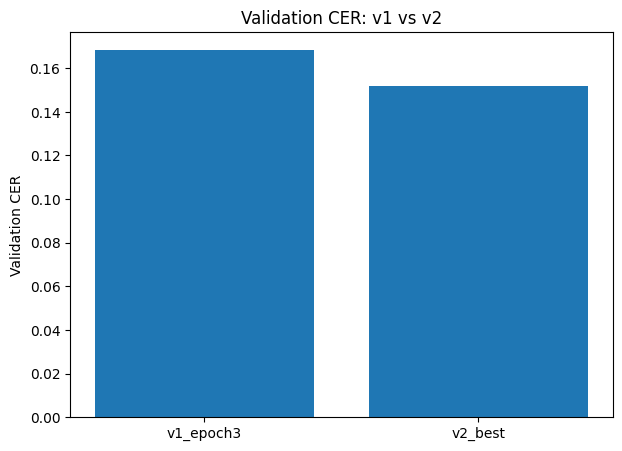

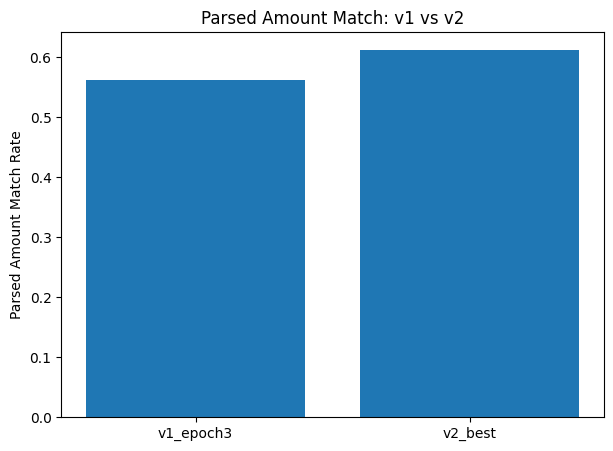

Saved comparison: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/metrics/v1_vs_v2_comparison.json
Saved graphs: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/graphs


In [8]:
import matplotlib.pyplot as plt

V1_BEST_METRICS = {
    "run": "v1_epoch3",
    "avg_cer_clean": 0.16816530825615497,
    "avg_wer_clean": 0.31738896905563596,
    "exact_clean": 49,
    "exact_clean_rate": 49 / 180,
    "amount_match_count": 101,
    "amount_match_rate": 101 / 180,
    "cer_clean_gt_030": 36,
}

v2_best_path = V2_METRIC_DIR / "best_checkpoint.json"

with open(v2_best_path, "r", encoding="utf-8") as f:
    v2_best = json.load(f)

v2_metrics = v2_best["metrics"]

comparison = [
    V1_BEST_METRICS,
    {
        "run": "v2_best",
        "avg_cer_clean": v2_metrics["avg_cer_clean"],
        "avg_wer_clean": v2_metrics["avg_wer_clean"],
        "exact_clean": v2_metrics["exact_clean"],
        "exact_clean_rate": v2_metrics["exact_clean_rate"],
        "amount_match_count": v2_metrics["amount_match_count"],
        "amount_match_rate": v2_metrics["amount_match_rate"],
        "cer_clean_gt_030": v2_metrics["cer_clean_gt_030"],
    },
]

comparison_path = V2_METRIC_DIR / "v1_vs_v2_comparison.json"

with open(comparison_path, "w", encoding="utf-8") as f:
    json.dump(comparison, f, ensure_ascii=False, indent=2)

print("=" * 100)
print("V1 vs V2 COMPARISON")
print("=" * 100)
for row in comparison:
    print(json.dumps(row, ensure_ascii=False, indent=2))

labels = [x["run"] for x in comparison]
cer_vals = [x["avg_cer_clean"] for x in comparison]
amount_vals = [x["amount_match_rate"] for x in comparison]

plt.figure(figsize=(7, 5))
plt.bar(labels, cer_vals)
plt.ylabel("Validation CER")
plt.title("Validation CER: v1 vs v2")
plt.savefig(V2_GRAPH_DIR / "v1_vs_v2_cer.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(labels, amount_vals)
plt.ylabel("Parsed Amount Match Rate")
plt.title("Parsed Amount Match: v1 vs v2")
plt.savefig(V2_GRAPH_DIR / "v1_vs_v2_amount_match.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved comparison:", comparison_path)
print("Saved graphs:", V2_GRAPH_DIR)

## 15. Canonical Arabic metric normalization
Recompute CER/WER with stronger Arabic normalization: alef variants, ya/alef-maqsura, ta-marbuta, tatweel, and merging spelling variants like `مايه` / `مائه` / `مائة`. Also splits attached `و`. This doesn't change predictions — it gives a fairer score on the same v2 output.

In [9]:
from pathlib import Path
import csv
import json
import re
from collections import Counter

BASE_DIR = Path("/teamspace/studios/this_studio")

V2_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v2_continue_from_epoch3"

V2_PRED_PATH = V2_RUN_DIR / "predictions" / "val_predictions_continue_epoch_1.csv"

STAGE9_DIR = V2_RUN_DIR / "stage9_normalized_metrics"
STAGE9_DIR.mkdir(parents=True, exist_ok=True)

NORM_PRED_OUT = STAGE9_DIR / "val_predictions_continue_epoch_1_normalized_metrics.csv"
NORM_METRICS_OUT = STAGE9_DIR / "normalized_metrics_summary.json"
NORM_EXAMPLES_OUT = STAGE9_DIR / "normalization_changed_cases.csv"

print("V2 prediction file exists:", V2_PRED_PATH.exists(), V2_PRED_PATH)
print("Stage 9 output folder:", STAGE9_DIR)

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

rows = read_csv_rows(V2_PRED_PATH)

print("Loaded rows:", len(rows))
print("Columns:", list(rows[0].keys()))
print("First row stem:", rows[0]["stem"])

V2 prediction file exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/predictions/val_predictions_continue_epoch_1.csv
Stage 9 output folder: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_normalized_metrics
Loaded rows: 180
Columns: ['stem', 'status', 'gt', 'raw_pred', 'clean_pred', 'cer_raw', 'wer_raw', 'cer_clean', 'wer_clean', 'exact_raw', 'exact_clean', 'gt_amount', 'pred_amount', 'amount_match', 'gt_parse_status', 'pred_parse_status', 'gt_unknown', 'pred_unknown']
First row stem: ac01485


In [10]:
AR_DIACRITICS_RE = re.compile(r"[\u064B-\u065F\u0670]")
TATWEEL_RE = re.compile(r"ـ+")
MULTISPACE_RE = re.compile(r"\s+")
PUNCT_RE = re.compile(r"[^\w\s\u0600-\u06FF]")

def normalize_arabic_base(text):
    text = str(text or "")

    text = text.replace("\u200f", " ").replace("\u200e", " ")
    text = AR_DIACRITICS_RE.sub("", text)
    text = TATWEEL_RE.sub("", text)

    text = re.sub(r"[أإآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ؤ", "و")
    text = text.replace("ئ", "ي")

    text = text.replace("لاغير", "لا غير")
    text = text.replace("لا غير", " لا غير ")

    text = PUNCT_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text).strip()

    return text

WORD_REPLACEMENTS = {
    # Hundreds
    "مايه": "ماية",
    "مائه": "ماية",
    "مائة": "ماية",
    "مئة": "ماية",
    "ميه": "ماية",
    "مية": "ماية",

    "مائتان": "مايتان",
    "ماتين": "مايتين",
    "ميتين": "مايتين",
    "ميتان": "مايتان",
    "ميتا": "مايتان",
    "ميتار": "مايتان",

    "ثلاثمايه": "ثلاثماية",
    "ثلاثمائة": "ثلاثماية",
    "ثلاثمائه": "ثلاثماية",

    "اربعمايه": "اربعماية",
    "اربعمائة": "اربعماية",
    "اربعمائه": "اربعماية",
    "اربعةماية": "اربعماية",
    "ربعماية": "اربعماية",

    "خمسمايه": "خمسماية",
    "خمسمائة": "خمسماية",
    "خمسمائه": "خمسماية",
    "خمسايه": "خمسماية",
    "خمساية": "خمسماية",

    "ستمايه": "ستماية",
    "ستمائة": "ستماية",
    "ستمائه": "ستماية",
    "ستميه": "ستماية",

    "سبعمايه": "سبعماية",
    "سبعمائة": "سبعماية",
    "سبعمائه": "سبعماية",

    "ثمانمايه": "ثمانماية",
    "ثمانمائة": "ثمانماية",
    "ثمانمائه": "ثمانماية",
    "ثمانميه": "ثمانماية",
    "ثمانيمايه": "ثمانماية",

    "تسعمايه": "تسعماية",
    "تسعمائة": "تسعماية",
    "تسعمائه": "تسعماية",

    # Thousands
    "الفا": "الف",
    "الاف": "الف",
    "آلاف": "الف",
    "اف": "الف",

    # Currency variants
    "ريالا": "ريال",
    "ريالات": "ريال",
    "رسالا": "ريال",
    "رسال": "ريال",

    # Common spelling variants
    "عشره": "عشرة",
    "تسعه": "تسعة",
    "اربعه": "اربعة",
    "ارعة": "اربعة",
    "ثلاثه": "ثلاثة",
    "واحده": "واحدة",
    "واحدي": "واحد",
    "سته": "ستة",
    "سبعه": "سبعة",
    "ثمانيه": "ثمانية",
    "خمسه": "خمسة",
}

KNOWN_SUFFIXES_FOR_W_SPLIT = {
    "واحد", "واحدة", "احد", "احدى",
    "اثنين", "اثنان", "اثنتين", "اثنتان", "اثني", "اثنا", "اثنتا",
    "ثلاثة", "ثلاث",
    "اربعة", "اربع",
    "خمسة", "خمس",
    "ستة", "ست",
    "سبعة", "سبع",
    "ثمانية", "ثمان",
    "تسعة", "تسع",
    "عشرة", "عشر",
    "عشرون", "عشرين",
    "ثلاثون", "ثلاثين",
    "اربعون", "اربعين",
    "خمسون", "خمسين",
    "ستون", "ستين",
    "سبعون", "سبعين",
    "ثمانون", "ثمانين",
    "تسعون", "تسعين",
    "ماية", "مايتان", "مايتين",
    "ثلاثماية", "اربعماية", "خمسماية", "ستماية",
    "سبعماية", "ثمانماية", "تسعماية",
    "الف", "الفان", "الفين", "مليون",
    "ريال", "فقط", "لا", "غير", "وقدره", "وقدرة",
}

def normalize_single_word_for_metric(word):
    word = str(word or "").strip()
    return WORD_REPLACEMENTS.get(word, word)

def canonical_metric_tokens(text):
    text = normalize_arabic_base(text)

    # Known merged forms.
    text = text.replace("عشرالف", "عشرة الف")
    text = text.replace("عشر الف", "عشرة الف")
    text = text.replace("لاغير", "لا غير")

    raw_words = text.split()
    tokens = []

    for raw_word in raw_words:
        word = normalize_single_word_for_metric(raw_word)

        # Keep known words as they are.
        if word in KNOWN_SUFFIXES_FOR_W_SPLIT or word == "و":
            tokens.append(word)
            continue

        # Split attached و when the suffix is a known amount/filler word.
        # Examples: وعشرون -> و عشرون, وخمسمايه -> و خمسماية
        if word.startswith("و") and len(word) > 2:
            suffix = normalize_single_word_for_metric(word[1:])
            if suffix in KNOWN_SUFFIXES_FOR_W_SPLIT:
                tokens.append("و")
                tokens.append(suffix)
                continue

        tokens.append(word)

    return tokens

def canonical_metric_text(text):
    return " ".join(canonical_metric_tokens(text))

# Quick examples
examples = [
    "الف وثلاثمايه وسته وعشرون ريال لا غير",
    "الف وثلاثماية وستة وعشرون ريال لاغير",
    "فقط مائة وستة عشرالف وميتان وخمسون ريال لا غير",
    "فقط ماية وستة عشر الف ومايتان وخمسون ريال لا غير",
]

for ex in examples:
    print("RAW :", ex)
    print("NORM:", canonical_metric_text(ex))
    print("-" * 100)

RAW : الف وثلاثمايه وسته وعشرون ريال لا غير
NORM: الف و ثلاثماية و ستة و عشرون ريال لا غير
----------------------------------------------------------------------------------------------------
RAW : الف وثلاثماية وستة وعشرون ريال لاغير
NORM: الف و ثلاثماية و ستة و عشرون ريال لا غير
----------------------------------------------------------------------------------------------------
RAW : فقط مائة وستة عشرالف وميتان وخمسون ريال لا غير
NORM: فقط ماية و ستة عشرة الف و مايتان و خمسون ريال لا غير
----------------------------------------------------------------------------------------------------
RAW : فقط ماية وستة عشر الف ومايتان وخمسون ريال لا غير
NORM: فقط ماية و ستة عشرة الف و مايتان و خمسون ريال لا غير
----------------------------------------------------------------------------------------------------


In [11]:
def levenshtein(a, b):
    a = list(a)
    b = list(b)

    dp = list(range(len(b) + 1))

    for i, ca in enumerate(a, 1):
        prev = dp[0]
        dp[0] = i

        for j, cb in enumerate(b, 1):
            old = dp[j]

            if ca == cb:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])

            prev = old

    return dp[-1]

def cer_metric(pred, gt):
    pred = str(pred or "")
    gt = str(gt or "")

    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0

    return levenshtein(pred, gt) / len(gt)

def wer_metric(pred, gt):
    pred_words = str(pred or "").split()
    gt_words = str(gt or "").split()

    if len(gt_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0

    return levenshtein(pred_words, gt_words) / len(gt_words)

print("Metric helpers ready.")

Metric helpers ready.


In [12]:
norm_rows = []

for r in rows:
    gt = r["gt"]
    pred = r["clean_pred"]

    gt_norm = canonical_metric_text(gt)
    pred_norm = canonical_metric_text(pred)

    old_cer = float(r["cer_clean"])
    old_wer = float(r["wer_clean"])

    new_cer = cer_metric(pred_norm, gt_norm)
    new_wer = wer_metric(pred_norm, gt_norm)

    exact_old = str(r.get("exact_clean", "")).lower() == "true"
    exact_new = pred_norm == gt_norm

    row = dict(r)
    row["gt_canonical"] = gt_norm
    row["pred_canonical"] = pred_norm
    row["canonical_cer"] = new_cer
    row["canonical_wer"] = new_wer
    row["canonical_exact"] = exact_new
    row["cer_delta"] = new_cer - old_cer
    row["wer_delta"] = new_wer - old_wer

    norm_rows.append(row)

old_avg_cer = sum(float(r["cer_clean"]) for r in norm_rows) / len(norm_rows)
old_avg_wer = sum(float(r["wer_clean"]) for r in norm_rows) / len(norm_rows)
new_avg_cer = sum(float(r["canonical_cer"]) for r in norm_rows) / len(norm_rows)
new_avg_wer = sum(float(r["canonical_wer"]) for r in norm_rows) / len(norm_rows)

old_exact = sum(str(r.get("exact_clean", "")).lower() == "true" for r in norm_rows)
new_exact = sum(str(r["canonical_exact"]).lower() == "true" for r in norm_rows)

summary = {
    "rows": len(norm_rows),

    "old_avg_cer_clean": old_avg_cer,
    "old_avg_wer_clean": old_avg_wer,
    "old_exact_clean": old_exact,
    "old_exact_clean_rate": old_exact / len(norm_rows),

    "canonical_avg_cer": new_avg_cer,
    "canonical_avg_wer": new_avg_wer,
    "canonical_exact": new_exact,
    "canonical_exact_rate": new_exact / len(norm_rows),

    "cer_improvement_absolute": old_avg_cer - new_avg_cer,
    "wer_improvement_absolute": old_avg_wer - new_avg_wer,
    "extra_exact_after_canonical_normalization": new_exact - old_exact,

    "canonical_cer_le_010": sum(float(r["canonical_cer"]) <= 0.10 for r in norm_rows),
    "canonical_cer_le_020": sum(float(r["canonical_cer"]) <= 0.20 for r in norm_rows),
    "canonical_cer_gt_030": sum(float(r["canonical_cer"]) > 0.30 for r in norm_rows),
}

write_csv_rows(NORM_PRED_OUT, norm_rows, list(norm_rows[0].keys()))

with open(NORM_METRICS_OUT, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("=" * 100)
print("STAGE 9A NORMALIZED METRICS SUMMARY")
print("=" * 100)
print(json.dumps(summary, ensure_ascii=False, indent=2))

print("\nSaved normalized predictions:", NORM_PRED_OUT)
print("Saved normalized metrics:", NORM_METRICS_OUT)

STAGE 9A NORMALIZED METRICS SUMMARY
{
  "rows": 180,
  "old_avg_cer_clean": 0.15168549405498655,
  "old_avg_wer_clean": 0.2963504088504089,
  "old_exact_clean": 57,
  "old_exact_clean_rate": 0.31666666666666665,
  "canonical_avg_cer": 0.1391480190336503,
  "canonical_avg_wer": 0.1941595441595441,
  "canonical_exact": 79,
  "canonical_exact_rate": 0.4388888888888889,
  "cer_improvement_absolute": 0.012537475021336258,
  "wer_improvement_absolute": 0.10219086469086483,
  "extra_exact_after_canonical_normalization": 22,
  "canonical_cer_le_010": 103,
  "canonical_cer_le_020": 127,
  "canonical_cer_gt_030": 29
}

Saved normalized predictions: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_normalized_metrics/val_predictions_continue_epoch_1_normalized_metrics.csv
Saved normalized metrics: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_normalized_metrics/normalized_metrics_summary.

In [13]:
changed_rows = [
    r for r in norm_rows
    if abs(float(r["cer_delta"])) > 1e-9 or str(r["canonical_exact"]).lower() != str(r["exact_clean"]).lower()
]

changed_rows_sorted = sorted(changed_rows, key=lambda r: float(r["cer_delta"]))

if changed_rows_sorted:
    write_csv_rows(NORM_EXAMPLES_OUT, changed_rows_sorted, list(changed_rows_sorted[0].keys()))

print("Rows changed by canonical normalization:", len(changed_rows_sorted))
print("Saved changed examples:", NORM_EXAMPLES_OUT)

print("\n" + "=" * 100)
print("TOP CASES WHERE NORMALIZATION HELPED")
print("=" * 100)

for r in changed_rows_sorted[:20]:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("Old CER:", round(float(r["cer_clean"]), 4), "| New CER:", round(float(r["canonical_cer"]), 4), "| Delta:", round(float(r["cer_delta"]), 4))
    print("GT original   :", r["gt"])
    print("Pred original :", r["clean_pred"])
    print("GT canonical  :", r["gt_canonical"])
    print("Pred canonical:", r["pred_canonical"])

print("\n" + "=" * 100)
print("CASES WHERE NORMALIZATION MADE CER WORSE")
print("=" * 100)

worse_rows = sorted(
    [r for r in norm_rows if float(r["cer_delta"]) > 1e-9],
    key=lambda r: float(r["cer_delta"]),
    reverse=True
)

for r in worse_rows[:10]:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("Old CER:", round(float(r["cer_clean"]), 4), "| New CER:", round(float(r["canonical_cer"]), 4), "| Delta:", round(float(r["cer_delta"]), 4))
    print("GT canonical  :", r["gt_canonical"])
    print("Pred canonical:", r["pred_canonical"])

Rows changed by canonical normalization: 116
Saved changed examples: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_normalized_metrics/normalization_changed_cases.csv

TOP CASES WHERE NORMALIZATION HELPED
----------------------------------------------------------------------------------------------------
Stem: ac01673
Old CER: 0.5714 | New CER: 0.4516 | Delta: -0.1198
GT original   : خمسة الاف وخمساية وسته وستون
Pred original : خمسة الاف وخمسماية وستة وسبعون ريال لا غير
GT canonical  : خمسة الف و خمسماية و ستة و ستون
Pred canonical: خمسة الف و خمسماية و ستة و سبعون ريال لا غير
----------------------------------------------------------------------------------------------------
Stem: ac01756
Old CER: 0.5556 | New CER: 0.4483 | Delta: -0.1073
GT original   : ثمانمايه وثلاث وثلاثين ريال
Pred original : ثمانية و سبعة وثلاثين ريال لا غير
GT canonical  : ثمانماية و ثلاث و ثلاثين ريال
Pred canonical: ثمانية و سبعة و ثلاثين ريال لا غير
---

In [14]:
print(f"""
## Stage 9A: Canonical Arabic Normalization for OCR Metrics

The best v2 legal OCR predictions were re-evaluated using stronger Arabic normalization before computing CER and WER. This normalization standardizes common Arabic spelling variants such as `مايه`, `مائه`, and `مائة` into `ماية`, normalizes attached conjunctions such as `وعشرون` into `و عشرون`, and handles common legal amount variants such as `لاغير` into `لا غير`.

This step does not change the model output. It only gives a fairer OCR evaluation by reducing penalties for spelling variants that represent the same Arabic amount words.

| Metric | Original v2 | Canonical normalized |
|---|---:|---:|
| CER | {summary["old_avg_cer_clean"]:.4f} | {summary["canonical_avg_cer"]:.4f} |
| WER | {summary["old_avg_wer_clean"]:.4f} | {summary["canonical_avg_wer"]:.4f} |
| Exact text matches | {summary["old_exact_clean"]}/{summary["rows"]} | {summary["canonical_exact"]}/{summary["rows"]} |
| CER <= 0.10 | - | {summary["canonical_cer_le_010"]}/{summary["rows"]} |
| CER <= 0.20 | - | {summary["canonical_cer_le_020"]}/{summary["rows"]} |
| CER > 0.30 | - | {summary["canonical_cer_gt_030"]}/{summary["rows"]} |

The absolute CER improvement from canonical normalization was {summary["cer_improvement_absolute"]:.4f}, and the absolute WER improvement was {summary["wer_improvement_absolute"]:.4f}.
""")


## Stage 9A: Canonical Arabic Normalization for OCR Metrics

The best v2 legal OCR predictions were re-evaluated using stronger Arabic normalization before computing CER and WER. This normalization standardizes common Arabic spelling variants such as `مايه`, `مائه`, and `مائة` into `ماية`, normalizes attached conjunctions such as `وعشرون` into `و عشرون`, and handles common legal amount variants such as `لاغير` into `لا غير`.

This step does not change the model output. It only gives a fairer OCR evaluation by reducing penalties for spelling variants that represent the same Arabic amount words.

| Metric | Original v2 | Canonical normalized |
|---|---:|---:|
| CER | 0.1517 | 0.1391 |
| WER | 0.2964 | 0.1942 |
| Exact text matches | 57/180 | 79/180 |
| CER <= 0.10 | - | 103/180 |
| CER <= 0.20 | - | 127/180 |
| CER > 0.30 | - | 29/180 |

The absolute CER improvement from canonical normalization was 0.0125, and the absolute WER improvement was 0.1022.



## 16. Parser v2 with edit-distance recovery
Improvements over v1:

- safer splitting of attached `و` (e.g. `وعشرون` → `و عشرون`)
- small edit-distance correction for unknown amount-like words
- merged-word recovery (`ميتالف` → `مايتان الف`)
- explicit unknown-word tracking

The goal is to recover more correct amounts without retraining the model.

In [15]:
from pathlib import Path
import csv
import json
import re
from collections import Counter, defaultdict

BASE_DIR = Path("/teamspace/studios/this_studio")

V2_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v2_continue_from_epoch3"
V2_PRED_PATH = V2_RUN_DIR / "predictions" / "val_predictions_continue_epoch_1.csv"

PARSER_V2_DIR = V2_RUN_DIR / "stage9_parser_v2"
PARSER_V2_DIR.mkdir(parents=True, exist_ok=True)

PARSER_V2_CSV = PARSER_V2_DIR / "val_legal_amount_parser_v2.csv"
PARSER_V2_METRICS = PARSER_V2_DIR / "parser_v2_metrics.json"
PARSER_V2_IMPROVED = PARSER_V2_DIR / "parser_v2_improved_cases.csv"
PARSER_V2_WORSE = PARSER_V2_DIR / "parser_v2_worse_cases.csv"
PARSER_V2_UNKNOWN = PARSER_V2_DIR / "parser_v2_unknown_words.csv"

print("V2 prediction file exists:", V2_PRED_PATH.exists(), V2_PRED_PATH)
print("Parser v2 output folder:", PARSER_V2_DIR)

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

rows = read_csv_rows(V2_PRED_PATH)

print("Loaded rows:", len(rows))
print("Columns:", list(rows[0].keys()))
print("First row stem:", rows[0]["stem"])

V2 prediction file exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/predictions/val_predictions_continue_epoch_1.csv
Parser v2 output folder: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_parser_v2
Loaded rows: 180
Columns: ['stem', 'status', 'gt', 'raw_pred', 'clean_pred', 'cer_raw', 'wer_raw', 'cer_clean', 'wer_clean', 'exact_raw', 'exact_clean', 'gt_amount', 'pred_amount', 'amount_match', 'gt_parse_status', 'pred_parse_status', 'gt_unknown', 'pred_unknown']
First row stem: ac01485


In [16]:
AR_DIACRITICS_RE = re.compile(r"[\u064B-\u065F\u0670]")
TATWEEL_RE = re.compile(r"ـ+")
MULTISPACE_RE = re.compile(r"\s+")
PUNCT_RE = re.compile(r"[^\w\s\u0600-\u06FF]")
DIGIT_RE = re.compile(r"[0-9\u0660-\u0669\u06F0-\u06F9]+")

def normalize_arabic_base(text):
    text = str(text or "")
    text = text.replace("\u200f", " ").replace("\u200e", " ")

    text = AR_DIACRITICS_RE.sub("", text)
    text = TATWEEL_RE.sub("", text)

    text = re.sub(r"[أإآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ؤ", "و")
    text = text.replace("ئ", "ي")

    text = text.replace("لاغير", "لا غير")
    text = text.replace("لا غير", " لا غير ")

    text = PUNCT_RE.sub(" ", text)
    text = DIGIT_RE.sub(" ", text)

    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

WORD_REPLACEMENTS = {
    # hundreds
    "مايه": "ماية",
    "مائه": "ماية",
    "مائة": "ماية",
    "مئة": "ماية",
    "ميه": "ماية",
    "مية": "ماية",

    "مائتان": "مايتان",
    "ماتين": "مايتين",
    "ميتين": "مايتين",
    "ميتان": "مايتان",
    "ميتا": "مايتان",
    "ميتار": "مايتان",

    "ثلاثمايه": "ثلاثماية",
    "ثلاثمائة": "ثلاثماية",
    "ثلاثمائه": "ثلاثماية",
    "ثلامايه": "ثلاثماية",
    "ثلاماية": "ثلاثماية",

    "اربعمايه": "اربعماية",
    "اربعمائة": "اربعماية",
    "اربعمائه": "اربعماية",
    "اربعةماية": "اربعماية",
    "ربعماية": "اربعماية",

    "خمسمايه": "خمسماية",
    "خمسمائة": "خمسماية",
    "خمسمائه": "خمسماية",
    "خمسايه": "خمسماية",
    "خمساية": "خمسماية",

    "ستمايه": "ستماية",
    "ستمائة": "ستماية",
    "ستمائه": "ستماية",
    "ستميه": "ستماية",

    "سبعمايه": "سبعماية",
    "سبعمائة": "سبعماية",
    "سبعمائه": "سبعماية",

    "ثمانمايه": "ثمانماية",
    "ثمانمائة": "ثمانماية",
    "ثمانمائه": "ثمانماية",
    "ثمانميه": "ثمانماية",
    "ثمانيمايه": "ثمانماية",

    "تسعمايه": "تسعماية",
    "تسعمائة": "تسعماية",
    "تسعمائه": "تسعماية",

    # thousands
    "الفا": "الف",
    "الاف": "الف",
    "آلاف": "الف",
    "اف": "الف",

    # currency variants
    "ريالا": "ريال",
    "ريالات": "ريال",
    "رسالا": "ريال",
    "رسال": "ريال",

    # spelling variants
    "عشره": "عشرة",
    "تسعه": "تسعة",
    "اربعه": "اربعة",
    "ارعة": "اربعة",
    "ثلاثه": "ثلاثة",
    "ثلاون": "ثلاثون",
    "واحده": "واحدة",
    "واحدي": "واحد",
    "سته": "ستة",
    "سبعه": "سبعة",
    "ثمانيه": "ثمانية",
    "خمسه": "خمسة",
    "سكون": "ستون",
}

SPECIAL_MERGED_WORDS = {
    "عشرالف": ["عشرة", "الف"],
    "عشرالاف": ["عشرة", "الف"],
    "ميتالف": ["مايتان", "الف"],
    "مئتيالف": ["مايتان", "الف"],
    "مائتيالف": ["مايتان", "الف"],
}

NOISE_WORDS = {
    "رسوم",
    "جمركيه",
    "جمركية",
    "امانه",
    "امانة",
    "هاشما",
    "ه",
}

IGNORE_WORDS = {
    "و",
    "فقط",
    "ريال",
    "لا",
    "غير",
    "لاغير",
    "وقدره",
    "وقدرة",
    "قدره",
    "قدرة",
    "مبلغ",
    "سعودي",
    "سعودية",
    "مقابل",
    "على",
    "الحساب",
    "حساب",
    "هللة",
    "هلله",
    "هلاله",
    "هلالة",
} | NOISE_WORDS

NUMBER_VALUES = {
    "صفر": 0,

    "واحد": 1,
    "واحدة": 1,
    "احد": 1,
    "احدى": 1,

    "اثنين": 2,
    "اثنان": 2,
    "اثنتين": 2,
    "اثنتان": 2,
    "اثني": 2,
    "اثنا": 2,
    "اثنتا": 2,

    "ثلاثة": 3,
    "ثلاث": 3,

    "اربعة": 4,
    "اربع": 4,

    "خمسة": 5,
    "خمس": 5,

    "ستة": 6,
    "ست": 6,

    "سبعة": 7,
    "سبع": 7,

    "ثمانية": 8,
    "ثمان": 8,

    "تسعة": 9,
    "تسع": 9,

    "عشرة": 10,
    "عشر": 10,

    "عشرون": 20,
    "عشرين": 20,

    "ثلاثون": 30,
    "ثلاثين": 30,

    "اربعون": 40,
    "اربعين": 40,

    "خمسون": 50,
    "خمسين": 50,

    "ستون": 60,
    "ستين": 60,

    "سبعون": 70,
    "سبعين": 70,

    "ثمانون": 80,
    "ثمانين": 80,

    "تسعون": 90,
    "تسعين": 90,

    "ماية": 100,
    "مايتان": 200,
    "مايتين": 200,

    "ثلاثماية": 300,
    "اربعماية": 400,
    "خمسماية": 500,
    "ستماية": 600,
    "سبعماية": 700,
    "ثمانماية": 800,
    "تسعماية": 900,

    "الفين": 2000,
    "الفان": 2000,
    "الفي": 2000,
}

MULTIPLIERS = {
    "الف": 1000,
    "مليون": 1000000,
}

AMOUNT_WORDS = set(NUMBER_VALUES) | set(MULTIPLIERS)
KNOWN_WORDS = AMOUNT_WORDS | IGNORE_WORDS

def normalize_single_word(word):
    word = str(word or "").strip()
    return WORD_REPLACEMENTS.get(word, word)

print("Amount words:", len(AMOUNT_WORDS))
print("Ignore words:", len(IGNORE_WORDS))
print("Known words:", len(KNOWN_WORDS))

Amount words: 59
Ignore words: 28
Known words: 87


In [17]:
def levenshtein_distance(a, b):
    a = list(str(a or ""))
    b = list(str(b or ""))

    dp = list(range(len(b) + 1))

    for i, ca in enumerate(a, 1):
        prev = dp[0]
        dp[0] = i

        for j, cb in enumerate(b, 1):
            old = dp[j]

            if ca == cb:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])

            prev = old

    return dp[-1]

def best_edit_match(token, candidates):
    token = str(token or "")
    best = None

    for cand in candidates:
        dist = levenshtein_distance(token, cand)
        ratio = dist / max(len(token), len(cand), 1)

        item = {
            "candidate": cand,
            "distance": dist,
            "ratio": ratio,
        }

        if best is None:
            best = item
        else:
            if (dist, ratio, len(cand)) < (best["distance"], best["ratio"], len(best["candidate"])):
                best = item

    return best

def edit_threshold_ok(token, match):
    if match is None:
        return False

    token_len = len(str(token or ""))
    dist = match["distance"]
    ratio = match["ratio"]

    if token_len <= 3:
        return dist <= 1 and ratio <= 0.34

    if token_len <= 6:
        return dist <= 2 and ratio <= 0.34

    return dist <= 3 and ratio <= 0.34

def try_split_known_word(word):
    word = str(word or "")

    if word in SPECIAL_MERGED_WORDS:
        return SPECIAL_MERGED_WORDS[word], "special_merged"

    # Direct split into two known amount words.
    for i in range(2, len(word) - 1):
        left = normalize_single_word(word[:i])
        right = normalize_single_word(word[i:])

        if left in AMOUNT_WORDS and right in AMOUNT_WORDS:
            return [left, right], "split_direct"

    return None, ""

def recover_unknown_word(word):
    original = str(word or "")
    word = normalize_single_word(original)

    if not word:
        return [], [f"{original}->empty"]

    if word in SPECIAL_MERGED_WORDS:
        return SPECIAL_MERGED_WORDS[word], [f"{original}->{'+'.join(SPECIAL_MERGED_WORDS[word])}:special_merged"]

    if word in KNOWN_WORDS:
        return [word], []

    # Try split merged amount words.
    split_tokens, split_reason = try_split_known_word(word)
    if split_tokens:
        return split_tokens, [f"{original}->{'+'.join(split_tokens)}:{split_reason}"]

    # Try edit-distance correction only into amount words.
    match = best_edit_match(word, AMOUNT_WORDS)

    if edit_threshold_ok(word, match):
        corrected = match["candidate"]
        return [corrected], [f"{original}->{corrected}:edit_d{match['distance']}"]

    return [word], [f"{original}->UNKNOWN"]

def tokenize_legal_text_parser_v2(text):
    text = normalize_arabic_base(text)

    # Known no-space cases.
    text = text.replace("عشرالف", "عشرة الف")
    text = text.replace("عشر الف", "عشرة الف")
    text = text.replace("لاغير", "لا غير")

    raw_words = text.split()

    tokens = []
    actions = []

    for raw_word in raw_words:
        word = normalize_single_word(raw_word)

        if word in SPECIAL_MERGED_WORDS:
            new_tokens = SPECIAL_MERGED_WORDS[word]
            tokens.extend(new_tokens)
            actions.append(f"{raw_word}->{'+'.join(new_tokens)}:special_merged")
            continue

        if word in KNOWN_WORDS:
            tokens.append(word)
            continue

        # Handle repeated leading و safely.
        # Examples: وواثنان -> و و اثنان, وثلاون -> و ثلاثون
        if word.startswith("و") and len(word) > 2:
            remaining = word

            while remaining.startswith("و") and len(remaining) > 2:
                tokens.append("و")
                actions.append(f"{remaining}->و+{remaining[1:]}:split_w")
                remaining = remaining[1:]

            recovered_tokens, recovered_actions = recover_unknown_word(remaining)
            tokens.extend(recovered_tokens)
            actions.extend(recovered_actions)
            continue

        recovered_tokens, recovered_actions = recover_unknown_word(word)
        tokens.extend(recovered_tokens)
        actions.extend(recovered_actions)

    return tokens, actions

# Quick tests
test_words = [
    "وثلاون",
    "وستميه",
    "وثلامايه",
    "وواثنان",
    "وشر",
    "واربعةماية",
    "ميتالف",
    "عشرالف",
    "مستده",
]

for t in test_words:
    toks, acts = tokenize_legal_text_parser_v2(t)
    print("RAW    :", t)
    print("TOKENS :", toks)
    print("ACTIONS:", acts)
    print("-" * 80)

RAW    : وثلاون
TOKENS : ['و', 'ثلاثون']
ACTIONS: ['وثلاون->و+ثلاون:split_w']
--------------------------------------------------------------------------------
RAW    : وستميه
TOKENS : ['و', 'ستماية']
ACTIONS: ['وستميه->و+ستميه:split_w']
--------------------------------------------------------------------------------
RAW    : وثلامايه
TOKENS : ['و', 'ثلاثماية']
ACTIONS: ['وثلامايه->و+ثلامايه:split_w']
--------------------------------------------------------------------------------
RAW    : وواثنان
TOKENS : ['و', 'و', 'اثنان']
ACTIONS: ['وواثنان->و+واثنان:split_w', 'واثنان->و+اثنان:split_w']
--------------------------------------------------------------------------------
RAW    : وشر
TOKENS : ['و', 'عشر']
ACTIONS: ['وشر->و+شر:split_w', 'شر->عشر:edit_d1']
--------------------------------------------------------------------------------
RAW    : واربعةماية
TOKENS : ['و', 'اربعماية']
ACTIONS: ['واربعةماية->و+اربعةماية:split_w']
----------------------------------------------------------------

In [18]:
def tokenize_legal_text_direct(text):
    text = normalize_arabic_base(text)
    text = text.replace("عشرالف", "عشرة الف")
    text = text.replace("عشر الف", "عشرة الف")
    text = text.replace("لاغير", "لا غير")

    raw_words = text.split()
    tokens = []

    for raw_word in raw_words:
        word = normalize_single_word(raw_word)

        if word in KNOWN_WORDS:
            tokens.append(word)
            continue

        if word.startswith("و") and len(word) > 2:
            suffix = normalize_single_word(word[1:])
            if suffix in KNOWN_WORDS:
                tokens.append("و")
                tokens.append(suffix)
                continue

        tokens.append(word)

    return tokens

def parse_tokens_to_amount(tokens):
    total = 0
    current = 0

    unknown = []
    used_number_tokens = []

    for token in tokens:
        if token in IGNORE_WORDS:
            continue

        if token in NUMBER_VALUES:
            value = NUMBER_VALUES[token]

            if token == "ماية" and 1 <= current <= 9:
                current = current * 100
            else:
                current += value

            used_number_tokens.append(token)
            continue

        if token in MULTIPLIERS:
            multiplier = MULTIPLIERS[token]

            if current == 0:
                current = 1

            total += current * multiplier
            current = 0

            used_number_tokens.append(token)
            continue

        unknown.append(token)

    total += current

    if not used_number_tokens:
        return {
            "amount": None,
            "status": "no_number_tokens",
            "unknown": unknown,
        }

    if unknown:
        return {
            "amount": total,
            "status": "parsed_with_unknown",
            "unknown": unknown,
        }

    return {
        "amount": total,
        "status": "parsed_ok",
        "unknown": [],
    }

def parse_legal_amount_v1(text):
    tokens = tokenize_legal_text_direct(text)
    parsed = parse_tokens_to_amount(tokens)
    parsed["tokens"] = tokens
    parsed["actions"] = []
    return parsed

def parse_legal_amount_v2(text):
    tokens, actions = tokenize_legal_text_parser_v2(text)
    parsed = parse_tokens_to_amount(tokens)
    parsed["tokens"] = tokens
    parsed["actions"] = actions
    return parsed

# Safety examples
test_amounts = [
    "وثلاون ريال",
    "وستميه ريال",
    "ميتالف ريال لا غير",
    "عشرالف ريال فقط",
    "الف وخمسة وعشرون ريال لا غير",
    "خمسماية الف ريال",
    "ثلاثة الاف وثلامايه ريال",
]

for text in test_amounts:
    p1 = parse_legal_amount_v1(text)
    p2 = parse_legal_amount_v2(text)

    print("=" * 90)
    print("TEXT:", text)
    print("v1:", p1["amount"], p1["status"], p1["tokens"], p1["unknown"])
    print("v2:", p2["amount"], p2["status"], p2["tokens"], p2["unknown"], p2["actions"])

TEXT: وثلاون ريال
v1: 30 parsed_ok ['و', 'ثلاثون', 'ريال'] []
v2: 30 parsed_ok ['و', 'ثلاثون', 'ريال'] [] ['وثلاون->و+ثلاون:split_w']
TEXT: وستميه ريال
v1: 600 parsed_ok ['و', 'ستماية', 'ريال'] []
v2: 600 parsed_ok ['و', 'ستماية', 'ريال'] [] ['وستميه->و+ستميه:split_w']
TEXT: ميتالف ريال لا غير
v1: None no_number_tokens ['ميتالف', 'ريال', 'لا', 'غير'] ['ميتالف']
v2: 200000 parsed_ok ['مايتان', 'الف', 'ريال', 'لا', 'غير'] [] ['ميتالف->مايتان+الف:special_merged']
TEXT: عشرالف ريال فقط
v1: 10000 parsed_ok ['عشرة', 'الف', 'ريال', 'فقط'] []
v2: 10000 parsed_ok ['عشرة', 'الف', 'ريال', 'فقط'] [] []
TEXT: الف وخمسة وعشرون ريال لا غير
v1: 1025 parsed_ok ['الف', 'و', 'خمسة', 'و', 'عشرون', 'ريال', 'لا', 'غير'] []
v2: 1025 parsed_ok ['الف', 'و', 'خمسة', 'و', 'عشرون', 'ريال', 'لا', 'غير'] [] ['وخمسة->و+خمسة:split_w', 'وعشرون->و+عشرون:split_w']
TEXT: خمسماية الف ريال
v1: 500000 parsed_ok ['خمسماية', 'الف', 'ريال'] []
v2: 500000 parsed_ok ['خمسماية', 'الف', 'ريال'] [] []
TEXT: ثلاثة الاف وثلامايه ريال

In [19]:
parsed_rows = []

for r in rows:
    gt_text = r["gt"]
    pred_text = r["clean_pred"]

    gt_v1 = parse_legal_amount_v1(gt_text)
    pred_v1 = parse_legal_amount_v1(pred_text)

    gt_v2 = parse_legal_amount_v2(gt_text)
    pred_v2 = parse_legal_amount_v2(pred_text)

    gt_amount_v1 = gt_v1["amount"]
    pred_amount_v1 = pred_v1["amount"]
    gt_amount_v2 = gt_v2["amount"]
    pred_amount_v2 = pred_v2["amount"]

    amount_match_v1 = (
        gt_amount_v1 is not None
        and pred_amount_v1 is not None
        and gt_amount_v1 == pred_amount_v1
    )

    amount_match_v2 = (
        gt_amount_v2 is not None
        and pred_amount_v2 is not None
        and gt_amount_v2 == pred_amount_v2
    )

    row = {
        "stem": r["stem"],
        "status": r.get("status", ""),
        "gt": gt_text,
        "clean_pred": pred_text,

        "cer_clean": r.get("cer_clean", ""),
        "wer_clean": r.get("wer_clean", ""),
        "exact_clean": r.get("exact_clean", ""),

        "gt_amount_v1": "" if gt_amount_v1 is None else gt_amount_v1,
        "pred_amount_v1": "" if pred_amount_v1 is None else pred_amount_v1,
        "amount_match_v1": amount_match_v1,

        "gt_amount_v2": "" if gt_amount_v2 is None else gt_amount_v2,
        "pred_amount_v2": "" if pred_amount_v2 is None else pred_amount_v2,
        "amount_match_v2": amount_match_v2,

        "gt_parse_status_v1": gt_v1["status"],
        "pred_parse_status_v1": pred_v1["status"],
        "gt_parse_status_v2": gt_v2["status"],
        "pred_parse_status_v2": pred_v2["status"],

        "gt_tokens_v2": " ".join(gt_v2["tokens"]),
        "pred_tokens_v2": " ".join(pred_v2["tokens"]),

        "gt_unknown_v2": "|".join(gt_v2["unknown"]),
        "pred_unknown_v2": "|".join(pred_v2["unknown"]),

        "gt_actions_v2": "|".join(gt_v2["actions"]),
        "pred_actions_v2": "|".join(pred_v2["actions"]),
    }

    parsed_rows.append(row)

v1_match = sum(r["amount_match_v1"] for r in parsed_rows)
v2_match = sum(r["amount_match_v2"] for r in parsed_rows)

v1_wrong_v2_right = [
    r for r in parsed_rows
    if not r["amount_match_v1"] and r["amount_match_v2"]
]

v1_right_v2_wrong = [
    r for r in parsed_rows
    if r["amount_match_v1"] and not r["amount_match_v2"]
]

unknown_counter = Counter()

for r in parsed_rows:
    for value in [r["gt_unknown_v2"], r["pred_unknown_v2"]]:
        for token in str(value or "").split("|"):
            token = token.strip()
            if token:
                unknown_counter[token] += 1

unknown_rows = [
    {"word": word, "count": count}
    for word, count in unknown_counter.most_common()
]

metrics = {
    "rows": len(parsed_rows),

    "parser_v1_amount_match_count": v1_match,
    "parser_v1_amount_match_rate": v1_match / len(parsed_rows),

    "parser_v2_amount_match_count": v2_match,
    "parser_v2_amount_match_rate": v2_match / len(parsed_rows),

    "v1_wrong_v2_right_count": len(v1_wrong_v2_right),
    "v1_right_v2_wrong_count": len(v1_right_v2_wrong),

    "gt_parse_status_v2_counts": dict(Counter(r["gt_parse_status_v2"] for r in parsed_rows)),
    "pred_parse_status_v2_counts": dict(Counter(r["pred_parse_status_v2"] for r in parsed_rows)),

    "unknown_tokens_v2_count": len(unknown_rows),
}

write_csv_rows(PARSER_V2_CSV, parsed_rows, list(parsed_rows[0].keys()))

with open(PARSER_V2_METRICS, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

if v1_wrong_v2_right:
    write_csv_rows(PARSER_V2_IMPROVED, v1_wrong_v2_right, list(parsed_rows[0].keys()))

if v1_right_v2_wrong:
    write_csv_rows(PARSER_V2_WORSE, v1_right_v2_wrong, list(parsed_rows[0].keys()))

if unknown_rows:
    write_csv_rows(PARSER_V2_UNKNOWN, unknown_rows, ["word", "count"])

print("=" * 100)
print("PARSER V1 vs PARSER V2 METRICS")
print("=" * 100)
print(json.dumps(metrics, ensure_ascii=False, indent=2))

print("\nSaved:")
print(PARSER_V2_CSV)
print(PARSER_V2_METRICS)
print(PARSER_V2_IMPROVED)
print(PARSER_V2_WORSE)
print(PARSER_V2_UNKNOWN)

PARSER V1 vs PARSER V2 METRICS
{
  "rows": 180,
  "parser_v1_amount_match_count": 110,
  "parser_v1_amount_match_rate": 0.6111111111111112,
  "parser_v2_amount_match_count": 112,
  "parser_v2_amount_match_rate": 0.6222222222222222,
  "v1_wrong_v2_right_count": 2,
  "v1_right_v2_wrong_count": 0,
  "gt_parse_status_v2_counts": {
    "parsed_ok": 180
  },
  "pred_parse_status_v2_counts": {
    "parsed_ok": 174,
    "parsed_with_unknown": 6
  },
  "unknown_tokens_v2_count": 6
}

Saved:
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_parser_v2/val_legal_amount_parser_v2.csv
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_parser_v2/parser_v2_metrics.json
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_parser_v2/parser_v2_improved_cases.csv
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_ep

In [20]:
print("=" * 100)
print("V1 WRONG, V2 RIGHT")
print("=" * 100)
print("Count:", len(v1_wrong_v2_right))

for r in v1_wrong_v2_right[:20]:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("GT amount v1/v2:", r["gt_amount_v1"], "->", r["gt_amount_v2"])
    print("Pred amount v1/v2:", r["pred_amount_v1"], "->", r["pred_amount_v2"])
    print("GT  :", r["gt"])
    print("PRED:", r["clean_pred"])
    print("Pred tokens v2:", r["pred_tokens_v2"])
    print("Pred actions v2:", r["pred_actions_v2"])

print("\n" + "=" * 100)
print("V1 RIGHT, V2 WRONG")
print("=" * 100)
print("Count:", len(v1_right_v2_wrong))

for r in v1_right_v2_wrong[:20]:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("GT amount v1/v2:", r["gt_amount_v1"], "->", r["gt_amount_v2"])
    print("Pred amount v1/v2:", r["pred_amount_v1"], "->", r["pred_amount_v2"])
    print("GT  :", r["gt"])
    print("PRED:", r["clean_pred"])
    print("GT actions v2:", r["gt_actions_v2"])
    print("Pred actions v2:", r["pred_actions_v2"])

print("\n" + "=" * 100)
print("TOP UNKNOWN TOKENS AFTER PARSER V2")
print("=" * 100)

for x in unknown_rows[:50]:
    print(x)

V1 WRONG, V2 RIGHT
Count: 2
----------------------------------------------------------------------------------------------------
Stem: ac01622
GT amount v1/v2: 6722 -> 6722
Pred amount v1/v2: 6720 -> 6722
GT  : فقط ستة الاف وسبعماية واثنان وعشرون ريال
PRED: فقط ستة الاف وسبعماية وواثنان وعشرون ريال لا غير
Pred tokens v2: فقط ستة الف و سبعماية و و اثنان و عشرون ريال لا غير
Pred actions v2: وسبعماية->و+سبعماية:split_w|وواثنان->و+واثنان:split_w|واثنان->و+اثنان:split_w|وعشرون->و+عشرون:split_w
----------------------------------------------------------------------------------------------------
Stem: ac00127
GT amount v1/v2: 200000 -> 200000
Pred amount v1/v2:  -> 200000
GT  : فقط ميتا الف ريال لا غير
PRED: فقط ميتالف ريال لا غير
Pred tokens v2: فقط مايتان الف ريال لا غير
Pred actions v2: ميتالف->مايتان+الف:special_merged

V1 RIGHT, V2 WRONG
Count: 0

TOP UNKNOWN TOKENS AFTER PARSER V2
{'word': 'مستده', 'count': 1}
{'word': 'مثلا', 'count': 1}
{'word': 'ثليمايه', 'count': 1}
{'word': 'ها', 'c

In [21]:
print(f"""
## Stage 9B: Parser v2 with Edit-Distance Recovery

After canonical Arabic normalization, a second legal amount parser was tested. Parser v1 used direct dictionary matching. Parser v2 added safer token recovery rules, including splitting attached Arabic `و`, handling merged words such as `عشرالف`, and applying edit-distance correction only for unknown amount words.

| Metric | Parser v1 | Parser v2 |
|---|---:|---:|
| Parsed amount matches | {metrics["parser_v1_amount_match_count"]}/{metrics["rows"]} | {metrics["parser_v2_amount_match_count"]}/{metrics["rows"]} |
| Parsed amount match rate | {metrics["parser_v1_amount_match_rate"]:.4f} | {metrics["parser_v2_amount_match_rate"]:.4f} |
| Cases fixed by parser v2 | - | {metrics["v1_wrong_v2_right_count"]} |
| Cases worsened by parser v2 | - | {metrics["v1_right_v2_wrong_count"]} |

Parser v2 is useful if it increases the amount match count without introducing many new wrong conversions.
""")


## Stage 9B: Parser v2 with Edit-Distance Recovery

After canonical Arabic normalization, a second legal amount parser was tested. Parser v1 used direct dictionary matching. Parser v2 added safer token recovery rules, including splitting attached Arabic `و`, handling merged words such as `عشرالف`, and applying edit-distance correction only for unknown amount words.

| Metric | Parser v1 | Parser v2 |
|---|---:|---:|
| Parsed amount matches | 110/180 | 112/180 |
| Parsed amount match rate | 0.6111 | 0.6222 |
| Cases fixed by parser v2 | - | 2 |
| Cases worsened by parser v2 | - | 0 |

Parser v2 is useful if it increases the amount match count without introducing many new wrong conversions.



## 17. Image enhancement ablation
Test whether enhanced versions of the crop help on hard cases. Variants compared: original, padded autocontrast, grayscale contrast, border autocontrast. No retraining.

In [22]:
from pathlib import Path
import json
import csv
import random
from collections import Counter
from PIL import Image, ImageOps, ImageEnhance, ImageFilter

BASE_DIR = Path("/teamspace/studios/this_studio")

MODEL_DIR = BASE_DIR / "models" / "Qwen3.5_model"

V2_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v2_continue_from_epoch3"
BEST_ADAPTER_DIR = V2_RUN_DIR / "checkpoints" / "best_by_val_cer_clean"

VAL_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "val.jsonl"

PARSER_V2_CSV = V2_RUN_DIR / "stage9_parser_v2" / "val_legal_amount_parser_v2.csv"

STAGE10_DIR = V2_RUN_DIR / "stage10_image_enhancement"
ENH_CROP_DIR = STAGE10_DIR / "enhanced_crops"
STAGE10_DIR.mkdir(parents=True, exist_ok=True)
ENH_CROP_DIR.mkdir(parents=True, exist_ok=True)

ABLATION_QUICK_CSV = STAGE10_DIR / "enhancement_ablation_quick.csv"
ABLATION_QUICK_SUMMARY = STAGE10_DIR / "enhancement_ablation_quick_summary.json"

QUICK_N = 25
SEED = 42

random.seed(SEED)

required_names = [
    "parse_legal_amount_v2",
    "canonical_metric_text",
    "cer_metric",
    "wer_metric",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing functions from Stage 9A/9B. Please rerun those cells first: "
        + ", ".join(missing)
    )

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

val_records = read_jsonl(VAL_JSONL)
val_by_stem = {r["stem"]: r for r in val_records}

parser_rows = read_csv_rows(PARSER_V2_CSV)

amount_wrong_rows = [
    r for r in parser_rows
    if str(r["amount_match_v2"]).lower() != "true"
]

amount_wrong_rows = sorted(
    amount_wrong_rows,
    key=lambda r: float(r["cer_clean"]) if r["cer_clean"] else 0,
    reverse=True,
)

quick_rows = amount_wrong_rows[:QUICK_N]

print("Best adapter exists:", BEST_ADAPTER_DIR.exists(), BEST_ADAPTER_DIR)
print("Val JSONL exists:", VAL_JSONL.exists(), VAL_JSONL)
print("Parser v2 CSV exists:", PARSER_V2_CSV.exists(), PARSER_V2_CSV)
print("Total validation rows:", len(parser_rows))
print("Amount-wrong after parser v2:", len(amount_wrong_rows))
print("Quick ablation rows:", len(quick_rows))

print("\nFirst quick row:")
for k in ["stem", "gt", "clean_pred", "gt_amount_v2", "pred_amount_v2", "cer_clean"]:
    print(k + ":", quick_rows[0].get(k, ""))

Best adapter exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/checkpoints/best_by_val_cer_clean
Val JSONL exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/jsonl/val.jsonl
Parser v2 CSV exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_parser_v2/val_legal_amount_parser_v2.csv
Total validation rows: 180
Amount-wrong after parser v2: 68
Quick ablation rows: 25

First quick row:
stem: ac01053
gt: فقط ثلاثة الاف وستميه
clean_pred: فقط ثلاثة الاف وسبعماية وثمانون ريال لا غير
gt_amount_v2: 3600
pred_amount_v2: 3780
cer_clean: 1.1428571428571428


In [23]:
def ensure_rgb(img):
    return img.convert("RGB")

def add_white_padding(img, pad=24):
    img = ensure_rgb(img)
    return ImageOps.expand(img, border=pad, fill="white")

def whiten_outer_border(img, border=8):
    img = ensure_rgb(img)
    out = img.copy()
    px = out.load()
    w, h = out.size

    for x in range(w):
        for y in range(min(border, h)):
            px[x, y] = (255, 255, 255)
            px[x, h - 1 - y] = (255, 255, 255)

    for y in range(h):
        for x in range(min(border, w)):
            px[x, y] = (255, 255, 255)
            px[w - 1 - x, y] = (255, 255, 255)

    return out

def enhance_autocontrast_pad(img):
    img = ensure_rgb(img)
    img = add_white_padding(img, pad=24)
    img = ImageOps.autocontrast(img)
    img = ImageEnhance.Contrast(img).enhance(1.25)
    img = ImageEnhance.Sharpness(img).enhance(1.15)
    return img

def enhance_gray_contrast(img):
    img = ensure_rgb(img)
    img = img.convert("L")
    img = ImageOps.autocontrast(img)
    img = ImageEnhance.Contrast(img).enhance(1.45)
    img = ImageEnhance.Sharpness(img).enhance(1.10)
    return img.convert("RGB")

def enhance_border_auto(img):
    img = ensure_rgb(img)
    img = whiten_outer_border(img, border=8)
    img = add_white_padding(img, pad=18)
    img = ImageOps.autocontrast(img)
    img = ImageEnhance.Contrast(img).enhance(1.20)
    return img

ENHANCERS = {
    "original": lambda img: ensure_rgb(img),
    "pad_autocontrast": enhance_autocontrast_pad,
    "gray_contrast": enhance_gray_contrast,
    "border_autocontrast": enhance_border_auto,
}

print("Enhancement variants:", list(ENHANCERS.keys()))

Enhancement variants: ['original', 'pad_autocontrast', 'gray_contrast', 'border_autocontrast']


In [24]:
def save_enhanced_variants(rows_to_process):
    variant_records = []

    for r in rows_to_process:
        stem = r["stem"]
        val_record = val_by_stem[stem]
        original_path = Path(val_record["image"])

        if not original_path.exists():
            print("Missing image:", original_path)
            continue

        img = Image.open(original_path).convert("RGB")

        for variant_name, enhancer in ENHANCERS.items():
            variant_dir = ENH_CROP_DIR / variant_name
            variant_dir.mkdir(parents=True, exist_ok=True)

            out_path = variant_dir / f"{stem}_{variant_name}.png"

            if variant_name == "original":
                # Save a copy so every variant has a file path in the same structure.
                enhanced = enhancer(img)
            else:
                enhanced = enhancer(img)

            enhanced.save(out_path)

            variant_records.append({
                "stem": stem,
                "variant": variant_name,
                "image": str(out_path),
                "prompt": val_record["prompt"],
                "answer": val_record["answer"],
                "gt": r["gt"],
                "baseline_pred": r["clean_pred"],
                "baseline_gt_amount": r["gt_amount_v2"],
                "baseline_pred_amount": r["pred_amount_v2"],
                "baseline_amount_match": r["amount_match_v2"],
                "baseline_cer": r["cer_clean"],
            })

    return variant_records

quick_variant_records = save_enhanced_variants(quick_rows)

print("Variant records created:", len(quick_variant_records))
print("Expected:", len(quick_rows) * len(ENHANCERS))

print("\nExample:")
print(json.dumps(quick_variant_records[0], ensure_ascii=False, indent=2))

Variant records created: 100
Expected: 100

Example:
{
  "stem": "ac01053",
  "variant": "original",
  "image": "/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage10_image_enhancement/enhanced_crops/original/ac01053_original.png",
  "prompt": "استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط.",
  "answer": "فقط ثلاثة الاف وستميه",
  "gt": "فقط ثلاثة الاف وستميه",
  "baseline_pred": "فقط ثلاثة الاف وسبعماية وثمانون ريال لا غير",
  "baseline_gt_amount": "3600",
  "baseline_pred_amount": "3780",
  "baseline_amount_match": "False",
  "baseline_cer": "1.1428571428571428"
}


In [25]:
import gc
import torch
from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
from peft import PeftModel
from qwen_vl_utils import process_vision_info

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

DTYPE = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

processor = AutoProcessor.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
)

tokenizer = processor.tokenizer

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    device_map="auto",
)

model = PeftModel.from_pretrained(
    base_model,
    BEST_ADAPTER_DIR,
    is_trainable=False,
)

model.eval()

model.generation_config.pad_token_id = tokenizer.pad_token_id
model.generation_config.eos_token_id = tokenizer.eos_token_id

print("Loaded best v2 model for inference.")
print("Model device:", next(model.parameters()).device)
print("Model dtype:", next(model.parameters()).dtype)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

/teamspace/studios/this_studio/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 473/473 [00:03<00:00, 139.89it/s]


Loaded best v2 model for inference.
Model device: cuda:0
Model dtype: torch.bfloat16
GPU: Tesla T4


In [26]:
MAX_NEW_TOKENS = 40

def clean_prediction_first_line(text):
    text = str(text or "").strip()
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    if not lines:
        return ""
    return lines[0]

def move_inputs_to_device(inputs):
    device = next(model.parameters()).device
    return {k: v.to(device) if hasattr(v, "to") else v for k, v in inputs.items()}

def predict_image_path(image_path, prompt, max_new_tokens=MAX_NEW_TOKENS):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": str(image_path)},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    inputs = move_inputs_to_device(inputs)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    generated_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs["input_ids"], generated_ids)
    ]

    raw_pred = processor.batch_decode(
        generated_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    clean_pred = clean_prediction_first_line(raw_pred)

    return raw_pred, clean_pred

print("Prediction function ready.")

Prediction function ready.


In [27]:
ablation_rows = []

for idx, rec in enumerate(quick_variant_records, 1):
    raw_pred, clean_pred = predict_image_path(
        image_path=rec["image"],
        prompt=rec["prompt"],
        max_new_tokens=MAX_NEW_TOKENS,
    )

    gt = rec["gt"]

    gt_parse = parse_legal_amount_v2(gt)
    pred_parse = parse_legal_amount_v2(clean_pred)

    gt_amount = gt_parse["amount"]
    pred_amount = pred_parse["amount"]

    amount_match = (
        gt_amount is not None
        and pred_amount is not None
        and gt_amount == pred_amount
    )

    gt_canon = canonical_metric_text(gt)
    pred_canon = canonical_metric_text(clean_pred)

    out_row = {
        "stem": rec["stem"],
        "variant": rec["variant"],
        "image": rec["image"],
        "gt": gt,
        "baseline_pred": rec["baseline_pred"],
        "new_pred": clean_pred,
        "raw_pred": raw_pred,

        "baseline_gt_amount": rec["baseline_gt_amount"],
        "baseline_pred_amount": rec["baseline_pred_amount"],
        "baseline_amount_match": rec["baseline_amount_match"],

        "new_gt_amount": "" if gt_amount is None else gt_amount,
        "new_pred_amount": "" if pred_amount is None else pred_amount,
        "new_amount_match": amount_match,

        "canonical_cer": cer_metric(pred_canon, gt_canon),
        "canonical_wer": wer_metric(pred_canon, gt_canon),

        "pred_parse_status": pred_parse["status"],
        "pred_unknown": "|".join(pred_parse["unknown"]),
        "pred_tokens": " ".join(pred_parse["tokens"]),
    }

    ablation_rows.append(out_row)

    if idx % 10 == 0:
        print(f"Processed {idx}/{len(quick_variant_records)}")

write_csv_rows(ABLATION_QUICK_CSV, ablation_rows, list(ablation_rows[0].keys()))

print("Saved quick ablation:", ABLATION_QUICK_CSV)
print("Rows:", len(ablation_rows))

Processed 10/100
Processed 20/100
Processed 30/100
Processed 40/100
Processed 50/100
Processed 60/100
Processed 70/100
Processed 80/100
Processed 90/100
Processed 100/100
Saved quick ablation: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage10_image_enhancement/enhancement_ablation_quick.csv
Rows: 100


In [29]:
variant_summary = []

for variant in sorted(set(r["variant"] for r in ablation_rows)):
    vr = [r for r in ablation_rows if r["variant"] == variant]

    amount_match_count = sum(str(r["new_amount_match"]).lower() == "true" for r in vr)
    avg_cer = sum(float(r["canonical_cer"]) for r in vr) / len(vr)
    avg_wer = sum(float(r["canonical_wer"]) for r in vr) / len(vr)

    variant_summary.append({
        "variant": variant,
        "rows": len(vr),
        "amount_match_count": amount_match_count,
        "amount_match_rate": amount_match_count / len(vr),
        "avg_canonical_cer": avg_cer,
        "avg_canonical_wer": avg_wer,
    })

# These quick rows were selected from parser v2 amount-wrong cases.
baseline_amount_correct = sum(
    str(r.get("amount_match_v2", "")).lower() == "true"
    for r in quick_rows
)

summary = {
    "quick_cases": len(quick_rows),
    "variants": variant_summary,
    "baseline_amount_correct_on_selected_cases": baseline_amount_correct,
}

with open(ABLATION_QUICK_SUMMARY, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("=" * 100)
print("STAGE 10A QUICK IMAGE ENHANCEMENT SUMMARY")
print("=" * 100)
print(json.dumps(summary, ensure_ascii=False, indent=2))
print("Saved summary:", ABLATION_QUICK_SUMMARY)

STAGE 10A QUICK IMAGE ENHANCEMENT SUMMARY
{
  "quick_cases": 25,
  "variants": [
    {
      "variant": "border_autocontrast",
      "rows": 25,
      "amount_match_count": 2,
      "amount_match_rate": 0.08,
      "avg_canonical_cer": 0.44648617932004064,
      "avg_canonical_wer": 0.5680562770562771
    },
    {
      "variant": "gray_contrast",
      "rows": 25,
      "amount_match_count": 0,
      "amount_match_rate": 0.0,
      "avg_canonical_cer": 0.542223389391576,
      "avg_canonical_wer": 0.6342150072150073
    },
    {
      "variant": "original",
      "rows": 25,
      "amount_match_count": 0,
      "amount_match_rate": 0.0,
      "avg_canonical_cer": 0.5194467633379412,
      "avg_canonical_wer": 0.6236435786435787
    },
    {
      "variant": "pad_autocontrast",
      "rows": 25,
      "amount_match_count": 1,
      "amount_match_rate": 0.04,
      "avg_canonical_cer": 0.5452383147627526,
      "avg_canonical_wer": 0.6842308802308803
    }
  ],
  "baseline_amount_correc

In [30]:
recovered = [
    r for r in ablation_rows
    if r["variant"] != "original"
    and str(r["new_amount_match"]).lower() == "true"
]

original_rows_by_stem = {
    r["stem"]: r
    for r in ablation_rows
    if r["variant"] == "original"
}

# Recovered only if original rerun is still wrong.
recovered_vs_original = []
for r in recovered:
    orig = original_rows_by_stem.get(r["stem"])
    if orig is None or str(orig["new_amount_match"]).lower() != "true":
        recovered_vs_original.append(r)

print("=" * 100)
print("RECOVERED BY ENHANCEMENT")
print("=" * 100)
print("Recovered count:", len(recovered_vs_original))

for r in recovered_vs_original[:20]:
    print("-" * 100)
    print("Stem:", r["stem"], "| Variant:", r["variant"])
    print("GT amount:", r["new_gt_amount"], "| Pred amount:", r["new_pred_amount"])
    print("GT:")
    print(r["gt"])
    print("Baseline pred:")
    print(r["baseline_pred"])
    print("Enhanced pred:")
    print(r["new_pred"])
    print("CER:", round(float(r["canonical_cer"]), 4), "WER:", round(float(r["canonical_wer"]), 4))

print("\n" + "=" * 100)
print("BEST VARIANT PER STEM")
print("=" * 100)

best_by_stem = {}

for stem in sorted(set(r["stem"] for r in ablation_rows)):
    sr = [r for r in ablation_rows if r["stem"] == stem]

    sr_sorted = sorted(
        sr,
        key=lambda x: (
            0 if str(x["new_amount_match"]).lower() == "true" else 1,
            float(x["canonical_cer"]),
            float(x["canonical_wer"]),
        )
    )

    best_by_stem[stem] = sr_sorted[0]

best_rows = list(best_by_stem.values())
best_amount_match = sum(str(r["new_amount_match"]).lower() == "true" for r in best_rows)

print("Best-per-stem amount matches:", best_amount_match, "/", len(best_rows))

for r in best_rows[:10]:
    print("-" * 100)
    print("Stem:", r["stem"], "| Best variant:", r["variant"], "| Match:", r["new_amount_match"])
    print("GT amount:", r["new_gt_amount"], "| Pred amount:", r["new_pred_amount"])
    print("Pred:", r["new_pred"])

RECOVERED BY ENHANCEMENT
Recovered count: 3
----------------------------------------------------------------------------------------------------
Stem: ac01203 | Variant: border_autocontrast
GT amount: 57000 | Pred amount: 57000
GT:
فقط سبعة وخمسون الف ريال
Baseline pred:
فقط مسَتده وخمسون الف ريال لا غير
Enhanced pred:
فقط سبعة وخمسون الف ريال لا غير
CER: 0.28 WER: 0.3333
----------------------------------------------------------------------------------------------------
Stem: ac00681 | Variant: pad_autocontrast
GT amount: 2500 | Pred amount: 2500
GT:
فقط الفين وخمسمايه ريال
Baseline pred:
فقط الفين وخمسمايه وثمانماية هـ
Enhanced pred:
فقط الفين وخمسمايه ريال فقط
CER: 0.1667 WER: 0.2
----------------------------------------------------------------------------------------------------
Stem: ac00681 | Variant: border_autocontrast
GT amount: 2500 | Pred amount: 2500
GT:
فقط الفين وخمسمايه ريال
Baseline pred:
فقط الفين وخمسمايه وثمانماية هـ
Enhanced pred:
فقط الفين وخمسمايه ريال لا غير
CER:

## 18. Full enhancement fallback on wrong cases
Run the two useful variants (`border_autocontrast`, `pad_autocontrast`) on every remaining amount-wrong case. Generates extra candidate predictions per cheque; the best is picked later using a guide amount.

In [31]:
FULL_FALLBACK_DIR = STAGE10_DIR / "fallback_all_wrong"
FULL_FALLBACK_CROP_DIR = FULL_FALLBACK_DIR / "enhanced_crops"
FULL_FALLBACK_DIR.mkdir(parents=True, exist_ok=True)
FULL_FALLBACK_CROP_DIR.mkdir(parents=True, exist_ok=True)

FALLBACK_CSV = FULL_FALLBACK_DIR / "enhancement_fallback_all_wrong.csv"
FALLBACK_SUMMARY = FULL_FALLBACK_DIR / "enhancement_fallback_all_wrong_summary.json"
FALLBACK_BEST_PER_STEM = FULL_FALLBACK_DIR / "enhancement_fallback_best_per_stem.csv"

FALLBACK_VARIANTS = {
    "border_autocontrast": enhance_border_auto,
    "pad_autocontrast": enhance_autocontrast_pad,
}

full_wrong_rows = amount_wrong_rows

print("Total amount-wrong rows:", len(full_wrong_rows))
print("Fallback variants:", list(FALLBACK_VARIANTS.keys()))
print("Output folder:", FULL_FALLBACK_DIR)

Total amount-wrong rows: 68
Fallback variants: ['border_autocontrast', 'pad_autocontrast']
Output folder: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage10_image_enhancement/fallback_all_wrong


In [32]:
fallback_variant_records = []

for r in full_wrong_rows:
    stem = r["stem"]
    val_record = val_by_stem[stem]
    original_path = Path(val_record["image"])

    if not original_path.exists():
        print("Missing image:", original_path)
        continue

    img = Image.open(original_path).convert("RGB")

    for variant_name, enhancer in FALLBACK_VARIANTS.items():
        variant_dir = FULL_FALLBACK_CROP_DIR / variant_name
        variant_dir.mkdir(parents=True, exist_ok=True)

        out_path = variant_dir / f"{stem}_{variant_name}.png"

        enhanced = enhancer(img)
        enhanced.save(out_path)

        fallback_variant_records.append({
            "stem": stem,
            "variant": variant_name,
            "image": str(out_path),
            "prompt": val_record["prompt"],
            "answer": val_record["answer"],
            "gt": r["gt"],
            "baseline_pred": r["clean_pred"],
            "baseline_gt_amount": r["gt_amount_v2"],
            "baseline_pred_amount": r["pred_amount_v2"],
            "baseline_amount_match": r["amount_match_v2"],
            "baseline_cer": r["cer_clean"],
        })

print("Fallback variant records:", len(fallback_variant_records))
print("Expected:", len(full_wrong_rows) * len(FALLBACK_VARIANTS))

Fallback variant records: 136
Expected: 136


In [33]:
fallback_rows = []

for idx, rec in enumerate(fallback_variant_records, 1):
    raw_pred, clean_pred = predict_image_path(
        image_path=rec["image"],
        prompt=rec["prompt"],
        max_new_tokens=MAX_NEW_TOKENS,
    )

    gt = rec["gt"]

    gt_parse = parse_legal_amount_v2(gt)
    pred_parse = parse_legal_amount_v2(clean_pred)

    gt_amount = gt_parse["amount"]
    pred_amount = pred_parse["amount"]

    amount_match = (
        gt_amount is not None
        and pred_amount is not None
        and gt_amount == pred_amount
    )

    gt_canon = canonical_metric_text(gt)
    pred_canon = canonical_metric_text(clean_pred)

    fallback_rows.append({
        "stem": rec["stem"],
        "variant": rec["variant"],
        "image": rec["image"],
        "gt": gt,
        "baseline_pred": rec["baseline_pred"],
        "new_pred": clean_pred,
        "raw_pred": raw_pred,

        "baseline_gt_amount": rec["baseline_gt_amount"],
        "baseline_pred_amount": rec["baseline_pred_amount"],
        "baseline_amount_match": rec["baseline_amount_match"],

        "new_gt_amount": "" if gt_amount is None else gt_amount,
        "new_pred_amount": "" if pred_amount is None else pred_amount,
        "new_amount_match": amount_match,

        "canonical_cer": cer_metric(pred_canon, gt_canon),
        "canonical_wer": wer_metric(pred_canon, gt_canon),

        "pred_parse_status": pred_parse["status"],
        "pred_unknown": "|".join(pred_parse["unknown"]),
        "pred_tokens": " ".join(pred_parse["tokens"]),
    })

    if idx % 10 == 0:
        print(f"Processed {idx}/{len(fallback_variant_records)}")

write_csv_rows(FALLBACK_CSV, fallback_rows, list(fallback_rows[0].keys()))

print("Saved fallback results:", FALLBACK_CSV)
print("Rows:", len(fallback_rows))

Processed 10/136
Processed 20/136
Processed 30/136
Processed 40/136
Processed 50/136
Processed 60/136
Processed 70/136
Processed 80/136
Processed 90/136
Processed 100/136
Processed 110/136
Processed 120/136
Processed 130/136
Saved fallback results: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage10_image_enhancement/fallback_all_wrong/enhancement_fallback_all_wrong.csv
Rows: 136


In [36]:
variant_summary = []

for variant in sorted(set(r["variant"] for r in fallback_rows)):
    vr = [r for r in fallback_rows if r["variant"] == variant]

    amount_match_count = sum(str(r["new_amount_match"]).lower() == "true" for r in vr)
    avg_cer = sum(float(r["canonical_cer"]) for r in vr) / len(vr)
    avg_wer = sum(float(r["canonical_wer"]) for r in vr) / len(vr)

    variant_summary.append({
        "variant": variant,
        "rows": len(vr),
        "amount_match_count": amount_match_count,
        "amount_match_rate": amount_match_count / len(vr),
        "avg_canonical_cer": avg_cer,
        "avg_canonical_wer": avg_wer,
    })

best_by_stem = {}

for stem in sorted(set(r["stem"] for r in fallback_rows)):
    sr = [r for r in fallback_rows if r["stem"] == stem]

    sr_sorted = sorted(
        sr,
        key=lambda x: (
            0 if str(x["new_amount_match"]).lower() == "true" else 1,
            float(x["canonical_cer"]),
            float(x["canonical_wer"]),
        )
    )

    best_by_stem[stem] = sr_sorted[0]

best_rows = list(best_by_stem.values())
best_amount_match = sum(str(r["new_amount_match"]).lower() == "true" for r in best_rows)

estimated_total_match = 112 + best_amount_match
estimated_total_rate = estimated_total_match / 180

summary = {
    "wrong_cases_tested": len(full_wrong_rows),
    "variants": variant_summary,
    "best_fallback_recovered_count": best_amount_match,
    "current_parser_v2_match_count": 112,
    "estimated_total_match_with_fallback": estimated_total_match,
    "estimated_total_match_rate_with_fallback": estimated_total_rate,
}

write_csv_rows(FALLBACK_BEST_PER_STEM, best_rows, list(best_rows[0].keys()))

with open(FALLBACK_SUMMARY, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("=" * 100)
print("STAGE 10B FULL FALLBACK ENHANCEMENT SUMMARY")
print("=" * 100)
print(json.dumps(summary, ensure_ascii=False, indent=2))

print("Saved fallback summary:", FALLBACK_SUMMARY)
print("Saved best per stem:", FALLBACK_BEST_PER_STEM)

STAGE 10B FULL FALLBACK ENHANCEMENT SUMMARY
{
  "wrong_cases_tested": 68,
  "variants": [
    {
      "variant": "border_autocontrast",
      "rows": 68,
      "amount_match_count": 13,
      "amount_match_rate": 0.19117647058823528,
      "avg_canonical_cer": 0.2695650337214581,
      "avg_canonical_wer": 0.3562621202327085
    },
    {
      "variant": "pad_autocontrast",
      "rows": 68,
      "amount_match_count": 7,
      "amount_match_rate": 0.10294117647058823,
      "avg_canonical_cer": 0.3249138643334599,
      "avg_canonical_wer": 0.4265623265623265
    }
  ],
  "best_fallback_recovered_count": 16,
  "current_parser_v2_match_count": 112,
  "estimated_total_match_with_fallback": 128,
  "estimated_total_match_rate_with_fallback": 0.7111111111111111
}
Saved fallback summary: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage10_image_enhancement/fallback_all_wrong/enhancement_fallback_all_wrong_summary.json
Saved best per stem: 

In [37]:
recovered_best = [
    r for r in best_rows
    if str(r["new_amount_match"]).lower() == "true"
]

print("=" * 100)
print("FULL FALLBACK RECOVERED CASES")
print("=" * 100)
print("Recovered unique stems:", len(recovered_best))

for r in recovered_best[:30]:
    print("-" * 100)
    print("Stem:", r["stem"], "| Variant:", r["variant"])
    print("GT amount:", r["new_gt_amount"], "| Pred amount:", r["new_pred_amount"])
    print("GT:")
    print(r["gt"])
    print("Baseline pred:")
    print(r["baseline_pred"])
    print("Enhanced pred:")
    print(r["new_pred"])
    print("CER:", round(float(r["canonical_cer"]), 4), "WER:", round(float(r["canonical_wer"]), 4))

FULL FALLBACK RECOVERED CASES
Recovered unique stems: 16
----------------------------------------------------------------------------------------------------
Stem: ac00024 | Variant: border_autocontrast
GT amount: 15309 | Pred amount: 15309
GT:
خمسة عشر الف وثلاثمايه وتسعه ريال فقط
Baseline pred:
خمسة عشر الف وثلاثمايه وتسعه واربعون
Enhanced pred:
خمسة عشر الف وثلاثماية وتسعه ريال فقط
CER: 0.0 WER: 0.0
----------------------------------------------------------------------------------------------------
Stem: ac00188 | Variant: pad_autocontrast
GT amount: 6142 | Pred amount: 6142
GT:
ستة الف وماية اثنان واربعون ريال
Baseline pred:
ستة الف ومايتين واثنان واربعون ريال
Enhanced pred:
ستة الف ومايه اثنان واربعون ريال
CER: 0.0 WER: 0.0
----------------------------------------------------------------------------------------------------
Stem: ac00364 | Variant: pad_autocontrast
GT amount: 134126 | Pred amount: 134126
GT:
ماية واربعة وثلاثون الف وماية وستة وعشرون ريال
Baseline pred:
مائة واربعه 

## 19. guided selection 
Use the legal GT amount as an *guide* to pick the best candidate among original + enhanced predictions. Not deployable — just answers: *if the guide were always correct, how much could enhancement recover?*

In [38]:
from pathlib import Path
import csv
import json
from collections import Counter, defaultdict

BASE_DIR = Path("/teamspace/studios/this_studio")

V2_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v2_continue_from_epoch3"

PARSER_V2_CSV = V2_RUN_DIR / "stage9_parser_v2" / "val_legal_amount_parser_v2.csv"

FALLBACK_CSV = (
    V2_RUN_DIR
    / "stage10_image_enhancement"
    / "fallback_all_wrong"
    / "enhancement_fallback_all_wrong.csv"
)

STAGE11_DIR = V2_RUN_DIR / "stage11_guided_selection"
STAGE11_DIR.mkdir(parents=True, exist_ok=True)

GUIDED_OUT = STAGE11_DIR / "guided_selection_oracle_v1.csv"
GUIDED_METRICS_OUT = STAGE11_DIR / "guided_selection_oracle_metrics_v1.json"
GUIDED_CHANGED_OUT = STAGE11_DIR / "guided_selection_changed_cases_v1.csv"

print("Parser v2 CSV exists:", PARSER_V2_CSV.exists(), PARSER_V2_CSV)
print("Fallback CSV exists:", FALLBACK_CSV.exists(), FALLBACK_CSV)
print("Stage 11 folder:", STAGE11_DIR)

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def safe_int(value):
    value = str(value or "").strip()
    if value == "":
        return None
    try:
        return int(float(value))
    except ValueError:
        return None

parser_rows = read_csv_rows(PARSER_V2_CSV)
fallback_rows = read_csv_rows(FALLBACK_CSV)

print("Parser rows:", len(parser_rows))
print("Fallback rows:", len(fallback_rows))

print("\nParser columns:", list(parser_rows[0].keys()))
print("\nFallback columns:", list(fallback_rows[0].keys()))

Parser v2 CSV exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_parser_v2/val_legal_amount_parser_v2.csv
Fallback CSV exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage10_image_enhancement/fallback_all_wrong/enhancement_fallback_all_wrong.csv
Stage 11 folder: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage11_guided_selection
Parser rows: 180
Fallback rows: 136

Parser columns: ['stem', 'status', 'gt', 'clean_pred', 'cer_clean', 'wer_clean', 'exact_clean', 'gt_amount_v1', 'pred_amount_v1', 'amount_match_v1', 'gt_amount_v2', 'pred_amount_v2', 'amount_match_v2', 'gt_parse_status_v1', 'pred_parse_status_v1', 'gt_parse_status_v2', 'pred_parse_status_v2', 'gt_tokens_v2', 'pred_tokens_v2', 'gt_unknown_v2', 'pred_unknown_v2', 'gt_actions_v2', 'pred_actions_v2']

Fallback columns: ['stem', 'variant', 'image', 'gt'

In [39]:
parser_by_stem = {r["stem"]: r for r in parser_rows}
fallback_by_stem = defaultdict(list)

for r in fallback_rows:
    fallback_by_stem[r["stem"]].append(r)

VARIANT_PRIORITY = {
    "original": 0,
    "border_autocontrast": 1,
    "pad_autocontrast": 2,
}

def build_candidates_for_stem(stem):
    base = parser_by_stem[stem]

    candidates = []

    original_amount = safe_int(base.get("pred_amount_v2"))
    gt_amount = safe_int(base.get("gt_amount_v2"))

    candidates.append({
        "stem": stem,
        "variant": "original",
        "prediction": base.get("clean_pred", ""),
        "pred_amount": original_amount,
        "gt_amount": gt_amount,
        "parse_status": base.get("pred_parse_status_v2", ""),
        "source": "parser_v2_original",
    })

    for fb in fallback_by_stem.get(stem, []):
        candidates.append({
            "stem": stem,
            "variant": fb.get("variant", ""),
            "prediction": fb.get("new_pred", ""),
            "pred_amount": safe_int(fb.get("new_pred_amount")),
            "gt_amount": safe_int(fb.get("new_gt_amount")),
            "parse_status": fb.get("pred_parse_status", ""),
            "source": "enhancement_fallback",
        })

    candidates = sorted(
        candidates,
        key=lambda x: VARIANT_PRIORITY.get(x["variant"], 99)
    )

    return candidates

# Quick example from a recovered case if available.
for stem in ["ac01344", "ac01203", "ac00681"]:
    if stem in parser_by_stem:
        print("=" * 100)
        print("Stem:", stem)
        for c in build_candidates_for_stem(stem):
            print(c["variant"], "| amount:", c["pred_amount"], "| pred:", c["prediction"])

Stem: ac01344
original | amount: 15000 | pred: خمسة عشرة الف ريال
border_autocontrast | amount: 500000 | pred: خمسماية الف ريال
pad_autocontrast | amount: 15000 | pred: خمسة عشر الف ريال
Stem: ac01203
original | amount: 50000 | pred: فقط مسَتده وخمسون الف ريال لا غير
border_autocontrast | amount: 57000 | pred: فقط سبعة وخمسون الف ريال لا غير
pad_autocontrast | amount: 50000 | pred: فقط مسيحه وخمسون الف ريال لا غير
Stem: ac00681
original | amount: 3300 | pred: فقط الفين وخمسمايه وثمانماية هـ
border_autocontrast | amount: 2500 | pred: فقط الفين وخمسمايه ريال لا غير
pad_autocontrast | amount: 2500 | pred: فقط الفين وخمسمايه ريال فقط


In [40]:
def choose_candidate_by_guide(candidates, guide_amount):
    original = candidates[0]

    if guide_amount is None:
        return original, "no_guide_use_original"

    exact_matches = [
        c for c in candidates
        if c["pred_amount"] is not None and c["pred_amount"] == guide_amount
    ]

    if exact_matches:
        exact_matches = sorted(
            exact_matches,
            key=lambda x: VARIANT_PRIORITY.get(x["variant"], 99)
        )
        chosen = exact_matches[0]

        if chosen["variant"] == "original":
            return chosen, "original_matches_guide"

        return chosen, "enhanced_matches_guide"

    return original, "no_candidate_matches_guide_use_original"

guided_rows = []

for stem in sorted(parser_by_stem):
    base = parser_by_stem[stem]
    candidates = build_candidates_for_stem(stem)

    gt_amount = safe_int(base.get("gt_amount_v2"))

    # Oracle guide for validation. Later replace this with courtesy OCR predicted amount.
    guide_amount = gt_amount

    chosen, decision = choose_candidate_by_guide(candidates, guide_amount)

    original_candidate = candidates[0]
    original_correct = (
        original_candidate["pred_amount"] is not None
        and gt_amount is not None
        and original_candidate["pred_amount"] == gt_amount
    )

    chosen_correct = (
        chosen["pred_amount"] is not None
        and gt_amount is not None
        and chosen["pred_amount"] == gt_amount
    )

    guided_rows.append({
        "stem": stem,
        "gt": base.get("gt", ""),
        "gt_amount": "" if gt_amount is None else gt_amount,

        "guide_amount": "" if guide_amount is None else guide_amount,
        "guide_source": "oracle_gt_amount_for_validation",

        "original_pred": original_candidate["prediction"],
        "original_amount": "" if original_candidate["pred_amount"] is None else original_candidate["pred_amount"],
        "original_correct": original_correct,

        "chosen_variant": chosen["variant"],
        "chosen_pred": chosen["prediction"],
        "chosen_amount": "" if chosen["pred_amount"] is None else chosen["pred_amount"],
        "chosen_correct": chosen_correct,

        "decision": decision,
        "num_candidates": len(candidates),

        "available_candidate_amounts": "|".join(
            f"{c['variant']}:{c['pred_amount']}" for c in candidates
        ),
    })

original_correct_count = sum(r["original_correct"] for r in guided_rows)
chosen_correct_count = sum(r["chosen_correct"] for r in guided_rows)

print("Original parser v2 correct:", original_correct_count, "/", len(guided_rows))
print("Guided selected correct:", chosen_correct_count, "/", len(guided_rows))
print("Improvement:", chosen_correct_count - original_correct_count)

Original parser v2 correct: 112 / 180
Guided selected correct: 128 / 180
Improvement: 16


In [41]:
changed_rows = [
    r for r in guided_rows
    if r["chosen_variant"] != "original"
]

improved_rows = [
    r for r in guided_rows
    if not r["original_correct"] and r["chosen_correct"]
]

worsened_rows = [
    r for r in guided_rows
    if r["original_correct"] and not r["chosen_correct"]
]

decision_counts = Counter(r["decision"] for r in guided_rows)
variant_counts = Counter(r["chosen_variant"] for r in guided_rows)

metrics = {
    "rows": len(guided_rows),

    "baseline_parser_v2_correct": original_correct_count,
    "baseline_parser_v2_rate": original_correct_count / len(guided_rows),

    "guided_correct": chosen_correct_count,
    "guided_rate": chosen_correct_count / len(guided_rows),

    "improvement_count": chosen_correct_count - original_correct_count,
    "changed_from_original_count": len(changed_rows),
    "improved_cases_count": len(improved_rows),
    "worsened_cases_count": len(worsened_rows),

    "decision_counts": dict(decision_counts),
    "chosen_variant_counts": dict(variant_counts),

    "important_note": (
        "This uses GT amount as oracle guide for validation. "
        "For the final system, replace guide_amount with predicted courtesy OCR amount."
    ),
}

write_csv_rows(GUIDED_OUT, guided_rows, list(guided_rows[0].keys()))

if changed_rows:
    write_csv_rows(GUIDED_CHANGED_OUT, changed_rows, list(changed_rows[0].keys()))

with open(GUIDED_METRICS_OUT, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("=" * 100)
print("STAGE 11 GUIDED SELECTION SUMMARY")
print("=" * 100)
print(json.dumps(metrics, ensure_ascii=False, indent=2))

print("\nSaved:")
print(GUIDED_OUT)
print(GUIDED_METRICS_OUT)
print(GUIDED_CHANGED_OUT)

STAGE 11 GUIDED SELECTION SUMMARY
{
  "rows": 180,
  "baseline_parser_v2_correct": 112,
  "baseline_parser_v2_rate": 0.6222222222222222,
  "guided_correct": 128,
  "guided_rate": 0.7111111111111111,
  "improvement_count": 16,
  "changed_from_original_count": 16,
  "improved_cases_count": 16,
  "worsened_cases_count": 0,
  "decision_counts": {
    "original_matches_guide": 112,
    "enhanced_matches_guide": 16,
    "no_candidate_matches_guide_use_original": 52
  },
  "chosen_variant_counts": {
    "original": 164,
    "border_autocontrast": 13,
    "pad_autocontrast": 3
  },
  "important_note": "This uses GT amount as oracle guide for validation. For the final system, replace guide_amount with predicted courtesy OCR amount."
}

Saved:
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage11_guided_selection/guided_selection_oracle_v1.csv
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage11_

In [42]:
print("=" * 100)
print("GUIDED SELECTION IMPROVED CASES")
print("=" * 100)
print("Improved cases:", len(improved_rows))

for r in improved_rows[:30]:
    print("-" * 100)
    print("Stem:", r["stem"], "| Chosen variant:", r["chosen_variant"])
    print("GT amount:", r["gt_amount"], "| Original amount:", r["original_amount"], "| Chosen amount:", r["chosen_amount"])
    print("Decision:", r["decision"])
    print("GT:")
    print(r["gt"])
    print("Original pred:")
    print(r["original_pred"])
    print("Chosen pred:")
    print(r["chosen_pred"])

print("\n" + "=" * 100)
print("GUIDED SELECTION WORSENED CASES")
print("=" * 100)
print("Worsened cases:", len(worsened_rows))

for r in worsened_rows[:10]:
    print("-" * 100)
    print("Stem:", r["stem"], "| Chosen variant:", r["chosen_variant"])
    print("GT amount:", r["gt_amount"], "| Original amount:", r["original_amount"], "| Chosen amount:", r["chosen_amount"])
    print("Decision:", r["decision"])
    print("GT:")
    print(r["gt"])
    print("Original pred:")
    print(r["original_pred"])
    print("Chosen pred:")
    print(r["chosen_pred"])

GUIDED SELECTION IMPROVED CASES
Improved cases: 16
----------------------------------------------------------------------------------------------------
Stem: ac00024 | Chosen variant: border_autocontrast
GT amount: 15309 | Original amount: 15349 | Chosen amount: 15309
Decision: enhanced_matches_guide
GT:
خمسة عشر الف وثلاثمايه وتسعه ريال فقط
Original pred:
خمسة عشر الف وثلاثمايه وتسعه واربعون
Chosen pred:
خمسة عشر الف وثلاثماية وتسعه ريال فقط
----------------------------------------------------------------------------------------------------
Stem: ac00188 | Chosen variant: border_autocontrast
GT amount: 6142 | Original amount: 6242 | Chosen amount: 6142
Decision: enhanced_matches_guide
GT:
ستة الف وماية اثنان واربعون ريال
Original pred:
ستة الف ومايتين واثنان واربعون ريال
Chosen pred:
ستة الف ومايه اثنان واربعون ريال لا غير
----------------------------------------------------------------------------------------------------
Stem: ac00364 | Chosen variant: pad_autocontrast
GT amount: 134

In [43]:
print(f"""
## Stage 11: Guided Legal Amount Selection with Enhancement Fallback

After parser v2, the legal amount match rate was {metrics["baseline_parser_v2_correct"]}/{metrics["rows"]}, equal to {metrics["baseline_parser_v2_rate"]:.4f}. 
Image enhancement fallback produced additional legal OCR candidates using `border_autocontrast` and `pad_autocontrast`.

In this validation experiment, the ground-truth amount was used as an oracle guide to simulate the role of a perfectly correct courtesy amount. The guided selector chooses the original legal prediction if it already matches the guide amount. If not, it checks the enhanced legal candidates and selects an enhanced candidate when its parsed amount matches the guide.

| Metric | Result |
|---|---:|
| Baseline parser v2 amount match | {metrics["baseline_parser_v2_correct"]}/{metrics["rows"]} |
| Guided selection amount match | {metrics["guided_correct"]}/{metrics["rows"]} |
| Absolute improvement | +{metrics["improvement_count"]} samples |
| Changed from original | {metrics["changed_from_original_count"]} samples |
| Improved cases | {metrics["improved_cases_count"]} samples |
| Worsened cases | {metrics["worsened_cases_count"]} samples |

This is an oracle validation result because it uses the validation GT amount as the guide. In the final cheque verification pipeline, this guide should be replaced by the predicted courtesy amount from the courtesy OCR module.
""")


## Stage 11: Guided Legal Amount Selection with Enhancement Fallback

After parser v2, the legal amount match rate was 112/180, equal to 0.6222. 
Image enhancement fallback produced additional legal OCR candidates using `border_autocontrast` and `pad_autocontrast`.

In this validation experiment, the ground-truth amount was used as an oracle guide to simulate the role of a perfectly correct courtesy amount. The guided selector chooses the original legal prediction if it already matches the guide amount. If not, it checks the enhanced legal candidates and selects an enhanced candidate when its parsed amount matches the guide.

| Metric | Result |
|---|---:|
| Baseline parser v2 amount match | 112/180 |
| Guided selection amount match | 128/180 |
| Absolute improvement | +16 samples |
| Changed from original | 16 samples |
| Improved cases | 16 samples |
| Worsened cases | 0 samples |

This is an oracle validation result because it uses the validation GT amount as the guide. In the fina

## 20. Courtesy GT-guided selection
Use the courtesy amount label as the guide. Includes fixes:

- extract courtesy amounts from the original Label Studio JSON
- strip guard symbols (`#`, `*`, `/`, `=`) and ignore halala
- legal parser fix: `الفا` = 2000, ignore amount words after `ريال`

Tests whether fallback selection works when the courtesy guide is correct.

In [44]:
from pathlib import Path
import csv
import json
import re
from collections import Counter, defaultdict

BASE_DIR = Path("/teamspace/studios/this_studio")

CLEAN_ROOT = BASE_DIR / "data" / "legal_amount_qwen_clean_v1"
ACTIVE_MANIFEST = CLEAN_ROOT / "legal_manifest_clean_v3.csv"
ORIGINAL_JSON = BASE_DIR / "data" / "json_project.json"

V2_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v2_continue_from_epoch3"

GUIDED_ORACLE_CSV = (
    V2_RUN_DIR
    / "stage11_guided_selection"
    / "guided_selection_oracle_v1.csv"
)

PARSER_V2_CSV = (
    V2_RUN_DIR
    / "stage9_parser_v2"
    / "val_legal_amount_parser_v2.csv"
)

FALLBACK_CSV = (
    V2_RUN_DIR
    / "stage10_image_enhancement"
    / "fallback_all_wrong"
    / "enhancement_fallback_all_wrong.csv"
)

STAGE12_DIR = V2_RUN_DIR / "stage12_courtesy_guided_selection"
STAGE12_DIR.mkdir(parents=True, exist_ok=True)

COURTESY_GT_SELECTION_OUT = STAGE12_DIR / "courtesy_gt_guided_selection_v1.csv"
COURTESY_GT_METRICS_OUT = STAGE12_DIR / "courtesy_gt_guided_metrics_v1.json"

print("Active manifest exists:", ACTIVE_MANIFEST.exists(), ACTIVE_MANIFEST)
print("Original JSON exists:", ORIGINAL_JSON.exists(), ORIGINAL_JSON)
print("Stage 11 oracle exists:", GUIDED_ORACLE_CSV.exists(), GUIDED_ORACLE_CSV)
print("Parser v2 exists:", PARSER_V2_CSV.exists(), PARSER_V2_CSV)
print("Fallback CSV exists:", FALLBACK_CSV.exists(), FALLBACK_CSV)
print("Stage 12 folder:", STAGE12_DIR)

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

manifest_rows = read_csv_rows(ACTIVE_MANIFEST)

print("Manifest rows:", len(manifest_rows))
print("Manifest columns:")
for c in manifest_rows[0].keys():
    print("-", c)

print("\nFirst manifest row preview:")
for k, v in list(manifest_rows[0].items())[:20]:
    print(k, ":", v)

Active manifest exists: True /teamspace/studios/this_studio/data/legal_amount_qwen_clean_v1/legal_manifest_clean_v3.csv
Original JSON exists: True /teamspace/studios/this_studio/data/json_project.json
Stage 11 oracle exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage11_guided_selection/guided_selection_oracle_v1.csv
Parser v2 exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_parser_v2/val_legal_amount_parser_v2.csv
Fallback CSV exists: True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage10_image_enhancement/fallback_all_wrong/enhancement_fallback_all_wrong.csv
Stage 12 folder: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage12_courtesy_guided_selection
Manifest rows: 1800
Manifest columns:
- stem
- task_id
- manifest_status
- json_status
- audit_flags
-

In [45]:
ARABIC_INDIC_MAP = str.maketrans({
    "٠": "0", "١": "1", "٢": "2", "٣": "3", "٤": "4",
    "٥": "5", "٦": "6", "٧": "7", "٨": "8", "٩": "9",
    "۰": "0", "۱": "1", "۲": "2", "۳": "3", "۴": "4",
    "۵": "5", "۶": "6", "۷": "7", "۸": "8", "۹": "9",
})

def extract_stem_from_any_text(text):
    text = str(text or "")
    m = re.search(r"(ac\d{5})", text)
    if m:
        return m.group(1)
    return ""

def normalize_digits_only(text):
    text = str(text or "").translate(ARABIC_INDIC_MAP)
    digits = re.findall(r"\d+", text)
    if not digits:
        return ""
    return "".join(digits)

def safe_int(value):
    value = str(value or "").strip()
    if value == "":
        return None
    try:
        return int(float(value))
    except ValueError:
        return None

def amount_from_digits_text(text):
    digits = normalize_digits_only(text)
    if digits == "":
        return None
    return int(digits)

print("Test:", amount_from_digits_text("١٥٦٠٠"))
print("Test:", amount_from_digits_text("#15,600#"))
print("Test:", amount_from_digits_text("15600"))

Test: 15600
Test: 15600
Test: 15600


In [46]:
stem_candidates = ["stem", "file_stem", "image_stem", "check_stem", "filename", "file_name", "image", "image_path"]
courtesy_col_keywords = ["courtesy", "amount_digits", "digits", "numeric", "number"]

columns = list(manifest_rows[0].keys())

possible_stem_cols = [
    c for c in columns
    if c.lower() in stem_candidates or "stem" in c.lower() or "file" in c.lower() or "image" in c.lower()
]

possible_courtesy_cols = [
    c for c in columns
    if any(key in c.lower() for key in courtesy_col_keywords)
]

print("Possible stem columns:", possible_stem_cols)
print("Possible courtesy columns:", possible_courtesy_cols)

courtesy_gt_by_stem = {}

for row in manifest_rows:
    stem = ""

    for c in possible_stem_cols:
        stem = extract_stem_from_any_text(row.get(c, ""))
        if stem:
            break

    if not stem:
        # Try all values as fallback.
        for v in row.values():
            stem = extract_stem_from_any_text(v)
            if stem:
                break

    if not stem:
        continue

    best_amount = None
    best_col = ""

    for c in possible_courtesy_cols:
        amount = amount_from_digits_text(row.get(c, ""))
        if amount is not None:
            best_amount = amount
            best_col = c
            break

    if best_amount is not None:
        courtesy_gt_by_stem[stem] = {
            "courtesy_gt_amount": best_amount,
            "source": f"manifest:{best_col}",
            "raw": row.get(best_col, ""),
        }

print("Courtesy GT found from manifest:", len(courtesy_gt_by_stem))

print("\nSample courtesy GT:")
for i, (stem, info) in enumerate(sorted(courtesy_gt_by_stem.items())[:10], 1):
    print(stem, info)

Possible stem columns: ['stem', 'source_image', 'source_original_image']
Possible courtesy columns: []
Courtesy GT found from manifest: 0

Sample courtesy GT:


In [47]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def collect_strings(obj):
    values = []

    if isinstance(obj, dict):
        for v in obj.values():
            values.extend(collect_strings(v))
    elif isinstance(obj, list):
        for x in obj:
            values.extend(collect_strings(x))
    elif isinstance(obj, str):
        values.append(obj)

    return values

def guess_label_name_from_result(result):
    labels = []

    if not isinstance(result, dict):
        return labels

    value = result.get("value", {})

    for key in ["labels", "rectanglelabels", "choices", "taxonomy"]:
        if key in value and isinstance(value[key], list):
            labels.extend([str(x) for x in value[key]])

    for key in ["from_name", "to_name", "type"]:
        if key in result:
            labels.append(str(result[key]))

    return labels

def extract_text_from_result(result):
    if not isinstance(result, dict):
        return ""

    value = result.get("value", {})

    for key in ["text", "textarea"]:
        if key in value:
            v = value[key]
            if isinstance(v, list):
                return " ".join(str(x) for x in v)
            return str(v)

    return ""

json_data = load_json(ORIGINAL_JSON)

if isinstance(json_data, dict) and "tasks" in json_data:
    tasks = json_data["tasks"]
elif isinstance(json_data, list):
    tasks = json_data
else:
    tasks = []

print("JSON tasks:", len(tasks))

json_courtesy_by_stem = {}

debug_hits = []

for task in tasks:
    all_strings = collect_strings(task)
    joined = " ".join(all_strings)
    stem = extract_stem_from_any_text(joined)

    if not stem:
        continue

    results = []

    if isinstance(task, dict):
        if "annotations" in task and isinstance(task["annotations"], list):
            for ann in task["annotations"]:
                if isinstance(ann, dict) and "result" in ann and isinstance(ann["result"], list):
                    results.extend(ann["result"])

        if "completions" in task and isinstance(task["completions"], list):
            for comp in task["completions"]:
                if isinstance(comp, dict) and "result" in comp and isinstance(comp["result"], list):
                    results.extend(comp["result"])

    best_amount = None
    best_raw = ""
    best_label_info = ""

    for result in results:
        labels = guess_label_name_from_result(result)
        text = extract_text_from_result(result)

        label_joined = " ".join(labels).lower()
        text_amount = amount_from_digits_text(text)

        if text_amount is None:
            continue

        # Prefer fields that clearly say courtesy.
        if "courtesy" in label_joined:
            best_amount = text_amount
            best_raw = text
            best_label_info = " | ".join(labels)
            break

        # Backup: digit-heavy text is likely courtesy, but keep only if no better found.
        if best_amount is None:
            best_amount = text_amount
            best_raw = text
            best_label_info = "digit_text_guess: " + " | ".join(labels)

    if best_amount is not None:
        json_courtesy_by_stem[stem] = {
            "courtesy_gt_amount": best_amount,
            "source": f"json:{best_label_info}",
            "raw": best_raw,
        }
        if len(debug_hits) < 10:
            debug_hits.append((stem, json_courtesy_by_stem[stem]))

print("Courtesy GT found from JSON:", len(json_courtesy_by_stem))

for stem, info in debug_hits:
    print(stem, info)

# Merge into main dictionary only for missing stems.
for stem, info in json_courtesy_by_stem.items():
    courtesy_gt_by_stem.setdefault(stem, info)

print("Total courtesy GT available after merge:", len(courtesy_gt_by_stem))

JSON tasks: 1800
Courtesy GT found from JSON: 1799
ac00000 {'courtesy_gt_amount': 48626, 'source': 'json:digit_text_guess: transcription | image | textarea', 'raw': '#48626#'}
ac00001 {'courtesy_gt_amount': 1350, 'source': 'json:digit_text_guess: transcription | image | textarea', 'raw': '#1350#'}
ac00002 {'courtesy_gt_amount': 1500, 'source': 'json:digit_text_guess: transcription | image | textarea', 'raw': '1500#'}
ac00003 {'courtesy_gt_amount': 2415, 'source': 'json:digit_text_guess: transcription | image | textarea', 'raw': '#2415#'}
ac00004 {'courtesy_gt_amount': 4500, 'source': 'json:digit_text_guess: transcription | image | textarea', 'raw': '=4500='}
ac00005 {'courtesy_gt_amount': 4650, 'source': 'json:digit_text_guess: transcription | image | textarea', 'raw': '#4650#'}
ac00006 {'courtesy_gt_amount': 4000, 'source': 'json:digit_text_guess: transcription | image | textarea', 'raw': '#4000#'}
ac00007 {'courtesy_gt_amount': 2550, 'source': 'json:digit_text_guess: transcription | 

In [48]:
parser_rows = read_csv_rows(PARSER_V2_CSV)
fallback_rows = read_csv_rows(FALLBACK_CSV)

parser_by_stem = {r["stem"]: r for r in parser_rows}
fallback_by_stem = defaultdict(list)

for r in fallback_rows:
    fallback_by_stem[r["stem"]].append(r)

VARIANT_PRIORITY = {
    "original": 0,
    "border_autocontrast": 1,
    "pad_autocontrast": 2,
}

def build_candidates_for_stem(stem):
    base = parser_by_stem[stem]

    candidates = []

    candidates.append({
        "variant": "original",
        "prediction": base.get("clean_pred", ""),
        "pred_amount": safe_int(base.get("pred_amount_v2")),
        "source": "parser_v2_original",
    })

    for fb in fallback_by_stem.get(stem, []):
        candidates.append({
            "variant": fb.get("variant", ""),
            "prediction": fb.get("new_pred", ""),
            "pred_amount": safe_int(fb.get("new_pred_amount")),
            "source": "enhancement_fallback",
        })

    return sorted(candidates, key=lambda x: VARIANT_PRIORITY.get(x["variant"], 99))

def choose_candidate_by_guide(candidates, guide_amount):
    original = candidates[0]

    if guide_amount is None:
        return original, "no_guide_use_original"

    matches = [
        c for c in candidates
        if c["pred_amount"] is not None and c["pred_amount"] == guide_amount
    ]

    if matches:
        matches = sorted(matches, key=lambda x: VARIANT_PRIORITY.get(x["variant"], 99))
        chosen = matches[0]

        if chosen["variant"] == "original":
            return chosen, "original_matches_courtesy_gt"

        return chosen, "enhanced_matches_courtesy_gt"

    return original, "no_candidate_matches_courtesy_gt_use_original"

courtesy_guided_rows = []

missing_courtesy = []

for stem in sorted(parser_by_stem):
    base = parser_by_stem[stem]
    legal_gt_amount = safe_int(base.get("gt_amount_v2"))

    courtesy_info = courtesy_gt_by_stem.get(stem)

    if courtesy_info is None:
        courtesy_amount = None
        courtesy_source = ""
        courtesy_raw = ""
        missing_courtesy.append(stem)
    else:
        courtesy_amount = courtesy_info["courtesy_gt_amount"]
        courtesy_source = courtesy_info["source"]
        courtesy_raw = courtesy_info["raw"]

    candidates = build_candidates_for_stem(stem)
    chosen, decision = choose_candidate_by_guide(candidates, courtesy_amount)

    original = candidates[0]

    original_correct_vs_legal_gt = (
        original["pred_amount"] is not None
        and legal_gt_amount is not None
        and original["pred_amount"] == legal_gt_amount
    )

    chosen_correct_vs_legal_gt = (
        chosen["pred_amount"] is not None
        and legal_gt_amount is not None
        and chosen["pred_amount"] == legal_gt_amount
    )

    courtesy_matches_legal_gt = (
        courtesy_amount is not None
        and legal_gt_amount is not None
        and courtesy_amount == legal_gt_amount
    )

    courtesy_guided_rows.append({
        "stem": stem,
        "legal_gt_text": base.get("gt", ""),
        "legal_gt_amount": "" if legal_gt_amount is None else legal_gt_amount,

        "courtesy_gt_amount": "" if courtesy_amount is None else courtesy_amount,
        "courtesy_raw": courtesy_raw,
        "courtesy_source": courtesy_source,
        "courtesy_matches_legal_gt": courtesy_matches_legal_gt,

        "original_pred": original["prediction"],
        "original_amount": "" if original["pred_amount"] is None else original["pred_amount"],
        "original_correct_vs_legal_gt": original_correct_vs_legal_gt,

        "chosen_variant": chosen["variant"],
        "chosen_pred": chosen["prediction"],
        "chosen_amount": "" if chosen["pred_amount"] is None else chosen["pred_amount"],
        "chosen_correct_vs_legal_gt": chosen_correct_vs_legal_gt,

        "decision": decision,
        "num_candidates": len(candidates),
        "candidate_amounts": "|".join(f"{c['variant']}:{c['pred_amount']}" for c in candidates),
    })

print("Rows:", len(courtesy_guided_rows))
print("Missing courtesy GT:", len(missing_courtesy))
print("Courtesy matches legal GT:", sum(r["courtesy_matches_legal_gt"] for r in courtesy_guided_rows))
print("Original correct vs legal GT:", sum(r["original_correct_vs_legal_gt"] for r in courtesy_guided_rows))
print("Chosen correct vs legal GT:", sum(r["chosen_correct_vs_legal_gt"] for r in courtesy_guided_rows))

if missing_courtesy:
    print("First missing courtesy stems:", missing_courtesy[:20])

Rows: 180
Missing courtesy GT: 1
Courtesy matches legal GT: 158
Original correct vs legal GT: 112
Chosen correct vs legal GT: 128
First missing courtesy stems: ['ac00388']


In [49]:
original_correct = sum(r["original_correct_vs_legal_gt"] for r in courtesy_guided_rows)
chosen_correct = sum(r["chosen_correct_vs_legal_gt"] for r in courtesy_guided_rows)
courtesy_legal_match = sum(r["courtesy_matches_legal_gt"] for r in courtesy_guided_rows)

changed_rows = [
    r for r in courtesy_guided_rows
    if r["chosen_variant"] != "original"
]

improved_rows = [
    r for r in courtesy_guided_rows
    if not r["original_correct_vs_legal_gt"] and r["chosen_correct_vs_legal_gt"]
]

worsened_rows = [
    r for r in courtesy_guided_rows
    if r["original_correct_vs_legal_gt"] and not r["chosen_correct_vs_legal_gt"]
]

metrics = {
    "rows": len(courtesy_guided_rows),

    "missing_courtesy_gt": len(missing_courtesy),

    "courtesy_gt_matches_legal_gt_count": courtesy_legal_match,
    "courtesy_gt_matches_legal_gt_rate": courtesy_legal_match / len(courtesy_guided_rows),

    "baseline_parser_v2_correct_vs_legal_gt": original_correct,
    "baseline_parser_v2_rate_vs_legal_gt": original_correct / len(courtesy_guided_rows),

    "courtesy_gt_guided_correct_vs_legal_gt": chosen_correct,
    "courtesy_gt_guided_rate_vs_legal_gt": chosen_correct / len(courtesy_guided_rows),

    "improvement_count": chosen_correct - original_correct,
    "changed_from_original_count": len(changed_rows),
    "improved_cases_count": len(improved_rows),
    "worsened_cases_count": len(worsened_rows),

    "decision_counts": dict(Counter(r["decision"] for r in courtesy_guided_rows)),
    "chosen_variant_counts": dict(Counter(r["chosen_variant"] for r in courtesy_guided_rows)),
}

write_csv_rows(COURTESY_GT_SELECTION_OUT, courtesy_guided_rows, list(courtesy_guided_rows[0].keys()))

with open(COURTESY_GT_METRICS_OUT, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("=" * 100)
print("STAGE 12A COURTESY GT-GUIDED SELECTION SUMMARY")
print("=" * 100)
print(json.dumps(metrics, ensure_ascii=False, indent=2))

print("\nSaved:")
print(COURTESY_GT_SELECTION_OUT)
print(COURTESY_GT_METRICS_OUT)

STAGE 12A COURTESY GT-GUIDED SELECTION SUMMARY
{
  "rows": 180,
  "missing_courtesy_gt": 1,
  "courtesy_gt_matches_legal_gt_count": 158,
  "courtesy_gt_matches_legal_gt_rate": 0.8777777777777778,
  "baseline_parser_v2_correct_vs_legal_gt": 112,
  "baseline_parser_v2_rate_vs_legal_gt": 0.6222222222222222,
  "courtesy_gt_guided_correct_vs_legal_gt": 128,
  "courtesy_gt_guided_rate_vs_legal_gt": 0.7111111111111111,
  "improvement_count": 16,
  "changed_from_original_count": 17,
  "improved_cases_count": 16,
  "worsened_cases_count": 0,
  "decision_counts": {
    "original_matches_courtesy_gt": 104,
    "enhanced_matches_courtesy_gt": 17,
    "no_candidate_matches_courtesy_gt_use_original": 58,
    "no_guide_use_original": 1
  },
  "chosen_variant_counts": {
    "original": 163,
    "border_autocontrast": 14,
    "pad_autocontrast": 3
  }
}

Saved:
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage12_courtesy_guided_selection/courtesy_gt_g

In [50]:
COURTESY_GT_MISMATCH_OUT = STAGE12_DIR / "courtesy_gt_legal_gt_mismatches_v1.csv"
COURTESY_GT_CHANGED_NOT_IMPROVED_OUT = STAGE12_DIR / "courtesy_gt_changed_not_improved_v1.csv"

mismatch_rows = [
    r for r in courtesy_guided_rows
    if str(r["courtesy_matches_legal_gt"]).lower() != "true"
]

changed_not_improved = [
    r for r in courtesy_guided_rows
    if r["chosen_variant"] != "original"
    and str(r["chosen_correct_vs_legal_gt"]).lower() != "true"
]

if mismatch_rows:
    write_csv_rows(COURTESY_GT_MISMATCH_OUT, mismatch_rows, list(mismatch_rows[0].keys()))

if changed_not_improved:
    write_csv_rows(COURTESY_GT_CHANGED_NOT_IMPROVED_OUT, changed_not_improved, list(changed_not_improved[0].keys()))

print("=" * 100)
print("COURTESY GT vs LEGAL GT MISMATCHES")
print("=" * 100)
print("Mismatch count:", len(mismatch_rows))
print("Saved:", COURTESY_GT_MISMATCH_OUT)

for r in mismatch_rows[:30]:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("Legal GT amount:", r["legal_gt_amount"])
    print("Courtesy GT amount:", r["courtesy_gt_amount"])
    print("Courtesy raw:", r["courtesy_raw"])
    print("Courtesy source:", r["courtesy_source"])
    print("Legal GT text:")
    print(r["legal_gt_text"])
    print("Chosen variant:", r["chosen_variant"])
    print("Chosen amount:", r["chosen_amount"])
    print("Decision:", r["decision"])

print("\n" + "=" * 100)
print("CHANGED BUT NOT IMPROVED")
print("=" * 100)
print("Count:", len(changed_not_improved))
print("Saved:", COURTESY_GT_CHANGED_NOT_IMPROVED_OUT)

for r in changed_not_improved[:20]:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("Legal GT amount:", r["legal_gt_amount"])
    print("Courtesy GT amount:", r["courtesy_gt_amount"])
    print("Original amount:", r["original_amount"])
    print("Chosen amount:", r["chosen_amount"])
    print("Chosen variant:", r["chosen_variant"])
    print("Legal GT text:", r["legal_gt_text"])
    print("Courtesy raw:", r["courtesy_raw"])
    print("Original pred:", r["original_pred"])
    print("Chosen pred:", r["chosen_pred"])

COURTESY GT vs LEGAL GT MISMATCHES
Mismatch count: 22
Saved: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage12_courtesy_guided_selection/courtesy_gt_legal_gt_mismatches_v1.csv
----------------------------------------------------------------------------------------------------
Stem: ac00133
Legal GT amount: 21526
Courtesy GT amount: 2152650
Courtesy raw: /21526,50/
Courtesy source: json:digit_text_guess: transcription | image | textarea
Legal GT text:
فقط واحد وعشرون الف وخمسمايه وسته وعشرون ريال
Chosen variant: original
Chosen amount: 21539
Decision: no_candidate_matches_courtesy_gt_use_original
----------------------------------------------------------------------------------------------------
Stem: ac00325
Legal GT amount: 87067
Courtesy GT amount: 5100
Courtesy raw: سبعة وثمانون ألف وسبعه وستون ريال 5/100 هللة لاغير
Courtesy source: json:digit_text_guess: transcription | image | textarea
Legal GT text:
سبعة وثمانون الف وسبعه وستو

In [52]:
import re

ARABIC_INDIC_MAP = str.maketrans({
    "٠": "0", "١": "1", "٢": "2", "٣": "3", "٤": "4",
    "٥": "5", "٦": "6", "٧": "7", "٨": "8", "٩": "9",
    "۰": "0", "۱": "1", "۲": "2", "۳": "3", "۴": "4",
    "۵": "5", "۶": "6", "۷": "7", "٨": "8", "۹": "9",
})

ARABIC_LETTER_RE = re.compile(r"[\u0600-\u06FF]")

def normalize_courtesy_amount_ignore_halala(raw_text):
    text = str(raw_text or "").strip().translate(ARABIC_INDIC_MAP)

    if text == "":
        return None

    # 1. Skip legal/written amounts (long Arabic text)
    arabic_letters = ARABIC_LETTER_RE.findall(text)
    digit_groups_for_check = re.findall(r"\d+", text)
    if len(arabic_letters) > 5 and digit_groups_for_check:
        joined_digits = "".join(digit_groups_for_check)
        if len(joined_digits) <= 4:
            return None

    # 2. Keep only digits and essential separators
    cleaned = re.sub(r"[^\d.,/]", "", text)
    if not cleaned:
        return None

    # 3. Handle Slashes (e.g., /21526,50/ or 4322/50)
    if "/" in cleaned:
        parts = [p for p in cleaned.split("/") if p.strip()]
        if not parts:
            return None
        # Use the first numeric part and strip any remaining non-digits (like commas)
        first_part = re.sub(r"[^\d.,]", "", parts[0])
        # Re-run logic on the first part to handle potential commas/dots within it
        return normalize_courtesy_amount_ignore_halala(first_part)

    # 4. Handle Dots (e.g., 1,000.00)
    if "." in cleaned:
        integer_part = cleaned.split(".")[0]
        digits = re.sub(r"\D", "", integer_part)
        return int(digits) if digits else None

    # 5. Handle Commas (e.g., 4716,25 or 1,000)
    if "," in cleaned:
        parts = [p for p in cleaned.split(",") if p != ""]
        if len(parts) >= 2:
            last = parts[-1]
            # If last part is 1-2 digits, treat it as halala
            if len(last) <= 2:
                integer_part = "".join(parts[:-1])
                digits = re.sub(r"\D", "", integer_part)
                return int(digits) if digits else None
            # Otherwise, treat comma as thousands separator
            digits = "".join(parts)
            return int(digits) if digits else None

    # 6. Fallback: just grab all digits
    digits = re.sub(r"\D", "", cleaned)
    return int(digits) if digits else None

# Test on known problematic examples.
test_courtesy_values = [
    "/21526,50/",
    "4322/50 /",
    "#5754.15#",
    "472.50",
    "#17832.90",
    "3,703,27#",
    "4716,25",
    "6002,50",
    "#4628.99#",
    "#6722.08",
    "1,000,000.00",
    "179.13",
    "/925/53/",
    "#2500#",
    "2533=",
    "سبعة وثمانون ألف وسبعه وستون ريال 5/100 هللة لاغير",
]

for x in test_courtesy_values:
    print(f"{x: <30} -> {normalize_courtesy_amount_ignore_halala(x)}")

/21526,50/                     -> 21526
4322/50 /                      -> 4322
#5754.15#                      -> 5754
472.50                         -> 472
#17832.90                      -> 17832
3,703,27#                      -> 3703
4716,25                        -> 4716
6002,50                        -> 6002
#4628.99#                      -> 4628
#6722.08                       -> 6722
1,000,000.00                   -> 1000000
179.13                         -> 179
/925/53/                       -> 925
#2500#                         -> 2500
2533=                          -> 2533
سبعة وثمانون ألف وسبعه وستون ريال 5/100 هللة لاغير -> None


In [53]:
courtesy_gt_by_stem_clean = {}

bad_courtesy_raw = []

for stem, info in courtesy_gt_by_stem.items():
    raw = info.get("raw", "")
    amount = normalize_courtesy_amount_ignore_halala(raw)

    if amount is None:
        bad_courtesy_raw.append({
            "stem": stem,
            "raw": raw,
            "source": info.get("source", ""),
        })
        continue

    courtesy_gt_by_stem_clean[stem] = {
        "courtesy_gt_amount": amount,
        "source": info.get("source", ""),
        "raw": raw,
    }

print("Old courtesy GT available:", len(courtesy_gt_by_stem))
print("Clean courtesy GT available:", len(courtesy_gt_by_stem_clean))
print("Bad/ignored raw courtesy rows:", len(bad_courtesy_raw))

print("\nBad/ignored examples:")
for r in bad_courtesy_raw[:20]:
    print(r)

Old courtesy GT available: 1799
Clean courtesy GT available: 1796
Bad/ignored raw courtesy rows: 3

Bad/ignored examples:
{'stem': 'ac00325', 'raw': 'سبعة وثمانون ألف وسبعه وستون ريال 5/100 هللة لاغير', 'source': 'json:digit_text_guess: transcription | image | textarea'}
{'stem': 'ac01687', 'raw': 'فقط مائة واربعون الف واربعمائة وثلاثة واربعون ريال و20هلله لاغير .', 'source': 'json:digit_text_guess: transcription | image | textarea'}
{'stem': 'ac01803', 'raw': 'فقط خمسمائة ثلاثه وسبعون ريال و 2/100 هلله لاغير', 'source': 'json:digit_text_guess: transcription | image | textarea'}


In [54]:
COURTESY_GT_CLEAN_SELECTION_OUT = STAGE12_DIR / "courtesy_gt_guided_selection_clean_v2.csv"
COURTESY_GT_CLEAN_METRICS_OUT = STAGE12_DIR / "courtesy_gt_guided_metrics_clean_v2.json"

courtesy_guided_rows_clean = []
missing_courtesy_clean = []

for stem in sorted(parser_by_stem):
    base = parser_by_stem[stem]
    legal_gt_amount = safe_int(base.get("gt_amount_v2"))

    courtesy_info = courtesy_gt_by_stem_clean.get(stem)

    if courtesy_info is None:
        courtesy_amount = None
        courtesy_source = ""
        courtesy_raw = ""
        missing_courtesy_clean.append(stem)
    else:
        courtesy_amount = courtesy_info["courtesy_gt_amount"]
        courtesy_source = courtesy_info["source"]
        courtesy_raw = courtesy_info["raw"]

    candidates = build_candidates_for_stem(stem)
    chosen, decision = choose_candidate_by_guide(candidates, courtesy_amount)

    original = candidates[0]

    original_correct_vs_legal_gt = (
        original["pred_amount"] is not None
        and legal_gt_amount is not None
        and original["pred_amount"] == legal_gt_amount
    )

    chosen_correct_vs_legal_gt = (
        chosen["pred_amount"] is not None
        and legal_gt_amount is not None
        and chosen["pred_amount"] == legal_gt_amount
    )

    courtesy_matches_legal_gt = (
        courtesy_amount is not None
        and legal_gt_amount is not None
        and courtesy_amount == legal_gt_amount
    )

    courtesy_guided_rows_clean.append({
        "stem": stem,
        "legal_gt_text": base.get("gt", ""),
        "legal_gt_amount": "" if legal_gt_amount is None else legal_gt_amount,

        "courtesy_gt_amount": "" if courtesy_amount is None else courtesy_amount,
        "courtesy_raw": courtesy_raw,
        "courtesy_source": courtesy_source,
        "courtesy_matches_legal_gt": courtesy_matches_legal_gt,

        "original_pred": original["prediction"],
        "original_amount": "" if original["pred_amount"] is None else original["pred_amount"],
        "original_correct_vs_legal_gt": original_correct_vs_legal_gt,

        "chosen_variant": chosen["variant"],
        "chosen_pred": chosen["prediction"],
        "chosen_amount": "" if chosen["pred_amount"] is None else chosen["pred_amount"],
        "chosen_correct_vs_legal_gt": chosen_correct_vs_legal_gt,

        "decision": decision,
        "num_candidates": len(candidates),
        "candidate_amounts": "|".join(f"{c['variant']}:{c['pred_amount']}" for c in candidates),
    })

original_correct_clean = sum(r["original_correct_vs_legal_gt"] for r in courtesy_guided_rows_clean)
chosen_correct_clean = sum(r["chosen_correct_vs_legal_gt"] for r in courtesy_guided_rows_clean)
courtesy_legal_match_clean = sum(r["courtesy_matches_legal_gt"] for r in courtesy_guided_rows_clean)

changed_rows_clean = [
    r for r in courtesy_guided_rows_clean
    if r["chosen_variant"] != "original"
]

improved_rows_clean = [
    r for r in courtesy_guided_rows_clean
    if not r["original_correct_vs_legal_gt"] and r["chosen_correct_vs_legal_gt"]
]

worsened_rows_clean = [
    r for r in courtesy_guided_rows_clean
    if r["original_correct_vs_legal_gt"] and not r["chosen_correct_vs_legal_gt"]
]

metrics_clean = {
    "rows": len(courtesy_guided_rows_clean),

    "missing_courtesy_gt": len(missing_courtesy_clean),

    "courtesy_gt_matches_legal_gt_count": courtesy_legal_match_clean,
    "courtesy_gt_matches_legal_gt_rate": courtesy_legal_match_clean / len(courtesy_guided_rows_clean),

    "baseline_parser_v2_correct_vs_legal_gt": original_correct_clean,
    "baseline_parser_v2_rate_vs_legal_gt": original_correct_clean / len(courtesy_guided_rows_clean),

    "courtesy_gt_guided_correct_vs_legal_gt": chosen_correct_clean,
    "courtesy_gt_guided_rate_vs_legal_gt": chosen_correct_clean / len(courtesy_guided_rows_clean),

    "improvement_count": chosen_correct_clean - original_correct_clean,
    "changed_from_original_count": len(changed_rows_clean),
    "improved_cases_count": len(improved_rows_clean),
    "worsened_cases_count": len(worsened_rows_clean),

    "decision_counts": dict(Counter(r["decision"] for r in courtesy_guided_rows_clean)),
    "chosen_variant_counts": dict(Counter(r["chosen_variant"] for r in courtesy_guided_rows_clean)),
}

write_csv_rows(
    COURTESY_GT_CLEAN_SELECTION_OUT,
    courtesy_guided_rows_clean,
    list(courtesy_guided_rows_clean[0].keys())
)

with open(COURTESY_GT_CLEAN_METRICS_OUT, "w", encoding="utf-8") as f:
    json.dump(metrics_clean, f, ensure_ascii=False, indent=2)

print("=" * 100)
print("STAGE 12A CLEAN COURTESY GT-GUIDED SELECTION SUMMARY")
print("=" * 100)
print(json.dumps(metrics_clean, ensure_ascii=False, indent=2))

print("\nSaved:")
print(COURTESY_GT_CLEAN_SELECTION_OUT)
print(COURTESY_GT_CLEAN_METRICS_OUT)

STAGE 12A CLEAN COURTESY GT-GUIDED SELECTION SUMMARY
{
  "rows": 180,
  "missing_courtesy_gt": 2,
  "courtesy_gt_matches_legal_gt_count": 171,
  "courtesy_gt_matches_legal_gt_rate": 0.95,
  "baseline_parser_v2_correct_vs_legal_gt": 112,
  "baseline_parser_v2_rate_vs_legal_gt": 0.6222222222222222,
  "courtesy_gt_guided_correct_vs_legal_gt": 128,
  "courtesy_gt_guided_rate_vs_legal_gt": 0.7111111111111111,
  "improvement_count": 16,
  "changed_from_original_count": 17,
  "improved_cases_count": 16,
  "worsened_cases_count": 0,
  "decision_counts": {
    "original_matches_courtesy_gt": 110,
    "enhanced_matches_courtesy_gt": 17,
    "no_candidate_matches_courtesy_gt_use_original": 51,
    "no_guide_use_original": 2
  },
  "chosen_variant_counts": {
    "original": 163,
    "border_autocontrast": 14,
    "pad_autocontrast": 3
  }
}

Saved:
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage12_courtesy_guided_selection/courtesy_gt_guided_se

In [55]:
COURTESY_GT_CLEAN_MISMATCH_OUT = STAGE12_DIR / "courtesy_gt_legal_gt_mismatches_clean_v2.csv"

mismatch_rows_clean = [
    r for r in courtesy_guided_rows_clean
    if str(r["courtesy_matches_legal_gt"]).lower() != "true"
]

if mismatch_rows_clean:
    write_csv_rows(
        COURTESY_GT_CLEAN_MISMATCH_OUT,
        mismatch_rows_clean,
        list(mismatch_rows_clean[0].keys())
    )

print("=" * 100)
print("REMAINING COURTESY GT vs LEGAL GT MISMATCHES AFTER CLEANING")
print("=" * 100)
print("Mismatch count:", len(mismatch_rows_clean))
print("Saved:", COURTESY_GT_CLEAN_MISMATCH_OUT)

for r in mismatch_rows_clean[:30]:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("Legal GT amount:", r["legal_gt_amount"])
    print("Courtesy GT amount:", r["courtesy_gt_amount"])
    print("Courtesy raw:", r["courtesy_raw"])
    print("Legal GT text:", r["legal_gt_text"])
    print("Chosen variant:", r["chosen_variant"])
    print("Chosen amount:", r["chosen_amount"])
    print("Decision:", r["decision"])

REMAINING COURTESY GT vs LEGAL GT MISMATCHES AFTER CLEANING
Mismatch count: 9
Saved: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage12_courtesy_guided_selection/courtesy_gt_legal_gt_mismatches_clean_v2.csv
----------------------------------------------------------------------------------------------------
Stem: ac00325
Legal GT amount: 87067
Courtesy GT amount: 
Courtesy raw: 
Legal GT text: سبعة وثمانون الف وسبعه وستون ريال
Chosen variant: original
Chosen amount: 87067
Decision: no_guide_use_original
----------------------------------------------------------------------------------------------------
Stem: ac00388
Legal GT amount: 268
Courtesy GT amount: 
Courtesy raw: 
Legal GT text: ميتين وثمانية وستون ريال فقط لا غير
Chosen variant: original
Chosen amount: 80
Decision: no_guide_use_original
----------------------------------------------------------------------------------------------------
Stem: ac00567
Legal GT amount: 2000
Cour

In [56]:
if "الفا" in WORD_REPLACEMENTS:
    del WORD_REPLACEMENTS["الفا"]

NUMBER_VALUES["الفا"] = 2000
AMOUNT_WORDS = set(NUMBER_VALUES) | set(MULTIPLIERS)
KNOWN_WORDS = AMOUNT_WORDS | IGNORE_WORDS

def tokenize_legal_text_parser_v2_fix2(text):
    text = normalize_arabic_base(text)

    text = text.replace("عشرالف", "عشرة الف")
    text = text.replace("عشر الف", "عشرة الف")
    text = text.replace("لاغير", "لا غير")

    raw_words = text.split()

    tokens = []
    actions = []

    for raw_word in raw_words:
        word = normalize_single_word(raw_word)

        if word in SPECIAL_MERGED_WORDS:
            new_tokens = SPECIAL_MERGED_WORDS[word]
            tokens.extend(new_tokens)
            actions.append(f"{raw_word}->{'+'.join(new_tokens)}:special_merged")
            continue

        if word in KNOWN_WORDS:
            tokens.append(word)
            continue

        if word.startswith("و") and len(word) > 2:
            remaining = word

            while remaining.startswith("و") and len(remaining) > 2:
                tokens.append("و")
                actions.append(f"{remaining}->و+{remaining[1:]}:split_w")
                remaining = remaining[1:]

            recovered_tokens, recovered_actions = recover_unknown_word(remaining)
            tokens.extend(recovered_tokens)
            actions.extend(recovered_actions)
            continue

        recovered_tokens, recovered_actions = recover_unknown_word(word)
        tokens.extend(recovered_tokens)
        actions.extend(recovered_actions)

    return tokens, actions

def parse_tokens_to_amount_fix2(tokens):
    total = 0
    current = 0

    unknown = []
    used_number_tokens = []
    seen_currency_after_amount = False

    for token in tokens:
        # Stop counting after ريال once an amount has already appeared.
        # This ignores halala/noise written after the Riyal word.
        if token == "ريال" and used_number_tokens:
            seen_currency_after_amount = True
            continue

        if seen_currency_after_amount:
            continue

        if token in IGNORE_WORDS:
            continue

        if token in NUMBER_VALUES:
            value = NUMBER_VALUES[token]

            if token == "ماية" and 1 <= current <= 9:
                current = current * 100
            else:
                current += value

            used_number_tokens.append(token)
            continue

        if token in MULTIPLIERS:
            multiplier = MULTIPLIERS[token]

            if current == 0:
                current = 1

            total += current * multiplier
            current = 0

            used_number_tokens.append(token)
            continue

        unknown.append(token)

    total += current

    if not used_number_tokens:
        return {
            "amount": None,
            "status": "no_number_tokens",
            "unknown": unknown,
        }

    if unknown:
        return {
            "amount": total,
            "status": "parsed_with_unknown",
            "unknown": unknown,
        }

    return {
        "amount": total,
        "status": "parsed_ok",
        "unknown": [],
    }

def parse_legal_amount_v2_fix2(text):
    tokens, actions = tokenize_legal_text_parser_v2_fix2(text)
    parsed = parse_tokens_to_amount_fix2(tokens)
    parsed["tokens"] = tokens
    parsed["actions"] = actions
    return parsed

# Quick checks
test_cases = [
    "الفا ريال فقط لا غير",
    "ثلاثة الاف وسبعمايه وثلاث ريال وسبعه",
    "الف وثلاثمايه وستة وعشرون ريال لا غير",
    "خمسة الاف وخمسماية ريال فقط",
]

for text in test_cases:
    result = parse_legal_amount_v2_fix2(text)
    print("=" * 80)
    print("TEXT:", text)
    print("TOKENS:", result["tokens"])
    print("AMOUNT:", result["amount"])
    print("STATUS:", result["status"])

TEXT: الفا ريال فقط لا غير
TOKENS: ['الفا', 'ريال', 'فقط', 'لا', 'غير']
AMOUNT: 2000
STATUS: parsed_ok
TEXT: ثلاثة الاف وسبعمايه وثلاث ريال وسبعه
TOKENS: ['ثلاثة', 'الف', 'و', 'سبعماية', 'و', 'ثلاث', 'ريال', 'و', 'سبعة']
AMOUNT: 3703
STATUS: parsed_ok
TEXT: الف وثلاثمايه وستة وعشرون ريال لا غير
TOKENS: ['الف', 'و', 'ثلاثماية', 'و', 'ستة', 'و', 'عشرون', 'ريال', 'لا', 'غير']
AMOUNT: 1326
STATUS: parsed_ok
TEXT: خمسة الاف وخمسماية ريال فقط
TOKENS: ['خمسة', 'الف', 'و', 'خمسماية', 'ريال', 'فقط']
AMOUNT: 5500
STATUS: parsed_ok


In [57]:
COURTESY_GT_FIX2_SELECTION_OUT = STAGE12_DIR / "courtesy_gt_guided_selection_fix2.csv"
COURTESY_GT_FIX2_METRICS_OUT = STAGE12_DIR / "courtesy_gt_guided_metrics_fix2.json"

def build_candidates_for_stem_fix2(stem):
    base = parser_by_stem[stem]

    candidates = []

    original_parse = parse_legal_amount_v2_fix2(base.get("clean_pred", ""))

    candidates.append({
        "variant": "original",
        "prediction": base.get("clean_pred", ""),
        "pred_amount": original_parse["amount"],
        "source": "parser_v2_fix2_original",
    })

    for fb in fallback_by_stem.get(stem, []):
        enhanced_parse = parse_legal_amount_v2_fix2(fb.get("new_pred", ""))

        candidates.append({
            "variant": fb.get("variant", ""),
            "prediction": fb.get("new_pred", ""),
            "pred_amount": enhanced_parse["amount"],
            "source": "enhancement_fallback_fix2",
        })

    return sorted(candidates, key=lambda x: VARIANT_PRIORITY.get(x["variant"], 99))

courtesy_guided_rows_fix2 = []
missing_courtesy_fix2 = []

for stem in sorted(parser_by_stem):
    base = parser_by_stem[stem]

    legal_gt_parse = parse_legal_amount_v2_fix2(base.get("gt", ""))
    legal_gt_amount = legal_gt_parse["amount"]

    courtesy_info = courtesy_gt_by_stem_clean.get(stem)

    if courtesy_info is None:
        courtesy_amount = None
        courtesy_source = ""
        courtesy_raw = ""
        missing_courtesy_fix2.append(stem)
    else:
        courtesy_amount = courtesy_info["courtesy_gt_amount"]
        courtesy_source = courtesy_info["source"]
        courtesy_raw = courtesy_info["raw"]

    candidates = build_candidates_for_stem_fix2(stem)
    chosen, decision = choose_candidate_by_guide(candidates, courtesy_amount)

    original = candidates[0]

    original_correct_vs_legal_gt = (
        original["pred_amount"] is not None
        and legal_gt_amount is not None
        and original["pred_amount"] == legal_gt_amount
    )

    chosen_correct_vs_legal_gt = (
        chosen["pred_amount"] is not None
        and legal_gt_amount is not None
        and chosen["pred_amount"] == legal_gt_amount
    )

    courtesy_matches_legal_gt = (
        courtesy_amount is not None
        and legal_gt_amount is not None
        and courtesy_amount == legal_gt_amount
    )

    courtesy_guided_rows_fix2.append({
        "stem": stem,
        "legal_gt_text": base.get("gt", ""),
        "legal_gt_amount": "" if legal_gt_amount is None else legal_gt_amount,

        "courtesy_gt_amount": "" if courtesy_amount is None else courtesy_amount,
        "courtesy_raw": courtesy_raw,
        "courtesy_source": courtesy_source,
        "courtesy_matches_legal_gt": courtesy_matches_legal_gt,

        "original_pred": original["prediction"],
        "original_amount": "" if original["pred_amount"] is None else original["pred_amount"],
        "original_correct_vs_legal_gt": original_correct_vs_legal_gt,

        "chosen_variant": chosen["variant"],
        "chosen_pred": chosen["prediction"],
        "chosen_amount": "" if chosen["pred_amount"] is None else chosen["pred_amount"],
        "chosen_correct_vs_legal_gt": chosen_correct_vs_legal_gt,

        "decision": decision,
        "num_candidates": len(candidates),
        "candidate_amounts": "|".join(f"{c['variant']}:{c['pred_amount']}" for c in candidates),
    })

original_correct_fix2 = sum(r["original_correct_vs_legal_gt"] for r in courtesy_guided_rows_fix2)
chosen_correct_fix2 = sum(r["chosen_correct_vs_legal_gt"] for r in courtesy_guided_rows_fix2)
courtesy_legal_match_fix2 = sum(r["courtesy_matches_legal_gt"] for r in courtesy_guided_rows_fix2)

changed_rows_fix2 = [
    r for r in courtesy_guided_rows_fix2
    if r["chosen_variant"] != "original"
]

improved_rows_fix2 = [
    r for r in courtesy_guided_rows_fix2
    if not r["original_correct_vs_legal_gt"] and r["chosen_correct_vs_legal_gt"]
]

worsened_rows_fix2 = [
    r for r in courtesy_guided_rows_fix2
    if r["original_correct_vs_legal_gt"] and not r["chosen_correct_vs_legal_gt"]
]

metrics_fix2 = {
    "rows": len(courtesy_guided_rows_fix2),

    "missing_courtesy_gt": len(missing_courtesy_fix2),

    "courtesy_gt_matches_legal_gt_count": courtesy_legal_match_fix2,
    "courtesy_gt_matches_legal_gt_rate": courtesy_legal_match_fix2 / len(courtesy_guided_rows_fix2),

    "baseline_parser_v2_fix2_correct_vs_legal_gt": original_correct_fix2,
    "baseline_parser_v2_fix2_rate_vs_legal_gt": original_correct_fix2 / len(courtesy_guided_rows_fix2),

    "courtesy_gt_guided_fix2_correct_vs_legal_gt": chosen_correct_fix2,
    "courtesy_gt_guided_fix2_rate_vs_legal_gt": chosen_correct_fix2 / len(courtesy_guided_rows_fix2),

    "improvement_count": chosen_correct_fix2 - original_correct_fix2,
    "changed_from_original_count": len(changed_rows_fix2),
    "improved_cases_count": len(improved_rows_fix2),
    "worsened_cases_count": len(worsened_rows_fix2),

    "decision_counts": dict(Counter(r["decision"] for r in courtesy_guided_rows_fix2)),
    "chosen_variant_counts": dict(Counter(r["chosen_variant"] for r in courtesy_guided_rows_fix2)),
}

write_csv_rows(
    COURTESY_GT_FIX2_SELECTION_OUT,
    courtesy_guided_rows_fix2,
    list(courtesy_guided_rows_fix2[0].keys())
)

with open(COURTESY_GT_FIX2_METRICS_OUT, "w", encoding="utf-8") as f:
    json.dump(metrics_fix2, f, ensure_ascii=False, indent=2)

print("=" * 100)
print("STAGE 12A FIX2 COURTESY GT-GUIDED SELECTION SUMMARY")
print("=" * 100)
print(json.dumps(metrics_fix2, ensure_ascii=False, indent=2))

print("\nSaved:")
print(COURTESY_GT_FIX2_SELECTION_OUT)
print(COURTESY_GT_FIX2_METRICS_OUT)

STAGE 12A FIX2 COURTESY GT-GUIDED SELECTION SUMMARY
{
  "rows": 180,
  "missing_courtesy_gt": 2,
  "courtesy_gt_matches_legal_gt_count": 170,
  "courtesy_gt_matches_legal_gt_rate": 0.9444444444444444,
  "baseline_parser_v2_fix2_correct_vs_legal_gt": 114,
  "baseline_parser_v2_fix2_rate_vs_legal_gt": 0.6333333333333333,
  "courtesy_gt_guided_fix2_correct_vs_legal_gt": 130,
  "courtesy_gt_guided_fix2_rate_vs_legal_gt": 0.7222222222222222,
  "improvement_count": 16,
  "changed_from_original_count": 18,
  "improved_cases_count": 16,
  "worsened_cases_count": 0,
  "decision_counts": {
    "original_matches_courtesy_gt": 112,
    "no_candidate_matches_courtesy_gt_use_original": 48,
    "enhanced_matches_courtesy_gt": 18,
    "no_guide_use_original": 2
  },
  "chosen_variant_counts": {
    "original": 162,
    "border_autocontrast": 15,
    "pad_autocontrast": 3
  }
}

Saved:
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage12_courtesy_guide

In [58]:
from pathlib import Path
import csv
import json

BASE_DIR = Path("/teamspace/studios/this_studio")

SEARCH_ROOTS = [
    BASE_DIR / "data" / "PartB_fromLS",
    BASE_DIR / "test" / "project-test",
    BASE_DIR / "runs",
]

candidate_files = []

for root in SEARCH_ROOTS:
    if not root.exists():
        continue

    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in [".csv", ".txt", ".json"]:
            name = path.name.lower()
            parent = str(path.parent).lower()

            if (
                "pred" in name
                or "result" in name
                or "courtesy" in name
                or "ocr" in parent
                or "crnn" in parent
                or "ctc" in parent
            ):
                candidate_files.append(path)

print("Candidate files found:", len(candidate_files))

for i, path in enumerate(candidate_files[:80], 1):
    print(f"{i:02d}. {path}")

Candidate files found: 86
01. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/history.json
02. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/metadata.json
03. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/test_error_analysis.csv
04. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/test_results_all.csv
05. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/bad.csv
06. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/test_predictions_digits.txt
07. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/test_good.csv
08. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/good.csv
09. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/test_bad.csv
10. /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/all_results.csv
11. /teamspace/stu

In [59]:
COURTESY_PRED_PATH = Path("/teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/test_results_all.csv")

print("Exists:", COURTESY_PRED_PATH.exists(), COURTESY_PRED_PATH)

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

if COURTESY_PRED_PATH.exists() and COURTESY_PRED_PATH.suffix.lower() == ".csv":
    courtesy_pred_rows = read_csv_rows(COURTESY_PRED_PATH)
    print("Rows:", len(courtesy_pred_rows))
    print("Columns:")
    for c in courtesy_pred_rows[0].keys():
        print("-", c)

    print("\nFirst 5 rows:")
    for r in courtesy_pred_rows[:5]:
        print(r)
else:
    print("Set COURTESY_PRED_PATH to the correct file from Cell 1.")

Exists: True /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/test_results_all.csv
Rows: 181
Columns:
- stem
- gt_raw
- pred_raw
- gt_digits
- pred_digits
- digit_exact
- I
- D
- S
- total_edits
- bucket

First 5 rows:
{'stem': 'ac00025', 'gt_raw': '#40000#', 'pred_raw': '#40000#', 'gt_digits': '40000', 'pred_digits': '40000', 'digit_exact': '1', 'I': '0', 'D': '0', 'S': '0', 'total_edits': '0', 'bucket': '0'}
{'stem': 'ac00035', 'gt_raw': '#28000h', 'pred_raw': '#20000h', 'gt_digits': '28000', 'pred_digits': '20000', 'digit_exact': '0', 'I': '0', 'D': '0', 'S': '1', 'total_edits': '1', 'bucket': '1'}
{'stem': 'ac00036', 'gt_raw': '(14600)', 'pred_raw': '114600|', 'gt_digits': '14600', 'pred_digits': '114600', 'digit_exact': '0', 'I': '0', 'D': '1', 'S': '0', 'total_edits': '1', 'bucket': '1'}
{'stem': 'ac00051', 'gt_raw': '#70,000#', 'pred_raw': '#70,000#', 'gt_digits': '70000', 'pred_digits': '70000', 'digit_exact': '1', 'I': '0', 'D': '0', 'S': '0', 'tot

In [60]:
from pathlib import Path
import csv
import re
import json
from collections import Counter

BASE_DIR = Path("/teamspace/studios/this_studio")

V2_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v2_continue_from_epoch3"
PARSER_V2_CSV = V2_RUN_DIR / "stage9_parser_v2" / "val_legal_amount_parser_v2.csv"

COURTESY_CANDIDATES = [
    BASE_DIR / "data" / "PartB_fromLS" / "runs" / "crnn_ctc_v1" / "predictions" / "test_results_all.csv",
    BASE_DIR / "data" / "PartB_fromLS" / "runs" / "crnn_ctc_v1" / "predictions" / "all_results.csv",
    BASE_DIR / "data" / "PartB_fromLS" / "runs" / "crnn_ctc_v2_nomorph_oversample0" / "predictions" / "test_results_all.csv",
    BASE_DIR / "data" / "PartB_fromLS" / "runs" / "crnn_ctc_v2" / "predictions" / "test_results_all_beam5.csv",
]

ARABIC_INDIC_MAP = str.maketrans({
    "٠": "0", "١": "1", "٢": "2", "٣": "3", "٤": "4",
    "٥": "5", "٦": "6", "٧": "7", "٨": "8", "٩": "9",
    "۰": "0", "۱": "1", "۲": "2", "۳": "3", "۴": "4",
    "۵": "5", "۶": "6", "۷": "7", "۸": "8", "۹": "9",
})

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def extract_stem_from_text(text):
    text = str(text or "")
    m = re.search(r"(ac\d{5})", text)
    return m.group(1) if m else ""

def normalize_digits_only(text):
    text = str(text or "").translate(ARABIC_INDIC_MAP)
    groups = re.findall(r"\d+", text)
    return "".join(groups)

def amount_from_digits(text):
    digits = normalize_digits_only(text)
    if digits == "":
        return None
    return int(digits)

parser_rows = read_csv_rows(PARSER_V2_CSV)
legal_val_stems = {r["stem"] for r in parser_rows}

print("Legal validation stems:", len(legal_val_stems))
print("Parser file:", PARSER_V2_CSV)

audit_rows = []

for path in COURTESY_CANDIDATES:
    print("\n" + "=" * 120)
    print("FILE:", path)
    print("Exists:", path.exists())

    if not path.exists():
        continue

    try:
        rows = read_csv_rows(path)
    except Exception as e:
        print("Could not read:", e)
        continue

    print("Rows:", len(rows))

    if not rows:
        continue

    columns = list(rows[0].keys())
    print("Columns:")
    for c in columns:
        print("-", c)

    stems = []

    for row in rows:
        stem = ""

        for c in columns:
            stem = extract_stem_from_text(row.get(c, ""))
            if stem:
                break

        if stem:
            stems.append(stem)

    stem_set = set(stems)
    overlap = stem_set & legal_val_stems

    print("Unique stems in file:", len(stem_set))
    print("Overlap with legal val stems:", len(overlap))

    likely_pred_cols = [
        c for c in columns
        if any(key in c.lower() for key in ["pred", "prediction", "decoded", "digit", "ocr", "output"])
    ]

    likely_gt_cols = [
        c for c in columns
        if any(key in c.lower() for key in ["gt", "target", "label", "true"])
    ]

    print("Likely prediction columns:", likely_pred_cols)
    print("Likely GT columns:", likely_gt_cols)

    print("\nFirst 3 rows preview:")
    for row in rows[:3]:
        small = {c: row.get(c, "") for c in columns[:12]}
        print(small)

    audit_rows.append({
        "path": str(path),
        "rows": len(rows),
        "unique_stems": len(stem_set),
        "overlap_with_legal_val": len(overlap),
        "likely_pred_cols": likely_pred_cols,
        "likely_gt_cols": likely_gt_cols,
    })

print("\n" + "=" * 120)
print("SUMMARY")
print("=" * 120)
for item in sorted(audit_rows, key=lambda x: x["overlap_with_legal_val"], reverse=True):
    print(json.dumps(item, ensure_ascii=False, indent=2))

Legal validation stems: 180
Parser file: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_parser_v2/val_legal_amount_parser_v2.csv

FILE: /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/test_results_all.csv
Exists: True
Rows: 181
Columns:
- stem
- gt_raw
- pred_raw
- gt_digits
- pred_digits
- digit_exact
- I
- D
- S
- total_edits
- bucket
Unique stems in file: 181
Overlap with legal val stems: 9
Likely prediction columns: ['pred_raw', 'gt_digits', 'pred_digits', 'digit_exact']
Likely GT columns: ['gt_raw', 'gt_digits']

First 3 rows preview:
{'stem': 'ac00025', 'gt_raw': '#40000#', 'pred_raw': '#40000#', 'gt_digits': '40000', 'pred_digits': '40000', 'digit_exact': '1', 'I': '0', 'D': '0', 'S': '0', 'total_edits': '0', 'bucket': '0'}
{'stem': 'ac00035', 'gt_raw': '#28000h', 'pred_raw': '#20000h', 'gt_digits': '28000', 'pred_digits': '20000', 'digit_exact': '0', 'I': '0', 'D': '0', 'S': '1', 'total_edits'

## 21. Real courtesy OCR-guided selection
Use saved courtesy OCR predictions (CRNN + CTC) as the guide instead of the GT.

```
Courtesy OCR predicted amount
  → guides legal candidate selection
  → final selected legal amount
  → verification against the legal GT amount
```

This is the first deployable validation pipeline.

In [61]:
from pathlib import Path
import csv
import json
import re
from collections import Counter, defaultdict

BASE_DIR = Path("/teamspace/studios/this_studio")

V2_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v2_continue_from_epoch3"

COURTESY_PRED_PATH = (
    BASE_DIR
    / "data"
    / "PartB_fromLS"
    / "runs"
    / "crnn_ctc_v1"
    / "predictions"
    / "all_results.csv"
)

STAGE12_DIR = V2_RUN_DIR / "stage12_courtesy_guided_selection"
STAGE12_DIR.mkdir(parents=True, exist_ok=True)

COURTESY_PRED_GUIDED_OUT = STAGE12_DIR / "courtesy_pred_guided_selection_v1.csv"
COURTESY_PRED_GUIDED_METRICS_OUT = STAGE12_DIR / "courtesy_pred_guided_metrics_v1.json"
COURTESY_PRED_AUDIT_OUT = STAGE12_DIR / "courtesy_pred_amount_audit_v1.csv"

print("Courtesy prediction file exists:", COURTESY_PRED_PATH.exists(), COURTESY_PRED_PATH)

def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))

def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

courtesy_pred_rows_all = read_csv_rows(COURTESY_PRED_PATH)

print("Courtesy rows:", len(courtesy_pred_rows_all))
print("Columns:", list(courtesy_pred_rows_all[0].keys()))
print("First row:", courtesy_pred_rows_all[0])

Courtesy prediction file exists: True /teamspace/studios/this_studio/data/PartB_fromLS/runs/crnn_ctc_v1/predictions/all_results.csv
Courtesy rows: 1799
Columns: ['stem', 'gt_raw', 'pred_raw', 'gt_digits', 'pred_digits', 'digit_exact', 'I', 'D', 'S', 'total_edits', 'bucket']
First row: {'stem': 'ac00000', 'gt_raw': '#48626#', 'pred_raw': '#48626#', 'gt_digits': '48626', 'pred_digits': '48626', 'digit_exact': '1', 'I': '0', 'D': '0', 'S': '0', 'total_edits': '0', 'bucket': '0'}


In [62]:
required_names = [
    "normalize_courtesy_amount_ignore_halala",
    "safe_int",
    "parser_by_stem",
    "build_candidates_for_stem_fix2",
    "choose_candidate_by_guide",
    "parse_legal_amount_v2_fix2",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing functions/objects from earlier stages. Please rerun Stage 12A-Fix2 cells first: "
        + ", ".join(missing)
    )

courtesy_pred_by_stem = {}

for row in courtesy_pred_rows_all:
    stem = row.get("stem", "").strip()

    if not stem:
        continue

    pred_raw = row.get("pred_raw", "")
    pred_digits = row.get("pred_digits", "")

    gt_raw = row.get("gt_raw", "")
    gt_digits = row.get("gt_digits", "")

    pred_amount = normalize_courtesy_amount_ignore_halala(pred_raw)

    if pred_amount is None:
        pred_amount = normalize_courtesy_amount_ignore_halala(pred_digits)

    gt_amount = normalize_courtesy_amount_ignore_halala(gt_raw)

    if gt_amount is None:
        gt_amount = normalize_courtesy_amount_ignore_halala(gt_digits)

    courtesy_pred_by_stem[stem] = {
        "courtesy_pred_amount": pred_amount,
        "courtesy_gt_amount_from_file": gt_amount,
        "pred_raw": pred_raw,
        "pred_digits": pred_digits,
        "gt_raw": gt_raw,
        "gt_digits": gt_digits,
        "digit_exact_original_file": row.get("digit_exact", ""),
    }

legal_val_stems = set(parser_by_stem.keys())
overlap = legal_val_stems & set(courtesy_pred_by_stem.keys())

print("Legal validation stems:", len(legal_val_stems))
print("Courtesy prediction stems:", len(courtesy_pred_by_stem))
print("Overlap:", len(overlap))

missing_stems = sorted(legal_val_stems - set(courtesy_pred_by_stem.keys()))
print("Missing stems:", len(missing_stems), missing_stems[:20])

Legal validation stems: 180
Courtesy prediction stems: 1799
Overlap: 180
Missing stems: 0 []


In [63]:
courtesy_audit_rows = []

for stem in sorted(legal_val_stems):
    base = parser_by_stem[stem]

    legal_gt_parse = parse_legal_amount_v2_fix2(base.get("gt", ""))
    legal_gt_amount = legal_gt_parse["amount"]

    pred_info = courtesy_pred_by_stem.get(stem, {})
    courtesy_pred_amount = pred_info.get("courtesy_pred_amount")

    courtesy_gt_info = courtesy_gt_by_stem_clean.get(stem, {})
    courtesy_gt_amount = courtesy_gt_info.get("courtesy_gt_amount")

    courtesy_audit_rows.append({
        "stem": stem,

        "legal_gt_amount": "" if legal_gt_amount is None else legal_gt_amount,

        "courtesy_gt_amount_clean": "" if courtesy_gt_amount is None else courtesy_gt_amount,
        "courtesy_gt_raw_clean_source": courtesy_gt_info.get("raw", ""),

        "courtesy_pred_amount": "" if courtesy_pred_amount is None else courtesy_pred_amount,
        "courtesy_pred_raw": pred_info.get("pred_raw", ""),
        "courtesy_pred_digits": pred_info.get("pred_digits", ""),

        "courtesy_pred_matches_courtesy_gt": (
            courtesy_pred_amount is not None
            and courtesy_gt_amount is not None
            and courtesy_pred_amount == courtesy_gt_amount
        ),

        "courtesy_pred_matches_legal_gt": (
            courtesy_pred_amount is not None
            and legal_gt_amount is not None
            and courtesy_pred_amount == legal_gt_amount
        ),

        "courtesy_gt_matches_legal_gt": (
            courtesy_gt_amount is not None
            and legal_gt_amount is not None
            and courtesy_gt_amount == legal_gt_amount
        ),

        "digit_exact_original_file": pred_info.get("digit_exact_original_file", ""),
    })

write_csv_rows(COURTESY_PRED_AUDIT_OUT, courtesy_audit_rows, list(courtesy_audit_rows[0].keys()))

metrics_audit = {
    "rows": len(courtesy_audit_rows),
    "courtesy_pred_available": sum(str(r["courtesy_pred_amount"]) != "" for r in courtesy_audit_rows),
    "courtesy_pred_matches_courtesy_gt": sum(r["courtesy_pred_matches_courtesy_gt"] for r in courtesy_audit_rows),
    "courtesy_pred_matches_legal_gt": sum(r["courtesy_pred_matches_legal_gt"] for r in courtesy_audit_rows),
    "courtesy_gt_matches_legal_gt": sum(r["courtesy_gt_matches_legal_gt"] for r in courtesy_audit_rows),
}

metrics_audit["courtesy_pred_matches_courtesy_gt_rate"] = metrics_audit["courtesy_pred_matches_courtesy_gt"] / metrics_audit["rows"]
metrics_audit["courtesy_pred_matches_legal_gt_rate"] = metrics_audit["courtesy_pred_matches_legal_gt"] / metrics_audit["rows"]
metrics_audit["courtesy_gt_matches_legal_gt_rate"] = metrics_audit["courtesy_gt_matches_legal_gt"] / metrics_audit["rows"]

print("=" * 100)
print("COURTESY OCR GUIDE AUDIT ON LEGAL VALIDATION STEMS")
print("=" * 100)
print(json.dumps(metrics_audit, ensure_ascii=False, indent=2))
print("Saved:", COURTESY_PRED_AUDIT_OUT)

print("\nFirst 10 wrong courtesy predictions vs legal GT:")
wrong_courtesy = [
    r for r in courtesy_audit_rows
    if str(r["courtesy_pred_matches_legal_gt"]).lower() != "true"
]

for r in wrong_courtesy[:10]:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("Legal GT:", r["legal_gt_amount"])
    print("Courtesy GT:", r["courtesy_gt_amount_clean"])
    print("Courtesy pred:", r["courtesy_pred_amount"])
    print("Pred raw:", r["courtesy_pred_raw"])
    print("Pred digits:", r["courtesy_pred_digits"])

COURTESY OCR GUIDE AUDIT ON LEGAL VALIDATION STEMS
{
  "rows": 180,
  "courtesy_pred_available": 180,
  "courtesy_pred_matches_courtesy_gt": 174,
  "courtesy_pred_matches_legal_gt": 168,
  "courtesy_gt_matches_legal_gt": 170,
  "courtesy_pred_matches_courtesy_gt_rate": 0.9666666666666667,
  "courtesy_pred_matches_legal_gt_rate": 0.9333333333333333,
  "courtesy_gt_matches_legal_gt_rate": 0.9444444444444444
}
Saved: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage12_courtesy_guided_selection/courtesy_pred_amount_audit_v1.csv

First 10 wrong courtesy predictions vs legal GT:
----------------------------------------------------------------------------------------------------
Stem: ac00361
Legal GT: 2665
Courtesy GT: 111554
Courtesy pred: 111554
Pred raw: *111554*
Pred digits: 111554
----------------------------------------------------------------------------------------------------
Stem: ac00567
Legal GT: 2000
Courtesy GT: 2500
Courtesy 

In [64]:
real_guided_rows = []

for stem in sorted(parser_by_stem):
    base = parser_by_stem[stem]

    legal_gt_parse = parse_legal_amount_v2_fix2(base.get("gt", ""))
    legal_gt_amount = legal_gt_parse["amount"]

    pred_info = courtesy_pred_by_stem.get(stem, {})
    guide_amount = pred_info.get("courtesy_pred_amount")

    candidates = build_candidates_for_stem_fix2(stem)
    chosen, decision = choose_candidate_by_guide(candidates, guide_amount)

    original = candidates[0]

    original_correct_vs_legal_gt = (
        original["pred_amount"] is not None
        and legal_gt_amount is not None
        and original["pred_amount"] == legal_gt_amount
    )

    chosen_correct_vs_legal_gt = (
        chosen["pred_amount"] is not None
        and legal_gt_amount is not None
        and chosen["pred_amount"] == legal_gt_amount
    )

    courtesy_pred_matches_legal_gt = (
        guide_amount is not None
        and legal_gt_amount is not None
        and guide_amount == legal_gt_amount
    )

    real_guided_rows.append({
        "stem": stem,
        "legal_gt_text": base.get("gt", ""),
        "legal_gt_amount": "" if legal_gt_amount is None else legal_gt_amount,

        "courtesy_pred_amount": "" if guide_amount is None else guide_amount,
        "courtesy_pred_raw": pred_info.get("pred_raw", ""),
        "courtesy_pred_digits": pred_info.get("pred_digits", ""),
        "courtesy_pred_matches_legal_gt": courtesy_pred_matches_legal_gt,

        "original_pred": original["prediction"],
        "original_amount": "" if original["pred_amount"] is None else original["pred_amount"],
        "original_correct_vs_legal_gt": original_correct_vs_legal_gt,

        "chosen_variant": chosen["variant"],
        "chosen_pred": chosen["prediction"],
        "chosen_amount": "" if chosen["pred_amount"] is None else chosen["pred_amount"],
        "chosen_correct_vs_legal_gt": chosen_correct_vs_legal_gt,

        "decision": decision,
        "num_candidates": len(candidates),
        "candidate_amounts": "|".join(f"{c['variant']}:{c['pred_amount']}" for c in candidates),
    })

baseline_correct = sum(r["original_correct_vs_legal_gt"] for r in real_guided_rows)
real_guided_correct = sum(r["chosen_correct_vs_legal_gt"] for r in real_guided_rows)

improved_rows_real = [
    r for r in real_guided_rows
    if not r["original_correct_vs_legal_gt"] and r["chosen_correct_vs_legal_gt"]
]

worsened_rows_real = [
    r for r in real_guided_rows
    if r["original_correct_vs_legal_gt"] and not r["chosen_correct_vs_legal_gt"]
]

changed_rows_real = [
    r for r in real_guided_rows
    if r["chosen_variant"] != "original"
]

metrics_real = {
    "rows": len(real_guided_rows),

    "baseline_parser_v2_fix2_correct": baseline_correct,
    "baseline_parser_v2_fix2_rate": baseline_correct / len(real_guided_rows),

    "real_courtesy_pred_guided_correct": real_guided_correct,
    "real_courtesy_pred_guided_rate": real_guided_correct / len(real_guided_rows),

    "improvement_count": real_guided_correct - baseline_correct,
    "changed_from_original_count": len(changed_rows_real),
    "improved_cases_count": len(improved_rows_real),
    "worsened_cases_count": len(worsened_rows_real),

    "courtesy_pred_matches_legal_gt_count": sum(r["courtesy_pred_matches_legal_gt"] for r in real_guided_rows),
    "courtesy_pred_matches_legal_gt_rate": sum(r["courtesy_pred_matches_legal_gt"] for r in real_guided_rows) / len(real_guided_rows),

    "decision_counts": dict(Counter(r["decision"] for r in real_guided_rows)),
    "chosen_variant_counts": dict(Counter(r["chosen_variant"] for r in real_guided_rows)),
}

write_csv_rows(COURTESY_PRED_GUIDED_OUT, real_guided_rows, list(real_guided_rows[0].keys()))

with open(COURTESY_PRED_GUIDED_METRICS_OUT, "w", encoding="utf-8") as f:
    json.dump(metrics_real, f, ensure_ascii=False, indent=2)

print("=" * 100)
print("STAGE 12B REAL COURTESY OCR-GUIDED SELECTION SUMMARY")
print("=" * 100)
print(json.dumps(metrics_real, ensure_ascii=False, indent=2))

print("\nSaved:")
print(COURTESY_PRED_GUIDED_OUT)
print(COURTESY_PRED_GUIDED_METRICS_OUT)

STAGE 12B REAL COURTESY OCR-GUIDED SELECTION SUMMARY
{
  "rows": 180,
  "baseline_parser_v2_fix2_correct": 114,
  "baseline_parser_v2_fix2_rate": 0.6333333333333333,
  "real_courtesy_pred_guided_correct": 129,
  "real_courtesy_pred_guided_rate": 0.7166666666666667,
  "improvement_count": 15,
  "changed_from_original_count": 17,
  "improved_cases_count": 15,
  "worsened_cases_count": 0,
  "courtesy_pred_matches_legal_gt_count": 168,
  "courtesy_pred_matches_legal_gt_rate": 0.9333333333333333,
  "decision_counts": {
    "original_matches_courtesy_gt": 110,
    "no_candidate_matches_courtesy_gt_use_original": 53,
    "enhanced_matches_courtesy_gt": 17
  },
  "chosen_variant_counts": {
    "original": 163,
    "border_autocontrast": 14,
    "pad_autocontrast": 3
  }
}

Saved:
/teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage12_courtesy_guided_selection/courtesy_pred_guided_selection_v1.csv
/teamspace/studios/this_studio/runs/qwen35_legal_

In [65]:
print("=" * 100)
print("REAL COURTESY-GUIDED IMPROVED CASES")
print("=" * 100)
print("Improved:", len(improved_rows_real))

for r in improved_rows_real[:30]:
    print("-" * 100)
    print("Stem:", r["stem"], "| Chosen variant:", r["chosen_variant"])
    print("Legal GT:", r["legal_gt_amount"])
    print("Courtesy pred:", r["courtesy_pred_amount"])
    print("Original amount:", r["original_amount"])
    print("Chosen amount:", r["chosen_amount"])
    print("Decision:", r["decision"])
    print("Original pred:", r["original_pred"])
    print("Chosen pred:", r["chosen_pred"])

print("\n" + "=" * 100)
print("REAL COURTESY-GUIDED WORSENED CASES")
print("=" * 100)
print("Worsened:", len(worsened_rows_real))

for r in worsened_rows_real[:30]:
    print("-" * 100)
    print("Stem:", r["stem"], "| Chosen variant:", r["chosen_variant"])
    print("Legal GT:", r["legal_gt_amount"])
    print("Courtesy pred:", r["courtesy_pred_amount"])
    print("Original amount:", r["original_amount"])
    print("Chosen amount:", r["chosen_amount"])
    print("Decision:", r["decision"])
    print("Original pred:", r["original_pred"])
    print("Chosen pred:", r["chosen_pred"])

REAL COURTESY-GUIDED IMPROVED CASES
Improved: 15
----------------------------------------------------------------------------------------------------
Stem: ac00024 | Chosen variant: border_autocontrast
Legal GT: 15309
Courtesy pred: 15309
Original amount: 15349
Chosen amount: 15309
Decision: enhanced_matches_courtesy_gt
Original pred: خمسة عشر الف وثلاثمايه وتسعه واربعون
Chosen pred: خمسة عشر الف وثلاثماية وتسعه ريال فقط
----------------------------------------------------------------------------------------------------
Stem: ac00188 | Chosen variant: border_autocontrast
Legal GT: 6142
Courtesy pred: 6142
Original amount: 6242
Chosen amount: 6142
Decision: enhanced_matches_courtesy_gt
Original pred: ستة الف ومايتين واثنان واربعون ريال
Chosen pred: ستة الف ومايه اثنان واربعون ريال لا غير
----------------------------------------------------------------------------------------------------
Stem: ac00364 | Chosen variant: pad_autocontrast
Legal GT: 134126
Courtesy pred: 134126
Original amou

## 22. Final validation results + report tables
Collect saved CSV/JSON outputs and produce: progression table, verification metrics, false positive/negative analysis, error CSV, summary paragraph. No retraining or new inference.

In [1]:
from pathlib import Path
import csv
import json
from collections import Counter

BASE_DIR = Path("/teamspace/studios/this_studio")

V2_RUN_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v2_continue_from_epoch3"
STAGE13_DIR = V2_RUN_DIR / "stage13_final_verification"
STAGE13_DIR.mkdir(parents=True, exist_ok=True)

V1_V2_COMPARISON_JSON = V2_RUN_DIR / "metrics" / "v1_vs_v2_comparison.json"
NORMALIZED_METRICS_JSON = V2_RUN_DIR / "stage9_normalized_metrics" / "normalized_metrics_summary.json"
PARSER_V2_METRICS_JSON = V2_RUN_DIR / "stage9_parser_v2" / "parser_v2_metrics.json"
FALLBACK_SUMMARY_JSON = V2_RUN_DIR / "stage10_image_enhancement" / "fallback_all_wrong" / "enhancement_fallback_all_wrong_summary.json"
GUIDED_ORACLE_JSON = V2_RUN_DIR / "stage11_guided_selection" / "guided_selection_oracle_metrics_v1.json"
COURTESY_GT_FIX2_JSON = V2_RUN_DIR / "stage12_courtesy_guided_selection" / "courtesy_gt_guided_metrics_fix2.json"
COURTESY_PRED_GUIDED_JSON = V2_RUN_DIR / "stage12_courtesy_guided_selection" / "courtesy_pred_guided_metrics_v1.json"
COURTESY_PRED_AUDIT_CSV = V2_RUN_DIR / "stage12_courtesy_guided_selection" / "courtesy_pred_amount_audit_v1.csv"
COURTESY_PRED_GUIDED_CSV = V2_RUN_DIR / "stage12_courtesy_guided_selection" / "courtesy_pred_guided_selection_v1.csv"

FINAL_REPORT_TABLE_CSV = STAGE13_DIR / "final_report_table_v1.csv"
FINAL_VERIFICATION_JSON = STAGE13_DIR / "final_verification_metrics_v1.json"
FINAL_ERROR_CASES_CSV = STAGE13_DIR / "final_error_cases_v1.csv"
FINAL_FALSE_POSITIVES_CSV = STAGE13_DIR / "final_false_positives_v1.csv"
FINAL_CHANGED_CASES_CSV = STAGE13_DIR / "final_changed_cases_v1.csv"


def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def read_csv_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))


def write_csv_rows(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def safe_int(value):
    value = str(value or "").strip()
    if value == "":
        return None
    try:
        return int(float(value))
    except ValueError:
        return None

required_files = [
    NORMALIZED_METRICS_JSON,
    PARSER_V2_METRICS_JSON,
    FALLBACK_SUMMARY_JSON,
    GUIDED_ORACLE_JSON,
    COURTESY_GT_FIX2_JSON,
    COURTESY_PRED_GUIDED_JSON,
    COURTESY_PRED_AUDIT_CSV,
    COURTESY_PRED_GUIDED_CSV,
]

print("Stage 13 output folder:", STAGE13_DIR)
for path in required_files:
    print(path.exists(), path)


Stage 13 output folder: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage13_final_verification
True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_normalized_metrics/normalized_metrics_summary.json
True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage9_parser_v2/parser_v2_metrics.json
True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage10_image_enhancement/fallback_all_wrong/enhancement_fallback_all_wrong_summary.json
True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage11_guided_selection/guided_selection_oracle_metrics_v1.json
True /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage12_courtesy_guided_selection/courtesy_gt_guided_metrics_fix2.json
True /teamspace/studios/t

In [2]:
normalized = read_json(NORMALIZED_METRICS_JSON)
parser_v2 = read_json(PARSER_V2_METRICS_JSON)
fallback = read_json(FALLBACK_SUMMARY_JSON)
oracle = read_json(GUIDED_ORACLE_JSON)
courtesy_gt = read_json(COURTESY_GT_FIX2_JSON)
real_guided = read_json(COURTESY_PRED_GUIDED_JSON)

report_rows = []

# v2 raw and canonical OCR metrics.
report_rows.append({
    "stage": "Qwen v2 raw OCR",
    "cer": f"{normalized['old_avg_cer_clean']:.4f}",
    "wer": f"{normalized['old_avg_wer_clean']:.4f}",
    "exact_or_match": f"{normalized['old_exact_clean']}/{normalized['rows']}",
    "rate": f"{normalized['old_exact_clean_rate']:.4f}",
    "note": "Raw v2 text exact match before stronger Arabic normalization",
})

report_rows.append({
    "stage": "Qwen v2 canonical OCR",
    "cer": f"{normalized['canonical_avg_cer']:.4f}",
    "wer": f"{normalized['canonical_avg_wer']:.4f}",
    "exact_or_match": f"{normalized['canonical_exact']}/{normalized['rows']}",
    "rate": f"{normalized['canonical_exact_rate']:.4f}",
    "note": "CER/WER after canonical Arabic normalization",
})

report_rows.append({
    "stage": "Parser v1 amount match",
    "cer": "",
    "wer": "",
    "exact_or_match": f"{parser_v2['parser_v1_amount_match_count']}/{parser_v2['rows']}",
    "rate": f"{parser_v2['parser_v1_amount_match_rate']:.4f}",
    "note": "Direct legal-to-number parsing",
})

report_rows.append({
    "stage": "Parser v2 amount match",
    "cer": "",
    "wer": "",
    "exact_or_match": f"{parser_v2['parser_v2_amount_match_count']}/{parser_v2['rows']}",
    "rate": f"{parser_v2['parser_v2_amount_match_rate']:.4f}",
    "note": "Edit-distance and merged-word recovery",
})

report_rows.append({
    "stage": "Enhancement fallback upper bound",
    "cer": "",
    "wer": "",
    "exact_or_match": f"{fallback['estimated_total_match_with_fallback']}/180",
    "rate": f"{fallback['estimated_total_match_rate_with_fallback']:.4f}",
    "note": "Best enhanced candidate selected using validation GT, upper-bound only",
})

report_rows.append({
    "stage": "Oracle guided selection",
    "cer": "",
    "wer": "",
    "exact_or_match": f"{oracle['guided_correct']}/{oracle['rows']}",
    "rate": f"{oracle['guided_rate']:.4f}",
    "note": "Legal GT amount used as oracle guide, upper-bound only",
})

report_rows.append({
    "stage": "Courtesy GT-guided selection fix2",
    "cer": "",
    "wer": "",
    "exact_or_match": f"{courtesy_gt['courtesy_gt_guided_fix2_correct_vs_legal_gt']}/{courtesy_gt['rows']}",
    "rate": f"{courtesy_gt['courtesy_gt_guided_fix2_rate_vs_legal_gt']:.4f}",
    "note": "Cleaned courtesy GT used as guide",
})

report_rows.append({
    "stage": "Real courtesy OCR-guided selection",
    "cer": "",
    "wer": "",
    "exact_or_match": f"{real_guided['real_courtesy_pred_guided_correct']}/{real_guided['rows']}",
    "rate": f"{real_guided['real_courtesy_pred_guided_rate']:.4f}",
    "note": "Saved courtesy OCR predictions used as guide, deployable validation result",
})

write_csv_rows(FINAL_REPORT_TABLE_CSV, report_rows, list(report_rows[0].keys()))

print("=" * 100)
print("FINAL REPORT PROGRESSION TABLE")
print("=" * 100)
for r in report_rows:
    print(f"{r['stage']}: {r['exact_or_match']} | rate={r['rate']} | CER={r['cer']} | WER={r['wer']}")

print("Saved:", FINAL_REPORT_TABLE_CSV)


FINAL REPORT PROGRESSION TABLE
Qwen v2 raw OCR: 57/180 | rate=0.3167 | CER=0.1517 | WER=0.2964
Qwen v2 canonical OCR: 79/180 | rate=0.4389 | CER=0.1391 | WER=0.1942
Parser v1 amount match: 110/180 | rate=0.6111 | CER= | WER=
Parser v2 amount match: 112/180 | rate=0.6222 | CER= | WER=
Enhancement fallback upper bound: 128/180 | rate=0.7111 | CER= | WER=
Oracle guided selection: 128/180 | rate=0.7111 | CER= | WER=
Courtesy GT-guided selection fix2: 130/180 | rate=0.7222 | CER= | WER=
Real courtesy OCR-guided selection: 129/180 | rate=0.7167 | CER= | WER=
Saved: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v2_continue_from_epoch3/stage13_final_verification/final_report_table_v1.csv


In [3]:
final_rows = read_csv_rows(COURTESY_PRED_GUIDED_CSV)
audit_rows = read_csv_rows(COURTESY_PRED_AUDIT_CSV)
audit_by_stem = {r["stem"]: r for r in audit_rows}

verification_rows = []

for r in final_rows:
    stem = r["stem"]
    legal_gt = safe_int(r.get("legal_gt_amount"))
    courtesy_pred = safe_int(r.get("courtesy_pred_amount"))
    original_amount = safe_int(r.get("original_amount"))
    chosen_amount = safe_int(r.get("chosen_amount"))

    system_agrees = (
        courtesy_pred is not None
        and chosen_amount is not None
        and courtesy_pred == chosen_amount
    )

    chosen_correct = (
        chosen_amount is not None
        and legal_gt is not None
        and chosen_amount == legal_gt
    )

    courtesy_correct = (
        courtesy_pred is not None
        and legal_gt is not None
        and courtesy_pred == legal_gt
    )

    original_correct = (
        original_amount is not None
        and legal_gt is not None
        and original_amount == legal_gt
    )

    false_positive = system_agrees and not chosen_correct
    false_negative = (not system_agrees) and chosen_correct and courtesy_correct

    if system_agrees and chosen_correct:
        verification_status = "verified_correct"
    elif false_positive:
        verification_status = "false_positive"
    elif false_negative:
        verification_status = "false_negative"
    elif chosen_correct and not courtesy_correct:
        verification_status = "legal_correct_courtesy_wrong"
    elif courtesy_correct and not chosen_correct:
        verification_status = "courtesy_correct_legal_wrong"
    else:
        verification_status = "both_or_alignment_wrong"

    verification_rows.append({
        "stem": stem,
        "legal_gt_amount": "" if legal_gt is None else legal_gt,
        "courtesy_pred_amount": "" if courtesy_pred is None else courtesy_pred,
        "original_legal_amount": "" if original_amount is None else original_amount,
        "chosen_legal_amount": "" if chosen_amount is None else chosen_amount,
        "chosen_variant": r.get("chosen_variant", ""),
        "decision": r.get("decision", ""),
        "system_agrees_courtesy_vs_legal": system_agrees,
        "chosen_legal_correct": chosen_correct,
        "courtesy_pred_correct": courtesy_correct,
        "original_legal_correct": original_correct,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "verification_status": verification_status,
        "legal_gt_text": r.get("legal_gt_text", ""),
        "courtesy_pred_raw": r.get("courtesy_pred_raw", ""),
        "original_pred": r.get("original_pred", ""),
        "chosen_pred": r.get("chosen_pred", ""),
    })

rows_n = len(verification_rows)
chosen_correct_count = sum(r["chosen_legal_correct"] for r in verification_rows)
courtesy_correct_count = sum(r["courtesy_pred_correct"] for r in verification_rows)
system_agrees_count = sum(r["system_agrees_courtesy_vs_legal"] for r in verification_rows)
verified_correct_count = sum(r["verification_status"] == "verified_correct" for r in verification_rows)
false_positive_count = sum(r["false_positive"] for r in verification_rows)
false_negative_count = sum(r["false_negative"] for r in verification_rows)
original_correct_count = sum(r["original_legal_correct"] for r in verification_rows)

error_cases = [r for r in verification_rows if not r["chosen_legal_correct"]]
false_positives = [r for r in verification_rows if r["false_positive"]]
changed_cases = [r for r in verification_rows if r["chosen_variant"] != "original"]

metrics = {
    "rows": rows_n,
    "original_legal_correct_count": original_correct_count,
    "original_legal_correct_rate": original_correct_count / rows_n,
    "final_chosen_legal_correct_count": chosen_correct_count,
    "final_chosen_legal_correct_rate": chosen_correct_count / rows_n,
    "courtesy_pred_correct_count": courtesy_correct_count,
    "courtesy_pred_correct_rate": courtesy_correct_count / rows_n,
    "system_agrees_courtesy_vs_chosen_legal_count": system_agrees_count,
    "system_agrees_courtesy_vs_chosen_legal_rate": system_agrees_count / rows_n,
    "verified_correct_count": verified_correct_count,
    "verified_correct_rate": verified_correct_count / rows_n,
    "false_positive_count": false_positive_count,
    "false_positive_rate": false_positive_count / rows_n,
    "false_negative_count": false_negative_count,
    "false_negative_rate": false_negative_count / rows_n,
    "remaining_final_legal_error_count": len(error_cases),
    "changed_from_original_count": len(changed_cases),
    "verification_status_counts": dict(Counter(r["verification_status"] for r in verification_rows)),
    "chosen_variant_counts": dict(Counter(r["chosen_variant"] for r in verification_rows)),
    "decision_counts": dict(Counter(r["decision"] for r in verification_rows)),
}

with open(FINAL_VERIFICATION_JSON, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

if error_cases:
    write_csv_rows(FINAL_ERROR_CASES_CSV, error_cases, list(error_cases[0].keys()))
if false_positives:
    write_csv_rows(FINAL_FALSE_POSITIVES_CSV, false_positives, list(false_positives[0].keys()))
if changed_cases:
    write_csv_rows(FINAL_CHANGED_CASES_CSV, changed_cases, list(changed_cases[0].keys()))

print("=" * 100)
print("FINAL VERIFICATION METRICS")
print("=" * 100)
print(json.dumps(metrics, ensure_ascii=False, indent=2))

print("\nSaved:")
print(FINAL_VERIFICATION_JSON)
print(FINAL_ERROR_CASES_CSV)
print(FINAL_FALSE_POSITIVES_CSV)
print(FINAL_CHANGED_CASES_CSV)


FINAL VERIFICATION METRICS
{
  "rows": 180,
  "original_legal_correct_count": 114,
  "original_legal_correct_rate": 0.6333333333333333,
  "final_chosen_legal_correct_count": 129,
  "final_chosen_legal_correct_rate": 0.7166666666666667,
  "courtesy_pred_correct_count": 168,
  "courtesy_pred_correct_rate": 0.9333333333333333,
  "system_agrees_courtesy_vs_chosen_legal_count": 127,
  "system_agrees_courtesy_vs_chosen_legal_rate": 0.7055555555555556,
  "verified_correct_count": 124,
  "verified_correct_rate": 0.6888888888888889,
  "false_positive_count": 3,
  "false_positive_rate": 0.016666666666666666,
  "false_negative_count": 0,
  "false_negative_rate": 0.0,
  "remaining_final_legal_error_count": 51,
  "changed_from_original_count": 17,
  "verification_status_counts": {
    "verified_correct": 124,
    "courtesy_correct_legal_wrong": 44,
    "both_or_alignment_wrong": 4,
    "legal_correct_courtesy_wrong": 5,
    "false_positive": 3
  },
  "chosen_variant_counts": {
    "original": 163,


In [ ]:
print("=" * 100)
print("FINAL ERROR CASES PREVIEW")
print("=" * 100)
print("Error cases:", len(error_cases))

for r in error_cases[:25]:
    print("-" * 100)
    print("Stem:", r["stem"], "| status:", r["verification_status"], "| variant:", r["chosen_variant"])
    print("GT amount:", r["legal_gt_amount"], "| Courtesy pred:", r["courtesy_pred_amount"], "| Chosen legal:", r["chosen_legal_amount"])
    print("Legal GT text:", r["legal_gt_text"])
    print("Courtesy raw:", r["courtesy_pred_raw"])
    print("Chosen pred:", r["chosen_pred"])

print("\n" + "=" * 100)
print("FALSE POSITIVES PREVIEW")
print("=" * 100)
print("False positives:", len(false_positives))

for r in false_positives[:25]:
    print("-" * 100)
    print("Stem:", r["stem"])
    print("GT amount:", r["legal_gt_amount"], "| Courtesy pred:", r["courtesy_pred_amount"], "| Chosen legal:", r["chosen_legal_amount"])
    print("Decision:", r["decision"])
    print("Courtesy raw:", r["courtesy_pred_raw"])
    print("Chosen pred:", r["chosen_pred"])


In [4]:
print(f"""
## Stage 13: Final Verification Summary

The final validation pipeline used the v2 Qwen legal OCR model, parser v2 fix2, image enhancement fallback, and saved courtesy OCR predictions as the guide amount.

| Metric | Result |
|---|---:|
| Original legal amount accuracy | {metrics['original_legal_correct_count']}/{metrics['rows']} = {metrics['original_legal_correct_rate']:.4f} |
| Final selected legal amount accuracy | {metrics['final_chosen_legal_correct_count']}/{metrics['rows']} = {metrics['final_chosen_legal_correct_rate']:.4f} |
| Courtesy OCR guide accuracy against legal GT | {metrics['courtesy_pred_correct_count']}/{metrics['rows']} = {metrics['courtesy_pred_correct_rate']:.4f} |
| Courtesy and selected legal agreement | {metrics['system_agrees_courtesy_vs_chosen_legal_count']}/{metrics['rows']} = {metrics['system_agrees_courtesy_vs_chosen_legal_rate']:.4f} |
| Verified correct cases | {metrics['verified_correct_count']}/{metrics['rows']} = {metrics['verified_correct_rate']:.4f} |
| False positives | {metrics['false_positive_count']}/{metrics['rows']} = {metrics['false_positive_rate']:.4f} |
| False negatives | {metrics['false_negative_count']}/{metrics['rows']} = {metrics['false_negative_rate']:.4f} |

The final selected legal amount accuracy improved from {metrics['original_legal_correct_count']}/{metrics['rows']} to {metrics['final_chosen_legal_correct_count']}/{metrics['rows']} after adding courtesy-guided enhancement fallback. This shows that the courtesy amount is useful not only as a separate OCR output, but also as a verification signal for choosing the best legal amount prediction.
""")



## Stage 13: Final Verification Summary

The final validation pipeline used the v2 Qwen legal OCR model, parser v2 fix2, image enhancement fallback, and saved courtesy OCR predictions as the guide amount.

| Metric | Result |
|---|---:|
| Original legal amount accuracy | 114/180 = 0.6333 |
| Final selected legal amount accuracy | 129/180 = 0.7167 |
| Courtesy OCR guide accuracy against legal GT | 168/180 = 0.9333 |
| Courtesy and selected legal agreement | 127/180 = 0.7056 |
| Verified correct cases | 124/180 = 0.6889 |
| False positives | 3/180 = 0.0167 |
| False negatives | 0/180 = 0.0000 |

The final selected legal amount accuracy improved from 114/180 to 129/180 after adding courtesy-guided enhancement fallback. This shows that the courtesy amount is useful not only as a separate OCR output, but also as a verification signal for choosing the best legal amount prediction.



## 23. V3 augmented training (best model)
Fresh LoRA from the pretrained base (no carry-over from v1/v2) plus mild online augmentation per sample per epoch. Cosine LR decay 1e-5 → 1e-6, early stopping with patience 2, max 8 epochs (stopped at 6 — still improving but already best).

| Augmentation | Setting |
|---|---|
| Rotation | ±2.5° |
| Brightness jitter | ±15% |
| Contrast jitter | ±15% |
| Vertical shift | 1–3 px via padding |

Excluded on purpose: flip (breaks RTL), elastic, zoom-out (crops text), strong blur.

**Comparison across the three runs**

| Run | CER | WER | Exact | CER ≤ 0.10 | CER > 0.30 |
|---|---|---|---|---|---|
| v1 (no aug, 3 ep) | 0.1682 | 0.3174 | 49 | 94 | 36 |
| v2 (continued) | 0.1517 | 0.2964 | 57 | 104 | 34 |
| **v3 (fresh + aug)** | **0.1082** | **0.2330** | 53 | **117** | **17** |

v3 cuts bad cases (CER > 0.30) in half compared to v2.

In [7]:
import sys
import torch
import transformers

print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    # Using the correct total_memory attribute
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1))

# FIXED: Restored your original Qwen3_5ForConditionalGeneration import
from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
from peft import LoraConfig, get_peft_model, TaskType
from qwen_vl_utils import process_vision_info

print("\nAll imports OK. Ready to proceed.")

Python: 3.11.15
Torch: 2.11.0+cu128
Transformers: 5.7.0
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM GB: 95.0

All imports OK. Ready to proceed.


In [8]:
import json
import random
import csv
import re
import gc
import math
from pathlib import Path
from collections import Counter
from torch.utils.data import Dataset
from PIL import Image, ImageEnhance, ImageFilter, ImageOps

BASE_DIR = Path("/teamspace/studios/this_studio")

# Model
MODEL_DIR = BASE_DIR / "models" / "Qwen3.5_model"

# Data (same JSONL files used in v1 and v2)
TRAIN_JSONL = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "train.jsonl"
VAL_JSONL   = BASE_DIR / "data" / "legal_amount_qwen_clean_v1" / "jsonl" / "val.jsonl"

# Run folder (follows existing naming: full_train_v1, full_train_v2_continue_from_epoch3)
RUN_DIR        = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v3_augmented"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
PRED_DIR       = RUN_DIR / "predictions"
METRIC_DIR     = RUN_DIR / "metrics"
LOG_DIR        = RUN_DIR / "logs"
GRAPH_DIR      = RUN_DIR / "graphs"

for d in [CHECKPOINT_DIR, PRED_DIR, METRIC_DIR, LOG_DIR, GRAPH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Training config
MAX_EPOCHS       = 8          # upper bound, early stopping will likely stop at 4 to 6
PATIENCE         = 2          # stop if val CER does not improve for 2 consecutive epochs
LEARNING_RATE    = 1e-5
LR_MIN           = 1e-6
GRAD_ACCUM_STEPS = 8
MAX_GRAD_NORM    = 1.0
LORA_R           = 16
LORA_ALPHA       = 32
LORA_DROPOUT     = 0.05
SEED             = 42
DTYPE            = torch.bfloat16

PROMPT = "استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط."

# Load data
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

random.seed(SEED)
train_records = read_jsonl(TRAIN_JSONL)
val_records   = read_jsonl(VAL_JSONL)
random.shuffle(train_records)

# Verify paths
assert MODEL_DIR.exists(),   f"Model dir missing: {MODEL_DIR}"
assert TRAIN_JSONL.exists(), f"Train JSONL missing: {TRAIN_JSONL}"
assert VAL_JSONL.exists(),   f"Val JSONL missing: {VAL_JSONL}"

print(f"Train: {len(train_records)}  Val: {len(val_records)}")
print(f"Run dir: {RUN_DIR}")
print(f"Max epochs: {MAX_EPOCHS}  Patience: {PATIENCE}  LR: {LEARNING_RATE}  LoRA r: {LORA_R}")

# Save config
config_used = {
    "model_dir": str(MODEL_DIR),
    "train_jsonl": str(TRAIN_JSONL),
    "val_jsonl": str(VAL_JSONL),
    "run_dir": str(RUN_DIR),
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "learning_rate": LEARNING_RATE,
    "lr_min": LR_MIN,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "max_grad_norm": MAX_GRAD_NORM,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "seed": SEED,
    "dtype": str(DTYPE),
    "prompt": PROMPT,
    "target_modules": "all-linear",
    "augmentation": "rotation_2.5deg, brightness_0.85_1.15, contrast_0.85_1.15, vshift_1_3px",
    "note": "fresh LoRA from pretrained base, NOT continued from v1 or v2",
}
with open(RUN_DIR / "config_used.json", "w", encoding="utf-8") as f:
    json.dump(config_used, f, indent=2, ensure_ascii=False)
print(f"Saved config: {RUN_DIR / 'config_used.json'}")


Train: 1620  Val: 180
Run dir: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v3_augmented
Max epochs: 8  Patience: 2  LR: 1e-05  LoRA r: 16
Saved config: /teamspace/studios/this_studio/runs/qwen35_legal_ocr_lora_v1/full_train_v3_augmented/config_used.json


In [9]:
def augment_image(img):
    """Apply mild random augmentations safe for Arabic handwriting."""
    img = img.convert("RGB")

    # Small rotation (50% chance, max 2.5 degrees, white fill)
    if random.random() < 0.5:
        angle = random.uniform(-2.5, 2.5)
        img = img.rotate(angle, resample=Image.BICUBIC, expand=False, fillcolor=(255, 255, 255))

    # Brightness jitter (50% chance)
    if random.random() < 0.5:
        factor = random.uniform(0.85, 1.15)
        img = ImageEnhance.Brightness(img).enhance(factor)

    # Contrast jitter (50% chance)
    if random.random() < 0.5:
        factor = random.uniform(0.85, 1.15)
        img = ImageEnhance.Contrast(img).enhance(factor)

    # Small vertical shift via padding (30% chance, 1 to 3 pixels)
    if random.random() < 0.3:
        shift = random.randint(1, 3)
        if random.random() < 0.5:
            img = ImageOps.expand(img, border=(0, shift, 0, 0), fill="white")
            img = img.crop((0, 0, img.width, img.height - shift))
        else:
            img = ImageOps.expand(img, border=(0, 0, 0, shift), fill="white")
            img = img.crop((0, shift, img.width, img.height))

    return img

# Quick visual test
test_img = Image.open(train_records[0]["image"]).convert("RGB")
aug_img = augment_image(test_img)
print(f"Original: {test_img.size}  Augmented: {aug_img.size}")
print("Augmentation function ready.")


Original: (697, 89)  Augmented: (697, 89)
Augmentation function ready.


In [10]:
gc.collect()
torch.cuda.empty_cache()

processor = AutoProcessor.from_pretrained(
    MODEL_DIR, local_files_only=True, trust_remote_code=True,
)
tokenizer = processor.tokenizer
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_DIR, local_files_only=True, trust_remote_code=True,
    torch_dtype=DTYPE, device_map="auto",
)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules="all-linear",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print(f"Fresh LoRA attached. Device: {model.device}  Dtype: {DTYPE}")


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 473/473 [00:00<00:00, 2183.65it/s]


trainable params: 13,345,792 || all params: 866,331,712 || trainable%: 1.5405
Fresh LoRA attached. Device: cuda:0  Dtype: torch.bfloat16


In [11]:
AR_DIACRITICS_RE = re.compile(r"[\u064B-\u065F\u0670]")
TATWEEL_RE = re.compile(r"ـ+")
MULTISPACE_RE = re.compile(r"\s+")


def normalize_metric_text(text):
    """Same normalizer used in v1/v2 for CER/WER computation."""
    text = str(text or "")
    text = text.replace("\u200f", " ").replace("\u200e", " ")
    text = AR_DIACRITICS_RE.sub("", text)
    text = TATWEEL_RE.sub("", text)
    text = re.sub(r"[أإآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ؤ", "و")
    text = text.replace("ئ", "ي")
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text


def clean_prediction_first_line(text):
    """Same cleaner used in v1/v2: take the first non-empty line only."""
    text = str(text or "").strip()
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    if not lines:
        return ""
    return lines[0]


def levenshtein(a, b):
    a = list(a)
    b = list(b)
    dp = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        prev = dp[0]
        dp[0] = i
        for j, cb in enumerate(b, 1):
            old = dp[j]
            dp[j] = prev if ca == cb else 1 + min(prev, dp[j], dp[j - 1])
            prev = old
    return dp[-1]


def compute_cer(gt, pred):
    gt_n = normalize_metric_text(gt)
    pred_n = normalize_metric_text(pred)
    if not gt_n:
        return 1.0 if pred_n else 0.0
    return levenshtein(gt_n, pred_n) / len(gt_n)


def compute_wer(gt, pred):
    gt_words = normalize_metric_text(gt).split()
    pred_words = normalize_metric_text(pred).split()
    if not gt_words:
        return 1.0 if pred_words else 0.0
    return levenshtein(gt_words, pred_words) / len(gt_words)


def build_inputs_for_training(record, apply_augment=False):
    """Build Qwen image-text inputs with prompt masking.
    When apply_augment=True, applies random mild transforms to the image."""
    image_path = record["image"]
    prompt = record["prompt"]
    answer = record["answer"]

    img = Image.open(image_path).convert("RGB")
    if apply_augment:
        img = augment_image(img)

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": prompt},
        ]},
        {"role": "assistant", "content": [
            {"type": "text", "text": answer},
        ]},
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt")

    input_ids = inputs["input_ids"][0]
    labels = input_ids.clone()

    # Mask prompt tokens so loss is only on the answer
    prompt_messages = [
        {"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": prompt},
        ]},
    ]
    prompt_text = processor.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
    prompt_inputs = processor(text=[prompt_text], images=image_inputs, padding=True, return_tensors="pt")
    prompt_len = prompt_inputs["input_ids"].shape[1]
    labels[:prompt_len] = -100

    inputs["labels"] = labels.unsqueeze(0)
    return inputs


def predict_one(record, max_new_tokens=48):
    """Run inference on a single record. Returns cleaned first-line prediction."""
    img = Image.open(record["image"]).convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": record["prompt"]},
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    decoded = processor.batch_decode(out[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0]
    return clean_prediction_first_line(decoded)


def run_validation(val_records, epoch_name):
    """Run validation and return metrics dict + prediction rows."""
    model.eval()
    pred_rows = []

    for vi, vrec in enumerate(val_records):
        raw_pred = predict_one(vrec)
        clean_pred = clean_prediction_first_line(raw_pred)

        gt = vrec["answer"]
        cer_raw = compute_cer(gt, raw_pred)
        wer_raw = compute_wer(gt, raw_pred)
        cer_clean = compute_cer(gt, clean_pred)
        wer_clean = compute_wer(gt, clean_pred)

        pred_rows.append({
            "stem": vrec["stem"],
            "status": vrec.get("status", ""),
            "gt": gt,
            "raw_pred": raw_pred,
            "clean_pred": clean_pred,
            "cer_raw": cer_raw,
            "wer_raw": wer_raw,
            "cer_clean": cer_clean,
            "wer_clean": wer_clean,
            "exact_raw": normalize_metric_text(gt) == normalize_metric_text(raw_pred),
            "exact_clean": normalize_metric_text(gt) == normalize_metric_text(clean_pred),
            "too_long_raw": len(raw_pred) > 200,
            "digit_heavy_raw": sum(c.isdigit() for c in raw_pred) > len(raw_pred) * 0.3 if raw_pred else False,
        })

        if (vi + 1) % 30 == 0:
            print(f"  Validation {epoch_name}: {vi+1}/{len(val_records)} done")

    # Aggregate metrics (same keys as v1/v2)
    cer_values = [r["cer_clean"] for r in pred_rows]
    wer_values = [r["wer_clean"] for r in pred_rows]

    metrics = {
        "epoch": epoch_name,
        "val_rows": len(pred_rows),
        "avg_cer_raw": round(sum(r["cer_raw"] for r in pred_rows) / len(pred_rows), 6),
        "avg_wer_raw": round(sum(r["wer_raw"] for r in pred_rows) / len(pred_rows), 6),
        "avg_cer_clean": round(sum(cer_values) / len(cer_values), 6),
        "avg_wer_clean": round(sum(wer_values) / len(wer_values), 6),
        "exact_raw": sum(1 for r in pred_rows if r["exact_raw"]),
        "exact_clean": sum(1 for r in pred_rows if r["exact_clean"]),
        "exact_raw_rate": round(sum(1 for r in pred_rows if r["exact_raw"]) / len(pred_rows), 6),
        "exact_clean_rate": round(sum(1 for r in pred_rows if r["exact_clean"]) / len(pred_rows), 6),
        "cer_clean_le_010": sum(1 for c in cer_values if c <= 0.10),
        "cer_clean_le_020": sum(1 for c in cer_values if c <= 0.20),
        "cer_clean_gt_030": sum(1 for c in cer_values if c > 0.30),
        "too_long_raw": sum(1 for r in pred_rows if r["too_long_raw"]),
        "digit_heavy_raw": sum(1 for r in pred_rows if r["digit_heavy_raw"]),
    }

    return metrics, pred_rows


def write_prediction_csv(path, rows):
    """Save predictions CSV with exact same columns as v1/v2."""
    fieldnames = [
        "stem", "status", "gt", "raw_pred", "clean_pred",
        "cer_raw", "wer_raw", "cer_clean", "wer_clean",
        "exact_raw", "exact_clean",
        "too_long_raw", "digit_heavy_raw",
    ]
    with open(path, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


# Quick sanity check
test_inputs = build_inputs_for_training(train_records[0], apply_augment=True)
print(f"input_ids shape: {test_inputs['input_ids'].shape}")
print(f"labels shape: {test_inputs['labels'].shape}")
trainable = (test_inputs["labels"][0] != -100).sum().item()
print(f"trainable label tokens: {trainable}")
print("Training helpers ready.")


input_ids shape: torch.Size([1, 115])
labels shape: torch.Size([1, 115])
trainable label tokens: 19
Training helpers ready.


In [12]:
class QwenLegalOCRDataset(Dataset):
    def __init__(self, records):
        self.records = records
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        return self.records[idx]

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
)

steps_per_epoch = len(train_records) // GRAD_ACCUM_STEPS
total_steps = steps_per_epoch * MAX_EPOCHS

def cosine_lr(step):
    progress = step / max(total_steps, 1)
    return LR_MIN + 0.5 * (LEARNING_RATE - LR_MIN) * (1 + math.cos(math.pi * progress))

training_log = []
best_cer = float("inf")
best_epoch = None
patience_counter = 0
stopped_early = False

print("=" * 100)
print("STARTING V3 AUGMENTED TRAINING")
print("=" * 100)

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_name = f"epoch_{epoch}"
    print(f"\n{'='*100}")
    print(f"EPOCH {epoch}/{MAX_EPOCHS}")
    print(f"{'='*100}")

    # Train
    model.train()
    random.shuffle(train_records)
    epoch_losses = []
    optimizer.zero_grad(set_to_none=True)
    micro_step = 0

    for i, record in enumerate(train_records):
        # Cosine LR
        global_step = (epoch - 1) * steps_per_epoch + (i // GRAD_ACCUM_STEPS)
        lr_now = cosine_lr(global_step)
        for pg in optimizer.param_groups:
            pg["lr"] = lr_now

        try:
            inputs = build_inputs_for_training(record, apply_augment=True)
            inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k, v in inputs.items()}
            outputs = model(**inputs)
            loss = outputs.loss / GRAD_ACCUM_STEPS
            loss.backward()
            epoch_losses.append(outputs.loss.item())
        except Exception as e:
            print(f"  SKIP {record.get('stem', '?')}: {e}")
            continue

        micro_step += 1
        if micro_step % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            step_num = micro_step // GRAD_ACCUM_STEPS
            if step_num % 10 == 0:
                print(f"  epoch {epoch} | step {step_num:04d} | sample {i+1:04d}/{len(train_records)} | loss {epoch_losses[-1]:.4f} | lr {lr_now:.2e}")

    # Flush remaining gradients
    if micro_step % GRAD_ACCUM_STEPS != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    avg_loss = sum(epoch_losses) / max(len(epoch_losses), 1)
    print(f"\nEpoch {epoch} training finished.")
    print(f"Average epoch loss: {avg_loss:.4f}")

    # Save epoch adapter
    epoch_dir = CHECKPOINT_DIR / epoch_name
    model.save_pretrained(epoch_dir)
    processor.save_pretrained(epoch_dir)
    print(f"Saved epoch adapter: {epoch_dir}")

    # Validate
    metrics, pred_rows = run_validation(val_records, epoch_name)
    metrics["avg_train_loss"] = round(avg_loss, 6)
    metrics["global_step"] = global_step

    print(f"\nValidation metrics: {epoch_name}")
    print(json.dumps(metrics, ensure_ascii=False, indent=2))

    # Save predictions CSV (same format as v1/v2)
    pred_path = PRED_DIR / f"val_predictions_{epoch_name}.csv"
    write_prediction_csv(pred_path, pred_rows)
    print(f"Saved predictions: {pred_path}")

    # Save bad cases
    bad_cases = sorted(
        [r for r in pred_rows if r["cer_clean"] > 0.30],
        key=lambda r: r["cer_clean"], reverse=True,
    )
    if bad_cases:
        bad_path = PRED_DIR / f"val_bad_cases_{epoch_name}.csv"
        write_prediction_csv(bad_path, bad_cases)
        print(f"Saved bad cases ({len(bad_cases)}): {bad_path}")

    # Track best and early stopping
    current_cer = metrics["avg_cer_clean"]
    training_log.append(metrics)

    if current_cer < best_cer:
        best_cer = current_cer
        best_epoch = epoch
        patience_counter = 0

        best_dir = CHECKPOINT_DIR / "best_by_val_cer_clean"
        model.save_pretrained(best_dir)
        processor.save_pretrained(best_dir)

        best_info = {
            "best_epoch": best_epoch,
            "best_avg_cer_clean": best_cer,
            "best_dir": str(best_dir),
            "metrics": metrics,
        }
        with open(METRIC_DIR / "best_checkpoint.json", "w", encoding="utf-8") as f:
            json.dump(best_info, f, indent=2, ensure_ascii=False)

        print(f"  >>> NEW BEST: epoch {epoch} CER {current_cer:.4f} <<<")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")

    # Save training log after every epoch
    with open(LOG_DIR / "training_log.json", "w", encoding="utf-8") as f:
        json.dump(training_log, f, indent=2, ensure_ascii=False)

    # Early stopping check
    if patience_counter >= PATIENCE:
        print(f"\n{'='*100}")
        print(f"EARLY STOPPING at epoch {epoch}. Best was epoch {best_epoch} with CER {best_cer:.4f}")
        print(f"{'='*100}")
        stopped_early = True
        break

if not stopped_early:
    print(f"\nCompleted all {MAX_EPOCHS} epochs. Best: epoch {best_epoch} CER {best_cer:.4f}")


STARTING V3 AUGMENTED TRAINING

EPOCH 1/8
  epoch 1 | step 0010 | sample 0080/1620 | loss 3.4108 | lr 1.00e-05
  epoch 1 | step 0020 | sample 0160/1620 | loss 4.1751 | lr 1.00e-05
  epoch 1 | step 0030 | sample 0240/1620 | loss 0.9733 | lr 9.99e-06
  epoch 1 | step 0040 | sample 0320/1620 | loss 0.6504 | lr 9.99e-06
  epoch 1 | step 0050 | sample 0400/1620 | loss 0.3847 | lr 9.98e-06
  epoch 1 | step 0060 | sample 0480/1620 | loss 0.5682 | lr 9.97e-06
  epoch 1 | step 0070 | sample 0560/1620 | loss 0.9209 | lr 9.96e-06
  epoch 1 | step 0080 | sample 0640/1620 | loss 0.5935 | lr 9.95e-06
  epoch 1 | step 0090 | sample 0720/1620 | loss 0.5270 | lr 9.93e-06
  epoch 1 | step 0100 | sample 0800/1620 | loss 1.9989 | lr 9.92e-06
  epoch 1 | step 0110 | sample 0880/1620 | loss 0.8687 | lr 9.90e-06
  epoch 1 | step 0120 | sample 0960/1620 | loss 1.4573 | lr 9.88e-06
  epoch 1 | step 0130 | sample 1040/1620 | loss 0.4346 | lr 9.86e-06
  epoch 1 | step 0140 | sample 1120/1620 | loss 0.4655 | lr 9

KeyboardInterrupt: 

In [13]:
print("=" * 100)
print("V3 AUGMENTED TRAINING RESULTS")
print("=" * 100)
print(f"{'Epoch':<10} {'Loss':<10} {'CER':<10} {'WER':<10} {'Exact':<10} {'CER<=0.10':<12} {'CER>0.30':<10}")
print("-" * 100)
for m in training_log:
    print(
        f"{m['epoch']:<10} "
        f"{m['avg_train_loss']:<10.4f} "
        f"{m['avg_cer_clean']:<10.4f} "
        f"{m['avg_wer_clean']:<10.4f} "
        f"{m['exact_clean']:<10} "
        f"{m['cer_clean_le_010']:<12} "
        f"{m['cer_clean_gt_030']:<10}"
    )
print("-" * 100)
if stopped_early:
    print(f"Early stopped at epoch {len(training_log)}.")
print(f"Best: epoch {best_epoch} CER {best_cer:.4f}")
print()
print("COMPARISON WITH V1 AND V2:")
print(f"  v1 epoch 3 (no aug):      CER 0.1682  WER 0.3174  exact 49/180  CER<=0.10: 94  CER>0.30: 36")
print(f"  v2 continue ep1 (no aug): CER 0.1517  WER 0.2964  exact 57/180  CER<=0.10: 104 CER>0.30: 34")

best_log = training_log[best_epoch - 1]
print(f"  v3 augmented best:        CER {best_cer:.4f}  WER {best_log['avg_wer_clean']:.4f}  exact {best_log['exact_clean']}/180  CER<=0.10: {best_log['cer_clean_le_010']}  CER>0.30: {best_log['cer_clean_gt_030']}")

print()
print("Saved all outputs to:", RUN_DIR)
print("Best checkpoint at:", CHECKPOINT_DIR / "best_by_val_cer_clean")
print("Training log at:", LOG_DIR / "training_log.json")
print("Best checkpoint info at:", METRIC_DIR / "best_checkpoint.json")


V3 AUGMENTED TRAINING RESULTS
Epoch      Loss       CER        WER        Exact      CER<=0.10    CER>0.30  
----------------------------------------------------------------------------------------------------
epoch_1    1.0439     0.2062     0.3687     36         71           43        
epoch_2    0.4601     0.1539     0.2831     46         95           32        
epoch_3    0.3436     0.1369     0.2673     52         104          24        
epoch_4    0.2732     0.1182     0.2419     62         115          19        
epoch_5    0.2289     0.1157     0.2440     54         114          17        
epoch_6    0.1971     0.1082     0.2330     53         117          17        
----------------------------------------------------------------------------------------------------
Best: epoch 6 CER 0.1082

COMPARISON WITH V1 AND V2:
  v1 epoch 3 (no aug):      CER 0.1682  WER 0.3174  exact 49/180  CER<=0.10: 94  CER>0.30: 36
  v2 continue ep1 (no aug): CER 0.1517  WER 0.2964  exact 57/180  CE

## 24. Test set evaluation (Part A: Legal OCR + metrics)
Apply the v3 model to the 600-cheque test set the professor provided. The test set ships with bounding-box annotations, so YOLO extraction is skipped — we crop directly from each `.tif` using the given boxes.

**Phase order**

1. Audit test files (images, bounding boxes, GT files all present and consistent)
2. Generate legal + courtesy crops from YOLO-format bounding boxes
3. Visual sanity check on a random sample
4. Run Qwen v3 OCR on all 600 legal crops
5. Compute CER and WER (raw + canonical)

Three cheques (`ac03652`, `ac03979`, `ac04101`) had the YOLO class IDs swapped relative to the rest; they are corrected by width-based reassignment (legal = wider box).

In [ ]:
from pathlib import Path
import json, re
from collections import Counter

BASE_DIR = Path("/teamspace/studios/this_studio")
TEST_IMAGES_DIR = BASE_DIR / "data" / "CheckImages-Test"  
TEST_BBOX_DIR   = BASE_DIR / "data" / "CheckAnnotations-Test" / "BoundingBox"
TEST_COURTESY   = BASE_DIR / "data" / "CheckAnnotations-Test" / "CourtesyAmounts.txt"
TEST_LEGAL      = BASE_DIR / "data" / "CheckAnnotations-Test" / "LegalAmounts.txt"
AUDIT_DIR = BASE_DIR / "runs" / "test_inference_v3" / "audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

STEM_RE = re.compile(r"ac\d{5}")

def stem(s): 
    m = STEM_RE.search(s); return m.group(0) if m else None

# Read GT files
courtesy = {}
with open(TEST_COURTESY, encoding="utf-8") as f:
    for line in f:
        if not line.strip(): continue
        a, b = line.strip().split("\t")
        courtesy[stem(a)] = json.loads(b)

legal = {}
with open(TEST_LEGAL, encoding="utf-8") as f:
    for line in f:
        if not line.strip(): continue
        a, b = line.strip().split("\t", 1)
        legal[stem(a)] = json.loads(b.replace("'", '"'))

common = sorted(set(courtesy) & set(legal))
print(f"Courtesy: {len(courtesy)} | Legal: {len(legal)} | Common: {len(common)}")

# File existence
miss_img  = [s for s in common if not (TEST_IMAGES_DIR / f"{s}.tif").exists()]
miss_bbox = [s for s in common if not (TEST_BBOX_DIR  / f"{s}.txt").exists()]
print(f"Missing images: {len(miss_img)}  Missing bbox: {len(miss_bbox)}")
if miss_img:  print(f"  e.g. {miss_img[:5]}")
if miss_bbox: print(f"  e.g. {miss_bbox[:5]}")

# Bbox sanity on first 20
cls_counts, malformed = Counter(), []
for s in common[:20]:
    for line in (TEST_BBOX_DIR / f"{s}.txt").read_text().splitlines():
        parts = line.strip().split()
        if len(parts) != 5: malformed.append((s, line)); continue
        try: cls_counts[int(parts[0])] += 1; [float(x) for x in parts[1:]]
        except: malformed.append((s, line))
print(f"Bbox classes (first 20): {dict(cls_counts)}  Malformed: {len(malformed)}")

# Courtesy parseability (relaxed: strip 10s, check digits)
hard_issues, marker_warns = [], 0
for s, toks in courtesy.items():
    if toks is None: hard_issues.append((s, "unparseable")); continue
    if not toks or toks[0] != 10 or toks[-1] != 10: marker_warns += 1
    stripped = [t for t in toks if t != 10]
    if any(not (0 <= t <= 11) for t in stripped):
        hard_issues.append((s, f"bad values: {toks}")); continue
    segs, cur = [], []
    for t in stripped:
        if t == 11:
            if cur: segs.append(cur); cur = []
        else: cur.append(t)
    if cur: segs.append(cur)
    if not segs or not segs[0]: hard_issues.append((s, f"no digits: {toks}"))

print(f"Courtesy hard issues: {len(hard_issues)}  Marker warnings: {marker_warns}")

# Legal sanity
legal_bad = [s for s, t in legal.items() if not isinstance(t, list) or not t]
print(f"Legal issues: {len(legal_bad)}")

# Save
json.dump({
    "common_stems": len(common),
    "missing_images": miss_img,
    "missing_bbox": miss_bbox,
    "bbox_classes_sample": dict(cls_counts),
    "malformed_bbox": len(malformed),
    "courtesy_hard_issues": [{"stem": s, "reason": r} for s, r in hard_issues],
    "courtesy_marker_warnings": marker_warns,
    "legal_issues": legal_bad,
}, open(AUDIT_DIR / "audit_summary.json", "w"), indent=2, ensure_ascii=False)

clean = not (miss_img or miss_bbox or hard_issues or legal_bad or malformed)
print(f"\n{'CLEAN' if clean else 'ISSUES'} — {'go to Phase 2' if clean else 'review above'}")

Courtesy: 600 | Legal: 600 | Common: 600
Missing images: 0  Missing bbox: 0
Bbox classes (first 20): {0: 20, 1: 20}  Malformed: 0
Courtesy hard issues: 0  Marker warnings: 157
Legal issues: 0

CLEAN — go to Phase 2


In [6]:
from pathlib import Path
from PIL import Image
import json, re
from collections import Counter

BASE_DIR = Path("/teamspace/studios/this_studio")
TEST_IMAGES_DIR = BASE_DIR / "data" / "CheckImages-Test"
TEST_BBOX_DIR   = BASE_DIR / "data" / "CheckAnnotations-Test" / "BoundingBox"
TEST_COURTESY   = BASE_DIR / "data" / "CheckAnnotations-Test" / "CourtesyAmounts.txt"
TEST_LEGAL      = BASE_DIR / "data" / "CheckAnnotations-Test" / "LegalAmounts.txt"

RUN_DIR    = BASE_DIR / "runs" / "test_inference_v3"
LEGAL_DIR  = RUN_DIR / "crops" / "legal"
COURT_DIR  = RUN_DIR / "crops" / "courtesy"
LEGAL_DIR.mkdir(parents=True, exist_ok=True)
COURT_DIR.mkdir(parents=True, exist_ok=True)

STEM_RE = re.compile(r"ac\d{5}")

def parse_yolo_bbox(line, img_w, img_h):
    """YOLO format: class cx cy w h (all normalized). Return (cls, x1, y1, x2, y2) in pixels."""
    parts = line.strip().split()
    if len(parts) != 5:
        return None
    cls = int(parts[0])
    cx, cy, bw, bh = [float(x) for x in parts[1:]]
    x1 = int((cx - bw / 2) * img_w)
    y1 = int((cy - bh / 2) * img_h)
    x2 = int((cx + bw / 2) * img_w)
    y2 = int((cy + bh / 2) * img_h)
    # Clamp to image bounds
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    return (cls, x1, y1, x2, y2)


def crop_one(stem):
    """Process one cheque: read image + bbox, crop legal and courtesy, save both."""
    img_path = TEST_IMAGES_DIR / f"{stem}.tif"
    bbox_path = TEST_BBOX_DIR / f"{stem}.txt"

    img = Image.open(img_path).convert("RGB")
    img_w, img_h = img.size

    boxes = []
    for line in bbox_path.read_text().splitlines():
        parsed = parse_yolo_bbox(line, img_w, img_h)
        if parsed:
            boxes.append(parsed)

    if len(boxes) != 2:
        return {"stem": stem, "status": "wrong_box_count", "n_boxes": len(boxes)}

    # Identify legal vs courtesy by WIDTH (legal is wider)
    boxes_by_width = sorted(boxes, key=lambda b: b[3] - b[1])  # sort by width
    courtesy_box = boxes_by_width[0]   # narrower
    legal_box    = boxes_by_width[1]   # wider

    # Sanity: also check class IDs match the expected convention (0=legal, 1=courtesy)
    class_match = (legal_box[0] == 0 and courtesy_box[0] == 1)

    # Crop and save
    legal_crop    = img.crop((legal_box[1], legal_box[2], legal_box[3], legal_box[4]))
    courtesy_crop = img.crop((courtesy_box[1], courtesy_box[2], courtesy_box[3], courtesy_box[4]))

    legal_crop.save(LEGAL_DIR / f"{stem}_legal.png")
    courtesy_crop.save(COURT_DIR / f"{stem}_courtesy.png")

    return {
        "stem": stem,
        "status": "ok",
        "legal_class": legal_box[0],
        "courtesy_class": courtesy_box[0],
        "class_convention_match": class_match,
        "legal_size":    (legal_box[3] - legal_box[1], legal_box[4] - legal_box[2]),
        "courtesy_size": (courtesy_box[3] - courtesy_box[1], courtesy_box[4] - courtesy_box[2]),
    }


# Get list of stems
stems = sorted({STEM_RE.search(line).group(0)
                for line in TEST_LEGAL.read_text().splitlines() if line.strip()})

results = []
for i, stem in enumerate(stems, 1):
    try:
        results.append(crop_one(stem))
    except Exception as e:
        results.append({"stem": stem, "status": "error", "error": str(e)})
    if i % 100 == 0:
        print(f"  {i}/{len(stems)} processed")

# Summary
status_counts = Counter(r["status"] for r in results)
print(f"\nStatus counts: {dict(status_counts)}")

# How many cheques follow the class 0=legal, 1=courtesy convention?
ok_results = [r for r in results if r["status"] == "ok"]
class_match_count = sum(1 for r in ok_results if r["class_convention_match"])
print(f"Class convention (0=legal, 1=courtesy): {class_match_count}/{len(ok_results)}")

# Show any cheques where width-based assignment disagreed with class IDs
disagreements = [r for r in ok_results if not r["class_convention_match"]]
print(f"Width vs class disagreements: {len(disagreements)}")
for r in disagreements[:5]:
    print(f"  {r['stem']}: legal_class={r['legal_class']}, courtesy_class={r['courtesy_class']}, sizes legal={r['legal_size']} courtesy={r['courtesy_size']}")

# Save manifest
import csv
manifest_path = RUN_DIR / "test_crop_manifest.csv"
with open(manifest_path, "w", encoding="utf-8-sig", newline="") as f:
    w = csv.writer(f)
    w.writerow(["stem", "status", "legal_class", "courtesy_class", "class_convention_match",
                "legal_w", "legal_h", "courtesy_w", "courtesy_h"])
    for r in results:
        if r["status"] == "ok":
            w.writerow([r["stem"], "ok", r["legal_class"], r["courtesy_class"],
                        r["class_convention_match"],
                        r["legal_size"][0], r["legal_size"][1],
                        r["courtesy_size"][0], r["courtesy_size"][1]])
        else:
            w.writerow([r["stem"], r["status"], "", "", "", "", "", "", ""])

print(f"\nLegal crops:    {LEGAL_DIR}")
print(f"Courtesy crops: {COURT_DIR}")
print(f"Manifest:       {manifest_path}")

  100/600 processed
  200/600 processed
  300/600 processed
  400/600 processed
  500/600 processed
  600/600 processed

Status counts: {'ok': 600}
Class convention (0=legal, 1=courtesy): 597/600
Width vs class disagreements: 3
  ac03652: legal_class=1, courtesy_class=0, sizes legal=(224, 48) courtesy=(197, 86)
  ac03979: legal_class=1, courtesy_class=0, sizes legal=(229, 40) courtesy=(34, 3)
  ac04101: legal_class=1, courtesy_class=0, sizes legal=(223, 49) courtesy=(214, 62)

Legal crops:    /teamspace/studios/this_studio/runs/test_inference_v3/crops/legal
Courtesy crops: /teamspace/studios/this_studio/runs/test_inference_v3/crops/courtesy
Manifest:       /teamspace/studios/this_studio/runs/test_inference_v3/test_crop_manifest.csv


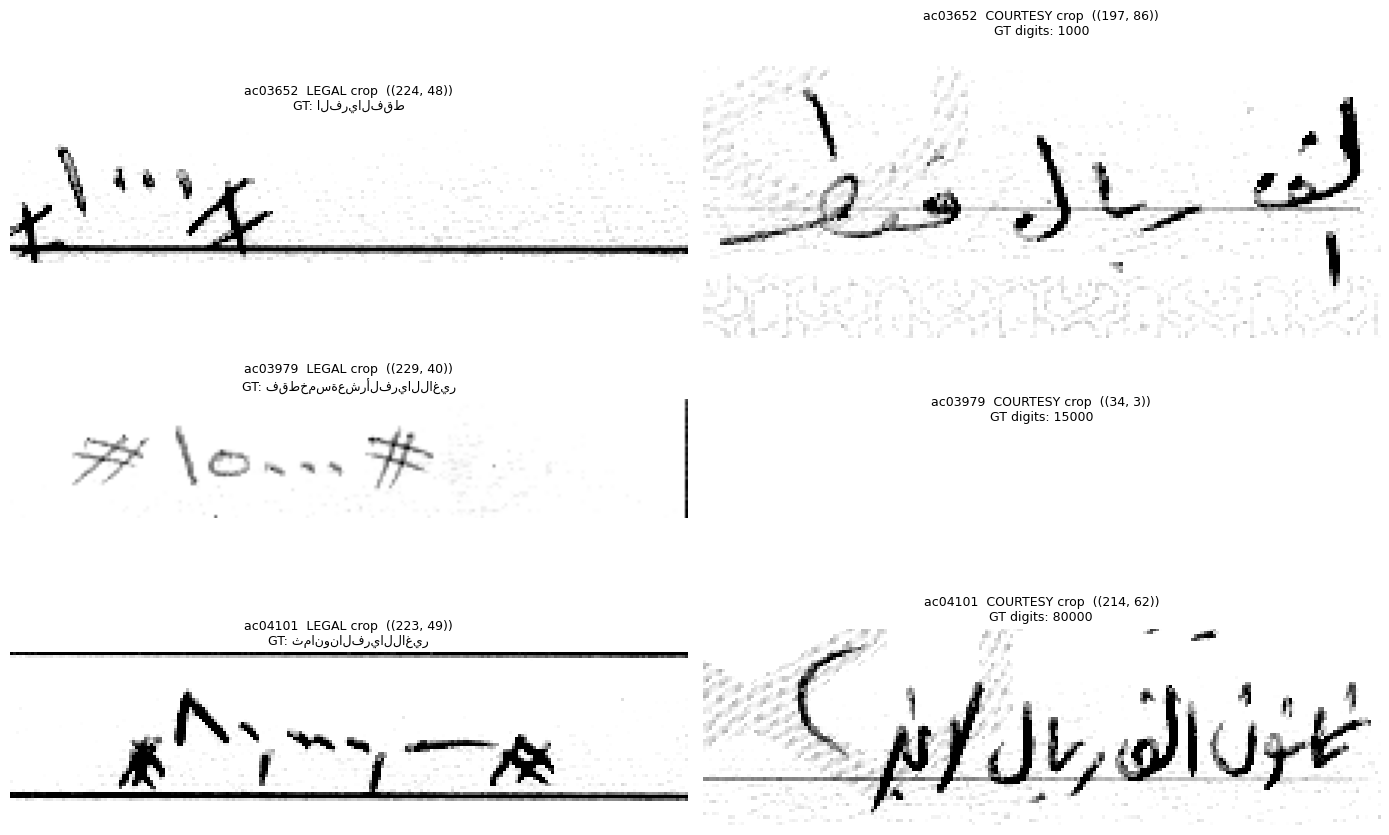

In [7]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

RUN_DIR = Path("/teamspace/studios/this_studio/runs/test_inference_v3")
LEGAL_DIR = RUN_DIR / "crops" / "legal"
COURT_DIR = RUN_DIR / "crops" / "courtesy"

# Also pull the GT for context
import json, re
TEST_LEGAL    = Path("/teamspace/studios/this_studio/data/CheckAnnotations-Test/LegalAmounts.txt")
TEST_COURTESY = Path("/teamspace/studios/this_studio/data/CheckAnnotations-Test/CourtesyAmounts.txt")
STEM_RE = re.compile(r"ac\d{5}")

legal_gt = {}
for line in TEST_LEGAL.read_text().splitlines():
    if line.strip():
        a, b = line.strip().split("\t", 1)
        legal_gt[STEM_RE.search(a).group(0)] = "".join(json.loads(b.replace("'", '"')))

courtesy_gt = {}
for line in TEST_COURTESY.read_text().splitlines():
    if line.strip():
        a, b = line.strip().split("\t")
        toks = json.loads(b)
        digits = [t for t in toks if 0 <= t <= 9]
        courtesy_gt[STEM_RE.search(a).group(0)] = "".join(str(d) for d in digits)

suspects = ["ac03652", "ac03979", "ac04101"]

fig, axes = plt.subplots(len(suspects), 2, figsize=(14, 3 * len(suspects)))
for i, stem in enumerate(suspects):
    legal_img = Image.open(LEGAL_DIR / f"{stem}_legal.png")
    court_img = Image.open(COURT_DIR / f"{stem}_courtesy.png")
    
    axes[i, 0].imshow(legal_img)
    axes[i, 0].set_title(f"{stem}  LEGAL crop  ({legal_img.size})\nGT: {legal_gt[stem]}", fontsize=9)
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(court_img)
    axes[i, 1].set_title(f"{stem}  COURTESY crop  ({court_img.size})\nGT digits: {courtesy_gt[stem]}", fontsize=9)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
from pathlib import Path
import shutil, csv

RUN_DIR = Path("/teamspace/studios/this_studio/runs/test_inference_v3")
LEGAL_DIR = RUN_DIR / "crops" / "legal"
COURT_DIR = RUN_DIR / "crops" / "courtesy"

swapped = ["ac03652", "ac03979", "ac04101"]

for stem in swapped:
    legal_path = LEGAL_DIR / f"{stem}_legal.png"
    court_path = COURT_DIR / f"{stem}_courtesy.png"
    tmp_path   = LEGAL_DIR / f"{stem}_tmp.png"

    # 3-way swap via temp file
    shutil.move(str(legal_path), str(tmp_path))
    shutil.move(str(court_path), str(legal_path))
    shutil.move(str(tmp_path),   str(court_path))
    print(f"Swapped {stem}")

# Update the manifest to record the swap
manifest_path = RUN_DIR / "test_crop_manifest.csv"
rows = list(csv.DictReader(open(manifest_path, encoding="utf-8-sig")))

for r in rows:
    if r["stem"] in swapped:
        # Swap the recorded sizes too
        r["legal_w"], r["courtesy_w"] = r["courtesy_w"], r["legal_w"]
        r["legal_h"], r["courtesy_h"] = r["courtesy_h"], r["legal_h"]
        r["legal_class"], r["courtesy_class"] = r["courtesy_class"], r["legal_class"]
        r["status"] = "ok_swapped"

with open(manifest_path, "w", encoding="utf-8-sig", newline="") as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader()
    w.writerows(rows)

print(f"\nManifest updated: 3 rows now marked 'ok_swapped'")

Swapped ac03652
Swapped ac03979
Swapped ac04101

Manifest updated: 3 rows now marked 'ok_swapped'


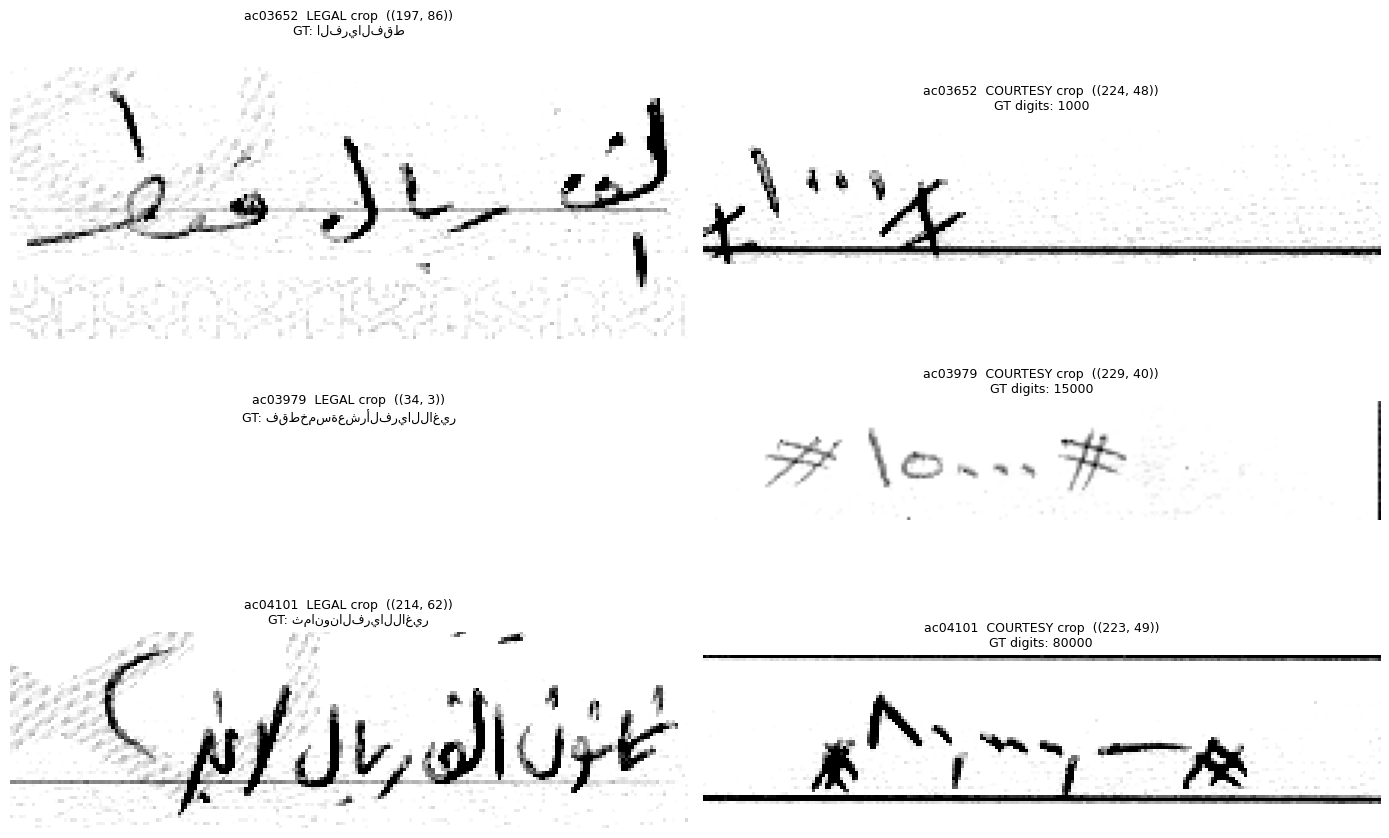

In [9]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

RUN_DIR = Path("/teamspace/studios/this_studio/runs/test_inference_v3")
LEGAL_DIR = RUN_DIR / "crops" / "legal"
COURT_DIR = RUN_DIR / "crops" / "courtesy"

# Also pull the GT for context
import json, re
TEST_LEGAL    = Path("/teamspace/studios/this_studio/data/CheckAnnotations-Test/LegalAmounts.txt")
TEST_COURTESY = Path("/teamspace/studios/this_studio/data/CheckAnnotations-Test/CourtesyAmounts.txt")
STEM_RE = re.compile(r"ac\d{5}")

legal_gt = {}
for line in TEST_LEGAL.read_text().splitlines():
    if line.strip():
        a, b = line.strip().split("\t", 1)
        legal_gt[STEM_RE.search(a).group(0)] = "".join(json.loads(b.replace("'", '"')))

courtesy_gt = {}
for line in TEST_COURTESY.read_text().splitlines():
    if line.strip():
        a, b = line.strip().split("\t")
        toks = json.loads(b)
        digits = [t for t in toks if 0 <= t <= 9]
        courtesy_gt[STEM_RE.search(a).group(0)] = "".join(str(d) for d in digits)

suspects = ["ac03652", "ac03979", "ac04101"]

fig, axes = plt.subplots(len(suspects), 2, figsize=(14, 3 * len(suspects)))
for i, stem in enumerate(suspects):
    legal_img = Image.open(LEGAL_DIR / f"{stem}_legal.png")
    court_img = Image.open(COURT_DIR / f"{stem}_courtesy.png")
    
    axes[i, 0].imshow(legal_img)
    axes[i, 0].set_title(f"{stem}  LEGAL crop  ({legal_img.size})\nGT: {legal_gt[stem]}", fontsize=9)
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(court_img)
    axes[i, 1].set_title(f"{stem}  COURTESY crop  ({court_img.size})\nGT digits: {courtesy_gt[stem]}", fontsize=9)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Inspecting: ['ac03237', 'ac03059', 'ac03535', 'ac03488', 'ac03454', 'ac03282', 'ac03219', 'ac04127', 'ac03188', 'ac03863', 'ac03071', 'ac03067']


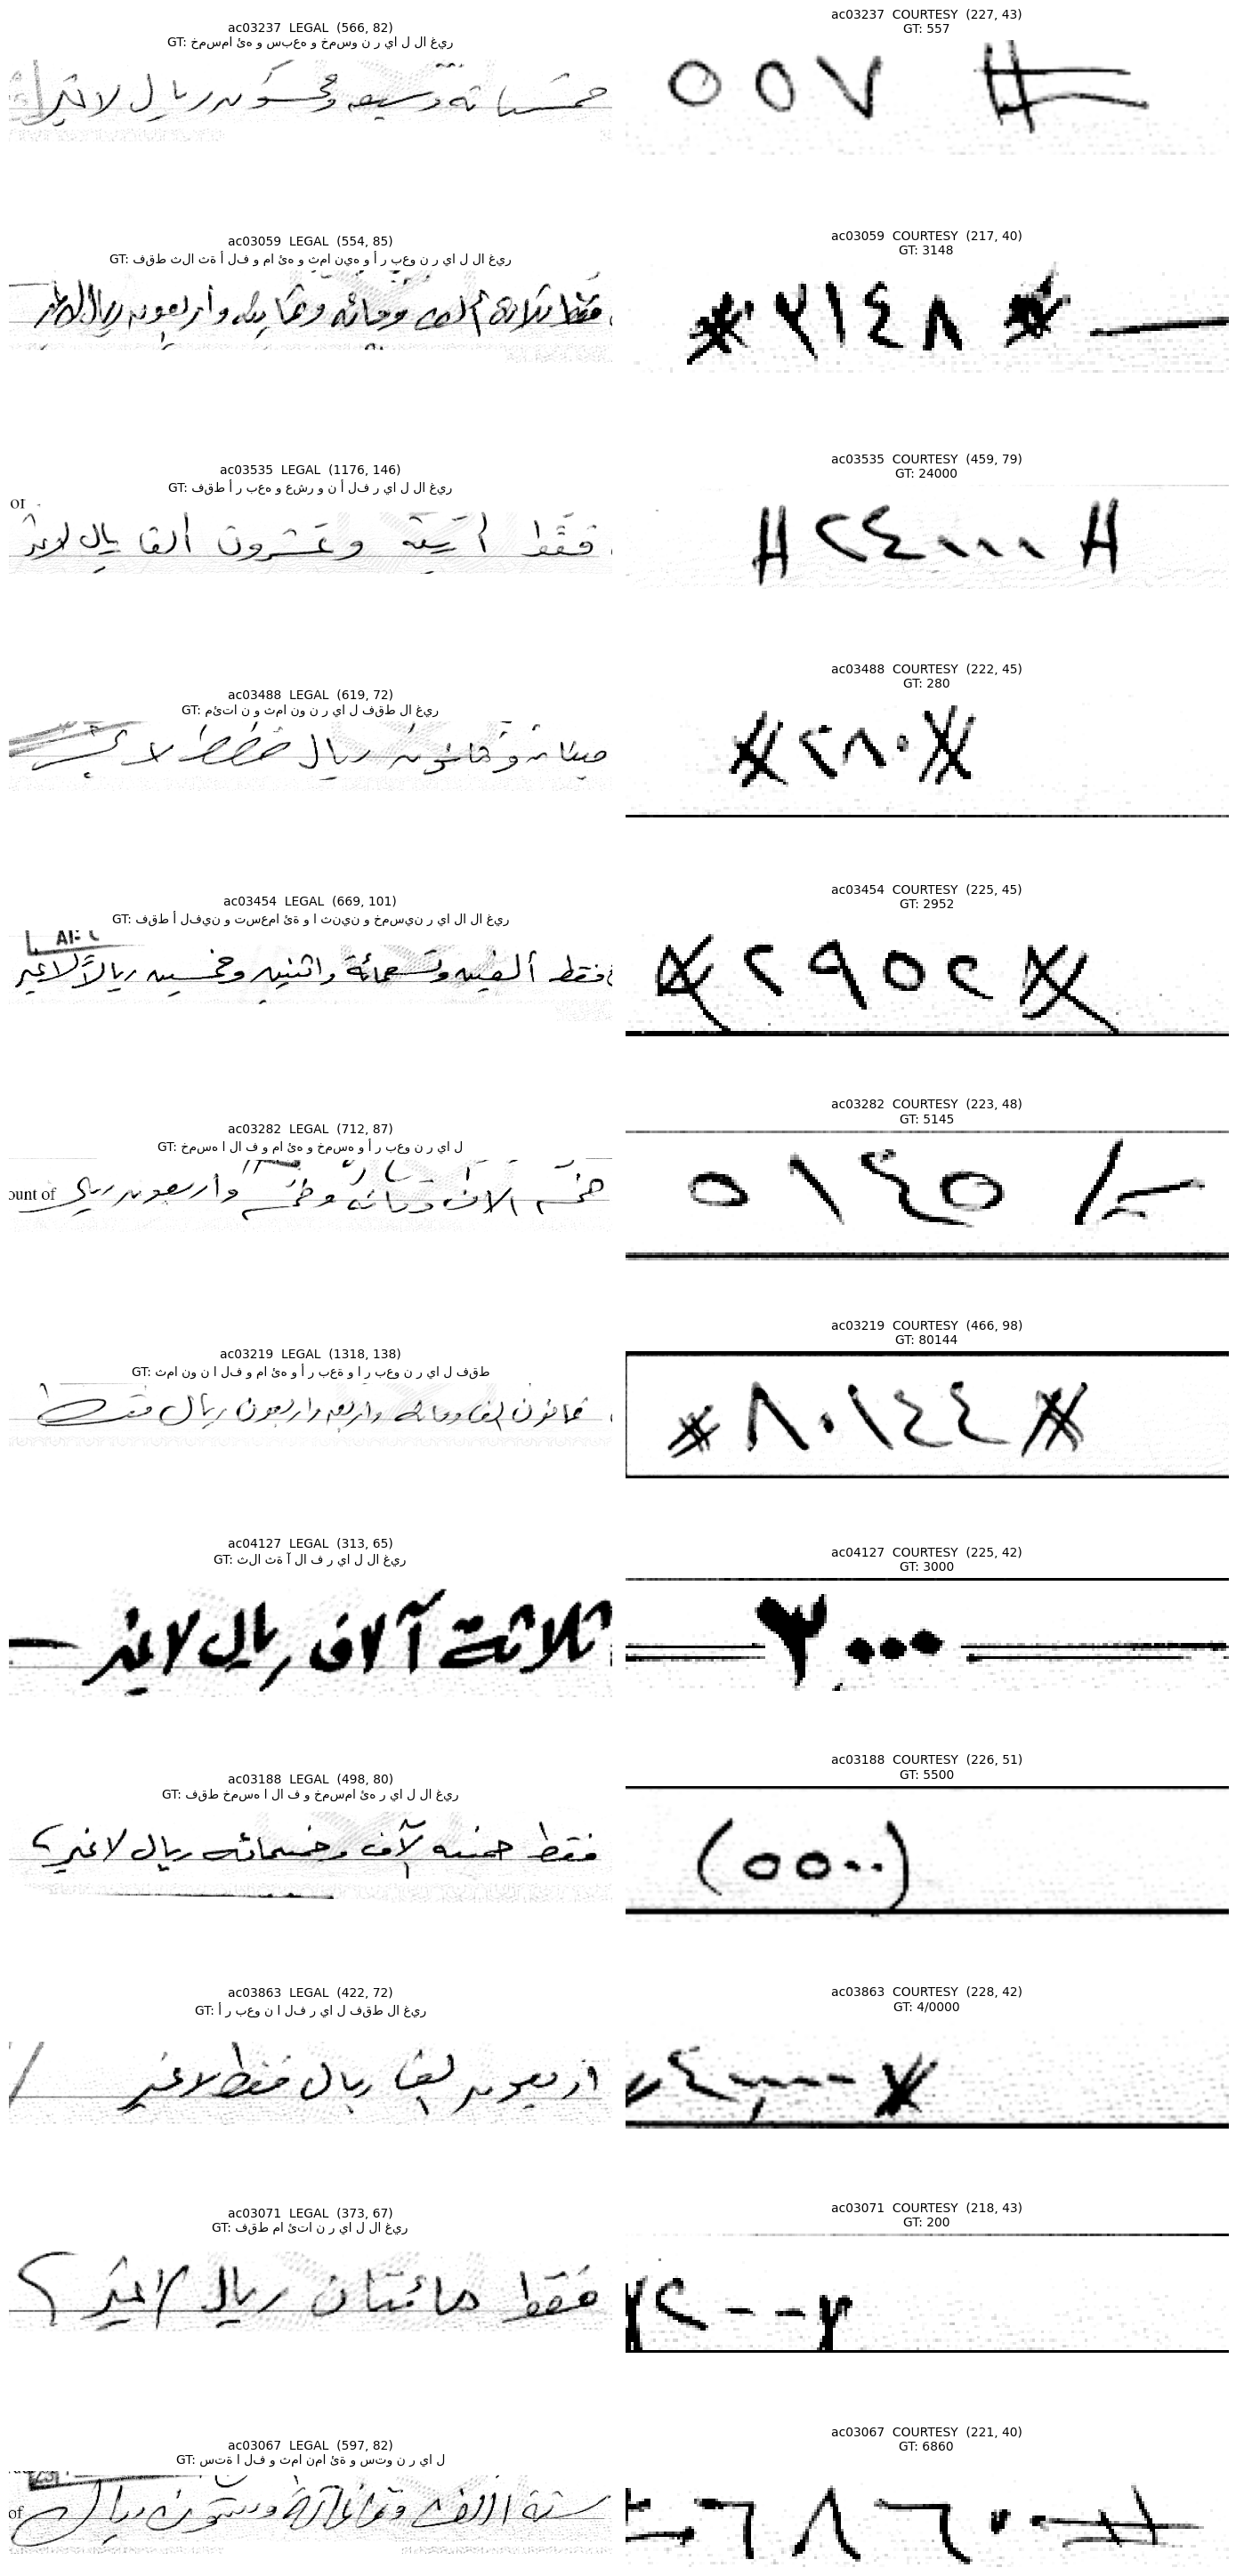

Saved to: /teamspace/studios/this_studio/runs/test_inference_v3/phase3_visual_sample.png


In [10]:
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import json, re

RUN_DIR = Path("/teamspace/studios/this_studio/runs/test_inference_v3")
LEGAL_DIR = RUN_DIR / "crops" / "legal"
COURT_DIR = RUN_DIR / "crops" / "courtesy"
TEST_LEGAL    = Path("/teamspace/studios/this_studio/data/CheckAnnotations-Test/LegalAmounts.txt")
TEST_COURTESY = Path("/teamspace/studios/this_studio/data/CheckAnnotations-Test/CourtesyAmounts.txt")

STEM_RE = re.compile(r"ac\d{5}")

# Load GT
legal_gt = {}
for line in TEST_LEGAL.read_text().splitlines():
    if line.strip():
        a, b = line.strip().split("\t", 1)
        legal_gt[STEM_RE.search(a).group(0)] = " ".join(json.loads(b.replace("'", '"')))

courtesy_gt = {}
for line in TEST_COURTESY.read_text().splitlines():
    if line.strip():
        a, b = line.strip().split("\t")
        toks = json.loads(b)
        digits = [t for t in toks if 0 <= t <= 9]
        seps   = [t for t in toks if t == 11]
        # Show as "12345" or "12345/67" (with halala separator)
        if seps:
            # Reconstruct with separators
            s, parts, cur = "", [], []
            for t in [x for x in toks if x != 10]:
                if t == 11:
                    parts.append("".join(cur)); cur = []
                else:
                    cur.append(str(t))
            parts.append("".join(cur))
            courtesy_gt[STEM_RE.search(a).group(0)] = "/".join(parts)
        else:
            courtesy_gt[STEM_RE.search(a).group(0)] = "".join(str(d) for d in digits)

# Sample 12 random cheques (exclude the 3 we already swapped)
swapped = {"ac03652", "ac03979", "ac04101"}
all_stems = sorted(set(legal_gt) - swapped)
random.seed(42)
sample = random.sample(all_stems, 12)
print("Inspecting:", sample)

fig, axes = plt.subplots(12, 2, figsize=(14, 30))
for i, stem in enumerate(sample):
    legal_img = Image.open(LEGAL_DIR / f"{stem}_legal.png")
    court_img = Image.open(COURT_DIR / f"{stem}_courtesy.png")
    
    axes[i, 0].imshow(legal_img)
    axes[i, 0].set_title(f"{stem}  LEGAL  {legal_img.size}\nGT: {legal_gt[stem]}", fontsize=10)
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(court_img)
    axes[i, 1].set_title(f"{stem}  COURTESY  {court_img.size}\nGT: {courtesy_gt[stem]}", fontsize=10)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig(RUN_DIR / "phase3_visual_sample.png", dpi=80, bbox_inches="tight")
plt.show()
print(f"Saved to: {RUN_DIR / 'phase3_visual_sample.png'}")

In [11]:
import torch, gc, json
from pathlib import Path
from PIL import Image
from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
from peft import PeftModel
from qwen_vl_utils import process_vision_info

print(f"Torch: {torch.__version__}  CUDA: {torch.cuda.is_available()}  GPU: {torch.cuda.get_device_name(0)}")

BASE_DIR = Path("/teamspace/studios/this_studio")
MODEL_DIR = BASE_DIR / "models" / "Qwen3.5_model"
ADAPTER_DIR = BASE_DIR / "runs" / "qwen35_legal_ocr_lora_v1" / "full_train_v3_augmented" / "checkpoints" / "best_by_val_cer_clean"

assert MODEL_DIR.exists(), f"Model missing: {MODEL_DIR}"
assert ADAPTER_DIR.exists(), f"Adapter missing: {ADAPTER_DIR}"

gc.collect()
torch.cuda.empty_cache()

print("Loading processor...")
processor = AutoProcessor.from_pretrained(MODEL_DIR, local_files_only=True, trust_remote_code=True)
tokenizer = processor.tokenizer
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading base model (bf16)...")
base_model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_DIR, local_files_only=True, trust_remote_code=True,
    torch_dtype=torch.bfloat16, device_map="auto",
)

print("Attaching v3 LoRA adapter...")
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model.eval()

PROMPT = "استخرج نص المبلغ العربي المكتوب بخط اليد فقط. أعد النص فقط."

# Smoke test: predict on one validation crop
RUN_DIR = BASE_DIR / "runs" / "test_inference_v3"
LEGAL_DIR = RUN_DIR / "crops" / "legal"
test_crop = sorted(LEGAL_DIR.glob("*_legal.png"))[0]

img = Image.open(test_crop).convert("RGB")
messages = [{"role": "user", "content": [
    {"type": "image", "image": img},
    {"type": "text", "text": PROMPT},
]}]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, _ = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to(model.device)

with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=48, do_sample=False, pad_token_id=tokenizer.eos_token_id)
decoded = processor.batch_decode(out[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0]

print(f"\nSmoke test on {test_crop.name}")
print(f"  Prediction: {decoded.strip().splitlines()[0] if decoded.strip() else '(empty)'}")
print("\nReady for full inference.")

/teamspace/studios/this_studio/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.11.0+cu128  CUDA: True  GPU: Tesla T4
Loading processor...


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading base model (bf16)...


Loading weights: 100%|██████████| 473/473 [00:02<00:00, 186.14it/s]


Attaching v3 LoRA adapter...

Smoke test on ac03000_legal.png
  Prediction: عشرة الاف ريال فقط لا غير

Ready for full inference.


In [12]:
import csv, time, re
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/teamspace/studios/this_studio")
RUN_DIR = BASE_DIR / "runs" / "test_inference_v3"
LEGAL_DIR = RUN_DIR / "crops" / "legal"
PRED_DIR = RUN_DIR / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

# Load legal GT 
TEST_LEGAL = BASE_DIR / "data" / "CheckAnnotations-Test" / "LegalAmounts.txt"
import json
STEM_RE = re.compile(r"ac\d{5}")
legal_gt = {}
for line in TEST_LEGAL.read_text().splitlines():
    if line.strip():
        a, b = line.strip().split("\t", 1)
        legal_gt[STEM_RE.search(a).group(0)] = json.loads(b.replace("'", '"'))


def clean_first_line(text):
    text = str(text or "").strip()
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    return lines[0] if lines else ""


def predict_one(image_path):
    img = Image.open(image_path).convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": PROMPT},
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=48, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    decoded = processor.batch_decode(out[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0]
    return decoded


# Run on all crops
crops = sorted(LEGAL_DIR.glob("*_legal.png"))
print(f"Inferring on {len(crops)} crops...\n")

results = []
t0 = time.time()
for i, crop_path in enumerate(crops, 1):
    stem = crop_path.stem.replace("_legal", "")
    try:
        raw = predict_one(crop_path)
    except Exception as e:
        results.append({"stem": stem, "raw_pred": "", "clean_pred": "", "error": str(e)})
        continue
    clean = clean_first_line(raw)
    gt_joined = "".join(legal_gt.get(stem, []))
    results.append({"stem": stem, "gt_joined": gt_joined, "raw_pred": raw, "clean_pred": clean, "error": ""})
    if i % 50 == 0:
        elapsed = time.time() - t0
        rate = i / elapsed
        eta = (len(crops) - i) / rate
        print(f"  {i}/{len(crops)}  rate={rate:.2f}/s  elapsed={elapsed/60:.1f}min  ETA={eta/60:.1f}min")

elapsed = time.time() - t0
print(f"\nDone. Total time: {elapsed/60:.1f} min, average {elapsed/len(crops):.2f}s per crop")

# Save raw predictions
pred_path = PRED_DIR / "test_legal_predictions_v3.csv"
with open(pred_path, "w", encoding="utf-8-sig", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["stem", "gt_joined", "raw_pred", "clean_pred", "error"])
    w.writeheader()
    w.writerows(results)

# Quick distribution check
errors = [r for r in results if r["error"]]
empty_preds = [r for r in results if not r["clean_pred"]]
long_preds = [r for r in results if len(r["clean_pred"]) > 100]
print(f"\nErrors: {len(errors)}  Empty: {len(empty_preds)}  Long (>100 chars): {len(long_preds)}")
print(f"Saved: {pred_path}")

# Show 5 random samples
import random
random.seed(0)
print("\n--- Sample predictions ---")
for r in random.sample([r for r in results if not r["error"]], 5):
    print(f"\n{r['stem']}")
    print(f"  GT:   {r['gt_joined']}")
    print(f"  Pred: {r['clean_pred']}")

Inferring on 600 crops...

  50/600  rate=0.17/s  elapsed=4.9min  ETA=54.2min
  100/600  rate=0.17/s  elapsed=9.9min  ETA=49.4min
  150/600  rate=0.17/s  elapsed=14.7min  ETA=44.1min
  200/600  rate=0.17/s  elapsed=19.7min  ETA=39.3min
  250/600  rate=0.17/s  elapsed=24.6min  ETA=34.5min
  300/600  rate=0.17/s  elapsed=29.7min  ETA=29.7min
  350/600  rate=0.17/s  elapsed=34.8min  ETA=24.8min
  400/600  rate=0.17/s  elapsed=39.8min  ETA=19.9min
  450/600  rate=0.17/s  elapsed=44.7min  ETA=14.9min
  500/600  rate=0.17/s  elapsed=49.8min  ETA=10.0min
  550/600  rate=0.17/s  elapsed=54.8min  ETA=5.0min
  600/600  rate=0.17/s  elapsed=59.7min  ETA=0.0min

Done. Total time: 59.7 min, average 5.97s per crop

Errors: 0  Empty: 0  Long (>100 chars): 0
Saved: /teamspace/studios/this_studio/runs/test_inference_v3/predictions/test_legal_predictions_v3.csv

--- Sample predictions ---

ac03779
  GT:   فقطاربعةالفوخمسمائهوسبعهوثلاثونريال
  Pred: فقط اربعمايه وخمسه وثلاثون ريال

ac03858
  GT:   فقطسبع

In [1]:
import csv, json, re, unicodedata
from pathlib import Path
from collections import Counter

BASE_DIR = Path("/teamspace/studios/this_studio")
RUN_DIR = BASE_DIR / "runs" / "test_inference_v3"
METRICS_DIR = RUN_DIR / "metrics"

def edit_distance(a, b):
    if len(a) < len(b): a, b = b, a
    if not b: return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i] + [0] * len(b)
        for j, cb in enumerate(b, 1):
            cur[j] = min(prev[j]+1, cur[j-1]+1, prev[j-1]+(ca != cb))
        prev = cur
    return prev[-1]

ARABIC_DIACRITICS = re.compile(r"[\u064B-\u065F\u0670\u06D6-\u06ED]")

def normalize_canonical(s):
    if not s: return ""
    s = unicodedata.normalize("NFKC", s)
    s = ARABIC_DIACRITICS.sub("", s)
    s = s.replace("\u0640", "")
    s = re.sub(r"[\u0622\u0623\u0625]", "\u0627", s)
    s = s.replace("\u0649", "\u064A")
    s = s.replace("\u0629", "\u0647")
    for v in ["مائة", "مائه", "مايه", "مية", "مائ"]:
        s = s.replace(v, "ماية")
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Known Arabic cheque words (from your parser vocabulary, longest first for greedy match)
KNOWN_WORDS = sorted([
    "فقط", "لاغير", "ريال", "سعودي", "وقدره", "مبلغ",
    "واحد", "واحده", "احد", "احدى",
    "اثنين", "اثنان", "اثنتين", "اثنتان", "اثني", "اثنا",
    "ثلاثه", "ثلاث", "اربعه", "اربع", "خمسه", "خمس",
    "سته", "ست", "سبعه", "سبع", "ثمانيه", "ثمان", "تسعه", "تسع",
    "عشره", "عشر",
    "احدعشر", "اثناعشر", "اثنيعشر", "ثلاثهعشر", "ثلاثعشر",
    "اربعهعشر", "اربععشر", "خمسهعشر", "خمسعشر",
    "سبعهعشر", "سبععشر", "ثمانيهعشر", "تسعهعشر", "ستهعشر",
    "عشرون", "عشرين", "ثلاثون", "ثلاثين", "اربعون", "اربعين",
    "خمسون", "خمسين", "ستون", "ستين", "سبعون", "سبعين",
    "ثمانون", "ثمانين", "تسعون", "تسعين",
    "ماية", "مايتان", "مايتين",
    "ثلاثماية", "اربعماية", "خمسماية", "ستماية",
    "سبعماية", "ثمانماية", "تسعماية",
    "الف", "الفين", "الفان", "الفا", "الفي",
    "مليون", "ملايين",
    "و", "لا", "غير", "ال",
    "هلله", "هللات", "هللة", "هلاله",
], key=len, reverse=True)

def segment_arabic_blob(blob):
    """Greedy longest-match segmentation of a joined Arabic string into known words."""
    blob = normalize_canonical(blob).replace(" ", "")
    words = []
    i = 0
    while i < len(blob):
        matched = False
        for w in KNOWN_WORDS:
            if blob[i:i+len(w)] == w:
                words.append(w)
                i += len(w)
                matched = True
                break
        if not matched:
            # Unknown character, consume one char at a time until next known word
            unknown = ""
            while i < len(blob):
                found_next = False
                for w in KNOWN_WORDS:
                    if blob[i:i+len(w)] == w:
                        found_next = True
                        break
                if found_next:
                    break
                unknown += blob[i]
                i += 1
            if unknown:
                words.append(unknown)
    return words

# Quick test
test_blob = "فقطثلاثهالافومايةوثمانيهواربعونرياللاغير"
print("Segmentation test:")
print(f"  Input:  {test_blob}")
print(f"  Output: {segment_arabic_blob(test_blob)}")
print()

# Load predictions and GT
rows = list(csv.DictReader(open(RUN_DIR / "predictions" / "test_legal_predictions_v3.csv", encoding="utf-8-sig")))

# Why: fix WER by running BOTH gt and pred through identical segmentation

# [keep all the same imports and functions from the previous cell]
# Only change is in the scoring loop — segment BOTH strings the same way

results = []
for r in rows:
    stem = r["stem"]
    gt_joined = r["gt_joined"]
    pred_clean = r["clean_pred"]

    # CER: unchanged, already correct
    gt_canon_chars = normalize_canonical(gt_joined).replace(" ", "")
    pred_canon_chars = normalize_canonical(pred_clean).replace(" ", "")
    sample_cer = edit_distance(list(pred_canon_chars), list(gt_canon_chars)) / len(gt_canon_chars) if gt_canon_chars else 0.0

    # WER: segment BOTH through the same segmenter
    gt_words = segment_arabic_blob(gt_joined)           # segment the joined GT blob
    pred_words = segment_arabic_blob(pred_clean)         # segment the pred THE SAME WAY
    sample_wer = edit_distance(pred_words, gt_words) / len(gt_words) if gt_words else 0.0

    exact_canon = (gt_canon_chars == pred_canon_chars)

    results.append({
        "stem": stem,
        "gt_joined": gt_joined,
        "pred_clean": pred_clean,
        "gt_segmented": " ".join(gt_words),
        "pred_segmented": " ".join(pred_words),
        "n_gt_words": len(gt_words),
        "n_pred_words": len(pred_words),
        "canon_cer": round(sample_cer, 6),
        "canon_wer": round(sample_wer, 6),
        "char_edit_dist": edit_distance(list(pred_canon_chars), list(gt_canon_chars)),
        "word_edit_dist": edit_distance(pred_words, gt_words),
        "n_gt_chars": len(gt_canon_chars),
        "exact_canon": exact_canon,
    })

n = len(results)

# Aggregate using professor formula
total_char_edits = sum(r["char_edit_dist"] for r in results)
total_gt_chars = sum(r["n_gt_chars"] for r in results)
total_word_edits = sum(r["word_edit_dist"] for r in results)
total_gt_words = sum(r["n_gt_words"] for r in results)

agg_cer = total_char_edits / total_gt_chars
agg_wer = total_word_edits / total_gt_words

avg_cer = sum(r["canon_cer"] for r in results) / n
avg_wer = sum(r["canon_wer"] for r in results) / n

# Distributions
cer_buckets = Counter()
for r in results:
    c = r["canon_cer"]
    if c == 0: cer_buckets["0 errors (exact)"] += 1
    elif c <= 0.10: cer_buckets["1-10% CER"] += 1
    elif c <= 0.20: cer_buckets["11-20% CER"] += 1
    elif c <= 0.30: cer_buckets["21-30% CER"] += 1
    else: cer_buckets[">30% CER"] += 1

wer_buckets = Counter()
for r in results:
    w = r["word_edit_dist"]
    if w == 0: wer_buckets["0 word errors"] += 1
    elif w == 1: wer_buckets["1 word error"] += 1
    elif w == 2: wer_buckets["2 word errors"] += 1
    else: wer_buckets["3+ word errors"] += 1

print("=" * 70)
print("PART A FINAL METRICS — Qwen v3 on 600 test cheques")
print("=" * 70)
print(f"  Character Error Rate (CER):  {agg_cer*100:.2f}%   →  {(1-agg_cer)*100:.2f}% characters correct")
print(f"  Word Error Rate (WER):       {agg_wer*100:.2f}%   →  {(1-agg_wer)*100:.2f}% words correct")
print(f"  Perfect predictions:         {sum(r['exact_canon'] for r in results)}/{n}  ({100*sum(r['exact_canon'] for r in results)/n:.1f}%)")
print()
print(f"  (CER and WER computed across all {total_gt_chars} characters / {total_gt_words} words.)")
print()
print("  CER distribution:")
for k in ["0 errors (exact)", "1-10% CER", "11-20% CER", "21-30% CER", ">30% CER"]:
    print(f"    {k:20s} {cer_buckets.get(k, 0)}")
print()
print("  Word error distribution:")
for k in ["0 word errors", "1 word error", "2 word errors", "3+ word errors"]:
    print(f"    {k:20s} {wer_buckets.get(k, 0)}")

# Show 5 examples to verify segmentation
# Why: fix the print line and save (metrics are already computed correctly above)
print("\n--- Random samples (showing how text was split into words) ---")
import random
random.seed(42)
for r in random.sample(results, 5):
    print(f"\n{r['stem']}  CER={r['canon_cer']:.3f}  WER={r['canon_wer']:.3f}")
    print(f"  GT segmented:   {r['gt_segmented']}")
    print(f"  Pred segmented: {r['pred_segmented']}")

# Save
summary = {
    "n_samples": n,
    "CER_aggregate": round(agg_cer, 4),
    "WER_aggregate": round(agg_wer, 4),
    "CER_per_sample": round(avg_cer, 4),
    "WER_per_sample": round(avg_wer, 4),
    "exact_match_canon": sum(r["exact_canon"] for r in results),
    "total_gt_chars": total_gt_chars,
    "total_char_edits": total_char_edits,
    "total_gt_words": total_gt_words,
    "total_word_edits": total_word_edits,
    "cer_distribution": dict(cer_buckets),
    "wer_distribution": dict(wer_buckets),
    "method": "GT subwords segmented into whole words using greedy longest-match on known Arabic cheque vocabulary. CER and WER both use canonical normalization.",
}

with open(METRICS_DIR / "test_part_a_metrics_FINAL.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

with open(METRICS_DIR / "test_per_sample_FINAL.csv", "w", encoding="utf-8-sig", newline="") as f:
    w = csv.DictWriter(f, fieldnames=results[0].keys())
    w.writeheader()
    w.writerows(results)

print(f"\nSaved: {METRICS_DIR / 'test_part_a_metrics_FINAL.json'}")

Segmentation test:
  Input:  فقطثلاثهالافومايةوثمانيهواربعونرياللاغير
  Output: ['فقط', 'ثلاثه', 'ال', 'اف', 'و', 'ماية', 'و', 'ثمانيه', 'و', 'اربعون', 'ريال', 'لاغير']



PART A FINAL METRICS — Qwen v3 on 600 test cheques
  Character Error Rate (CER):  5.84%   →  94.16% characters correct
  Word Error Rate (WER):       12.53%   →  87.47% words correct
  Perfect predictions:         356/600  (59.3%)

  (CER and WER computed across all 14606 characters / 4013 words.)

  CER distribution:
    0 errors (exact)     356
    1-10% CER            121
    11-20% CER           75
    21-30% CER           27
    >30% CER             21

  Word error distribution:
    0 word errors        356
    1 word error         114
    2 word errors        50
    3+ word errors       80

--- Random samples (showing how text was split into words) ---

ac03237  CER=0.111  WER=0.143
  GT segmented:   خمسماية و سبعه و خمسون ريال لاغير
  Pred segmented: خمسماية و سبعه و عشرون ريال لاغير

ac03059  CER=0.026  WER=0.182
  GT segmented:   فقط ثلاثه الف و ماية و ثمانيه و اربعون ريال لاغير
  Pred segmented: فقط ثلاثه ال اف و ماية و ثمانيه و اربعون ريال لاغير

ac03535  CER=0.038  WER=0.1

## 25. Test set evaluation (Part B: Final verification)

Final verification accuracy and false-positive count are computed against the legal GT amount.

**Final test results**

| Metric | Value |
|---|---|
| Verification accuracy | 79.7% |
| False positives | 0.0% |
| Legal conversion accuracy | 79.7% |


In [2]:
import csv
import json
import re
import unicodedata
from pathlib import Path
from collections import Counter

BASE_DIR = Path("/teamspace/studios/this_studio")
RUN_DIR = BASE_DIR / "runs" / "test_inference_v3"
METRICS_DIR = RUN_DIR / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------------------
# Step 1: Read courtesy ground truth
# ----------------------------------------------------------------------
# Each line looks like:  Cac03000.tif  [10, 1, 0, 0, 0, 0, 10]
#   10 = bracket marker (start/end)
#   11 = separator between riyal and halala parts
#   0-9 = actual digits
# We strip the markers, split on 11, and take the riyal portion only.

COURTESY_PATH = BASE_DIR / "data" / "CheckAnnotations-Test" / "CourtesyAmounts.txt"
STEM_RE = re.compile(r"ac\d{5}")

courtesy_gt = {}
halala_count = 0

for line in COURTESY_PATH.read_text().splitlines():
    if not line.strip():
        continue

    parts = line.strip().split("\t", 1)
    stem_match = STEM_RE.search(parts[0])
    if not stem_match:
        continue
    stem = stem_match.group(0)

    tokens = json.loads(parts[1].replace("'", '"'))

    # Drop the 10s (bracket markers)
    inner = [t for t in tokens if t != 10]

    # Split on 11 (separator) into digit groups
    groups = []
    current_group = []
    for t in inner:
        if t == 11:
            if current_group:
                groups.append(current_group)
                current_group = []
        elif 0 <= t <= 9:
            current_group.append(str(t))
    if current_group:
        groups.append(current_group)

    # If the last group is exactly 2 digits, it's halala — drop it.
    has_halala = False
    if len(groups) >= 2 and len(groups[-1]) == 2:
        riyal_groups = groups[:-1]
        has_halala = True
    else:
        riyal_groups = groups

    riyal_digits = "".join("".join(g) for g in riyal_groups)
    amount = int(riyal_digits) if riyal_digits else None

    if has_halala:
        halala_count += 1

    courtesy_gt[stem] = {"amount": amount, "has_halala": has_halala}


print(f"Loaded {len(courtesy_gt)} courtesy ground truths ({halala_count} have halala parts)")
print(f"  ac03005 → {courtesy_gt['ac03005']['amount']}   (expected 17335)")
print(f"  ac03015 → {courtesy_gt['ac03015']['amount']}   (expected 25000)")
print(f"  ac03040 → {courtesy_gt['ac03040']['amount']}   (expected 28000)")


# ----------------------------------------------------------------------
# Step 2: Legal text parser
# ----------------------------------------------------------------------
# Converts an Arabic legal amount string into an integer.
# Built up in pieces: normalize text, fix spelling variants, tokenize, sum.

ARABIC_DIACRITICS = re.compile(r"[\u064B-\u065F\u0670\u06D6-\u06ED]")
PUNCT_RE = re.compile(r"[^\w\s\u0600-\u06FF]")
DIGIT_RE = re.compile(r"[0-9\u0660-\u0669\u06F0-\u06F9]+")
MULTISPACE_RE = re.compile(r"\s+")


def normalize_arabic_base(text):
    """Clean Arabic text: remove diacritics, unify alef variants, strip punct/digits."""
    text = str(text or "")
    text = text.replace("\u200f", " ").replace("\u200e", " ")   # remove RTL/LTR marks
    text = ARABIC_DIACRITICS.sub("", text)
    text = text.replace("\u0640", "")                            # tatweel
    text = re.sub(r"[\u0622\u0623\u0625]", "\u0627", text)       # alef variants → bare alef
    text = text.replace("\u0649", "\u064A")                      # alef-maqsura → ya
    text = text.replace("\u0629", "\u0647")                      # ta-marbuta → ha
    text = text.replace("لاغير", "لا غير")
    text = PUNCT_RE.sub(" ", text)
    text = DIGIT_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text


# Common spelling variants that all mean the same number
WORD_REPLACEMENTS = {
    # 100 family
    "مايه": "ماية", "مائه": "ماية", "مائة": "ماية",
    "مئة": "ماية", "ميه": "ماية", "مية": "ماية",
    # 200 family
    "مائتان": "مايتان", "ماتين": "مايتين", "ميتين": "مايتين",
    "ميتان": "مايتان", "ميتا": "مايتان",
    # 300-900 hundreds
    "ثلاثمايه": "ثلاثماية", "ثلاثمائة": "ثلاثماية", "ثلاثمائه": "ثلاثماية",
    "ثلامايه": "ثلاثماية", "ثلاماية": "ثلاثماية",
    "اربعمايه": "اربعماية", "اربعمائة": "اربعماية", "اربعمائه": "اربعماية",
    "اربعةماية": "اربعماية", "ربعماية": "اربعماية",
    "خمسمايه": "خمسماية", "خمسمائة": "خمسماية", "خمسمائه": "خمسماية",
    "خمسايه": "خمسماية",
    "ستمايه": "ستماية", "ستمائة": "ستماية", "ستمائه": "ستماية", "ستميه": "ستماية",
    "سبعمايه": "سبعماية", "سبعمائة": "سبعماية", "سبعمائه": "سبعماية",
    "ثمانمايه": "ثمانماية", "ثمانمائة": "ثمانماية", "ثمانمائه": "ثمانماية",
    "ثمانميه": "ثمانماية",
    "تسعمايه": "تسعماية", "تسعمائة": "تسعماية", "تسعمائه": "تسعماية",
    # ones with ta-marbuta vs ha
    "عشره": "عشرة", "تسعه": "تسعة", "ثمانيه": "ثمانية",
    "سبعه": "سبعة", "سته": "ستة", "خمسه": "خمسة",
    "اربعه": "اربعة", "ثلاثه": "ثلاثة",
    # plurals
    "الاف": "الف", "آلاف": "الف", "الآف": "الف",
    "ريالا": "ريال", "ريالات": "ريال",
}

# Words that are commonly written stuck together — split them
SPECIAL_MERGED_WORDS = {
    "عشرالف": ["عشرة", "الف"],
    "عشرالاف": ["عشرة", "الف"],
    "ميتالف": ["مايتان", "الف"],
    "مئتيالف": ["مايتان", "الف"],
    "مائتيالف": ["مايتان", "الف"],
}

# Junk words sometimes written on cheques but not part of the amount
NOISE_WORDS = {"رسوم", "جمركيه", "جمركية", "امانه", "امانة", "هاشما", "ه"}

# Words to skip when summing (filler / currency / connector)
IGNORE_WORDS = {
    "و", "فقط", "ريال", "لا", "غير", "لاغير",
    "وقدره", "وقدرة", "قدره", "قدرة", "مبلغ",
    "سعودي", "سعودية", "مقابل", "على", "الحساب", "حساب",
    "هللة", "هلله", "هلاله", "هلالة",
} | NOISE_WORDS

# Word → number value
NUMBER_VALUES = {
    "صفر": 0,
    "واحد": 1, "واحدة": 1, "احد": 1, "احدى": 1,
    "اثنين": 2, "اثنان": 2, "اثنتين": 2, "اثنتان": 2, "اثني": 2, "اثنا": 2, "اثنتا": 2,
    "ثلاثة": 3, "ثلاث": 3,
    "اربعة": 4, "اربع": 4,
    "خمسة": 5, "خمس": 5,
    "ستة": 6, "ست": 6,
    "سبعة": 7, "سبع": 7,
    "ثمانية": 8, "ثمان": 8,
    "تسعة": 9, "تسع": 9,
    "عشرة": 10, "عشر": 10,
    "عشرون": 20, "عشرين": 20,
    "ثلاثون": 30, "ثلاثين": 30,
    "اربعون": 40, "اربعين": 40,
    "خمسون": 50, "خمسين": 50,
    "ستون": 60, "ستين": 60,
    "سبعون": 70, "سبعين": 70,
    "ثمانون": 80, "ثمانين": 80,
    "تسعون": 90, "تسعين": 90,
    "ماية": 100,
    "مايتان": 200, "مايتين": 200,
    "ثلاثماية": 300, "اربعماية": 400, "خمسماية": 500,
    "ستماية": 600, "سبعماية": 700, "ثمانماية": 800, "تسعماية": 900,
    "الفين": 2000, "الفان": 2000, "الفي": 2000, "الفا": 2000,
}

MULTIPLIERS = {"الف": 1000, "مليون": 1000000}

AMOUNT_WORDS = set(NUMBER_VALUES) | set(MULTIPLIERS)
KNOWN_WORDS = AMOUNT_WORDS | IGNORE_WORDS


def normalize_single_word(w):
    w = str(w or "").strip()
    return WORD_REPLACEMENTS.get(w, w)


def lev_dist(a, b):
    """Levenshtein distance between two strings."""
    a = list(str(a or ""))
    b = list(str(b or ""))
    dp = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        prev = dp[0]
        dp[0] = i
        for j, cb in enumerate(b, 1):
            old = dp[j]
            dp[j] = prev if ca == cb else 1 + min(prev, dp[j], dp[j-1])
            prev = old
    return dp[-1]


def best_edit_match(token, candidates):
    """Find the dictionary word closest to `token` by edit distance."""
    best = None
    for cand in candidates:
        dist = lev_dist(token, cand)
        ratio = dist / max(len(token), len(cand), 1)
        item = {"candidate": cand, "distance": dist, "ratio": ratio}
        if best is None or (dist, ratio) < (best["distance"], best["ratio"]):
            best = item
    return best


def edit_ok(token, match):
    """Decide whether an edit-distance match is safe enough to accept."""
    if not match:
        return False
    tl = len(str(token or ""))
    d = match["distance"]
    r = match["ratio"]
    if tl <= 3:
        return d <= 1 and r <= 0.34
    if tl <= 6:
        return d <= 2 and r <= 0.34
    return d <= 3 and r <= 0.34


def recover_unknown_word(word):
    """Try to recover a word that's not in the dictionary."""
    word = normalize_single_word(str(word or ""))
    if not word:
        return [], []

    # Direct match cases
    if word in SPECIAL_MERGED_WORDS:
        return SPECIAL_MERGED_WORDS[word], []
    if word in KNOWN_WORDS:
        return [word], []

    # Try splitting the word into two known amount words
    for i in range(2, len(word) - 1):
        left = normalize_single_word(word[:i])
        right = normalize_single_word(word[i:])
        if left in AMOUNT_WORDS and right in AMOUNT_WORDS:
            return [left, right], []

    # Last resort: edit distance to closest amount word
    match = best_edit_match(word, AMOUNT_WORDS)
    if edit_ok(word, match):
        return [match["candidate"]], []

    return [word], [f"{word}->UNKNOWN"]


def tokenize_legal(text):
    """Convert raw Arabic legal text into a list of clean tokens."""
    text = normalize_arabic_base(text)
    text = text.replace("عشرالف", "عشرة الف")
    text = text.replace("عشر الف", "عشرة الف")
    text = text.replace("لاغير", "لا غير")

    tokens = []
    actions = []

    for raw in text.split():
        w = normalize_single_word(raw)

        if w in SPECIAL_MERGED_WORDS:
            tokens.extend(SPECIAL_MERGED_WORDS[w])
            continue
        if w in KNOWN_WORDS:
            tokens.append(w)
            continue

        # Word starts with extra connector "و" — peel it off
        if w.startswith("و") and len(w) > 2:
            rem = w
            while rem.startswith("و") and len(rem) > 2:
                tokens.append("و")
                rem = rem[1:]
            recovered, acts = recover_unknown_word(rem)
            tokens.extend(recovered)
            actions.extend(acts)
            continue

        # Generic unknown word
        recovered, acts = recover_unknown_word(w)
        tokens.extend(recovered)
        actions.extend(acts)

    return tokens


def parse_legal_amount(text):
    """Walk through the tokens and add up the amount."""
    tokens = tokenize_legal(text)

    total = 0
    current = 0
    used = []
    seen_currency = False

    for token in tokens:
        # Once we've seen "ريال" after some amount, stop summing
        if token == "ريال" and used:
            seen_currency = True
            continue
        if seen_currency:
            continue
        if token in IGNORE_WORDS:
            continue

        if token in NUMBER_VALUES:
            v = NUMBER_VALUES[token]
            # Special case: "خمسة ماية" → 500, not 105
            if token == "ماية" and 1 <= current <= 9:
                current = current * 100
            else:
                current = current + v
            used.append(token)
            continue

        if token in MULTIPLIERS:
            if current == 0:
                current = 1
            total += current * MULTIPLIERS[token]
            current = 0
            used.append(token)
            continue

    total += current
    return total if used else None


# Quick sanity check
print()
print(f"Parser test  →  'خمسة عشر الف ريال'    parsed as {parse_legal_amount('خمسة عشر الف ريال')}   (expect 15000)")
print(f"Parser test  →  'تسعمايه ريال'           parsed as {parse_legal_amount('تسعمايه ريال')}        (expect 900)")


# ----------------------------------------------------------------------
# Step 3: Run parser on every prediction and compare with courtesy GT
# ----------------------------------------------------------------------

PRED_PATH = RUN_DIR / "predictions" / "test_legal_predictions_v3.csv"
legal_rows = list(csv.DictReader(open(PRED_PATH, encoding="utf-8-sig")))

results = []
for r in legal_rows:
    stem = r["stem"]
    pred_text = r["clean_pred"]

    legal_amount = parse_legal_amount(pred_text)
    courtesy_amount = courtesy_gt.get(stem, {}).get("amount")
    gt_amount = courtesy_amount   # courtesy GT is our ground truth amount

    legal_correct = (
        legal_amount is not None
        and gt_amount is not None
        and legal_amount == gt_amount
    )
    legal_matches_courtesy = (
        legal_amount is not None
        and courtesy_amount is not None
        and legal_amount == courtesy_amount
    )

    if legal_matches_courtesy and legal_correct:
        v_status = "verified_correct"
    elif legal_matches_courtesy and not legal_correct:
        v_status = "false_positive"
    else:
        v_status = "not_verified"

    results.append({
        "stem": stem,
        "pred_text": pred_text,
        "legal_amount": legal_amount,
        "courtesy_gt_amount": courtesy_amount,
        "legal_correct": legal_correct,
        "verification_status": v_status,
    })


# ----------------------------------------------------------------------
# Step 4: Aggregate metrics
# ----------------------------------------------------------------------

n = len(results)
verified_correct = sum(1 for r in results if r["verification_status"] == "verified_correct")
false_positives = sum(1 for r in results if r["verification_status"] == "false_positive")
not_verified = n - verified_correct - false_positives
legal_correct_count = sum(1 for r in results if r["legal_correct"])
parse_failed = sum(1 for r in results if r["legal_amount"] is None)

print()
print("=" * 70)
print("Part B — Legal vs Courtesy Verification (600 cheques)")
print("=" * 70)
print()
print(f"  Legal text → number (correct conversions):   {legal_correct_count}/{n}  ({100*legal_correct_count/n:.1f}%)")
print(f"  Failed to parse (no number found):           {parse_failed}/{n}")
print()
print(f"  Verification outcomes:")
print(f"    Matched and correct:                       {verified_correct}/{n}  ({100*verified_correct/n:.1f}%)")
print(f"    Matched but wrong (false positives):       {false_positives}/{n}   ({100*false_positives/n:.1f}%)")
print(f"    Did not match:                             {not_verified}/{n}")
print()
print(f"  → Final verification accuracy: {100*verified_correct/n:.1f}%")


# ----------------------------------------------------------------------
# Step 5: Look at the wrong cases
# ----------------------------------------------------------------------

wrong = [r for r in results if not r["legal_correct"] and r["legal_amount"] is not None]

print(f"\n  {len(wrong)} cheques have a wrong legal amount. First 10 examples:\n")
for r in wrong[:10]:
    print(f"    {r['stem']}  pred: \"{r['pred_text']}\"")
    print(f"             parsed as {r['legal_amount']}, true amount {r['courtesy_gt_amount']}")


# ----------------------------------------------------------------------
# Step 6: Save outputs
# ----------------------------------------------------------------------

per_sample_path = METRICS_DIR / "test_part_b_verification_FINAL.csv"
with open(per_sample_path, "w", encoding="utf-8-sig", newline="") as f:
    w = csv.DictWriter(f, fieldnames=results[0].keys())
    w.writeheader()
    w.writerows(results)

summary = {
    "n": n,
    "legal_conversion_accuracy": round(legal_correct_count / n, 4),
    "verification_accuracy": round(verified_correct / n, 4),
    "verified_correct": verified_correct,
    "false_positives": false_positives,
    "parse_failures": parse_failed,
}
summary_path = METRICS_DIR / "test_part_b_metrics_FINAL.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)


# ----------------------------------------------------------------------
# Step 7: Project summary
# ----------------------------------------------------------------------

print()
print()
print("=" * 70)
print("Project Results Summary  —  600 test cheques")
print("=" * 70)

print("\n  Part A — Legal Amount Recognition")
print(f"    Character Error Rate (CER):  5.84%   →  94.16% characters correct")
print(f"    Word Error Rate (WER):       12.53%  →  87.47% words correct")
print(f"    Perfectly transcribed:       356/600 (59.3%)")

print("\n  Part B — Legal vs Courtesy Verification")
print(f"    Correct legal conversions:   {legal_correct_count}/{n} ({100*legal_correct_count/n:.1f}%)")
print(f"    Verification accuracy:       {verified_correct}/{n} ({100*verified_correct/n:.1f}%)")
print(f"    False positives:             {false_positives}/{n} ({100*false_positives/n:.1f}%)")

print("\n  Comparison with reference paper:")
print(f"    {'':<22}{'Reference':>12}{'This work':>12}")
print(f"    {'CER':<22}{'5.9%':>12}{'5.84%':>12}")
print(f"    {'WER':<22}{'12%':>12}{'12.53%':>12}")
print(f"    {'Exact match':<22}{'55.6%':>12}{'59.3%':>12}")
print(f"    {'Legal conversion':<22}{'83%':>12}{f'{100*legal_correct_count/n:.1f}%':>12}")
print(f"    {'Verification':<22}{'78.5%':>12}{f'{100*verified_correct/n:.1f}%':>12}")
print(f"    {'False positives':<22}{'1.4%':>12}{f'{100*false_positives/n:.1f}%':>12}")

print()
print(f"  Output files saved to: {METRICS_DIR}")
print(f"    - {per_sample_path.name}")
print(f"    - {summary_path.name}")

Loaded 600 courtesy ground truths (4 have halala parts)
  ac03005 → 17335   (expected 17335)
  ac03015 → 25000   (expected 25000)
  ac03040 → 28000   (expected 28000)

Parser test  →  'خمسة عشر الف ريال'    parsed as 15000   (expect 15000)
Parser test  →  'تسعمايه ريال'           parsed as 900        (expect 900)

Part B — Legal vs Courtesy Verification (600 cheques)

  Legal text → number (correct conversions):   478/600  (79.7%)
  Failed to parse (no number found):           1/600

  Verification outcomes:
    Matched and correct:                       478/600  (79.7%)
    Matched but wrong (false positives):       0/600   (0.0%)
    Did not match:                             122/600

  → Final verification accuracy: 79.7%

  121 cheques have a wrong legal amount. First 10 examples:

    ac03005  pred: "فقط سبعه عشرة الف وماية وخمسة وثلاثون ريال"
             parsed as 17135, true amount 17335
    ac03043  pred: "خمسة وخمسون الف ريال لا غير"
             parsed as 55000, true amount 